<a href="https://colab.research.google.com/github/mardocheeogecime-gif/Rede_Colabora-o_Acad-mica_ECI_UFMG/blob/main/Journal_of_Informetrics_deterministic_entity_resolutio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Parte_01_Entity_Resolution_Provenance_and_Forensic_Audit.py
#
# Journal of Informetrics — deterministic entity-resolution laboratory
# Part 0/1: Provenance freeze + forensic audit of author identities
#
# PURPOSE
#   1. Reuse, byte-for-byte, the canonical frozen inputs already audited in the JCN project.
#   2. Create a new, independent run root for the Journal of Informetrics entity-resolution study.
#   3. Audit the resolved-author table at identity level before any benchmark or gold-standard annotation.
#   4. Detect normalized-name collisions, identifier multiplicity, candidate ambiguity, and metadata conflicts.
#   5. Produce the seed pool from which the manual gold standard will be designed.
#
# IMPORTANT SCIENTIFIC RULE
#   This script DOES NOT tune matching thresholds, DOES NOT construct a final gold standard,
#   DOES NOT evaluate the proposed deterministic resolver, and DOES NOT use downstream
#   network performance to choose identity decisions. It is a pre-registered forensic audit.
#
# EXPECTED SOURCE LINEAGE
#   /content/drive/MyDrive/tese_doutoral/runs/
#       jcn_pareto_sparsification_20261002/
#           00_data_provenance/0B_canonical_reconstruction/input_frozen/
#
# NEW OUTPUT ROOT
#   /content/drive/MyDrive/tese_doutoral/runs/
#       joi_entity_resolution_20261003/
#
# OUTPUTS
#   00_provenance/
#       provenance_manifest.json
#       source_inventory.csv
#       frozen_inputs/
#   01_forensic_audit/
#       tables/
#           Table_01_01_resolved_schema.csv
#           Table_01_02_identity_level_summary.csv
#           Table_01_03_normalized_name_collisions.csv
#           Table_01_04_author_id_multiplicity.csv
#           Table_01_05_orcid_conflicts.csv
#           Table_01_06_identity_variant_summary.csv
#           Table_01_07_ambiguity_strata.csv
#           Table_01_08_candidate_gold_standard_pool.csv
#           Table_01_09_stratum_summary.csv
#       artifacts/
#           forensic_audit_manifest.json
#
# NOTES
#   - The audit is intentionally conservative.
#   - "Ambiguity" here is a sampling/audit label, not a truth label.
#   - Existing OpenAlex Author IDs are treated as observed metadata, not as gold-standard truth.

from pathlib import Path
import hashlib
import json
import re
import shutil
import sys
import platform
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Mounting Google Drive...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

MYDRIVE = Path("/content/drive/MyDrive")
if not MYDRIVE.exists():
    raise FileNotFoundError("Google Drive is not mounted at /content/drive/MyDrive")

JCN_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "jcn_pareto_sparsification_20261002"
JCN_FROZEN = JCN_ROOT / "00_data_provenance" / "0B_canonical_reconstruction" / "input_frozen"

RUN_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"
PROV_DIR = RUN_ROOT / "00_provenance"
FROZEN_DIR = PROV_DIR / "frozen_inputs"
AUDIT_DIR = RUN_ROOT / "01_forensic_audit"
TABLE_DIR = AUDIT_DIR / "tables"
ART_DIR = AUDIT_DIR / "artifacts"

for p in [RUN_ROOT, PROV_DIR, FROZEN_DIR, AUDIT_DIR, TABLE_DIR, ART_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Resolve canonical inputs robustly. The earlier JCN run may preserve the original
# filenames (without the "_CANONICAL" suffix), so we search a small, explicit list
# of allowed filenames instead of assuming one naming convention.

SOURCE_CANDIDATES = {
    "publications": [
        "producoes_final_CANONICAL.xlsx",
        "producoes_final.xlsx",
    ],
    "authors_resolved": [
        "autores_final_CANONICAL.xlsx",
        "autores_final.xlsx",
    ],
    "roster_sucupira": [
        "banco-sucupira_docente-PPGCI_CANONICAL.xlsx",
        "banco-sucupira_docente-PPGCI.xlsx",
    ],
}

def resolve_source_file(role, candidates):
    # 1) Exact allowed filenames in the expected frozen directory.
    for name in candidates:
        p = JCN_FROZEN / name
        if p.exists():
            return p

    # 2) Conservative recursive fallback inside the JCN run only.
    #    This is diagnostic/robustness support, not a broad filesystem search.
    stems = [Path(x).stem.lower().replace("_canonical", "") for x in candidates]
    matches = []
    for p in JCN_ROOT.rglob("*.xlsx"):
        stem = p.stem.lower().replace("_canonical", "")
        if any(stem == s for s in stems):
            matches.append(p)

    # Prefer files under an input_frozen directory if several candidates exist.
    matches = sorted(
        matches,
        key=lambda p: (
            0 if "input_frozen" in [part.lower() for part in p.parts] else 1,
            len(p.parts),
            str(p)
        )
    )

    if matches:
        print(f"[source] {role}: resolved via fallback -> {matches[0]}")
        return matches[0]

    raise FileNotFoundError(
        f"Could not locate canonical source for '{role}'.\n"
        f"Expected directory: {JCN_FROZEN}\n"
        f"Accepted filenames: {candidates}\n"
        "Please inspect the JCN provenance folder before continuing."
    )

# Publications and resolved-author tables are mandatory for this forensic audit.
# The Sucupira roster is useful contextual provenance, but it is NOT required to
# execute Part 0/1. If it cannot be found, we record that fact and continue.

SOURCE_FILES = {}
for role, candidates in SOURCE_CANDIDATES.items():
    if role == "roster_sucupira":
        try:
            SOURCE_FILES[role] = resolve_source_file(role, candidates)
        except FileNotFoundError:
            SOURCE_FILES[role] = None
            print("[source] roster_sucupira: not found; continuing because it is optional in Part 0/1.")
    else:
        SOURCE_FILES[role] = resolve_source_file(role, candidates)

print("\n=== RESOLVED SOURCE FILES ===")
for role, path in SOURCE_FILES.items():
    print(f"{role:18s}: {path if path is not None else '[OPTIONAL — NOT FOUND]'}")

# ======================================================================================
# 2. HELPERS
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def normalize_unicode(s):
    if pd.isna(s):
        return ""
    s = str(s).strip()
    return unicodedata.normalize("NFKC", s)

def normalize_name_order_preserving(s):
    """
    Conservative bibliographic-name normalization for audit purposes.
    Does NOT sort tokens because order carries useful information for entity resolution.
    """
    s = normalize_unicode(s).lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_name_token_set(s):
    """Order-insensitive diagnostic normalization only."""
    s = normalize_name_order_preserving(s)
    toks = [t for t in s.split() if t]
    return " ".join(sorted(toks))

def normalize_orcid(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    s = re.sub(r"https?://orcid\.org/", "", s, flags=re.I)
    s = s.upper()
    m = re.search(r"\b\d{4}-\d{4}-\d{4}-[\dX]{4}\b", s)
    return m.group(0) if m else None

def pick_first_present(columns, choices):
    cols = list(columns)
    low = {str(c).strip().lower(): c for c in cols}
    for x in choices:
        if x in cols:
            return x
        if x.lower() in low:
            return low[x.lower()]
    return None

def likely_name_columns(df):
    cols = []
    for c in df.columns:
        lc = str(c).strip().lower()
        if any(k in lc for k in ["nome", "name"]):
            # avoid obvious non-person fields where possible
            if not any(k in lc for k in ["program", "instit", "arquivo", "file"]):
                cols.append(c)
    return cols

def likely_orcid_columns(df):
    return [c for c in df.columns if "orcid" in str(c).lower()]

def likely_affiliation_columns(df):
    keys = ["afil", "affil", "instit", "univers", "organization", "organisation"]
    return [c for c in df.columns if any(k in str(c).lower() for k in keys)]

def likely_author_id_columns(df):
    keys_exact = ["id_openalex", "author_id", "autor_id", "id_autor"]
    out = []
    for k in keys_exact:
        c = pick_first_present(df.columns, [k])
        if c is not None and c not in out:
            out.append(c)
    for c in df.columns:
        lc = str(c).lower()
        if ("author" in lc or "autor" in lc) and "id" in lc and c not in out:
            out.append(c)
    return out

def concat_unique(series):
    vals = []
    seen = set()
    for x in series:
        if pd.isna(x):
            continue
        s = str(x).strip()
        if s and s not in seen:
            vals.append(s)
            seen.add(s)
    return " | ".join(vals)

def safe_nunique(series):
    return int(pd.Series(series).dropna().astype(str).str.strip().replace("", np.nan).nunique())

# ======================================================================================
# 3. FREEZE NEW STUDY INPUTS BYTE-FOR-BYTE
# ======================================================================================

inventory_rows = []

for role, src in SOURCE_FILES.items():
    if src is None:
        inventory_rows.append({
            "role": role,
            "source_path": None,
            "frozen_path": None,
            "sha256": None,
            "size_bytes": None,
            "n_sheets": None,
            "sheet_names": None,
            "primary_sheet": None,
            "rows_primary": None,
            "columns_primary": None,
            "status": "optional_not_found",
        })
        continue

    dst = FROZEN_DIR / src.name
    src_hash = sha256_file(src)

    if dst.exists():
        dst_hash = sha256_file(dst)
        if dst_hash != src_hash:
            raise RuntimeError(
                f"Existing frozen copy differs from source for {role}:\n"
                f"source={src_hash}\ndestination={dst_hash}\n{dst}"
            )
    else:
        shutil.copy2(src, dst)

    dst_hash = sha256_file(dst)
    if dst_hash != src_hash:
        raise RuntimeError(f"Byte-for-byte freeze failed for {role}")

    xls = pd.ExcelFile(dst)
    first_sheet = xls.sheet_names[0]
    df0 = pd.read_excel(dst, sheet_name=first_sheet)

    inventory_rows.append({
        "role": role,
        "source_path": str(src),
        "frozen_path": str(dst),
        "sha256": dst_hash,
        "size_bytes": int(dst.stat().st_size),
        "n_sheets": len(xls.sheet_names),
        "sheet_names": " | ".join(xls.sheet_names),
        "primary_sheet": first_sheet,
        "rows_primary": int(df0.shape[0]),
        "columns_primary": int(df0.shape[1]),
        "status": "frozen",
    })

inventory = pd.DataFrame(inventory_rows)
inventory.to_csv(PROV_DIR / "source_inventory.csv", index=False)

provenance_manifest = {
    "study": "Deterministic Entity Resolution for Bibliographic Network Construction",
    "target_journal": "Journal of Informetrics",
    "run_root": str(RUN_ROOT),
    "created_utc": utc_now(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "source_lineage": "Byte-for-byte copy of the JCN canonical frozen inputs; no analytical outputs reused.",
    "sources": inventory_rows,
}
with open(PROV_DIR / "provenance_manifest.json", "w", encoding="utf-8") as f:
    json.dump(provenance_manifest, f, indent=2, ensure_ascii=False)

print("\n=== SOURCE INVENTORY ===")
print(inventory.to_string(index=False))

# ======================================================================================
# 4. LOAD FROZEN INPUTS
# ======================================================================================

pub = pd.read_excel(FROZEN_DIR / SOURCE_FILES["publications"].name)
authors = pd.read_excel(FROZEN_DIR / SOURCE_FILES["authors_resolved"].name)

if SOURCE_FILES["roster_sucupira"] is not None:
    roster = pd.read_excel(FROZEN_DIR / SOURCE_FILES["roster_sucupira"].name)
else:
    roster = None

# ======================================================================================
# 5. RESOLVE SCHEMA CONSERVATIVELY
# ======================================================================================

AUTHOR_ID_COL = pick_first_present(
    authors.columns,
    ["id_openalex", "author_id", "autor_id", "id_autor"]
)
PRIMARY_NAME_COL = pick_first_present(
    authors.columns,
    ["nome_pesquisado", "NM_DOCENTE", "nome", "name", "NOME"]
)

PUB_AUTHOR_ID_COL = pick_first_present(
    pub.columns,
    ["autor_id", "author_id", "id_autor"]
)
PUB_WORK_ID_COL = pick_first_present(
    pub.columns,
    ["id_openalex", "work_id", "id_work", "obra_id"]
)

if AUTHOR_ID_COL is None or PRIMARY_NAME_COL is None:
    raise RuntimeError(
        "Could not resolve author identifier/name columns.\n"
        f"Authors columns: {list(authors.columns)}\n"
        f"AUTHOR_ID_COL={AUTHOR_ID_COL}; PRIMARY_NAME_COL={PRIMARY_NAME_COL}"
    )

NAME_COLS = likely_name_columns(authors)
ORCID_COLS = likely_orcid_columns(authors)
AFFILIATION_COLS = likely_affiliation_columns(authors)
AUTHOR_ID_COLS = likely_author_id_columns(authors)

schema_rows = []
for c in authors.columns:
    schema_rows.append({
        "dataset": "authors_resolved",
        "column": c,
        "dtype": str(authors[c].dtype),
        "nonmissing": int(authors[c].notna().sum()),
        "unique_nonmissing": safe_nunique(authors[c]),
        "role_detected": (
            "primary_author_id" if c == AUTHOR_ID_COL else
            "primary_name" if c == PRIMARY_NAME_COL else
            "name_candidate" if c in NAME_COLS else
            "orcid_candidate" if c in ORCID_COLS else
            "affiliation_candidate" if c in AFFILIATION_COLS else
            "author_id_candidate" if c in AUTHOR_ID_COLS else
            ""
        )
    })

pd.DataFrame(schema_rows).to_csv(TABLE_DIR / "Table_01_01_resolved_schema.csv", index=False)

print("\n=== RESOLVED SCHEMA ===")
print(f"AUTHOR_ID_COL:     {AUTHOR_ID_COL}")
print(f"PRIMARY_NAME_COL:  {PRIMARY_NAME_COL}")
print(f"NAME_COLS:         {NAME_COLS}")
print(f"ORCID_COLS:        {ORCID_COLS}")
print(f"AFFILIATION_COLS:  {AFFILIATION_COLS}")
print(f"PUB_AUTHOR_ID_COL: {PUB_AUTHOR_ID_COL}")
print(f"PUB_WORK_ID_COL:   {PUB_WORK_ID_COL}")

# ======================================================================================
# 6. ROW-LEVEL NORMALIZATION / OBSERVED METADATA
# ======================================================================================

a = authors.copy()
a["_row_id"] = np.arange(len(a))
a["_author_id"] = a[AUTHOR_ID_COL].map(clean_id)
a["_primary_name_raw"] = a[PRIMARY_NAME_COL].map(lambda x: "" if pd.isna(x) else str(x).strip())
a["_primary_name_norm"] = a[PRIMARY_NAME_COL].map(normalize_name_order_preserving)
a["_primary_name_token_set"] = a[PRIMARY_NAME_COL].map(normalize_name_token_set)

if ORCID_COLS:
    a["_orcid_values"] = a[ORCID_COLS].apply(
        lambda r: sorted(set(
            o for o in [normalize_orcid(x) for x in r.tolist()]
            if o
        )),
        axis=1
    )
else:
    a["_orcid_values"] = [[] for _ in range(len(a))]

if AFFILIATION_COLS:
    a["_affiliation_values"] = a[AFFILIATION_COLS].apply(
        lambda r: sorted(set(
            str(x).strip() for x in r.tolist()
            if pd.notna(x) and str(x).strip()
        )),
        axis=1
    )
else:
    a["_affiliation_values"] = [[] for _ in range(len(a))]

# ======================================================================================
# 7. BUILD IDENTITY-LEVEL SUMMARY
# ======================================================================================

identity_rows = []

for author_id, g in a.groupby("_author_id", dropna=False):
    raw_names = sorted(set(x for x in g["_primary_name_raw"] if x))
    norm_names = sorted(set(x for x in g["_primary_name_norm"] if x))
    token_names = sorted(set(x for x in g["_primary_name_token_set"] if x))

    all_orcids = sorted(set(o for xs in g["_orcid_values"] for o in xs))
    all_affils = sorted(set(x for xs in g["_affiliation_values"] for x in xs))

    pub_n = np.nan
    works_n = np.nan
    if PUB_AUTHOR_ID_COL is not None and author_id is not None:
        mask = pub[PUB_AUTHOR_ID_COL].map(clean_id).eq(author_id)
        pub_n = int(mask.sum())
        if PUB_WORK_ID_COL is not None:
            works_n = int(pub.loc[mask, PUB_WORK_ID_COL].map(clean_id).dropna().nunique())

    identity_rows.append({
        "author_id": author_id,
        "n_source_rows": int(len(g)),
        "n_raw_primary_names": len(raw_names),
        "raw_primary_names": " | ".join(raw_names),
        "n_normalized_primary_names": len(norm_names),
        "normalized_primary_names": " | ".join(norm_names),
        "n_token_set_names": len(token_names),
        "token_set_names": " | ".join(token_names),
        "n_orcids": len(all_orcids),
        "orcids": " | ".join(all_orcids),
        "n_affiliations": len(all_affils),
        "affiliations": " | ".join(all_affils),
        "publication_author_rows": pub_n,
        "unique_works": works_n,
    })

identity_summary = pd.DataFrame(identity_rows)
identity_summary.to_csv(TABLE_DIR / "Table_01_02_identity_level_summary.csv", index=False)

# ======================================================================================
# 8. NORMALIZED-NAME COLLISIONS: ONE NAME -> MULTIPLE AUTHOR IDs
# ======================================================================================

name_to_ids = (
    a.loc[a["_primary_name_norm"] != "", ["_primary_name_norm", "_author_id", "_primary_name_raw"]]
    .dropna(subset=["_author_id"])
    .drop_duplicates()
    .groupby("_primary_name_norm")
    .agg(
        n_author_ids=("_author_id", "nunique"),
        author_ids=("_author_id", concat_unique),
        raw_names=("_primary_name_raw", concat_unique),
        n_rows=("_author_id", "size"),
    )
    .reset_index()
    .rename(columns={"_primary_name_norm": "normalized_name"})
)

name_collisions = name_to_ids[name_to_ids["n_author_ids"] > 1].copy()
name_collisions = name_collisions.sort_values(
    ["n_author_ids", "n_rows", "normalized_name"],
    ascending=[False, False, True]
)
name_collisions.to_csv(TABLE_DIR / "Table_01_03_normalized_name_collisions.csv", index=False)

# ======================================================================================
# 9. AUTHOR-ID MULTIPLICITY: ONE AUTHOR ID -> MULTIPLE NORMALIZED NAMES
# ======================================================================================

id_multiplicity = identity_summary[
    identity_summary["n_normalized_primary_names"] > 1
].copy()

id_multiplicity = id_multiplicity.sort_values(
    ["n_normalized_primary_names", "n_source_rows"],
    ascending=[False, False]
)
id_multiplicity.to_csv(TABLE_DIR / "Table_01_04_author_id_multiplicity.csv", index=False)

# ======================================================================================
# 10. ORCID CONFLICTS
# ======================================================================================

orcid_rows = []
if ORCID_COLS:
    tmp = []
    for _, r in a.iterrows():
        for o in r["_orcid_values"]:
            tmp.append({
                "orcid": o,
                "author_id": r["_author_id"],
                "normalized_name": r["_primary_name_norm"],
                "raw_name": r["_primary_name_raw"],
            })

    if tmp:
        odf = pd.DataFrame(tmp).drop_duplicates()
        orcid_agg = (
            odf.groupby("orcid")
            .agg(
                n_author_ids=("author_id", "nunique"),
                author_ids=("author_id", concat_unique),
                n_normalized_names=("normalized_name", "nunique"),
                normalized_names=("normalized_name", concat_unique),
                raw_names=("raw_name", concat_unique),
            )
            .reset_index()
        )
        orcid_conflicts = orcid_agg[
            (orcid_agg["n_author_ids"] > 1) | (orcid_agg["n_normalized_names"] > 1)
        ].copy()
    else:
        orcid_conflicts = pd.DataFrame(
            columns=["orcid","n_author_ids","author_ids","n_normalized_names","normalized_names","raw_names"]
        )
else:
    orcid_conflicts = pd.DataFrame(
        columns=["orcid","n_author_ids","author_ids","n_normalized_names","normalized_names","raw_names"]
    )

orcid_conflicts.to_csv(TABLE_DIR / "Table_01_05_orcid_conflicts.csv", index=False)

# ======================================================================================
# 11. IDENTITY-VARIANT SUMMARY
# ======================================================================================

# Attach normalized-name collision size back to each identity.
collision_size = name_to_ids.set_index("normalized_name")["n_author_ids"].to_dict()

variant = identity_summary.copy()

def max_collision_for_names(names_pipe):
    if pd.isna(names_pipe) or not str(names_pipe).strip():
        return 0
    names = [x.strip() for x in str(names_pipe).split("|") if x.strip()]
    return max([collision_size.get(x, 0) for x in names] + [0])

variant["max_author_ids_per_normalized_name"] = variant["normalized_primary_names"].map(max_collision_for_names)
variant["has_name_collision"] = variant["max_author_ids_per_normalized_name"] > 1
variant["has_multiple_name_variants"] = variant["n_normalized_primary_names"] > 1
variant["has_multiple_orcids"] = variant["n_orcids"] > 1
variant["has_multiple_affiliations"] = variant["n_affiliations"] > 1

variant.to_csv(TABLE_DIR / "Table_01_06_identity_variant_summary.csv", index=False)

# ======================================================================================
# 12. PRE-ANNOTATION AMBIGUITY STRATA
# ======================================================================================

def assign_stratum(row):
    """
    Audit stratum for sampling only.
    NOT a gold-standard label and NOT a prediction of correctness.
    """
    if row["author_id"] is None or str(row["author_id"]).strip() == "":
        return "UNRESOLVED_ID"

    if bool(row["has_multiple_orcids"]):
        return "CONFLICTING_METADATA"

    if bool(row["has_name_collision"]):
        return "AMBIGUOUS_NAME"

    if bool(row["has_multiple_name_variants"]):
        return "EASY_VARIANT"

    # Repeated source rows with stable identity/name are informative but not automatically ambiguous.
    if row["n_source_rows"] > 1:
        return "REPEATED_STABLE_IDENTITY"

    return "EASY_EXACT"

strata = variant.copy()
strata["ambiguity_stratum"] = strata.apply(assign_stratum, axis=1)

# Sampling priority: higher = more important for manual gold standard.
priority_map = {
    "CONFLICTING_METADATA": 5,
    "AMBIGUOUS_NAME": 5,
    "UNRESOLVED_ID": 5,
    "EASY_VARIANT": 4,
    "REPEATED_STABLE_IDENTITY": 2,
    "EASY_EXACT": 1,
}
strata["gold_standard_priority"] = strata["ambiguity_stratum"].map(priority_map).astype(int)

strata.to_csv(TABLE_DIR / "Table_01_07_ambiguity_strata.csv", index=False)

# ======================================================================================
# 13. CANDIDATE GOLD-STANDARD POOL
# ======================================================================================

# Each existing resolved row is an incumbent candidate mapping.
# We deliberately DO NOT call it "true".
pool = a[[
    "_row_id",
    "_author_id",
    "_primary_name_raw",
    "_primary_name_norm",
]].copy()

pool = pool.rename(columns={
    "_row_id": "source_row_id",
    "_author_id": "observed_author_id",
    "_primary_name_raw": "target_name_raw",
    "_primary_name_norm": "target_name_normalized",
})

stratum_lookup = strata.set_index("author_id")[[
    "ambiguity_stratum",
    "gold_standard_priority",
    "n_source_rows",
    "n_normalized_primary_names",
    "max_author_ids_per_normalized_name",
    "n_orcids",
    "n_affiliations",
    "publication_author_rows",
    "unique_works",
]].to_dict("index")

def enrich_from_identity(author_id, field, default=np.nan):
    d = stratum_lookup.get(author_id)
    return d.get(field, default) if d else default

for field in [
    "ambiguity_stratum",
    "gold_standard_priority",
    "n_source_rows",
    "n_normalized_primary_names",
    "max_author_ids_per_normalized_name",
    "n_orcids",
    "n_affiliations",
    "publication_author_rows",
    "unique_works",
]:
    pool[field] = pool["observed_author_id"].map(
        lambda x, f=field: enrich_from_identity(x, f)
    )

# Add annotation fields but leave them blank.
pool["gold_label"] = ""                # MATCH / NON_MATCH / UNCERTAIN
pool["annotator_1"] = ""
pool["annotator_2"] = ""
pool["adjudicated_label"] = ""
pool["evidence_orcid"] = ""
pool["evidence_affiliation"] = ""
pool["evidence_coauthor"] = ""
pool["evidence_temporal"] = ""
pool["evidence_topic_title"] = ""
pool["annotation_notes"] = ""

# Deterministic ordering for audit/review.
pool = pool.sort_values(
    ["gold_standard_priority", "ambiguity_stratum", "target_name_normalized", "observed_author_id"],
    ascending=[False, True, True, True]
)

pool.to_csv(TABLE_DIR / "Table_01_08_candidate_gold_standard_pool.csv", index=False)

# ======================================================================================
# 14. STRATUM SUMMARY
# ======================================================================================

stratum_summary = (
    strata.groupby("ambiguity_stratum")
    .agg(
        n_identities=("author_id", "size"),
        median_source_rows=("n_source_rows", "median"),
        mean_source_rows=("n_source_rows", "mean"),
        median_unique_works=("unique_works", "median"),
        n_with_name_collision=("has_name_collision", "sum"),
        n_with_multiple_name_variants=("has_multiple_name_variants", "sum"),
        n_with_multiple_orcids=("has_multiple_orcids", "sum"),
    )
    .reset_index()
)

stratum_summary["fraction_of_identities"] = (
    stratum_summary["n_identities"] / stratum_summary["n_identities"].sum()
)

stratum_summary = stratum_summary.sort_values(
    "n_identities", ascending=False
)
stratum_summary.to_csv(TABLE_DIR / "Table_01_09_stratum_summary.csv", index=False)

# ======================================================================================
# 15. AUDIT MANIFEST
# ======================================================================================

manifest = {
    "study": "Deterministic Entity Resolution for Bibliographic Network Construction",
    "target_journal": "Journal of Informetrics",
    "part": "0/1 — provenance freeze and forensic identity audit",
    "created_utc": utc_now(),
    "run_root": str(RUN_ROOT),
    "critical_columns": {
        "authors_author_id": AUTHOR_ID_COL,
        "authors_primary_name": PRIMARY_NAME_COL,
        "authors_name_columns_detected": [str(x) for x in NAME_COLS],
        "authors_orcid_columns_detected": [str(x) for x in ORCID_COLS],
        "authors_affiliation_columns_detected": [str(x) for x in AFFILIATION_COLS],
        "publications_author_id": PUB_AUTHOR_ID_COL,
        "publications_work_id": PUB_WORK_ID_COL,
    },
    "counts": {
        "authors_resolved_rows": int(len(authors)),
        "unique_observed_author_ids": int(a["_author_id"].dropna().nunique()),
        "unique_normalized_primary_names": int(a["_primary_name_norm"].replace("", np.nan).nunique()),
        "normalized_name_collisions": int(len(name_collisions)),
        "author_ids_with_multiple_normalized_names": int(len(id_multiplicity)),
        "orcid_conflicts": int(len(orcid_conflicts)),
        "candidate_gold_standard_rows": int(len(pool)),
    },
    "scientific_guardrails": [
        "Observed OpenAlex Author IDs are metadata, not gold-standard truth.",
        "Ambiguity strata are sampling strata, not correctness labels.",
        "No matching threshold is tuned in this part.",
        "No downstream network metric is used to decide identity matches.",
        "Gold-standard labels remain blank after this part."
    ],
}
with open(ART_DIR / "forensic_audit_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

# ======================================================================================
# 16. CONSOLE REPORT
# ======================================================================================

print("\n" + "="*120)
print("PART 0/1 — FORENSIC ENTITY-RESOLUTION AUDIT")
print("="*120)

print("\nTABLE 01.9 — STRATUM SUMMARY")
print(stratum_summary.to_string(index=False))

print("\nCRITICAL COUNTS")
for k, v in manifest["counts"].items():
    print(f"{k:45s}: {v}")

print("\nNORMALIZED-NAME COLLISIONS — TOP 20")
if len(name_collisions):
    print(name_collisions.head(20).to_string(index=False))
else:
    print("No normalized-name collisions detected in the current resolved-author table.")

print("\nAUTHOR IDs WITH MULTIPLE NORMALIZED NAMES — TOP 20")
if len(id_multiplicity):
    cols = [
        "author_id", "n_source_rows", "n_normalized_primary_names",
        "normalized_primary_names", "n_orcids", "n_affiliations",
        "publication_author_rows", "unique_works"
    ]
    print(id_multiplicity[cols].head(20).to_string(index=False))
else:
    print("No author IDs with multiple normalized primary names detected.")

print("\nGOLD-STANDARD SEED")
print(TABLE_DIR / "Table_01_08_candidate_gold_standard_pool.csv")

print("\nSTATUS: PART_0_1_COMPLETE")
print("\nSEND BACK THESE OUTPUTS:")
print("1) TABLE 01.9 — STRATUM SUMMARY")
print("2) CRITICAL COUNTS")
print("3) NORMALIZED-NAME COLLISIONS — TOP 20")
print("4) AUTHOR IDs WITH MULTIPLE NORMALIZED NAMES — TOP 20")
print("5) The printed resolved schema block")



[drive] Google Drive already mounted.
[source] roster_sucupira: not found; continuing because it is optional in Part 0/1.

=== RESOLVED SOURCE FILES ===
publications      : /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_data_provenance/0B_canonical_reconstruction/input_frozen/producoes_final_CANONICAL.xlsx
authors_resolved  : /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_data_provenance/0B_canonical_reconstruction/input_frozen/autores_final_CANONICAL.xlsx
roster_sucupira   : [OPTIONAL — NOT FOUND]

=== SOURCE INVENTORY ===
            role                                                                                                                                                             source_path                                                                                                                         frozen_path                                                           sha256  size_bytes  n_sheets 

In [ ]:
# Parte_01B_Incumbent_Mapping_Integrity_and_Candidate_Space_Diagnostic.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 1B: Incumbent mapping integrity + candidate-space diagnostic
#
# WHY THIS PART EXISTS
# The first forensic audit showed a strongly post-resolution table:
#   - 543 rows
#   - 500 unique non-missing OpenAlex Author IDs
#   - 510 normalized target names
#   - no normalized-name collisions
#   - only a handful of multi-name Author IDs
#
# Therefore, the existing authors_final table cannot yet be treated as a gold-standard
# candidate universe. Part 1B diagnoses:
#   1) rows with missing OpenAlex Author IDs;
#   2) OpenAlex Author IDs shared by distinct target researchers;
#   3) repeated target names / repeated incumbent mappings;
#   4) target-name vs OpenAlex-name agreement;
#   5) "challenger" candidate pairs among already observed OpenAlex IDs;
#   6) whether an external candidate reconstruction step is required before annotation.
#
# IMPORTANT
# - No row is labelled MATCH/NON_MATCH here.
# - Existing OpenAlex IDs remain "incumbent mappings", not truth.
# - Challenger pairs generated from the already-resolved table are diagnostic only.
# - This script does not query OpenAlex. If the observed candidate space is too narrow,
#   Part 2 will reconstruct candidates from OpenAlex independently.
#
# INPUT ROOT
# /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/00_provenance/frozen_inputs/
#
# OUTPUT ROOT
# /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/01B_mapping_integrity/
#
# OUTPUTS
#   tables/
#     Table_01B_01_missing_author_id_rows.csv
#     Table_01B_02_shared_author_id_across_targets.csv
#     Table_01B_03_shared_author_id_row_detail.csv
#     Table_01B_04_repeated_target_name_summary.csv
#     Table_01B_05_target_openalex_name_agreement.csv
#     Table_01B_06_challenger_candidate_pairs_observed_universe.csv
#     Table_01B_07_publication_summary_for_suspicious_ids.csv
#     Table_01B_08_diagnostic_summary.csv
#   artifacts/
#     part01B_manifest.json

from pathlib import Path
import json
import re
import sys
import platform
import unicodedata
from datetime import datetime, timezone
from difflib import SequenceMatcher

import numpy as np
import pandas as pd

# ======================================================================================
# 1. PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
RUN_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"
FROZEN = RUN_ROOT / "00_provenance" / "frozen_inputs"
OUT = RUN_ROOT / "01B_mapping_integrity"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [OUT, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

AUTHORS_FILE = FROZEN / "autores_final_CANONICAL.xlsx"
PUB_FILE = FROZEN / "producoes_final_CANONICAL.xlsx"

if not AUTHORS_FILE.exists():
    raise FileNotFoundError(AUTHORS_FILE)
if not PUB_FILE.exists():
    raise FileNotFoundError(PUB_FILE)

authors = pd.read_excel(AUTHORS_FILE)
pub = pd.read_excel(PUB_FILE)

# ======================================================================================
# 2. HELPERS
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s)
                if unicodedata.category(c) != "Mn")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def seq_sim(a, b):
    a, b = norm(a), norm(b)
    if not a or not b:
        return np.nan
    return SequenceMatcher(None, a, b).ratio()

def tokens(s):
    return [x for x in norm(s).split() if x]

def token_jaccard(a, b):
    A, B = set(tokens(a)), set(tokens(b))
    if not A or not B:
        return np.nan
    return len(A & B) / len(A | B)

def first_initial(s):
    t = tokens(s)
    return t[0][0] if t and t[0] else ""

def last_token(s):
    t = tokens(s)
    return t[-1] if t else ""

def initials(s):
    return "".join(x[0] for x in tokens(s) if x)

def concat_unique(series):
    vals, seen = [], set()
    for x in series:
        if pd.isna(x):
            continue
        s = str(x).strip()
        if s and s not in seen:
            vals.append(s)
            seen.add(s)
    return " | ".join(vals)

def pick(cols, candidates):
    low = {str(c).lower(): c for c in cols}
    for x in candidates:
        if x in cols:
            return x
        if x.lower() in low:
            return low[x.lower()]
    return None

ID = pick(authors.columns, ["id_openalex", "author_id", "autor_id"])
TARGET = pick(authors.columns, ["nome_pesquisado", "nome", "name"])
OA_NAME = pick(authors.columns, ["nome_openalex", "openalex_name", "display_name"])
INST_ORIG = pick(authors.columns, ["instituicao_original", "instituição_original"])
INST_OA = pick(authors.columns, ["instituicao_openalex", "instituição_openalex"])

PUB_AUTHOR = pick(pub.columns, ["autor_id", "author_id", "id_autor"])
PUB_WORK = pick(pub.columns, ["id_openalex", "work_id", "id_work"])
PUB_YEAR = pick(pub.columns, ["ano", "year", "publication_year"])
PUB_TITLE = pick(pub.columns, ["titulo", "title", "display_name"])

if ID is None or TARGET is None:
    raise RuntimeError(f"Required columns unresolved. authors columns={list(authors.columns)}")
if OA_NAME is None:
    raise RuntimeError(
        "OpenAlex name column not found; Part 1B needs target-name vs OpenAlex-name comparison.\n"
        f"Columns: {list(authors.columns)}"
    )

# ======================================================================================
# 3. ROW-LEVEL AUDIT TABLE
# ======================================================================================

a = authors.copy().reset_index(drop=False).rename(columns={"index": "source_row_id"})
a["_id"] = a[ID].map(clean_id)
a["_target_raw"] = a[TARGET].fillna("").astype(str).str.strip()
a["_target_norm"] = a[TARGET].map(norm)
a["_oa_raw"] = a[OA_NAME].fillna("").astype(str).str.strip()
a["_oa_norm"] = a[OA_NAME].map(norm)

a["_seq_similarity"] = [seq_sim(x, y) for x, y in zip(a["_target_raw"], a["_oa_raw"])]
a["_token_jaccard"] = [token_jaccard(x, y) for x, y in zip(a["_target_raw"], a["_oa_raw"])]
a["_same_last_token"] = [last_token(x) == last_token(y) and bool(last_token(x))
                         for x, y in zip(a["_target_raw"], a["_oa_raw"])]
a["_same_first_initial"] = [first_initial(x) == first_initial(y) and bool(first_initial(x))
                            for x, y in zip(a["_target_raw"], a["_oa_raw"])]
a["_same_initials"] = [initials(x) == initials(y) and bool(initials(x))
                       for x, y in zip(a["_target_raw"], a["_oa_raw"])]
a["_exact_norm"] = a["_target_norm"].eq(a["_oa_norm"]) & a["_target_norm"].ne("")

# ======================================================================================
# 4. MISSING IDs
# ======================================================================================

missing_cols = ["source_row_id", TARGET, OA_NAME]
for c in [INST_ORIG, INST_OA]:
    if c is not None and c not in missing_cols:
        missing_cols.append(c)

missing = a[a["_id"].isna()][missing_cols].copy()
missing.to_csv(TABLE / "Table_01B_01_missing_author_id_rows.csv", index=False)

# ======================================================================================
# 5. OPENALEX ID SHARED ACROSS DISTINCT TARGET NAMES
# ======================================================================================

valid = a[a["_id"].notna()].copy()

shared = (
    valid.groupby("_id")
    .agg(
        n_rows=("source_row_id", "size"),
        n_distinct_target_names=("_target_norm", "nunique"),
        target_names=("_target_raw", concat_unique),
        normalized_target_names=("_target_norm", concat_unique),
        openalex_names=("_oa_raw", concat_unique),
    )
    .reset_index()
    .rename(columns={"_id": "openalex_author_id"})
)

shared = shared[shared["n_distinct_target_names"] > 1].copy()
shared = shared.sort_values(
    ["n_distinct_target_names", "n_rows", "openalex_author_id"],
    ascending=[False, False, True]
)
shared.to_csv(TABLE / "Table_01B_02_shared_author_id_across_targets.csv", index=False)

shared_ids = set(shared["openalex_author_id"])
shared_detail_cols = [
    "source_row_id", TARGET, OA_NAME, ID,
    "_target_norm", "_oa_norm", "_seq_similarity",
    "_token_jaccard", "_same_last_token", "_same_first_initial", "_same_initials",
    "_exact_norm"
]
for c in [INST_ORIG, INST_OA]:
    if c is not None and c not in shared_detail_cols:
        shared_detail_cols.append(c)

shared_detail = a[a["_id"].isin(shared_ids)][shared_detail_cols].copy()
shared_detail = shared_detail.sort_values([ID, TARGET])
shared_detail.to_csv(TABLE / "Table_01B_03_shared_author_id_row_detail.csv", index=False)

# ======================================================================================
# 6. REPEATED TARGET NAMES
# ======================================================================================

repeated_target = (
    a[a["_target_norm"].ne("")]
    .groupby("_target_norm")
    .agg(
        n_rows=("source_row_id", "size"),
        n_openalex_ids=("_id", lambda s: pd.Series(s).dropna().nunique()),
        target_names=("_target_raw", concat_unique),
        openalex_ids=("_id", concat_unique),
        openalex_names=("_oa_raw", concat_unique),
    )
    .reset_index()
    .rename(columns={"_target_norm": "normalized_target_name"})
)

repeated_target = repeated_target[repeated_target["n_rows"] > 1].copy()
repeated_target = repeated_target.sort_values(
    ["n_openalex_ids", "n_rows", "normalized_target_name"],
    ascending=[False, False, True]
)
repeated_target.to_csv(TABLE / "Table_01B_04_repeated_target_name_summary.csv", index=False)

# ======================================================================================
# 7. TARGET vs OPENALEX NAME AGREEMENT
# ======================================================================================

agreement_cols = [
    "source_row_id", TARGET, OA_NAME, ID,
    "_target_norm", "_oa_norm", "_exact_norm",
    "_seq_similarity", "_token_jaccard",
    "_same_last_token", "_same_first_initial", "_same_initials"
]
for c in [INST_ORIG, INST_OA]:
    if c is not None and c not in agreement_cols:
        agreement_cols.append(c)

agreement = a[agreement_cols].copy()
agreement = agreement.rename(columns={
    "_target_norm": "target_name_normalized",
    "_oa_norm": "openalex_name_normalized",
    "_exact_norm": "exact_normalized_name",
    "_seq_similarity": "sequence_similarity",
    "_token_jaccard": "token_jaccard",
    "_same_last_token": "same_last_token",
    "_same_first_initial": "same_first_initial",
    "_same_initials": "same_initials",
})
agreement["diagnostic_name_agreement_band"] = pd.cut(
    agreement["sequence_similarity"],
    bins=[-np.inf, 0.50, 0.70, 0.85, 0.95, np.inf],
    labels=["VERY_LOW", "LOW", "MODERATE", "HIGH", "VERY_HIGH"]
).astype(str)
agreement.to_csv(TABLE / "Table_01B_05_target_openalex_name_agreement.csv", index=False)

# ======================================================================================
# 8. DIAGNOSTIC CHALLENGER CANDIDATES WITHIN OBSERVED OPENALEX-ID UNIVERSE
# ======================================================================================

# Build one representative record per observed OpenAlex ID.
rep_rows = []
for oid, g in valid.groupby("_id"):
    # modal/first non-empty OA name and institutions
    oa_names = [x for x in g["_oa_raw"] if x]
    oa_name = pd.Series(oa_names).mode().iloc[0] if oa_names else ""
    row = {
        "candidate_openalex_author_id": oid,
        "candidate_openalex_name": oa_name,
        "candidate_openalex_name_normalized": norm(oa_name),
    }
    if INST_OA is not None:
        vals = [str(x).strip() for x in g[INST_OA] if pd.notna(x) and str(x).strip()]
        row["candidate_openalex_institutions"] = " | ".join(sorted(set(vals)))
    rep_rows.append(row)

cand = pd.DataFrame(rep_rows)

# Unique targets from incumbent table.
targets = (
    a[a["_target_norm"].ne("")]
    .groupby("_target_norm")
    .agg(
        target_name=(" _target_raw".strip(), "first") if False else ("_target_raw", "first"),
        incumbent_ids=("_id", concat_unique),
        n_rows=("source_row_id", "size"),
    )
    .reset_index()
    .rename(columns={"_target_norm": "target_name_normalized"})
)

challengers = []
for _, tr in targets.iterrows():
    t_raw = tr["target_name"]
    t_norm = tr["target_name_normalized"]
    t_last = last_token(t_raw)
    t_first = first_initial(t_raw)

    for _, cr in cand.iterrows():
        c_name = cr["candidate_openalex_name"]
        c_last = last_token(c_name)
        c_first = first_initial(c_name)

        # Conservative blocking for diagnostics:
        # same surname token OR very high string similarity,
        # with first-initial consistency when surname matches.
        ssim = seq_sim(t_raw, c_name)
        tj = token_jaccard(t_raw, c_name)
        block = (
            (t_last and c_last and t_last == c_last and t_first and c_first and t_first == c_first)
            or (not np.isnan(ssim) and ssim >= 0.88)
        )
        if not block:
            continue

        oid = cr["candidate_openalex_author_id"]
        incumbent_ids = set(x.strip() for x in str(tr["incumbent_ids"]).split("|") if x.strip())
        challengers.append({
            "target_name": t_raw,
            "target_name_normalized": t_norm,
            "candidate_openalex_author_id": oid,
            "candidate_openalex_name": c_name,
            "is_incumbent_mapping": oid in incumbent_ids,
            "sequence_similarity": ssim,
            "token_jaccard": tj,
            "same_last_token": t_last == c_last and bool(t_last),
            "same_first_initial": t_first == c_first and bool(t_first),
            "target_n_source_rows": int(tr["n_rows"]),
            "candidate_openalex_institutions": cr.get("candidate_openalex_institutions", ""),
        })

chall = pd.DataFrame(challengers)
if len(chall):
    chall = chall.sort_values(
        ["target_name_normalized", "is_incumbent_mapping", "sequence_similarity"],
        ascending=[True, False, False]
    )
chall.to_csv(TABLE / "Table_01B_06_challenger_candidate_pairs_observed_universe.csv", index=False)

# ======================================================================================
# 9. PUBLICATION SUMMARY FOR SUSPICIOUS IDs
# ======================================================================================

suspicious_ids = set(shared_ids)

pub_summary_rows = []
if PUB_AUTHOR is not None and suspicious_ids:
    p = pub.copy()
    p["_author_id"] = p[PUB_AUTHOR].map(clean_id)
    p = p[p["_author_id"].isin(suspicious_ids)]

    for oid, g in p.groupby("_author_id"):
        row = {
            "openalex_author_id": oid,
            "publication_rows": int(len(g)),
            "unique_works": int(g[PUB_WORK].map(clean_id).dropna().nunique()) if PUB_WORK else np.nan,
        }
        if PUB_YEAR is not None:
            years = pd.to_numeric(g[PUB_YEAR], errors="coerce").dropna()
            row["min_year"] = int(years.min()) if len(years) else np.nan
            row["max_year"] = int(years.max()) if len(years) else np.nan
        if PUB_TITLE is not None:
            titles = [str(x).strip() for x in g[PUB_TITLE] if pd.notna(x) and str(x).strip()]
            row["example_titles"] = " | ".join(titles[:8])
        pub_summary_rows.append(row)

pub_summ = pd.DataFrame(pub_summary_rows)
pub_summ.to_csv(TABLE / "Table_01B_07_publication_summary_for_suspicious_ids.csv", index=False)

# ======================================================================================
# 10. DIAGNOSTIC SUMMARY + DECISION GATE
# ======================================================================================

valid_rows = int(a["_id"].notna().sum())
missing_rows = int(a["_id"].isna().sum())
n_target_norm = int(a["_target_norm"].replace("", np.nan).nunique())
n_oa_ids = int(a["_id"].dropna().nunique())
n_shared_ids = int(len(shared))
n_shared_target_rows = int(a["_id"].isin(shared_ids).sum())
n_repeated_targets = int(len(repeated_target))

if len(chall):
    challenger_nonincumbent = int((~chall["is_incumbent_mapping"]).sum())
    targets_with_nonincumbent_challenger = int(
        chall.loc[~chall["is_incumbent_mapping"], "target_name_normalized"].nunique()
    )
else:
    challenger_nonincumbent = 0
    targets_with_nonincumbent_challenger = 0

# Decision gate:
# If the resolved table has virtually no alternatives, it cannot support benchmark evaluation by itself.
requires_external_candidate_reconstruction = (
    challenger_nonincumbent < max(25, int(0.05 * n_target_norm))
)

summary = pd.DataFrame([
    ["resolved_rows_total", len(a)],
    ["rows_with_valid_openalex_id", valid_rows],
    ["rows_missing_openalex_id", missing_rows],
    ["unique_normalized_target_names", n_target_norm],
    ["unique_openalex_author_ids", n_oa_ids],
    ["openalex_ids_shared_across_distinct_targets", n_shared_ids],
    ["rows_in_shared_openalex_ids", n_shared_target_rows],
    ["repeated_target_name_groups", n_repeated_targets],
    ["diagnostic_candidate_pairs_observed_universe", len(chall)],
    ["nonincumbent_challenger_pairs", challenger_nonincumbent],
    ["targets_with_nonincumbent_challenger", targets_with_nonincumbent_challenger],
    ["requires_external_candidate_reconstruction", requires_external_candidate_reconstruction],
], columns=["metric", "value"])

summary.to_csv(TABLE / "Table_01B_08_diagnostic_summary.csv", index=False)

manifest = {
    "study": "Entity resolution for bibliographic network construction",
    "target_journal": "Journal of Informetrics",
    "part": "1B — incumbent mapping integrity and candidate-space diagnostic",
    "created_utc": utc_now(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "columns": {
        "author_id": ID,
        "target_name": TARGET,
        "openalex_name": OA_NAME,
        "institution_original": INST_ORIG,
        "institution_openalex": INST_OA,
        "publication_author_id": PUB_AUTHOR,
        "publication_work_id": PUB_WORK,
        "publication_year": PUB_YEAR,
        "publication_title": PUB_TITLE,
    },
    "decision_gate": {
        "requires_external_candidate_reconstruction": bool(requires_external_candidate_reconstruction),
        "rationale": (
            "The incumbent resolved-author table contains too few non-incumbent alternatives "
            "to support an unbiased gold-standard benchmark."
            if requires_external_candidate_reconstruction else
            "The observed candidate universe contains enough alternatives for the next sampling stage."
        )
    },
    "guardrails": [
        "Incumbent OpenAlex mapping is not treated as ground truth.",
        "No gold labels are created in Part 1B.",
        "No threshold is optimized in Part 1B.",
        "Challenger candidates are drawn only from already-observed OpenAlex IDs and are diagnostic.",
    ]
}
with open(ART / "part01B_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

# ======================================================================================
# 11. CONSOLE OUTPUT
# ======================================================================================

print("\n" + "="*118)
print("PART 1B — INCUMBENT MAPPING INTEGRITY + CANDIDATE-SPACE DIAGNOSTIC")
print("="*118)

print("\nDIAGNOSTIC SUMMARY")
print(summary.to_string(index=False))

print("\nMISSING OPENALEX AUTHOR-ID ROWS")
print(missing.to_string(index=False) if len(missing) else "None")

print("\nOPENALEX IDS SHARED ACROSS DISTINCT TARGET NAMES")
print(shared.to_string(index=False) if len(shared) else "None")

print("\nSHARED-ID ROW DETAIL")
print(shared_detail.to_string(index=False) if len(shared_detail) else "None")

print("\nLOWEST TARGET ↔ OPENALEX NAME AGREEMENT — 25 ROWS")
show_cols = [TARGET, OA_NAME, ID, "sequence_similarity", "token_jaccard",
             "same_last_token", "same_first_initial", "exact_normalized_name"]
print(
    agreement.sort_values(["sequence_similarity", "token_jaccard"], ascending=[True, True])
             [show_cols].head(25).to_string(index=False)
)

print("\nCANDIDATE-SPACE DECISION")
print(
    "EXTERNAL CANDIDATE RECONSTRUCTION REQUIRED"
    if requires_external_candidate_reconstruction
    else "OBSERVED CANDIDATE SPACE MAY BE SUFFICIENT FOR STRATIFIED SAMPLING"
)

print("\nSTATUS: PART_1B_COMPLETE")
print("\nSEND BACK THESE BLOCKS:")
print("1) DIAGNOSTIC SUMMARY")
print("2) MISSING OPENALEX AUTHOR-ID ROWS")
print("3) OPENALEX IDS SHARED ACROSS DISTINCT TARGET NAMES")
print("4) SHARED-ID ROW DETAIL")
print("5) LOWEST TARGET ↔ OPENALEX NAME AGREEMENT — 25 ROWS")
print("6) CANDIDATE-SPACE DECISION")



PART 1B — INCUMBENT MAPPING INTEGRITY + CANDIDATE-SPACE DIAGNOSTIC

DIAGNOSTIC SUMMARY
                                      metric value
                         resolved_rows_total   543
                 rows_with_valid_openalex_id   535
                    rows_missing_openalex_id     8
              unique_normalized_target_names   510
                  unique_openalex_author_ids   500
 openalex_ids_shared_across_distinct_targets     2
                 rows_in_shared_openalex_ids     4
                 repeated_target_name_groups    32
diagnostic_candidate_pairs_observed_universe   578
               nonincumbent_challenger_pairs   131
        targets_with_nonincumbent_challenger    76
  requires_external_candidate_reconstruction False

MISSING OPENALEX AUTHOR-ID ROWS
 source_row_id                            nome_pesquisado nome_openalex                             instituicao_original  instituicao_openalex
            11                ROBERTO LOPES DOS SANTOS JR           NaN  

In [ ]:
# Parte_01C_JCN_Mapping_Impact_and_Canonical_Graph_Integrity_Audit.py
#
# URGENT CROSS-PROJECT INTEGRITY CHECK
# Journal of Informetrics entity-resolution study + submitted JCN manuscript
#
# Motivation:
# Part 1B found several target-name -> OpenAlex-author mappings with very low lexical
# agreement, including two OpenAlex IDs shared across clearly distinct target names.
# Because these mappings may have been used to construct the canonical coauthorship graph,
# this script quantifies whether suspicious incumbent mappings materially affect the JCN graph.
#
# IMPORTANT:
# - This is a diagnostic sensitivity audit, NOT a correction.
# - Low name agreement is NOT treated as gold-standard evidence by itself.
# - We only ask: "If mappings with extreme disagreement are excluded, how much of the graph changes?"
# - The script first tries to reproduce the canonical graph from frozen inputs before any sensitivity analysis.
#
# Outputs:
#   joi_entity_resolution_20261003/01C_jcn_mapping_impact/
#      tables/
#        Table_01C_01_mapping_risk_diagnostic.csv
#        Table_01C_02_shared_id_pairs_graph_effect.csv
#        Table_01C_03_sensitivity_graph_summary.csv
#        Table_01C_04_affected_nodes.csv
#      artifacts/
#        part01C_manifest.json
#
# Risk flags are diagnostic:
#   EXTREME_DISAGREEMENT:
#       token_jaccard == 0 AND last-token mismatch AND sequence_similarity < 0.50
#   SHARED_OPENALEX_ID:
#       same OpenAlex Author ID assigned to >1 distinct normalized target name
#   MISSING_OPENALEX_ID:
#       no incumbent OpenAlex Author ID
#
# The canonical baseline is reconstructed using distinct OpenAlex Work IDs and
# unique normalized target names per work, with self-loops excluded.

from pathlib import Path
from collections import defaultdict
from difflib import SequenceMatcher
import hashlib
import json
import math
import pickle
import re
import sys
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx

# ======================================================================================
# 1. Paths
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
JCN_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "jcn_pareto_sparsification_20261002"
JOI_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"

FROZEN = JOI_ROOT / "00_provenance" / "frozen_inputs"
AUTHORS_FILE = FROZEN / "autores_final_CANONICAL.xlsx"
PUB_FILE = FROZEN / "producoes_final_CANONICAL.xlsx"

OUT = JOI_ROOT / "01C_jcn_mapping_impact"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [OUT, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

if not AUTHORS_FILE.exists():
    raise FileNotFoundError(AUTHORS_FILE)
if not PUB_FILE.exists():
    raise FileNotFoundError(PUB_FILE)

# Try known canonical graph location first, then conservative recursive search.
graph_candidates = [
    JCN_ROOT / "00_canonical_baseline" / "graphs" / "empirical_graph_canonical.pkl",
    JCN_ROOT / "00_data_provenance" / "00_canonical_baseline" / "graphs" / "empirical_graph_canonical.pkl",
]
CANONICAL_GRAPH_FILE = next((p for p in graph_candidates if p.exists()), None)
if CANONICAL_GRAPH_FILE is None:
    hits = list(JCN_ROOT.rglob("empirical_graph_canonical.pkl"))
    if hits:
        CANONICAL_GRAPH_FILE = sorted(hits, key=lambda p: (len(p.parts), str(p)))[0]

# ======================================================================================
# 2. Helpers
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s)
                if unicodedata.category(c) != "Mn")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def toks(s):
    return [x for x in norm(s).split() if x]

def seqsim(a, b):
    a, b = norm(a), norm(b)
    if not a or not b:
        return np.nan
    return SequenceMatcher(None, a, b).ratio()

def tjacc(a, b):
    A, B = set(toks(a)), set(toks(b))
    if not A or not B:
        return np.nan
    return len(A & B) / len(A | B)

def lasttok(s):
    t = toks(s)
    return t[-1] if t else ""

def pick(cols, names):
    low = {str(c).lower(): c for c in cols}
    for n in names:
        if n in cols:
            return n
        if n.lower() in low:
            return low[n.lower()]
    return None

def graph_signature(G):
    # Weighted undirected edge signature independent of edge ordering.
    edges = []
    for u, v, d in G.edges(data=True):
        a, b = sorted((str(u), str(v)))
        w = float(d.get("weight", 1.0))
        edges.append((a, b, w))
    edges.sort()
    payload = "\n".join(f"{u}\t{v}\t{w:.12g}" for u, v, w in edges).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

def graph_summary(G):
    strengths = dict(G.degree(weight="weight"))
    return {
        "N": int(G.number_of_nodes()),
        "M": int(G.number_of_edges()),
        "total_weight": float(sum(d.get("weight", 1.0) for _, _, d in G.edges(data=True))),
        "n_components": int(nx.number_connected_components(G)) if G.number_of_nodes() else 0,
        "gcc_size": int(max((len(c) for c in nx.connected_components(G)), default=0)),
        "mean_degree": float(np.mean([d for _, d in G.degree()])) if G.number_of_nodes() else np.nan,
        "mean_strength": float(np.mean(list(strengths.values()))) if strengths else np.nan,
    }

def edge_dict(G):
    out = {}
    for u, v, d in G.edges(data=True):
        key = tuple(sorted((str(u), str(v))))
        out[key] = float(d.get("weight", 1.0))
    return out

def weighted_edge_jaccard(G1, G2):
    e1, e2 = edge_dict(G1), edge_dict(G2)
    keys = set(e1) | set(e2)
    if not keys:
        return 1.0
    num = sum(min(e1.get(k, 0.0), e2.get(k, 0.0)) for k in keys)
    den = sum(max(e1.get(k, 0.0), e2.get(k, 0.0)) for k in keys)
    return num / den if den else 1.0

def unweighted_edge_jaccard(G1, G2):
    e1, e2 = set(edge_dict(G1)), set(edge_dict(G2))
    if not (e1 | e2):
        return 1.0
    return len(e1 & e2) / len(e1 | e2)

# ======================================================================================
# 3. Load and resolve schema
# ======================================================================================

authors = pd.read_excel(AUTHORS_FILE)
pub = pd.read_excel(PUB_FILE)

A_ID = pick(authors.columns, ["id_openalex", "author_id", "autor_id"])
A_TARGET = pick(authors.columns, ["nome_pesquisado", "nome", "name"])
A_OANAME = pick(authors.columns, ["nome_openalex", "openalex_name", "display_name"])

P_AUTHOR = pick(pub.columns, ["autor_id", "author_id", "id_autor"])
P_WORK = pick(pub.columns, ["id_openalex", "work_id", "id_work"])

if None in [A_ID, A_TARGET, A_OANAME, P_AUTHOR, P_WORK]:
    raise RuntimeError(
        f"Schema unresolved:\n"
        f"A_ID={A_ID}, A_TARGET={A_TARGET}, A_OANAME={A_OANAME}, "
        f"P_AUTHOR={P_AUTHOR}, P_WORK={P_WORK}\n"
        f"authors columns={list(authors.columns)}\n"
        f"pub columns={list(pub.columns)}"
    )

a = authors.copy().reset_index(drop=False).rename(columns={"index": "source_row_id"})
a["_id"] = a[A_ID].map(clean_id)
a["_target_raw"] = a[A_TARGET].fillna("").astype(str).str.strip()
a["_target_norm"] = a[A_TARGET].map(norm)
a["_oa_raw"] = a[A_OANAME].fillna("").astype(str).str.strip()
a["_seq"] = [seqsim(x, y) for x, y in zip(a["_target_raw"], a["_oa_raw"])]
a["_tj"] = [tjacc(x, y) for x, y in zip(a["_target_raw"], a["_oa_raw"])]
a["_last_same"] = [
    bool(lasttok(x)) and lasttok(x) == lasttok(y)
    for x, y in zip(a["_target_raw"], a["_oa_raw"])
]

id_target_counts = (
    a[a["_id"].notna()]
    .groupby("_id")["_target_norm"]
    .nunique()
    .to_dict()
)
a["_shared_id"] = a["_id"].map(lambda x: bool(x) and id_target_counts.get(x, 0) > 1)
a["_missing_id"] = a["_id"].isna()

# Conservative high-risk rule: extreme lexical disagreement.
a["_extreme_disagreement"] = (
    a["_id"].notna()
    & a["_seq"].lt(0.50)
    & a["_tj"].fillna(0).eq(0)
    & (~a["_last_same"])
)

a["_risk_any"] = a["_extreme_disagreement"] | a["_shared_id"] | a["_missing_id"]

risk_cols = [
    "source_row_id", A_TARGET, A_OANAME, A_ID,
    "_target_norm", "_seq", "_tj", "_last_same",
    "_extreme_disagreement", "_shared_id", "_missing_id", "_risk_any"
]
risk = a[risk_cols].copy().rename(columns={
    "_target_norm": "target_name_normalized",
    "_seq": "sequence_similarity",
    "_tj": "token_jaccard",
    "_last_same": "same_last_token",
    "_extreme_disagreement": "flag_extreme_disagreement",
    "_shared_id": "flag_shared_openalex_id",
    "_missing_id": "flag_missing_openalex_id",
    "_risk_any": "flag_any_diagnostic_risk",
})
risk.to_csv(TABLE / "Table_01C_01_mapping_risk_diagnostic.csv", index=False)

# ======================================================================================
# 4. Reconstruct canonical graph from frozen tables
# ======================================================================================

# author_id -> potentially multiple target names (this is exactly what we need to audit)
id_to_targets = defaultdict(set)
for _, r in a.iterrows():
    if r["_id"] and r["_target_norm"]:
        id_to_targets[r["_id"]].add(r["_target_norm"])

p = pub[[P_AUTHOR, P_WORK]].copy()
p["_author_id"] = p[P_AUTHOR].map(clean_id)
p["_work_id"] = p[P_WORK].map(clean_id)
p = p[p["_author_id"].notna() & p["_work_id"].notna()].copy()

def reconstruct_graph(excluded_target_names=None):
    excluded = set(excluded_target_names or [])
    work_targets = defaultdict(set)

    # Distinct author-work rows first
    for author_id, work_id in p[["_author_id", "_work_id"]].drop_duplicates().itertuples(index=False):
        for t in id_to_targets.get(author_id, set()):
            if t not in excluded:
                work_targets[work_id].add(t)

    edge_works = defaultdict(set)
    nodes = set()
    for work_id, targets in work_targets.items():
        targets = sorted(set(targets))
        nodes.update(targets)
        for i in range(len(targets)):
            for j in range(i + 1, len(targets)):
                u, v = targets[i], targets[j]
                if u != v:
                    edge_works[(u, v)].add(work_id)

    G = nx.Graph()
    G.add_nodes_from(nodes)
    for (u, v), works in edge_works.items():
        G.add_edge(u, v, weight=len(works))
    return G

G_reconstructed = reconstruct_graph()

# Primary analysis uses GCC.
def gcc_subgraph(G):
    if G.number_of_nodes() == 0:
        return G.copy()
    cc = max(nx.connected_components(G), key=len)
    return G.subgraph(cc).copy()

G_reconstructed_gcc = gcc_subgraph(G_reconstructed)

# Load saved graph if available.
G_saved = None
if CANONICAL_GRAPH_FILE is not None:
    with open(CANONICAL_GRAPH_FILE, "rb") as f:
        G_saved = pickle.load(f)

print("\n=== CANONICAL GRAPH REPRODUCTION PREFLIGHT ===")
print(f"saved graph file: {CANONICAL_GRAPH_FILE}")
print(f"reconstructed full summary: {graph_summary(G_reconstructed)}")
print(f"reconstructed GCC summary:  {graph_summary(G_reconstructed_gcc)}")
if G_saved is not None:
    print(f"saved graph summary:          {graph_summary(G_saved)}")
    print(f"saved graph signature:        {graph_signature(G_saved)}")
    print(f"reconstructed GCC signature:  {graph_signature(G_reconstructed_gcc)}")
    exact = graph_signature(G_saved) == graph_signature(G_reconstructed_gcc)
    print(f"EXACT_WEIGHTED_EDGE_REPRODUCTION: {exact}")
else:
    exact = None
    print("Saved canonical graph not found; exact reproduction cannot be verified.")

# ======================================================================================
# 5. Sensitivity scenarios
# ======================================================================================

extreme_targets = set(a.loc[a["_extreme_disagreement"], "_target_norm"])
shared_targets = set(a.loc[a["_shared_id"], "_target_norm"])
missing_targets = set(a.loc[a["_missing_id"], "_target_norm"])
all_risk_targets = set(a.loc[a["_risk_any"], "_target_norm"])

scenarios = {
    "baseline_reconstructed": set(),
    "exclude_extreme_disagreement": extreme_targets,
    "exclude_shared_id_targets": shared_targets,
    "exclude_extreme_or_shared": extreme_targets | shared_targets,
    "exclude_all_diagnostic_risk": all_risk_targets,
}

baseline = G_reconstructed_gcc
rows = []
scenario_graphs = {}

for name, excluded in scenarios.items():
    G = reconstruct_graph(excluded)
    Gg = gcc_subgraph(G)
    scenario_graphs[name] = Gg
    s = graph_summary(Gg)
    s.update({
        "scenario": name,
        "n_excluded_target_names": len(excluded),
        "edge_jaccard_vs_baseline": unweighted_edge_jaccard(baseline, Gg),
        "weighted_edge_jaccard_vs_baseline": weighted_edge_jaccard(baseline, Gg),
        "delta_N": s["N"] - graph_summary(baseline)["N"],
        "delta_M": s["M"] - graph_summary(baseline)["M"],
        "delta_total_weight": s["total_weight"] - graph_summary(baseline)["total_weight"],
    })
    rows.append(s)

sens = pd.DataFrame(rows)
cols_order = [
    "scenario", "n_excluded_target_names", "N", "M", "total_weight",
    "n_components", "gcc_size", "mean_degree", "mean_strength",
    "edge_jaccard_vs_baseline", "weighted_edge_jaccard_vs_baseline",
    "delta_N", "delta_M", "delta_total_weight"
]
sens = sens[cols_order]
sens.to_csv(TABLE / "Table_01C_03_sensitivity_graph_summary.csv", index=False)

# ======================================================================================
# 6. Affected node diagnostics
# ======================================================================================

base_deg = dict(baseline.degree())
base_str = dict(baseline.degree(weight="weight"))

affected = []
for _, r in a[a["_risk_any"]].drop_duplicates("_target_norm").iterrows():
    t = r["_target_norm"]
    affected.append({
        "target_name": r["_target_raw"],
        "target_name_normalized": t,
        "openalex_name": r["_oa_raw"],
        "openalex_author_id": r["_id"],
        "flag_extreme_disagreement": bool(r["_extreme_disagreement"]),
        "flag_shared_openalex_id": bool(r["_shared_id"]),
        "flag_missing_openalex_id": bool(r["_missing_id"]),
        "in_baseline_gcc": t in baseline,
        "baseline_degree": base_deg.get(t, 0),
        "baseline_strength": base_str.get(t, 0.0),
    })

affected_df = pd.DataFrame(affected).sort_values(
    ["in_baseline_gcc", "baseline_strength", "baseline_degree"],
    ascending=[False, False, False]
)
affected_df.to_csv(TABLE / "Table_01C_04_affected_nodes.csv", index=False)

# ======================================================================================
# 7. Shared-ID pair graph effect
# ======================================================================================

shared_rows = []
for oid, g in a[a["_shared_id"]].groupby("_id"):
    names = sorted(set(g["_target_norm"]))
    raws = {r["_target_norm"]: r["_target_raw"] for _, r in g.iterrows()}
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            u, v = names[i], names[j]
            d = baseline.get_edge_data(u, v, default={})
            shared_rows.append({
                "openalex_author_id": oid,
                "target_1": raws.get(u, u),
                "target_2": raws.get(v, v),
                "both_in_baseline_gcc": u in baseline and v in baseline,
                "edge_between_targets": baseline.has_edge(u, v),
                "edge_weight_between_targets": float(d.get("weight", 0.0)),
                "degree_target_1": base_deg.get(u, 0),
                "degree_target_2": base_deg.get(v, 0),
                "strength_target_1": base_str.get(u, 0.0),
                "strength_target_2": base_str.get(v, 0.0),
            })

shared_pair_df = pd.DataFrame(shared_rows)
shared_pair_df.to_csv(TABLE / "Table_01C_02_shared_id_pairs_graph_effect.csv", index=False)

# ======================================================================================
# 8. Manifest and console
# ======================================================================================

manifest = {
    "created_utc": utc_now(),
    "study": "Entity-resolution downstream impact audit",
    "canonical_graph_file": str(CANONICAL_GRAPH_FILE) if CANONICAL_GRAPH_FILE else None,
    "exact_weighted_edge_reproduction": exact,
    "diagnostic_flags": {
        "n_extreme_disagreement_target_names": len(extreme_targets),
        "n_shared_id_target_names": len(shared_targets),
        "n_missing_id_target_names": len(missing_targets),
        "n_any_risk_target_names": len(all_risk_targets),
    },
    "guardrails": [
        "Diagnostic name disagreement is not a gold-standard label.",
        "Sensitivity analysis removes suspicious mappings but does not repair them.",
        "No revised canonical graph should be used until external candidate validation is complete.",
    ],
}
with open(ART / "part01C_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "="*118)
print("PART 1C — JCN MAPPING IMPACT / CANONICAL GRAPH INTEGRITY AUDIT")
print("="*118)

print("\nMAPPING RISK COUNTS")
print(f"extreme disagreement target names : {len(extreme_targets)}")
print(f"shared-ID target names            : {len(shared_targets)}")
print(f"missing-ID target names           : {len(missing_targets)}")
print(f"any diagnostic-risk target names  : {len(all_risk_targets)}")

print("\nSENSITIVITY GRAPH SUMMARY")
print(sens.to_string(index=False))

print("\nSHARED-ID PAIRS — GRAPH EFFECT")
print(shared_pair_df.to_string(index=False) if len(shared_pair_df) else "None")

print("\nTOP AFFECTED NODES BY BASELINE STRENGTH")
print(affected_df.head(30).to_string(index=False))

print("\nSTATUS: PART_1C_COMPLETE")
print("\nSEND BACK:")
print("1) CANONICAL GRAPH REPRODUCTION PREFLIGHT")
print("2) MAPPING RISK COUNTS")
print("3) SENSITIVITY GRAPH SUMMARY")
print("4) SHARED-ID PAIRS — GRAPH EFFECT")
print("5) TOP AFFECTED NODES BY BASELINE STRENGTH")



=== CANONICAL GRAPH REPRODUCTION PREFLIGHT ===
saved graph file: /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl
reconstructed full summary: {'N': 501, 'M': 1473, 'total_weight': 5316.0, 'n_components': 95, 'gcc_size': 395, 'mean_degree': 5.880239520958084, 'mean_strength': 21.221556886227546}
reconstructed GCC summary:  {'N': 395, 'M': 1458, 'total_weight': 4843.0, 'n_components': 1, 'gcc_size': 395, 'mean_degree': 7.3822784810126585, 'mean_strength': 24.52151898734177}
saved graph summary:          {'N': 404, 'M': 1600, 'total_weight': 5259.0, 'n_components': 1, 'gcc_size': 404, 'mean_degree': 7.920792079207921, 'mean_strength': 26.034653465346533}
saved graph signature:        2887b7648368cc703bdc45352eeb153869beae190f85d10e5503422b9c90e43d
reconstructed GCC signature:  ceac9656e96f54d844816ec4c56375e96ae00db0f570e9814d1be7810fc2c4c6
EXACT_WEIGHTED_EDGE_REPRODUCTION: False

PART 1C — JCN MAPPING

In [ ]:
# Parte_01C2_Saved_Canonical_Graph_Risk_Node_Audit.py
#
# Journal of Informetrics / submitted JCN cross-check
# Direct audit against the SAVED canonical graph used in the JCN manuscript.
#
# WHY:
# Part 1C failed exact reconstruction (395/1458/4843 vs saved 404/1600/5259).
# Therefore, no conclusion about the submitted graph should be drawn from the
# reconstructed graph. This script bypasses that problem and interrogates the
# exact saved canonical graph directly.
#
# QUESTIONS:
# 1) Which diagnostically suspicious target identities are actually present in
#    the exact saved canonical graph?
# 2) What are their degree/strength and incident-edge contribution?
# 3) Do the two shared OpenAlex-ID target pairs both occur in the saved graph?
# 4) What is the worst-case structural effect of removing all risk-flagged nodes
#    from the saved graph itself?
# 5) Which provenance/build artifacts in the JCN run appear to have generated
#    the saved graph, so that exact reconstruction can be restored later?
#
# IMPORTANT:
# - Name disagreement is diagnostic, not proof of a wrong entity mapping.
# - Node-removal scenarios are conservative sensitivity checks, not corrections.
# - This script never overwrites the canonical graph.

from pathlib import Path
from collections import defaultdict
from difflib import SequenceMatcher
import json, pickle, re, unicodedata
import numpy as np
import pandas as pd
import networkx as nx

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
JCN_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "jcn_pareto_sparsification_20261002"
JOI_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"

AUTHORS_FILE = JOI_ROOT / "00_provenance" / "frozen_inputs" / "autores_final_CANONICAL.xlsx"

OUT = JOI_ROOT / "01C2_saved_graph_risk_audit"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [OUT, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

# ---------------- helpers ----------------

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s)
                if unicodedata.category(c) != "Mn")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan","none","null"}:
        return None
    return s

def toks(s):
    return [x for x in norm(s).split() if x]

def lasttok(s):
    t = toks(s)
    return t[-1] if t else ""

def seqsim(a,b):
    a,b = norm(a),norm(b)
    if not a or not b:
        return np.nan
    return SequenceMatcher(None,a,b).ratio()

def tjacc(a,b):
    A,B = set(toks(a)),set(toks(b))
    if not A or not B:
        return np.nan
    return len(A&B)/len(A|B)

def pick(cols, names):
    low={str(c).lower():c for c in cols}
    for n in names:
        if n in cols: return n
        if n.lower() in low: return low[n.lower()]
    return None

def summary(G):
    return {
        "N": G.number_of_nodes(),
        "M": G.number_of_edges(),
        "total_weight": float(sum(d.get("weight",1.0) for _,_,d in G.edges(data=True))),
        "mean_degree": float(np.mean([d for _,d in G.degree()])) if G.number_of_nodes() else np.nan,
        "mean_strength": float(np.mean([d for _,d in G.degree(weight="weight")])) if G.number_of_nodes() else np.nan,
        "gcc_size": max((len(c) for c in nx.connected_components(G)), default=0) if G.number_of_nodes() else 0,
    }

def edge_set(G):
    return {tuple(sorted((str(u),str(v)))) for u,v in G.edges()}

def edge_jaccard(G1,G2):
    a,b=edge_set(G1),edge_set(G2)
    return len(a&b)/len(a|b) if (a|b) else 1.0

def weighted_edge_jaccard(G1,G2):
    def dct(G):
        return {tuple(sorted((str(u),str(v)))): float(d.get("weight",1.0))
                for u,v,d in G.edges(data=True)}
    a,b=dct(G1),dct(G2)
    ks=set(a)|set(b)
    num=sum(min(a.get(k,0),b.get(k,0)) for k in ks)
    den=sum(max(a.get(k,0),b.get(k,0)) for k in ks)
    return num/den if den else 1.0

# ---------------- locate exact saved graph ----------------

hits = list(JCN_ROOT.rglob("empirical_graph_canonical.pkl"))
if not hits:
    raise FileNotFoundError("empirical_graph_canonical.pkl not found under JCN run.")
GRAPH_FILE = sorted(hits, key=lambda p:(len(p.parts),str(p)))[0]

with open(GRAPH_FILE,"rb") as f:
    G = pickle.load(f)

print("\n=== EXACT SAVED CANONICAL GRAPH ===")
print("graph file:", GRAPH_FILE)
print("summary:", summary(G))

# ---------------- derive risk flags from incumbent mapping table ----------------

authors = pd.read_excel(AUTHORS_FILE)
ID = pick(authors.columns, ["id_openalex","author_id","autor_id"])
TARGET = pick(authors.columns, ["nome_pesquisado","nome","name"])
OA = pick(authors.columns, ["nome_openalex","openalex_name","display_name"])

if None in [ID,TARGET,OA]:
    raise RuntimeError(f"Required columns unresolved: ID={ID}, TARGET={TARGET}, OA={OA}")

a=authors.copy().reset_index(drop=False).rename(columns={"index":"source_row_id"})
a["_id"]=a[ID].map(clean_id)
a["_target_raw"]=a[TARGET].fillna("").astype(str).str.strip()
a["_target_norm"]=a[TARGET].map(norm)
a["_oa_raw"]=a[OA].fillna("").astype(str).str.strip()
a["_seq"]=[seqsim(x,y) for x,y in zip(a["_target_raw"],a["_oa_raw"])]
a["_tj"]=[tjacc(x,y) for x,y in zip(a["_target_raw"],a["_oa_raw"])]
a["_last_same"]=[bool(lasttok(x)) and lasttok(x)==lasttok(y)
                 for x,y in zip(a["_target_raw"],a["_oa_raw"])]

id_n_targets=(a[a["_id"].notna()].groupby("_id")["_target_norm"].nunique().to_dict())
a["_shared_id"]=a["_id"].map(lambda x: bool(x) and id_n_targets.get(x,0)>1)
a["_missing_id"]=a["_id"].isna()
a["_extreme"]=(
    a["_id"].notna() &
    a["_seq"].lt(0.50) &
    a["_tj"].fillna(0).eq(0) &
    (~a["_last_same"])
)
a["_risk"]=a["_shared_id"]|a["_missing_id"]|a["_extreme"]

# ---------------- map target names to exact graph nodes ----------------

node_norm_to_nodes=defaultdict(list)
for n in G.nodes():
    node_norm_to_nodes[norm(n)].append(n)

risk_rows=[]
for _,r in a[a["_risk"]].drop_duplicates("_target_norm").iterrows():
    matches=node_norm_to_nodes.get(r["_target_norm"],[])
    present=len(matches)>0
    # Usually one node; preserve collision info if not.
    for graph_node in (matches if matches else [None]):
        risk_rows.append({
            "target_name": r["_target_raw"],
            "target_name_normalized": r["_target_norm"],
            "openalex_name": r["_oa_raw"],
            "openalex_author_id": r["_id"],
            "flag_extreme_disagreement": bool(r["_extreme"]),
            "flag_shared_openalex_id": bool(r["_shared_id"]),
            "flag_missing_openalex_id": bool(r["_missing_id"]),
            "present_in_saved_graph": present,
            "saved_graph_node": graph_node,
            "degree": G.degree(graph_node) if graph_node is not None else 0,
            "strength": G.degree(graph_node, weight="weight") if graph_node is not None else 0.0,
        })

risk_df=pd.DataFrame(risk_rows)
risk_df=risk_df.sort_values(
    ["present_in_saved_graph","strength","degree"],
    ascending=[False,False,False]
)
risk_df.to_csv(TABLE/"Table_01C2_01_risk_nodes_in_saved_graph.csv",index=False)

# ---------------- shared-ID pair audit on exact graph ----------------

shared_pair_rows=[]
for oid,g in a[a["_shared_id"]].groupby("_id"):
    names=list(g.drop_duplicates("_target_norm")[["_target_raw","_target_norm"]].itertuples(index=False,name=None))
    for i in range(len(names)):
        for j in range(i+1,len(names)):
            raw1,n1=names[i]; raw2,n2=names[j]
            m1=node_norm_to_nodes.get(n1,[])
            m2=node_norm_to_nodes.get(n2,[])
            u=m1[0] if len(m1)==1 else None
            v=m2[0] if len(m2)==1 else None
            shared_pair_rows.append({
                "openalex_author_id":oid,
                "target_1":raw1,
                "target_2":raw2,
                "target_1_present":bool(m1),
                "target_2_present":bool(m2),
                "edge_between_targets": bool(u is not None and v is not None and G.has_edge(u,v)),
                "edge_weight_between_targets": (
                    float(G[u][v].get("weight",1.0))
                    if u is not None and v is not None and G.has_edge(u,v) else 0.0
                ),
                "degree_target_1": G.degree(u) if u is not None else 0,
                "degree_target_2": G.degree(v) if v is not None else 0,
                "strength_target_1": G.degree(u,weight="weight") if u is not None else 0.0,
                "strength_target_2": G.degree(v,weight="weight") if v is not None else 0.0,
            })

shared_df=pd.DataFrame(shared_pair_rows)
shared_df.to_csv(TABLE/"Table_01C2_02_shared_id_pairs_saved_graph.csv",index=False)

# ---------------- conservative node-removal sensitivity on exact graph ----------------

sets = {
    "extreme_disagreement": set(a.loc[a["_extreme"],"_target_norm"]),
    "shared_openalex_id": set(a.loc[a["_shared_id"],"_target_norm"]),
    "missing_openalex_id": set(a.loc[a["_missing_id"],"_target_norm"]),
    "all_diagnostic_risk": set(a.loc[a["_risk"],"_target_norm"]),
}

base_sum=summary(G)
sens_rows=[]

for label,norm_names in sets.items():
    graph_nodes=set()
    for nn in norm_names:
        graph_nodes.update(node_norm_to_nodes.get(nn,[]))
    H=G.copy()
    H.remove_nodes_from(graph_nodes)
    s=summary(H)
    sens_rows.append({
        "scenario":f"remove_{label}",
        "n_flagged_target_names":len(norm_names),
        "n_removed_saved_graph_nodes":len(graph_nodes),
        **s,
        "delta_N":s["N"]-base_sum["N"],
        "delta_M":s["M"]-base_sum["M"],
        "delta_total_weight":s["total_weight"]-base_sum["total_weight"],
        "edge_jaccard_vs_saved":edge_jaccard(G,H),
        "weighted_edge_jaccard_vs_saved":weighted_edge_jaccard(G,H),
    })

sens=pd.DataFrame(sens_rows)
sens.to_csv(TABLE/"Table_01C2_03_saved_graph_node_removal_sensitivity.csv",index=False)

# ---------------- incident-edge contribution of risk nodes ----------------

risk_graph_nodes=set(risk_df.loc[risk_df["present_in_saved_graph"],"saved_graph_node"].dropna())
incident_edges=set()
incident_weight=0.0
for u,v,d in G.edges(data=True):
    if u in risk_graph_nodes or v in risk_graph_nodes:
        incident_edges.add(tuple(sorted((str(u),str(v)))))
        incident_weight += float(d.get("weight",1.0))

impact = {
    "saved_graph_N": G.number_of_nodes(),
    "saved_graph_M": G.number_of_edges(),
    "saved_graph_total_weight": base_sum["total_weight"],
    "risk_target_names_total": int(a.loc[a["_risk"],"_target_norm"].nunique()),
    "risk_target_names_present_in_saved_graph": int(risk_df["present_in_saved_graph"].sum()),
    "risk_saved_graph_nodes": int(len(risk_graph_nodes)),
    "incident_edges_to_risk_nodes": int(len(incident_edges)),
    "incident_edge_fraction": float(len(incident_edges)/G.number_of_edges()) if G.number_of_edges() else np.nan,
    "incident_weight": float(incident_weight),
    "incident_weight_fraction": float(incident_weight/base_sum["total_weight"]) if base_sum["total_weight"] else np.nan,
}
pd.DataFrame([impact]).to_csv(TABLE/"Table_01C2_04_exact_saved_graph_impact_summary.csv",index=False)

# ---------------- provenance/build-artifact locator ----------------
# Search filenames, not file contents, to avoid expensive broad reading.
candidate_artifacts=[]
patterns=("canonical","baseline","reconstruct","provenance","part_0","parte_0","graph")
for p in JCN_ROOT.rglob("*"):
    if not p.is_file():
        continue
    if p.suffix.lower() not in {".py",".ipynb",".json",".txt",".md",".csv"}:
        continue
    low=p.name.lower()
    if any(k in low for k in patterns):
        candidate_artifacts.append({
            "path":str(p),
            "filename":p.name,
            "suffix":p.suffix.lower(),
            "size_bytes":p.stat().st_size,
        })
art_df=pd.DataFrame(candidate_artifacts).sort_values(["suffix","filename"]) if candidate_artifacts else pd.DataFrame()
art_df.to_csv(TABLE/"Table_01C2_05_candidate_canonical_build_artifacts.csv",index=False)

manifest={
    "graph_file":str(GRAPH_FILE),
    "purpose":"Direct audit of diagnostically suspicious incumbent mappings against exact saved canonical JCN graph.",
    "important_interpretation":[
        "Part 1C reconstruction mismatch means its sensitivity graph cannot be used as evidence about the submitted JCN graph.",
        "Part 1C2 uses the exact saved graph and therefore directly measures presence and local structural contribution of flagged target identities.",
        "Node removal is conservative sensitivity analysis, not entity-resolution correction.",
    ],
    "impact":impact,
}
with open(ART/"part01C2_manifest.json","w",encoding="utf-8") as f:
    json.dump(manifest,f,indent=2,ensure_ascii=False)

# ---------------- console ----------------

print("\n"+"="*118)
print("PART 1C2 — DIRECT AUDIT OF EXACT SAVED CANONICAL JCN GRAPH")
print("="*118)

print("\nEXACT SAVED GRAPH SUMMARY")
print(base_sum)

print("\nRISK-NODE PRESENCE / LOCAL IMPACT")
print(risk_df.to_string(index=False))

print("\nSHARED-ID PAIRS IN EXACT SAVED GRAPH")
print(shared_df.to_string(index=False) if len(shared_df) else "None")

print("\nEXACT SAVED-GRAPH NODE-REMOVAL SENSITIVITY")
print(sens.to_string(index=False))

print("\nEXACT SAVED-GRAPH IMPACT SUMMARY")
for k,v in impact.items():
    print(f"{k:42s}: {v}")

print("\nCANDIDATE CANONICAL BUILD ARTIFACTS — TOP 40")
if len(art_df):
    print(art_df.head(40).to_string(index=False))
else:
    print("None located by filename.")

print("\nSTATUS: PART_1C2_COMPLETE")
print("\nSEND BACK:")
print("1) EXACT SAVED GRAPH SUMMARY")
print("2) RISK-NODE PRESENCE / LOCAL IMPACT")
print("3) SHARED-ID PAIRS IN EXACT SAVED GRAPH")
print("4) EXACT SAVED-GRAPH NODE-REMOVAL SENSITIVITY")
print("5) EXACT SAVED-GRAPH IMPACT SUMMARY")
print("6) CANDIDATE CANONICAL BUILD ARTIFACTS — TOP 40")



=== EXACT SAVED CANONICAL GRAPH ===
graph file: /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl
summary: {'N': 404, 'M': 1600, 'total_weight': 5259.0, 'mean_degree': 7.920792079207921, 'mean_strength': 26.034653465346533, 'gcc_size': 404}

PART 1C2 — DIRECT AUDIT OF EXACT SAVED CANONICAL JCN GRAPH

EXACT SAVED GRAPH SUMMARY
{'N': 404, 'M': 1600, 'total_weight': 5259.0, 'mean_degree': 7.920792079207921, 'mean_strength': 26.034653465346533, 'gcc_size': 404}

RISK-NODE PRESENCE / LOCAL IMPACT
                               target_name                     target_name_normalized      openalex_name               openalex_author_id  flag_extreme_disagreement  flag_shared_openalex_id  flag_missing_openalex_id  present_in_saved_graph     saved_graph_node  degree  strength
                      BRUNO FERREIRA LEITE                       bruno ferreira leite    Daniela Hartwig https://openalex.org/A5033427519

In [ ]:
# Parte_02_External_OpenAlex_Candidate_Reconstruction.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 2: Independent external candidate reconstruction from OpenAlex
#
# PURPOSE
# 1) Build a recall-oriented candidate universe independently of the incumbent
#    mapping decisions stored in autores_final_CANONICAL.xlsx.
# 2) Query OpenAlex Authors by target researcher name.
# 3) Preserve the incumbent mapping only as a diagnostic flag, never as truth.
# 4) Compute transparent candidate-pair features for later stratification and
#    gold-standard annotation.
# 5) Create an annotation sampling frame WITHOUT assigning MATCH/NON_MATCH labels.
#
# SCIENTIFIC GUARDRAILS
# - OpenAlex search rank is NOT ground truth.
# - Incumbent OpenAlex Author ID is NOT ground truth.
# - No threshold is tuned in this part.
# - No candidate is automatically accepted or rejected.
# - All API responses are cached so the candidate universe is reproducible.
#
# EXPECTED INPUT
# /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/
#   00_provenance/frozen_inputs/autores_final_CANONICAL.xlsx
#
# OUTPUT
# /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/02_external_candidate_reconstruction/
#   raw_api/
#   tables/
#     Table_02_01_target_inventory.csv
#     Table_02_02_openalex_search_log.csv
#     Table_02_03_candidate_author_records.csv
#     Table_02_04_candidate_pair_features.csv
#     Table_02_05_candidate_count_summary.csv
#     Table_02_06_incumbent_retrieval_audit.csv
#     Table_02_07_annotation_sampling_frame.csv
#   artifacts/
#     part02_manifest.json
#
# NOTE
# The script uses the public OpenAlex Authors endpoint:
#   https://api.openalex.org/authors?search=<query>
# If OpenAlex changes response details, the defensive extractors below keep
# unavailable fields blank rather than silently fabricating values.

from pathlib import Path
import hashlib
import json
import math
import re
import time
import unicodedata
from collections import defaultdict
from datetime import datetime, timezone
from difflib import SequenceMatcher
from urllib.parse import quote

import numpy as np
import pandas as pd
import requests

# ======================================================================================
# 1. Paths / configuration
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
RUN_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"
AUTHORS_FILE = RUN_ROOT / "00_provenance" / "frozen_inputs" / "autores_final_CANONICAL.xlsx"

OUT = RUN_ROOT / "02_external_candidate_reconstruction"
RAW = OUT / "raw_api"
TABLE = OUT / "tables"
ART = OUT / "artifacts"

for p in [OUT, RAW, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

OPENALEX_ENDPOINT = "https://api.openalex.org/authors"
PER_PAGE = 25
REQUEST_SLEEP_SECONDS = 0.12
TIMEOUT = 30
MAX_RETRIES = 5

# Optional but recommended by OpenAlex for contact / identification.
MAILTO = "mardocheeogecime@gmail.com"

if not AUTHORS_FILE.exists():
    raise FileNotFoundError(AUTHORS_FILE)

# ======================================================================================
# 2. Helpers
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s)
                if unicodedata.category(c) != "Mn")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def short_openalex_id(x):
    x = clean_id(x)
    if not x:
        return None
    return x.rstrip("/").split("/")[-1]

def toks(s):
    return [x for x in norm(s).split() if x]

def lasttok(s):
    t = toks(s)
    return t[-1] if t else ""

def initials(s):
    return "".join(t[0] for t in toks(s) if t)

def first_initial(s):
    t = toks(s)
    return t[0][0] if t else ""

def seqsim(a, b):
    a, b = norm(a), norm(b)
    if not a or not b:
        return np.nan
    return SequenceMatcher(None, a, b).ratio()

def token_jaccard(a, b):
    A, B = set(toks(a)), set(toks(b))
    if not A or not B:
        return np.nan
    return len(A & B) / len(A | B)

def pick(cols, candidates):
    low = {str(c).strip().lower(): c for c in cols}
    for x in candidates:
        if x in cols:
            return x
        if x.lower() in low:
            return low[x.lower()]
    return None

def unique_join(series):
    vals, seen = [], set()
    for x in series:
        if pd.isna(x):
            continue
        s = str(x).strip()
        if s and s not in seen:
            vals.append(s)
            seen.add(s)
    return " | ".join(vals)

def safe_list(x):
    return x if isinstance(x, list) else []

def safe_dict(x):
    return x if isinstance(x, dict) else {}

def extract_institution_names(author_obj):
    vals = []
    # Newer author records commonly expose affiliations as list of objects.
    for aff in safe_list(author_obj.get("affiliations")):
        inst = safe_dict(aff).get("institution")
        if isinstance(inst, dict):
            nm = inst.get("display_name")
            if nm:
                vals.append(str(nm).strip())

    # Also support last_known_institutions.
    for inst in safe_list(author_obj.get("last_known_institutions")):
        if isinstance(inst, dict):
            nm = inst.get("display_name")
            if nm:
                vals.append(str(nm).strip())

    # Older/singular shape fallback.
    inst = author_obj.get("last_known_institution")
    if isinstance(inst, dict) and inst.get("display_name"):
        vals.append(str(inst["display_name"]).strip())

    out = []
    seen = set()
    for v in vals:
        if v and v not in seen:
            out.append(v)
            seen.add(v)
    return out

def extract_alt_names(author_obj):
    vals = []
    for key in ["display_name_alternatives", "alternate_names", "display_name_variants"]:
        for x in safe_list(author_obj.get(key)):
            if x is not None and str(x).strip():
                vals.append(str(x).strip())
    out, seen = [], set()
    for v in vals:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out

def affiliation_overlap(target_inst, candidate_institutions):
    t = set(toks(target_inst))
    if not t or not candidate_institutions:
        return np.nan
    best = 0.0
    for inst in candidate_institutions:
        c = set(toks(inst))
        if not c:
            continue
        best = max(best, len(t & c) / len(t | c))
    return best

def stable_target_key(name_norm):
    return hashlib.sha256(name_norm.encode("utf-8")).hexdigest()[:16]

# ======================================================================================
# 3. Target inventory from incumbent table
# ======================================================================================

authors = pd.read_excel(AUTHORS_FILE)

ID = pick(authors.columns, ["id_openalex", "author_id", "autor_id"])
TARGET = pick(authors.columns, ["nome_pesquisado", "nome", "name"])
OA_NAME = pick(authors.columns, ["nome_openalex", "openalex_name", "display_name"])
INST_ORIG = pick(authors.columns, ["instituicao_original", "instituição_original"])

if TARGET is None:
    raise RuntimeError(f"Target-name column unresolved. columns={list(authors.columns)}")

a = authors.copy()
a["_target_raw"] = a[TARGET].fillna("").astype(str).str.strip()
a["_target_norm"] = a[TARGET].map(norm)
a["_incumbent_id"] = a[ID].map(clean_id) if ID else None
a["_incumbent_name"] = a[OA_NAME].fillna("").astype(str).str.strip() if OA_NAME else ""
a["_institution_original"] = (
    a[INST_ORIG].fillna("").astype(str).str.strip() if INST_ORIG else ""
)

target_rows = []
for tnorm, g in a[a["_target_norm"].ne("")].groupby("_target_norm"):
    raw_names = [x for x in g["_target_raw"] if x]
    target_name = pd.Series(raw_names).mode().iloc[0] if raw_names else tnorm
    target_rows.append({
        "target_key": stable_target_key(tnorm),
        "target_name": target_name,
        "target_name_normalized": tnorm,
        "source_rows": int(len(g)),
        "incumbent_openalex_ids": unique_join(g["_incumbent_id"]),
        "incumbent_openalex_names": unique_join(g["_incumbent_name"]),
        "source_institutions": unique_join(g["_institution_original"]),
    })

targets = pd.DataFrame(target_rows).sort_values("target_name_normalized")
targets.to_csv(TABLE / "Table_02_01_target_inventory.csv", index=False)

# ======================================================================================
# 4. Query OpenAlex with cache
# ======================================================================================

session = requests.Session()
session.headers.update({
    "User-Agent": f"JOI-entity-resolution-study/1.0 (mailto:{MAILTO})"
})

search_log = []
candidate_records = []

def cached_search(target_key, query):
    cache_file = RAW / f"{target_key}.json"

    if cache_file.exists():
        with open(cache_file, "r", encoding="utf-8") as f:
            payload = json.load(f)
        return payload, "cache"

    params = {
        "search": query,
        "per-page": PER_PAGE,
        "mailto": MAILTO,
    }

    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = session.get(OPENALEX_ENDPOINT, params=params, timeout=TIMEOUT)
            if r.status_code == 200:
                payload = r.json()
                with open(cache_file, "w", encoding="utf-8") as f:
                    json.dump(payload, f, ensure_ascii=False, indent=2)
                time.sleep(REQUEST_SLEEP_SECONDS)
                return payload, "api"

            last_error = f"HTTP {r.status_code}: {r.text[:300]}"
            # Retry temporary/server/rate-limit errors.
            if r.status_code in {429, 500, 502, 503, 504}:
                time.sleep(min(2 ** attempt, 30))
                continue
            raise RuntimeError(last_error)
        except Exception as e:
            last_error = repr(e)
            if attempt == MAX_RETRIES:
                raise
            time.sleep(min(2 ** attempt, 30))

    raise RuntimeError(last_error)

print(f"\nQuerying OpenAlex for {len(targets)} unique target names...")
for i, tr in targets.reset_index(drop=True).iterrows():
    key = tr["target_key"]
    query = tr["target_name"]

    try:
        payload, source = cached_search(key, query)
        results = safe_list(payload.get("results"))
        meta = safe_dict(payload.get("meta"))

        search_log.append({
            "target_key": key,
            "target_name": query,
            "query": query,
            "cache_source": source,
            "n_results_returned": len(results),
            "meta_count": meta.get("count"),
            "status": "OK",
            "error": "",
        })

        for rank, obj in enumerate(results, start=1):
            if not isinstance(obj, dict):
                continue
            oid = clean_id(obj.get("id"))
            oa_name = str(obj.get("display_name") or "").strip()
            alt_names = extract_alt_names(obj)
            insts = extract_institution_names(obj)

            candidate_records.append({
                "target_key": key,
                "target_name": tr["target_name"],
                "target_name_normalized": tr["target_name_normalized"],
                "source_institutions": tr["source_institutions"],
                "incumbent_openalex_ids": tr["incumbent_openalex_ids"],
                "search_rank": rank,
                "candidate_openalex_id": oid,
                "candidate_openalex_short_id": short_openalex_id(oid),
                "candidate_display_name": oa_name,
                "candidate_alt_names": " | ".join(alt_names),
                "candidate_orcid": obj.get("orcid"),
                "candidate_works_count": obj.get("works_count"),
                "candidate_cited_by_count": obj.get("cited_by_count"),
                "candidate_institutions": " | ".join(insts),
                "candidate_raw_api_updated_date": obj.get("updated_date"),
            })

    except Exception as e:
        search_log.append({
            "target_key": key,
            "target_name": query,
            "query": query,
            "cache_source": "",
            "n_results_returned": 0,
            "meta_count": np.nan,
            "status": "ERROR",
            "error": repr(e),
        })

    if (i + 1) % 25 == 0 or (i + 1) == len(targets):
        print(f"  completed {i+1}/{len(targets)}")

logdf = pd.DataFrame(search_log)
logdf.to_csv(TABLE / "Table_02_02_openalex_search_log.csv", index=False)

cand = pd.DataFrame(candidate_records)
if cand.empty:
    raise RuntimeError("No OpenAlex candidates were retrieved.")

# Deduplicate same candidate returned more than once for the same target.
cand = (
    cand.sort_values(["target_key", "search_rank"])
        .drop_duplicates(["target_key", "candidate_openalex_id"], keep="first")
)

cand.to_csv(TABLE / "Table_02_03_candidate_author_records.csv", index=False)

# ======================================================================================
# 5. Candidate-pair features
# ======================================================================================

feature_rows = []

for _, r in cand.iterrows():
    target = r["target_name"]
    display = r["candidate_display_name"]
    alt_names = [
        x.strip() for x in str(r["candidate_alt_names"]).split("|")
        if x.strip()
    ]

    all_candidate_names = [display] + alt_names
    all_candidate_names = [x for x in all_candidate_names if x]

    seq_scores = [seqsim(target, x) for x in all_candidate_names]
    jac_scores = [token_jaccard(target, x) for x in all_candidate_names]

    best_seq = np.nanmax(seq_scores) if seq_scores else np.nan
    best_jac = np.nanmax(jac_scores) if jac_scores else np.nan

    surname_match_any = any(
        lasttok(target) and lasttok(target) == lasttok(x)
        for x in all_candidate_names
    )
    first_initial_match_any = any(
        first_initial(target) and first_initial(target) == first_initial(x)
        for x in all_candidate_names
    )
    initials_match_any = any(
        initials(target) and initials(target) == initials(x)
        for x in all_candidate_names
    )

    insts = [
        x.strip() for x in str(r["candidate_institutions"]).split("|")
        if x.strip()
    ]

    incumbent_ids = set(
        x.strip() for x in str(r["incumbent_openalex_ids"]).split("|")
        if x.strip()
    )

    feature_rows.append({
        **r.to_dict(),
        "best_sequence_similarity": best_seq,
        "best_token_jaccard": best_jac,
        "surname_match_any": surname_match_any,
        "first_initial_match_any": first_initial_match_any,
        "initials_match_any": initials_match_any,
        "affiliation_token_overlap": affiliation_overlap(r["source_institutions"], insts),
        "is_incumbent_candidate": r["candidate_openalex_id"] in incumbent_ids,
    })

feat = pd.DataFrame(feature_rows)

# Diagnostic ambiguity features at target level.
target_stats = (
    feat.groupby("target_key")
    .agg(
        n_candidates=("candidate_openalex_id", "nunique"),
        top_sequence=("best_sequence_similarity", "max"),
        mean_sequence=("best_sequence_similarity", "mean"),
        candidates_seq_ge_080=("best_sequence_similarity", lambda s: int((s >= 0.80).sum())),
        candidates_seq_ge_090=("best_sequence_similarity", lambda s: int((s >= 0.90).sum())),
        candidates_same_surname=("surname_match_any", "sum"),
        incumbent_candidate_retrieved=("is_incumbent_candidate", "max"),
    )
    .reset_index()
)

feat = feat.merge(target_stats, on="target_key", how="left")

# Candidate ambiguity strata are for ANNOTATION SAMPLING only.
def candidate_stratum(r):
    if r["is_incumbent_candidate"] and r["best_sequence_similarity"] < 0.50:
        return "INCUMBENT_EXTREME_DISAGREEMENT"
    if r["best_sequence_similarity"] >= 0.95 and r["candidates_seq_ge_090"] == 1:
        return "HIGH_UNIQUENESS"
    if r["best_sequence_similarity"] >= 0.90 and r["candidates_seq_ge_090"] >= 2:
        return "HIGH_NAME_AMBIGUITY"
    if r["best_sequence_similarity"] >= 0.75:
        return "MODERATE_NAME_MATCH"
    if r["surname_match_any"] or r["first_initial_match_any"]:
        return "WEAK_PARTIAL_MATCH"
    return "LOW_NAME_AGREEMENT"

feat["candidate_sampling_stratum"] = feat.apply(candidate_stratum, axis=1)

feat.to_csv(TABLE / "Table_02_04_candidate_pair_features.csv", index=False)

# ======================================================================================
# 6. Candidate count and incumbent retrieval audit
# ======================================================================================

counts = (
    feat.groupby(["target_key", "target_name", "target_name_normalized"])
    .agg(
        n_candidates=("candidate_openalex_id", "nunique"),
        n_high_similarity=("best_sequence_similarity", lambda s: int((s >= 0.90).sum())),
        n_same_surname=("surname_match_any", "sum"),
        best_sequence_similarity=("best_sequence_similarity", "max"),
        best_token_jaccard=("best_token_jaccard", "max"),
        incumbent_candidate_retrieved=("is_incumbent_candidate", "max"),
    )
    .reset_index()
)

counts.to_csv(TABLE / "Table_02_05_candidate_count_summary.csv", index=False)

inc_audit_rows = []
for _, tr in targets.iterrows():
    incumbent_ids = [
        x.strip() for x in str(tr["incumbent_openalex_ids"]).split("|")
        if x.strip()
    ]
    tf = feat[feat["target_key"] == tr["target_key"]]
    retrieved_ids = set(tf["candidate_openalex_id"].dropna())

    if not incumbent_ids:
        inc_audit_rows.append({
            "target_key": tr["target_key"],
            "target_name": tr["target_name"],
            "incumbent_openalex_id": "",
            "incumbent_present_in_search": False,
            "incumbent_search_rank": np.nan,
            "incumbent_name_similarity": np.nan,
            "status": "NO_INCUMBENT_ID",
        })
        continue

    for oid in incumbent_ids:
        rr = tf[tf["candidate_openalex_id"] == oid]
        if len(rr):
            row = rr.sort_values("search_rank").iloc[0]
            inc_audit_rows.append({
                "target_key": tr["target_key"],
                "target_name": tr["target_name"],
                "incumbent_openalex_id": oid,
                "incumbent_present_in_search": True,
                "incumbent_search_rank": row["search_rank"],
                "incumbent_name_similarity": row["best_sequence_similarity"],
                "status": "RETRIEVED",
            })
        else:
            inc_audit_rows.append({
                "target_key": tr["target_key"],
                "target_name": tr["target_name"],
                "incumbent_openalex_id": oid,
                "incumbent_present_in_search": False,
                "incumbent_search_rank": np.nan,
                "incumbent_name_similarity": np.nan,
                "status": "NOT_RETRIEVED",
            })

inc_audit = pd.DataFrame(inc_audit_rows)
inc_audit.to_csv(TABLE / "Table_02_06_incumbent_retrieval_audit.csv", index=False)

# ======================================================================================
# 7. Annotation sampling frame
# ======================================================================================

# Do NOT downsample yet. Produce the full eligible frame plus a priority score.
# Manual gold-standard sample size will be decided only after inspecting these counts.

priority_map = {
    "INCUMBENT_EXTREME_DISAGREEMENT": 6,
    "HIGH_NAME_AMBIGUITY": 5,
    "LOW_NAME_AGREEMENT": 5,
    "WEAK_PARTIAL_MATCH": 4,
    "MODERATE_NAME_MATCH": 3,
    "HIGH_UNIQUENESS": 2,
}

frame_cols = [
    "target_key", "target_name", "source_institutions",
    "candidate_openalex_id", "candidate_display_name",
    "candidate_alt_names", "candidate_orcid", "candidate_institutions",
    "candidate_works_count", "candidate_cited_by_count",
    "search_rank", "best_sequence_similarity", "best_token_jaccard",
    "surname_match_any", "first_initial_match_any", "initials_match_any",
    "affiliation_token_overlap", "is_incumbent_candidate",
    "n_candidates", "candidates_seq_ge_080", "candidates_seq_ge_090",
    "candidate_sampling_stratum"
]

frame = feat[frame_cols].copy()
frame["annotation_priority"] = frame["candidate_sampling_stratum"].map(priority_map).astype(int)

# Blank gold-standard fields.
frame["gold_label"] = ""               # MATCH / NON_MATCH / UNCERTAIN
frame["annotator_1"] = ""
frame["annotator_2"] = ""
frame["adjudicated_label"] = ""
frame["evidence_orcid"] = ""
frame["evidence_affiliation"] = ""
frame["evidence_coauthor"] = ""
frame["evidence_temporal"] = ""
frame["evidence_topic_title"] = ""
frame["annotation_notes"] = ""

frame = frame.sort_values(
    ["annotation_priority", "target_name", "search_rank"],
    ascending=[False, True, True]
)
frame.to_csv(TABLE / "Table_02_07_annotation_sampling_frame.csv", index=False)

# ======================================================================================
# 8. Manifest / console report
# ======================================================================================

stratum_summary = (
    frame.groupby("candidate_sampling_stratum")
    .agg(
        candidate_pairs=("candidate_openalex_id", "size"),
        target_names=("target_key", "nunique"),
        incumbent_pairs=("is_incumbent_candidate", "sum"),
        median_search_rank=("search_rank", "median"),
        median_name_similarity=("best_sequence_similarity", "median"),
    )
    .reset_index()
    .sort_values("candidate_pairs", ascending=False)
)

errors = int((logdf["status"] != "OK").sum())
targets_with_candidates = int(counts["target_key"].nunique())
targets_total = int(targets["target_key"].nunique())

manifest = {
    "part": "2 — independent external OpenAlex candidate reconstruction",
    "created_utc": utc_now(),
    "openalex_endpoint": OPENALEX_ENDPOINT,
    "per_page": PER_PAGE,
    "target_count": targets_total,
    "targets_with_candidates": targets_with_candidates,
    "api_errors": errors,
    "candidate_pairs": int(len(feat)),
    "unique_candidate_openalex_ids": int(feat["candidate_openalex_id"].nunique()),
    "incumbent_ids_total": int((inc_audit["status"] != "NO_INCUMBENT_ID").sum()),
    "incumbent_ids_retrieved": int((inc_audit["status"] == "RETRIEVED").sum()),
    "guardrails": [
        "OpenAlex search rank is not truth.",
        "Incumbent mapping is not truth.",
        "No acceptance threshold is tuned in Part 2.",
        "Gold labels remain blank.",
        "Raw API responses are cached per target query.",
    ],
}
with open(ART / "part02_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "="*118)
print("PART 2 — EXTERNAL OPENALEX CANDIDATE RECONSTRUCTION")
print("="*118)

print("\nAPI / CANDIDATE SUMMARY")
for k, v in manifest.items():
    if k != "guardrails":
        print(f"{k:36s}: {v}")

print("\nCANDIDATE SAMPLING STRATA")
print(stratum_summary.to_string(index=False))

print("\nINCUMBENT RETRIEVAL AUDIT")
print(
    inc_audit.groupby("status").size().rename("n").reset_index().to_string(index=False)
)

print("\nTARGETS WITH THE MOST HIGH-SIMILARITY CANDIDATES — TOP 25")
print(
    counts.sort_values(
        ["n_high_similarity", "n_candidates", "best_sequence_similarity"],
        ascending=[False, False, False]
    ).head(25).to_string(index=False)
)

print("\nINCUMBENT IDs NOT RETRIEVED — TOP 30")
notret = inc_audit[inc_audit["status"] == "NOT_RETRIEVED"]
print(notret.head(30).to_string(index=False) if len(notret) else "None")

print("\nSTATUS: PART_2_COMPLETE")
print("\nSEND BACK:")
print("1) API / CANDIDATE SUMMARY")
print("2) CANDIDATE SAMPLING STRATA")
print("3) INCUMBENT RETRIEVAL AUDIT")
print("4) TARGETS WITH THE MOST HIGH-SIMILARITY CANDIDATES — TOP 25")
print("5) INCUMBENT IDs NOT RETRIEVED — TOP 30")



Querying OpenAlex for 510 unique target names...
  completed 25/510
  completed 50/510
  completed 75/510
  completed 100/510
  completed 125/510
  completed 150/510
  completed 175/510
  completed 200/510
  completed 225/510
  completed 250/510
  completed 275/510
  completed 300/510
  completed 325/510
  completed 350/510
  completed 375/510
  completed 400/510
  completed 425/510
  completed 450/510
  completed 475/510
  completed 500/510
  completed 510/510

PART 2 — EXTERNAL OPENALEX CANDIDATE RECONSTRUCTION

API / CANDIDATE SUMMARY
part                                : 2 — independent external OpenAlex candidate reconstruction
created_utc                         : 2026-10-03T17:03:02.753570+00:00
openalex_endpoint                   : https://api.openalex.org/authors
per_page                            : 25
target_count                        : 510
targets_with_candidates             : 99
api_errors                          : 410
candidate_pairs                     : 462
unique_c

In [ ]:
# Parte_02B_OpenAlex_Candidate_Reconstruction_With_API_Key.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 2B: Robust external candidate reconstruction using an OpenAlex API key
#
# WHY THIS PART EXISTS
# Part 2 produced 410 API errors out of 510 target-name queries. That candidate
# universe is incomplete and MUST NOT be used for gold-standard sampling.
#
# CURRENT OPENALEX AUTHENTICATION MODEL (2026)
# - A free API key is recommended for research-scale querying.
# - The historical "polite pool" / mailto mechanism has been retired.
# - 429 responses may indicate budget exhaustion or request-rate excess.
#
# USER ACTION REQUIRED
# 1) Create/log in to an OpenAlex account:
#       https://openalex.org/settings/api
# 2) Copy the API key.
# 3) Paste it ONLY into the interactive prompt when this notebook runs.
#    The key is never written to disk by this script.
#
# SCIENTIFIC GUARDRAILS
# - Existing cached successful responses from Part 2 are reused only if valid.
# - Failed/partial cached responses are never treated as successful retrieval.
# - Every target must finish with status OK before the candidate universe is frozen.
# - OpenAlex search rank is not truth.
# - Incumbent OpenAlex ID is not truth.

from pathlib import Path
import getpass
import hashlib
import json
import re
import time
import unicodedata
from datetime import datetime, timezone
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import requests

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
RUN_ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"
AUTHORS_FILE = RUN_ROOT / "00_provenance" / "frozen_inputs" / "autores_final_CANONICAL.xlsx"

OLD_PART2_RAW = RUN_ROOT / "02_external_candidate_reconstruction" / "raw_api"

OUT = RUN_ROOT / "02B_external_candidate_reconstruction_keyed"
RAW = OUT / "raw_api"
TABLE = OUT / "tables"
ART = OUT / "artifacts"

for p in [OUT, RAW, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

OPENALEX_ENDPOINT = "https://api.openalex.org/authors"
RATE_LIMIT_ENDPOINT = "https://api.openalex.org/rate-limit"

PER_PAGE = 25
TIMEOUT = 30
MAX_RETRIES = 8
MIN_INTERREQUEST_SLEEP = 0.20

if not AUTHORS_FILE.exists():
    raise FileNotFoundError(AUTHORS_FILE)

API_KEY = getpass.getpass(
    "Paste your OpenAlex API key (input hidden; never saved by this script): "
).strip()

if not API_KEY:
    raise RuntimeError(
        "OpenAlex API key is required for Part 2B. "
        "Create a free key at https://openalex.org/settings/api"
    )

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def toks(s):
    return [x for x in norm(s).split() if x]

def lasttok(s):
    t = toks(s)
    return t[-1] if t else ""

def first_initial(s):
    t = toks(s)
    return t[0][0] if t else ""

def initials(s):
    return "".join(x[0] for x in toks(s) if x)

def seqsim(a, b):
    a, b = norm(a), norm(b)
    if not a or not b:
        return np.nan
    return SequenceMatcher(None, a, b).ratio()

def token_jaccard(a, b):
    A, B = set(toks(a)), set(toks(b))
    if not A or not B:
        return np.nan
    return len(A & B) / len(A | B)

def pick(cols, candidates):
    low = {str(c).strip().lower(): c for c in cols}
    for x in candidates:
        if x in cols:
            return x
        if x.lower() in low:
            return low[x.lower()]
    return None

def unique_join(series):
    vals, seen = [], set()
    for x in series:
        if pd.isna(x):
            continue
        s = str(x).strip()
        if s and s not in seen:
            vals.append(s)
            seen.add(s)
    return " | ".join(vals)

def safe_list(x):
    return x if isinstance(x, list) else []

def safe_dict(x):
    return x if isinstance(x, dict) else {}

def extract_institution_names(author_obj):
    vals = []
    for aff in safe_list(author_obj.get("affiliations")):
        inst = safe_dict(aff).get("institution")
        if isinstance(inst, dict):
            nm = inst.get("display_name")
            if nm:
                vals.append(str(nm).strip())
    for inst in safe_list(author_obj.get("last_known_institutions")):
        if isinstance(inst, dict):
            nm = inst.get("display_name")
            if nm:
                vals.append(str(nm).strip())
    inst = author_obj.get("last_known_institution")
    if isinstance(inst, dict) and inst.get("display_name"):
        vals.append(str(inst["display_name"]).strip())
    out, seen = [], set()
    for v in vals:
        if v and v not in seen:
            out.append(v)
            seen.add(v)
    return out

def extract_alt_names(author_obj):
    vals = []
    for key in ["display_name_alternatives", "alternate_names", "display_name_variants"]:
        for x in safe_list(author_obj.get(key)):
            if x is not None and str(x).strip():
                vals.append(str(x).strip())
    out, seen = [], set()
    for v in vals:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out

def affiliation_overlap(target_inst, candidate_institutions):
    t = set(toks(target_inst))
    if not t or not candidate_institutions:
        return np.nan
    best = 0.0
    for inst in candidate_institutions:
        c = set(toks(inst))
        if c:
            best = max(best, len(t & c) / len(t | c))
    return best

def stable_target_key(name_norm):
    return hashlib.sha256(name_norm.encode("utf-8")).hexdigest()[:16]

def cache_is_valid(payload):
    return (
        isinstance(payload, dict)
        and isinstance(payload.get("results"), list)
        and isinstance(payload.get("meta"), dict)
    )

authors = pd.read_excel(AUTHORS_FILE)

ID = pick(authors.columns, ["id_openalex", "author_id", "autor_id"])
TARGET = pick(authors.columns, ["nome_pesquisado", "nome", "name"])
OA_NAME = pick(authors.columns, ["nome_openalex", "openalex_name", "display_name"])
INST_ORIG = pick(authors.columns, ["instituicao_original", "instituição_original"])

if TARGET is None:
    raise RuntimeError(f"Target-name column unresolved. columns={list(authors.columns)}")

a = authors.copy()
a["_target_raw"] = a[TARGET].fillna("").astype(str).str.strip()
a["_target_norm"] = a[TARGET].map(norm)
a["_incumbent_id"] = a[ID].map(clean_id) if ID else None
a["_incumbent_name"] = a[OA_NAME].fillna("").astype(str).str.strip() if OA_NAME else ""
a["_institution_original"] = (
    a[INST_ORIG].fillna("").astype(str).str.strip()
    if INST_ORIG else ""
)

target_rows = []
for tnorm, g in a[a["_target_norm"].ne("")].groupby("_target_norm"):
    raw_names = [x for x in g["_target_raw"] if x]
    target_name = pd.Series(raw_names).mode().iloc[0] if raw_names else tnorm
    target_rows.append({
        "target_key": stable_target_key(tnorm),
        "target_name": target_name,
        "target_name_normalized": tnorm,
        "source_rows": int(len(g)),
        "incumbent_openalex_ids": unique_join(g["_incumbent_id"]),
        "incumbent_openalex_names": unique_join(g["_incumbent_name"]),
        "source_institutions": unique_join(g["_institution_original"]),
    })

targets = pd.DataFrame(target_rows).sort_values("target_name_normalized")

session = requests.Session()
session.headers.update({
    "User-Agent": "JOI-entity-resolution-study/2.0"
})

def get_rate_limit():
    r = session.get(
        RATE_LIMIT_ENDPOINT,
        params={"api_key": API_KEY},
        timeout=TIMEOUT,
    )
    return r.status_code, r.json() if r.ok else {"text": r.text[:500]}, dict(r.headers)

status, quota_payload, quota_headers = get_rate_limit()

print("\n=== OPENALEX KEY PREFLIGHT ===")
print("rate-limit endpoint status:", status)
print("rate-limit payload:", quota_payload)
print("X-RateLimit-Limit:", quota_headers.get("X-RateLimit-Limit"))
print("X-RateLimit-Remaining:", quota_headers.get("X-RateLimit-Remaining"))
print("X-RateLimit-Reset:", quota_headers.get("X-RateLimit-Reset"))

if status != 200:
    raise RuntimeError(
        "OpenAlex API key preflight failed. Check the key and account before continuing."
    )

search_log = []
candidate_records = []

def read_existing_cache(target_key):
    new_cache = RAW / f"{target_key}.json"
    old_cache = OLD_PART2_RAW / f"{target_key}.json"

    for path, label in [(new_cache, "new_cache"), (old_cache, "part2_cache")]:
        if path.exists():
            try:
                with open(path, "r", encoding="utf-8") as f:
                    payload = json.load(f)
                if cache_is_valid(payload):
                    return payload, label
            except Exception:
                pass
    return None, None

def save_cache(target_key, payload):
    with open(RAW / f"{target_key}.json", "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

def robust_search(target_key, query):
    payload, source = read_existing_cache(target_key)
    if payload is not None:
        return payload, source, None

    params = {
        "search": query,
        "per-page": PER_PAGE,
        "api_key": API_KEY,
    }

    last_diag = None

    for attempt in range(MAX_RETRIES):
        try:
            r = session.get(
                OPENALEX_ENDPOINT,
                params=params,
                timeout=TIMEOUT,
            )

            diag = {
                "status_code": r.status_code,
                "rate_limit_limit": r.headers.get("X-RateLimit-Limit"),
                "rate_limit_remaining": r.headers.get("X-RateLimit-Remaining"),
                "rate_limit_reset": r.headers.get("X-RateLimit-Reset"),
                "credits_used": r.headers.get("X-RateLimit-Credits-Used"),
            }
            last_diag = diag

            if r.status_code == 200:
                payload = r.json()
                if not cache_is_valid(payload):
                    raise RuntimeError("Malformed OpenAlex response envelope.")
                save_cache(target_key, payload)
                time.sleep(MIN_INTERREQUEST_SLEEP)
                return payload, "api_key", diag

            if r.status_code == 429:
                wait = min(2 ** attempt, 60)
                print(
                    f"[429] {query!r}; retry {attempt+1}/{MAX_RETRIES}; "
                    f"remaining={r.headers.get('X-RateLimit-Remaining')}; "
                    f"reset={r.headers.get('X-RateLimit-Reset')}; sleeping {wait}s"
                )
                time.sleep(wait)
                continue

            if r.status_code >= 500:
                wait = min(2 ** attempt, 60)
                time.sleep(wait)
                continue

            raise RuntimeError(
                f"HTTP {r.status_code}: {r.text[:500]}"
            )

        except requests.exceptions.Timeout:
            wait = min(2 ** attempt, 60)
            last_diag = {
                "status_code": "TIMEOUT",
                "rate_limit_limit": None,
                "rate_limit_remaining": None,
                "rate_limit_reset": None,
                "credits_used": None,
            }
            time.sleep(wait)

    return None, "failed", last_diag

print(f"\nQuerying/recovering OpenAlex candidates for {len(targets)} targets...")

for i, tr in targets.reset_index(drop=True).iterrows():
    key = tr["target_key"]
    query = tr["target_name"]

    payload, source, diag = robust_search(key, query)

    if payload is None:
        search_log.append({
            "target_key": key,
            "target_name": query,
            "status": "ERROR",
            "cache_source": source,
            "n_results_returned": 0,
            "meta_count": np.nan,
            "http_status": diag.get("status_code") if diag else None,
            "rate_limit_remaining": diag.get("rate_limit_remaining") if diag else None,
            "rate_limit_reset": diag.get("rate_limit_reset") if diag else None,
        })
    else:
        results = safe_list(payload.get("results"))
        meta = safe_dict(payload.get("meta"))

        search_log.append({
            "target_key": key,
            "target_name": query,
            "status": "OK",
            "cache_source": source,
            "n_results_returned": len(results),
            "meta_count": meta.get("count"),
            "http_status": 200,
            "rate_limit_remaining": diag.get("rate_limit_remaining") if diag else None,
            "rate_limit_reset": diag.get("rate_limit_reset") if diag else None,
        })

        for rank, obj in enumerate(results, start=1):
            if not isinstance(obj, dict):
                continue

            oid = clean_id(obj.get("id"))
            oa_name = str(obj.get("display_name") or "").strip()
            alt_names = extract_alt_names(obj)
            insts = extract_institution_names(obj)

            candidate_records.append({
                "target_key": key,
                "target_name": tr["target_name"],
                "target_name_normalized": tr["target_name_normalized"],
                "source_institutions": tr["source_institutions"],
                "incumbent_openalex_ids": tr["incumbent_openalex_ids"],
                "search_rank": rank,
                "candidate_openalex_id": oid,
                "candidate_display_name": oa_name,
                "candidate_alt_names": " | ".join(alt_names),
                "candidate_orcid": obj.get("orcid"),
                "candidate_works_count": obj.get("works_count"),
                "candidate_cited_by_count": obj.get("cited_by_count"),
                "candidate_institutions": " | ".join(insts),
                "candidate_raw_api_updated_date": obj.get("updated_date"),
            })

    if (i + 1) % 25 == 0 or (i + 1) == len(targets):
        ok_so_far = sum(x["status"] == "OK" for x in search_log)
        err_so_far = sum(x["status"] == "ERROR" for x in search_log)
        print(f"  completed {i+1}/{len(targets)} | OK={ok_so_far} ERROR={err_so_far}")

logdf = pd.DataFrame(search_log)
logdf.to_csv(TABLE / "Table_02B_01_search_log.csv", index=False)

errdf = logdf[logdf["status"] != "OK"].copy()
errdf.to_csv(TABLE / "Table_02B_07_api_error_audit.csv", index=False)

if len(errdf):
    print("\n" + "!"*118)
    print("PART 2B INCOMPLETE — SOME TARGET QUERIES STILL FAILED")
    print("!"*118)
    print(errdf.head(50).to_string(index=False))
    print(
        "\nDo NOT use Part 2 or Part 2B candidate tables for gold-standard sampling yet.\n"
        "Re-run this script after the OpenAlex budget resets or after resolving the API error.\n"
        "Successful API responses are cached, so only missing targets will require new API calls."
    )
    raise RuntimeError(
        f"Candidate reconstruction incomplete: {len(errdf)} target queries failed."
    )

cand = pd.DataFrame(candidate_records)

if cand.empty:
    raise RuntimeError("No candidate records retrieved despite complete query log.")

cand = (
    cand.sort_values(["target_key", "search_rank"])
        .drop_duplicates(["target_key", "candidate_openalex_id"], keep="first")
)

cand.to_csv(TABLE / "Table_02B_02_candidate_author_records.csv", index=False)

feature_rows = []

for _, r in cand.iterrows():
    target = r["target_name"]
    display = r["candidate_display_name"]

    alt_names = [
        x.strip()
        for x in str(r["candidate_alt_names"]).split("|")
        if x.strip()
    ]

    candidate_names = [x for x in [display] + alt_names if x]

    seq_scores = [seqsim(target, x) for x in candidate_names]
    jac_scores = [token_jaccard(target, x) for x in candidate_names]

    best_seq = max(seq_scores) if seq_scores else np.nan
    best_jac = max(jac_scores) if jac_scores else np.nan

    surname_match_any = any(
        lasttok(target) and lasttok(target) == lasttok(x)
        for x in candidate_names
    )
    first_initial_match_any = any(
        first_initial(target)
        and first_initial(target) == first_initial(x)
        for x in candidate_names
    )
    initials_match_any = any(
        initials(target)
        and initials(target) == initials(x)
        for x in candidate_names
    )

    insts = [
        x.strip()
        for x in str(r["candidate_institutions"]).split("|")
        if x.strip()
    ]

    incumbent_ids = set(
        x.strip()
        for x in str(r["incumbent_openalex_ids"]).split("|")
        if x.strip()
    )

    feature_rows.append({
        **r.to_dict(),
        "best_sequence_similarity": best_seq,
        "best_token_jaccard": best_jac,
        "surname_match_any": surname_match_any,
        "first_initial_match_any": first_initial_match_any,
        "initials_match_any": initials_match_any,
        "affiliation_token_overlap": affiliation_overlap(
            r["source_institutions"], insts
        ),
        "is_incumbent_candidate": r["candidate_openalex_id"] in incumbent_ids,
    })

feat = pd.DataFrame(feature_rows)

target_stats = (
    feat.groupby("target_key")
    .agg(
        n_candidates=("candidate_openalex_id", "nunique"),
        candidates_seq_ge_080=("best_sequence_similarity", lambda s: int((s >= 0.80).sum())),
        candidates_seq_ge_090=("best_sequence_similarity", lambda s: int((s >= 0.90).sum())),
        candidates_same_surname=("surname_match_any", "sum"),
        incumbent_candidate_retrieved=("is_incumbent_candidate", "max"),
    )
    .reset_index()
)

feat = feat.merge(target_stats, on="target_key", how="left")

def candidate_stratum(r):
    if r["is_incumbent_candidate"] and r["best_sequence_similarity"] < 0.50:
        return "INCUMBENT_EXTREME_DISAGREEMENT"
    if r["best_sequence_similarity"] >= 0.95 and r["candidates_seq_ge_090"] == 1:
        return "HIGH_UNIQUENESS"
    if r["best_sequence_similarity"] >= 0.90 and r["candidates_seq_ge_090"] >= 2:
        return "HIGH_NAME_AMBIGUITY"
    if r["best_sequence_similarity"] >= 0.75:
        return "MODERATE_NAME_MATCH"
    if r["surname_match_any"] or r["first_initial_match_any"]:
        return "WEAK_PARTIAL_MATCH"
    return "LOW_NAME_AGREEMENT"

feat["candidate_sampling_stratum"] = feat.apply(candidate_stratum, axis=1)
feat.to_csv(TABLE / "Table_02B_03_candidate_pair_features.csv", index=False)

counts = (
    feat.groupby(["target_key", "target_name", "target_name_normalized"])
    .agg(
        n_candidates=("candidate_openalex_id", "nunique"),
        n_high_similarity=("best_sequence_similarity", lambda s: int((s >= 0.90).sum())),
        n_same_surname=("surname_match_any", "sum"),
        best_sequence_similarity=("best_sequence_similarity", "max"),
        best_token_jaccard=("best_token_jaccard", "max"),
        incumbent_candidate_retrieved=("is_incumbent_candidate", "max"),
    )
    .reset_index()
)
counts.to_csv(TABLE / "Table_02B_04_candidate_count_summary.csv", index=False)

inc_rows = []
for _, tr in targets.iterrows():
    incumbent_ids = [
        x.strip()
        for x in str(tr["incumbent_openalex_ids"]).split("|")
        if x.strip()
    ]

    tf = feat[feat["target_key"] == tr["target_key"]]

    if not incumbent_ids:
        inc_rows.append({
            "target_key": tr["target_key"],
            "target_name": tr["target_name"],
            "incumbent_openalex_id": "",
            "incumbent_present_in_search": False,
            "incumbent_search_rank": np.nan,
            "incumbent_name_similarity": np.nan,
            "status": "NO_INCUMBENT_ID",
        })
        continue

    for oid in incumbent_ids:
        rr = tf[tf["candidate_openalex_id"] == oid]
        if len(rr):
            row = rr.sort_values("search_rank").iloc[0]
            inc_rows.append({
                "target_key": tr["target_key"],
                "target_name": tr["target_name"],
                "incumbent_openalex_id": oid,
                "incumbent_present_in_search": True,
                "incumbent_search_rank": row["search_rank"],
                "incumbent_name_similarity": row["best_sequence_similarity"],
                "status": "RETRIEVED",
            })
        else:
            inc_rows.append({
                "target_key": tr["target_key"],
                "target_name": tr["target_name"],
                "incumbent_openalex_id": oid,
                "incumbent_present_in_search": False,
                "incumbent_search_rank": np.nan,
                "incumbent_name_similarity": np.nan,
                "status": "NOT_RETRIEVED",
            })

inc = pd.DataFrame(inc_rows)
inc.to_csv(TABLE / "Table_02B_05_incumbent_retrieval_audit.csv", index=False)

priority_map = {
    "INCUMBENT_EXTREME_DISAGREEMENT": 6,
    "HIGH_NAME_AMBIGUITY": 5,
    "LOW_NAME_AGREEMENT": 5,
    "WEAK_PARTIAL_MATCH": 4,
    "MODERATE_NAME_MATCH": 3,
    "HIGH_UNIQUENESS": 2,
}

frame_cols = [
    "target_key",
    "target_name",
    "source_institutions",
    "candidate_openalex_id",
    "candidate_display_name",
    "candidate_alt_names",
    "candidate_orcid",
    "candidate_institutions",
    "candidate_works_count",
    "candidate_cited_by_count",
    "search_rank",
    "best_sequence_similarity",
    "best_token_jaccard",
    "surname_match_any",
    "first_initial_match_any",
    "initials_match_any",
    "affiliation_token_overlap",
    "is_incumbent_candidate",
    "n_candidates",
    "candidates_seq_ge_080",
    "candidates_seq_ge_090",
    "candidate_sampling_stratum",
]

frame = feat[frame_cols].copy()
frame["annotation_priority"] = (
    frame["candidate_sampling_stratum"].map(priority_map).astype(int)
)

for col in [
    "gold_label",
    "annotator_1",
    "annotator_2",
    "adjudicated_label",
    "evidence_orcid",
    "evidence_affiliation",
    "evidence_coauthor",
    "evidence_temporal",
    "evidence_topic_title",
    "annotation_notes",
]:
    frame[col] = ""

frame = frame.sort_values(
    ["annotation_priority", "target_name", "search_rank"],
    ascending=[False, True, True],
)

frame.to_csv(TABLE / "Table_02B_06_annotation_sampling_frame.csv", index=False)

strata = (
    frame.groupby("candidate_sampling_stratum")
    .agg(
        candidate_pairs=("candidate_openalex_id", "size"),
        target_names=("target_key", "nunique"),
        incumbent_pairs=("is_incumbent_candidate", "sum"),
        median_search_rank=("search_rank", "median"),
        median_name_similarity=("best_sequence_similarity", "median"),
    )
    .reset_index()
    .sort_values("candidate_pairs", ascending=False)
)

manifest = {
    "part": "2B — keyed external OpenAlex candidate reconstruction",
    "created_utc": utc_now(),
    "targets_total": int(len(targets)),
    "targets_successfully_queried": int((logdf["status"] == "OK").sum()),
    "api_errors": int((logdf["status"] != "OK").sum()),
    "candidate_pairs": int(len(feat)),
    "unique_candidate_openalex_ids": int(feat["candidate_openalex_id"].nunique()),
    "incumbent_ids_retrieved": int((inc["status"] == "RETRIEVED").sum()),
    "guardrails": [
        "API key is never persisted by this script.",
        "No gold labels are assigned.",
        "No thresholds are tuned.",
        "All target queries must succeed before candidate tables are frozen.",
        "OpenAlex search rank and incumbent identity remain diagnostic variables only.",
    ],
}

with open(ART / "part02B_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "="*118)
print("PART 2B — COMPLETE KEYED OPENALEX CANDIDATE RECONSTRUCTION")
print("="*118)

print("\nFINAL API / CANDIDATE SUMMARY")
for k, v in manifest.items():
    if k != "guardrails":
        print(f"{k:38s}: {v}")

print("\nCANDIDATE SAMPLING STRATA")
print(strata.to_string(index=False))

print("\nINCUMBENT RETRIEVAL AUDIT")
print(inc.groupby("status").size().rename("n").reset_index().to_string(index=False))

print("\nTARGETS WITH MOST HIGH-SIMILARITY CANDIDATES — TOP 25")
print(
    counts.sort_values(
        ["n_high_similarity", "n_candidates", "best_sequence_similarity"],
        ascending=[False, False, False]
    ).head(25).to_string(index=False)
)

print("\nINCUMBENT IDS NOT RETRIEVED — TOP 30")
nr = inc[inc["status"] == "NOT_RETRIEVED"]
print(nr.head(30).to_string(index=False) if len(nr) else "None")

print("\nSTATUS: PART_2B_COMPLETE")
print("\nSEND BACK:")
print("1) OPENALEX KEY PREFLIGHT")
print("2) FINAL API / CANDIDATE SUMMARY")
print("3) CANDIDATE SAMPLING STRATA")
print("4) INCUMBENT RETRIEVAL AUDIT")
print("5) TARGETS WITH MOST HIGH-SIMILARITY CANDIDATES — TOP 25")
print("6) INCUMBENT IDS NOT RETRIEVED — TOP 30")


Paste your OpenAlex API key (input hidden; never saved by this script): ··········

=== OPENALEX KEY PREFLIGHT ===
rate-limit endpoint status: 200
rate-limit payload: {'api_key': 'l9t...KKf', 'is_grandfathered': False, 'rate_limit': {'daily_budget_usd': 1, 'daily_used_usd': 0, 'daily_remaining_usd': 1, 'prepaid_balance_usd': 0, 'prepaid_remaining_usd': 0, 'prepaid_expires_at': None, 'resets_at': '2026-10-04T00:00:00.000Z', 'resets_in_seconds': 22659, 'endpoint_costs_usd': {'singleton': 0, 'list': 0.0001, 'search': 0.001, 'search_rerank': 0.002, 'rerank_extra': 0.001, 'content': 0.01, 'semantic': 0.001, 'text': 0.01}, 'credits_limit': 10000, 'credits_used': 0, 'credits_remaining': 10000, 'onetime_credits_balance': 0, 'onetime_credits_remaining': 0, 'onetime_credits_expires_at': None, 'credit_costs': {'singleton': 0, 'list': 1, 'search': 10, 'search_rerank': 20, 'rerank_extra': 10, 'content': 100, 'semantic': 10, 'text': 100}}}
X-RateLimit-Limit: None
X-RateLimit-Remaining: None
X-RateLi

In [ ]:
# Parte_02C_Adaptive_Candidate_Recall_Augmentation.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 2C: Adaptive candidate-recall augmentation
#
# PURPOSE
# Part 2B completed all 510 OpenAlex searches, but 45 incumbent IDs were not
# returned among the top-25 search results. For a defensible gold standard we
# should not assume those incumbents are wrong merely because search rank > 25.
#
# This part:
#   1) expands recall to top-100 for targets that are especially at risk of
#      candidate truncation;
#   2) directly fetches every not-retrieved incumbent OpenAlex Author ID;
#   3) merges search-derived candidates and incumbent audit records while
#      preserving provenance of each candidate;
#   4) freezes an augmented candidate universe for subsequent manual sampling.
#
# EXPANSION RULES (defined BEFORE looking at gold labels)
# A target is expanded to top-100 if ANY of:
#   - its incumbent OpenAlex ID was not in the top-25 search results;
#   - it has no incumbent OpenAlex ID;
#   - the top-25 result set was saturated (n_candidates == 25).
#
# IMPORTANT
# - Directly fetched incumbent IDs are included as AUDIT candidates, not truth.
# - Search rank remains diagnostic only.
# - No MATCH/NON_MATCH labels are assigned.
# - API key is requested interactively and never persisted.
# - Existing Part 2B top-25 results remain frozen and are not overwritten.
#
# EXPECTED INPUTS
# /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/
#   02B_external_candidate_reconstruction_keyed/tables/
#      Table_02B_02_candidate_author_records.csv
#      Table_02B_04_candidate_count_summary.csv
#      Table_02B_05_incumbent_retrieval_audit.csv
#   00_provenance/frozen_inputs/autores_final_CANONICAL.xlsx
#
# OUTPUT
#   02C_adaptive_candidate_recall/
#     raw_api/
#     tables/
#       Table_02C_01_expansion_targets.csv
#       Table_02C_02_top100_search_log.csv
#       Table_02C_03_incumbent_singleton_audit.csv
#       Table_02C_04_augmented_candidate_records.csv
#       Table_02C_05_augmented_candidate_features.csv
#       Table_02C_06_candidate_recall_audit.csv
#       Table_02C_07_final_annotation_sampling_frame.csv
#       Table_02C_08_final_stratum_summary.csv
#     artifacts/
#       part02C_manifest.json

from pathlib import Path
import getpass
import hashlib
import json
import re
import time
import unicodedata
from collections import defaultdict
from datetime import datetime, timezone
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import requests

# ======================================================================================
# 1. Paths
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"

PART2B = ROOT / "02B_external_candidate_reconstruction_keyed"
P2B_TABLE = PART2B / "tables"

CAND_FILE = P2B_TABLE / "Table_02B_02_candidate_author_records.csv"
COUNT_FILE = P2B_TABLE / "Table_02B_04_candidate_count_summary.csv"
INC_FILE = P2B_TABLE / "Table_02B_05_incumbent_retrieval_audit.csv"
AUTHORS_FILE = ROOT / "00_provenance" / "frozen_inputs" / "autores_final_CANONICAL.xlsx"

OUT = ROOT / "02C_adaptive_candidate_recall"
RAW = OUT / "raw_api"
TABLE = OUT / "tables"
ART = OUT / "artifacts"

for p in [OUT, RAW, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [CAND_FILE, COUNT_FILE, INC_FILE, AUTHORS_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

AUTHORS_ENDPOINT = "https://api.openalex.org/authors"
RATE_ENDPOINT = "https://api.openalex.org/rate-limit"
PER_PAGE = 100
TIMEOUT = 30
MAX_RETRIES = 7
SLEEP = 0.20

# ======================================================================================
# 2. Key
# ======================================================================================

API_KEY = getpass.getpass(
    "Paste your OpenAlex API key (hidden; never saved): "
).strip()
if not API_KEY:
    raise RuntimeError("OpenAlex API key required.")

session = requests.Session()
session.headers.update({"User-Agent": "JOI-entity-resolution-study/2C"})

# ======================================================================================
# 3. Helpers
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def toks(s):
    return [x for x in norm(s).split() if x]

def lasttok(s):
    t = toks(s)
    return t[-1] if t else ""

def first_initial(s):
    t = toks(s)
    return t[0][0] if t else ""

def initials(s):
    return "".join(x[0] for x in toks(s) if x)

def seqsim(a, b):
    a, b = norm(a), norm(b)
    if not a or not b:
        return np.nan
    return SequenceMatcher(None, a, b).ratio()

def token_jaccard(a, b):
    A, B = set(toks(a)), set(toks(b))
    if not A or not B:
        return np.nan
    return len(A & B) / len(A | B)

def pick(cols, candidates):
    low = {str(c).strip().lower(): c for c in cols}
    for x in candidates:
        if x in cols:
            return x
        if x.lower() in low:
            return low[x.lower()]
    return None

def safe_list(x):
    return x if isinstance(x, list) else []

def safe_dict(x):
    return x if isinstance(x, dict) else {}

def extract_institution_names(obj):
    vals = []
    for aff in safe_list(obj.get("affiliations")):
        inst = safe_dict(aff).get("institution")
        if isinstance(inst, dict) and inst.get("display_name"):
            vals.append(str(inst["display_name"]).strip())
    for inst in safe_list(obj.get("last_known_institutions")):
        if isinstance(inst, dict) and inst.get("display_name"):
            vals.append(str(inst["display_name"]).strip())
    inst = obj.get("last_known_institution")
    if isinstance(inst, dict) and inst.get("display_name"):
        vals.append(str(inst["display_name"]).strip())
    return list(dict.fromkeys(v for v in vals if v))

def extract_alt_names(obj):
    vals = []
    for key in ["display_name_alternatives", "alternate_names", "display_name_variants"]:
        for x in safe_list(obj.get(key)):
            if x is not None and str(x).strip():
                vals.append(str(x).strip())
    return list(dict.fromkeys(vals))

def affiliation_overlap(target_inst, candidate_institutions):
    t = set(toks(target_inst))
    if not t or not candidate_institutions:
        return np.nan
    vals = []
    for x in candidate_institutions:
        c = set(toks(x))
        if c:
            vals.append(len(t & c) / len(t | c))
    return max(vals) if vals else np.nan

def valid_envelope(payload):
    return (
        isinstance(payload, dict)
        and isinstance(payload.get("results"), list)
        and isinstance(payload.get("meta"), dict)
    )

def oid_short(oid):
    oid = clean_id(oid)
    return oid.rstrip("/").split("/")[-1] if oid else None

# ======================================================================================
# 4. Load Part 2B
# ======================================================================================

base = pd.read_csv(CAND_FILE)
counts = pd.read_csv(COUNT_FILE)
inc = pd.read_csv(INC_FILE)
authors = pd.read_excel(AUTHORS_FILE)

# Recover source institutions / incumbent IDs by target key from base records.
target_meta = (
    base.sort_values(["target_key", "search_rank"])
        .groupby("target_key")
        .first()
        .reset_index()[
            [
                "target_key",
                "target_name",
                "target_name_normalized",
                "source_institutions",
                "incumbent_openalex_ids",
            ]
        ]
)

# For targets with no candidates in theory, also reconstruct from authors table.
# Part 2B had successful queries for all names, but some searches could return zero.
TARGET_COL = pick(authors.columns, ["nome_pesquisado", "nome", "name"])
ID_COL = pick(authors.columns, ["id_openalex", "author_id", "autor_id"])
INST_COL = pick(authors.columns, ["instituicao_original", "instituição_original"])

# ======================================================================================
# 5. Expansion target rules
# ======================================================================================

not_retrieved_keys = set(
    inc.loc[inc["status"].eq("NOT_RETRIEVED"), "target_key"].astype(str)
)
no_incumbent_keys = set(
    inc.loc[inc["status"].eq("NO_INCUMBENT_ID"), "target_key"].astype(str)
)
saturated_keys = set(
    counts.loc[counts["n_candidates"].ge(25), "target_key"].astype(str)
)

expand_keys = not_retrieved_keys | no_incumbent_keys | saturated_keys

expansion = target_meta[target_meta["target_key"].astype(str).isin(expand_keys)].copy()
expansion["reason_not_retrieved_incumbent"] = expansion["target_key"].astype(str).isin(not_retrieved_keys)
expansion["reason_no_incumbent"] = expansion["target_key"].astype(str).isin(no_incumbent_keys)
expansion["reason_top25_saturated"] = expansion["target_key"].astype(str).isin(saturated_keys)

# Add any zero-result targets absent from target_meta by reconstructing from inc.
missing_target_keys = expand_keys - set(expansion["target_key"].astype(str))
if missing_target_keys:
    extra = inc[inc["target_key"].astype(str).isin(missing_target_keys)][
        ["target_key", "target_name"]
    ].drop_duplicates()
    extra["target_name_normalized"] = extra["target_name"].map(norm)
    extra["source_institutions"] = ""
    extra["incumbent_openalex_ids"] = (
        inc[inc["target_key"].astype(str).isin(missing_target_keys)]
        .groupby("target_key")["incumbent_openalex_id"]
        .apply(lambda s: " | ".join(
            sorted(set(str(x).strip() for x in s if pd.notna(x) and str(x).strip()))
        ))
        .reindex(extra["target_key"])
        .values
    )
    extra["reason_not_retrieved_incumbent"] = extra["target_key"].astype(str).isin(not_retrieved_keys)
    extra["reason_no_incumbent"] = extra["target_key"].astype(str).isin(no_incumbent_keys)
    extra["reason_top25_saturated"] = extra["target_key"].astype(str).isin(saturated_keys)
    expansion = pd.concat([expansion, extra], ignore_index=True)

expansion = expansion.sort_values("target_name")
expansion.to_csv(TABLE / "Table_02C_01_expansion_targets.csv", index=False)

# ======================================================================================
# 6. Quota preflight
# ======================================================================================

r = session.get(RATE_ENDPOINT, params={"api_key": API_KEY}, timeout=TIMEOUT)
if r.status_code != 200:
    raise RuntimeError(f"Rate-limit preflight failed: HTTP {r.status_code} {r.text[:300]}")
quota = r.json()
rl = quota.get("rate_limit", {})
remaining_credits = rl.get("credits_remaining")
search_cost = rl.get("credit_costs", {}).get("search", 10)

needed_uncached_searches = 0
for key in expansion["target_key"].astype(str):
    if not (RAW / f"search100_{key}.json").exists():
        needed_uncached_searches += 1

estimated_credits = needed_uncached_searches * search_cost

print("\n=== PART 2C QUOTA PREFLIGHT ===")
print("expansion targets:", len(expansion))
print("uncached top-100 searches:", needed_uncached_searches)
print("estimated search credits:", estimated_credits)
print("credits remaining today:", remaining_credits)
print("daily reset:", rl.get("resets_at"))

if remaining_credits is not None and estimated_credits > remaining_credits:
    raise RuntimeError(
        f"Insufficient OpenAlex credits today: need about {estimated_credits}, "
        f"remaining {remaining_credits}. Re-run after the daily reset. "
        "No scientific output has been frozen from an incomplete expansion."
    )

# ======================================================================================
# 7. Robust API calls
# ======================================================================================

def request_json(url, params, cache_path=None):
    if cache_path is not None and cache_path.exists():
        with open(cache_path, "r", encoding="utf-8") as f:
            payload = json.load(f)
        return payload, "cache", 200

    last_status = None
    for attempt in range(MAX_RETRIES):
        resp = session.get(url, params=params, timeout=TIMEOUT)
        last_status = resp.status_code

        if resp.status_code == 200:
            payload = resp.json()
            if cache_path is not None:
                with open(cache_path, "w", encoding="utf-8") as f:
                    json.dump(payload, f, ensure_ascii=False, indent=2)
            time.sleep(SLEEP)
            return payload, "api", 200

        if resp.status_code == 429 or resp.status_code >= 500:
            time.sleep(min(2 ** attempt, 60))
            continue

        # 404 can be scientifically meaningful for a stale/deleted incumbent ID.
        if resp.status_code == 404:
            return None, "api", 404

        raise RuntimeError(f"HTTP {resp.status_code}: {resp.text[:500]}")

    return None, "failed", last_status

# ======================================================================================
# 8. Top-100 adaptive searches
# ======================================================================================

top100_log = []
expanded_records = []

print(f"\nRunning adaptive top-100 search for {len(expansion)} targets...")

for i, tr in expansion.reset_index(drop=True).iterrows():
    key = str(tr["target_key"])
    cache_path = RAW / f"search100_{key}.json"

    payload, source, status = request_json(
        AUTHORS_ENDPOINT,
        params={
            "search": tr["target_name"],
            "per-page": PER_PAGE,
            "api_key": API_KEY,
        },
        cache_path=cache_path,
    )

    if payload is None or not valid_envelope(payload):
        top100_log.append({
            "target_key": key,
            "target_name": tr["target_name"],
            "status": "ERROR",
            "http_status": status,
            "source": source,
            "n_results": 0,
        })
        continue

    results = payload["results"]
    top100_log.append({
        "target_key": key,
        "target_name": tr["target_name"],
        "status": "OK",
        "http_status": 200,
        "source": source,
        "n_results": len(results),
        "meta_count": payload.get("meta", {}).get("count"),
    })

    for rank, obj in enumerate(results, start=1):
        if not isinstance(obj, dict):
            continue
        expanded_records.append({
            "target_key": key,
            "target_name": tr["target_name"],
            "target_name_normalized": tr["target_name_normalized"],
            "source_institutions": tr["source_institutions"],
            "incumbent_openalex_ids": tr["incumbent_openalex_ids"],
            "search_rank": rank,
            "candidate_openalex_id": clean_id(obj.get("id")),
            "candidate_display_name": str(obj.get("display_name") or "").strip(),
            "candidate_alt_names": " | ".join(extract_alt_names(obj)),
            "candidate_orcid": obj.get("orcid"),
            "candidate_works_count": obj.get("works_count"),
            "candidate_cited_by_count": obj.get("cited_by_count"),
            "candidate_institutions": " | ".join(extract_institution_names(obj)),
            "candidate_raw_api_updated_date": obj.get("updated_date"),
            "candidate_origin": "adaptive_top100_search",
        })

    if (i + 1) % 20 == 0 or i + 1 == len(expansion):
        print(f"  {i+1}/{len(expansion)}")

log100 = pd.DataFrame(top100_log)
log100.to_csv(TABLE / "Table_02C_02_top100_search_log.csv", index=False)

bad = log100[~log100["status"].eq("OK")]
if len(bad):
    raise RuntimeError(
        f"{len(bad)} adaptive top-100 searches failed. Re-run before proceeding."
    )

# ======================================================================================
# 9. Direct singleton audit for every not-retrieved incumbent ID
# ======================================================================================

singleton_rows = []
singleton_candidate_records = []

nr = inc[inc["status"].eq("NOT_RETRIEVED")].copy()

print(f"\nDirectly fetching {len(nr)} not-retrieved incumbent IDs...")

for i, r0 in nr.reset_index(drop=True).iterrows():
    oid = clean_id(r0["incumbent_openalex_id"])
    shortid = oid_short(oid)
    cache_path = RAW / f"singleton_{shortid}.json"

    payload, source, status = request_json(
        f"{AUTHORS_ENDPOINT}/{shortid}",
        params={"api_key": API_KEY},
        cache_path=cache_path,
    )

    if payload is None:
        singleton_rows.append({
            "target_key": r0["target_key"],
            "target_name": r0["target_name"],
            "incumbent_openalex_id": oid,
            "singleton_status": f"HTTP_{status}",
            "current_display_name": "",
            "sequence_similarity_to_target": np.nan,
            "token_jaccard_to_target": np.nan,
            "works_count": np.nan,
            "orcid": "",
            "institutions": "",
        })
        continue

    insts = extract_institution_names(payload)
    current_name = str(payload.get("display_name") or "").strip()

    singleton_rows.append({
        "target_key": r0["target_key"],
        "target_name": r0["target_name"],
        "incumbent_openalex_id": oid,
        "singleton_status": "OK",
        "current_display_name": current_name,
        "sequence_similarity_to_target": seqsim(r0["target_name"], current_name),
        "token_jaccard_to_target": token_jaccard(r0["target_name"], current_name),
        "works_count": payload.get("works_count"),
        "orcid": payload.get("orcid"),
        "institutions": " | ".join(insts),
    })

    # Add as an audit candidate even if absent from search results.
    singleton_candidate_records.append({
        "target_key": str(r0["target_key"]),
        "target_name": r0["target_name"],
        "target_name_normalized": norm(r0["target_name"]),
        "source_institutions": "",
        "incumbent_openalex_ids": oid,
        "search_rank": np.nan,
        "candidate_openalex_id": clean_id(payload.get("id")) or oid,
        "candidate_display_name": current_name,
        "candidate_alt_names": " | ".join(extract_alt_names(payload)),
        "candidate_orcid": payload.get("orcid"),
        "candidate_works_count": payload.get("works_count"),
        "candidate_cited_by_count": payload.get("cited_by_count"),
        "candidate_institutions": " | ".join(insts),
        "candidate_raw_api_updated_date": payload.get("updated_date"),
        "candidate_origin": "forced_incumbent_singleton",
    })

singleton = pd.DataFrame(singleton_rows)
singleton.to_csv(TABLE / "Table_02C_03_incumbent_singleton_audit.csv", index=False)

# ======================================================================================
# 10. Merge base + adaptive + forced-incumbent
# ======================================================================================

base2 = base.copy()
base2["candidate_origin"] = "base_top25_search"

pieces = [base2]
if expanded_records:
    pieces.append(pd.DataFrame(expanded_records))
if singleton_candidate_records:
    pieces.append(pd.DataFrame(singleton_candidate_records))

aug = pd.concat(pieces, ignore_index=True, sort=False)

# Candidate origin provenance can have multiple origins for same pair.
origin_order = {
    "base_top25_search": 1,
    "adaptive_top100_search": 2,
    "forced_incumbent_singleton": 3,
}

def merge_pair_group(g):
    # Prefer richer ranked search records over forced singleton for core fields,
    # but retain all origins.
    g = g.copy()
    g["_origin_rank"] = g["candidate_origin"].map(origin_order).fillna(99)
    # Prefer base, then adaptive, then singleton; candidate identity remains same.
    best = g.sort_values(
        ["_origin_rank", "search_rank"],
        na_position="last"
    ).iloc[0].to_dict()
    best["candidate_origins"] = " | ".join(sorted(
        set(g["candidate_origin"].dropna()),
        key=lambda x: origin_order.get(x, 99)
    ))
    ranks = pd.to_numeric(g["search_rank"], errors="coerce").dropna()
    best["best_search_rank"] = int(ranks.min()) if len(ranks) else np.nan
    return pd.Series(best)

aug = (
    aug.groupby(["target_key", "candidate_openalex_id"], dropna=False, as_index=False)
       .apply(merge_pair_group, include_groups=False)
       .reset_index(drop=True)
)

# Restore keys if groupby/apply pandas version omitted them.
# Safer rebuild via merge with unique pair keys when needed.
if "target_key" not in aug.columns or "candidate_openalex_id" not in aug.columns:
    raise RuntimeError("Unexpected pandas groupby/apply behavior; pair keys lost.")

aug.to_csv(TABLE / "Table_02C_04_augmented_candidate_records.csv", index=False)

# ======================================================================================
# 11. Recompute transparent features
# ======================================================================================

feature_rows = []

for _, r in aug.iterrows():
    target = str(r.get("target_name") or "")
    display = str(r.get("candidate_display_name") or "")
    alt_names = [
        x.strip() for x in str(r.get("candidate_alt_names") or "").split("|")
        if x.strip()
    ]
    names = [x for x in [display] + alt_names if x]

    seqs = [seqsim(target, x) for x in names]
    jacs = [token_jaccard(target, x) for x in names]
    insts = [
        x.strip() for x in str(r.get("candidate_institutions") or "").split("|")
        if x.strip()
    ]
    incumbent_ids = {
        x.strip() for x in str(r.get("incumbent_openalex_ids") or "").split("|")
        if x.strip()
    }

    feature_rows.append({
        **r.to_dict(),
        "best_sequence_similarity": max(seqs) if seqs else np.nan,
        "best_token_jaccard": max(jacs) if jacs else np.nan,
        "surname_match_any": any(
            lasttok(target) and lasttok(target) == lasttok(x) for x in names
        ),
        "first_initial_match_any": any(
            first_initial(target) and first_initial(target) == first_initial(x) for x in names
        ),
        "initials_match_any": any(
            initials(target) and initials(target) == initials(x) for x in names
        ),
        "affiliation_token_overlap": affiliation_overlap(
            r.get("source_institutions", ""), insts
        ),
        "is_incumbent_candidate": clean_id(r["candidate_openalex_id"]) in incumbent_ids,
    })

feat = pd.DataFrame(feature_rows)

stats = (
    feat.groupby("target_key")
    .agg(
        n_candidates_augmented=("candidate_openalex_id", "nunique"),
        candidates_seq_ge_080=("best_sequence_similarity", lambda s: int((s >= .80).sum())),
        candidates_seq_ge_090=("best_sequence_similarity", lambda s: int((s >= .90).sum())),
        candidates_seq_eq_100=("best_sequence_similarity", lambda s: int((s >= .999999).sum())),
        candidates_same_surname=("surname_match_any", "sum"),
    )
    .reset_index()
)

feat = feat.merge(stats, on="target_key", how="left")

def stratum(r):
    if (
        r["is_incumbent_candidate"]
        and pd.notna(r["best_sequence_similarity"])
        and r["best_sequence_similarity"] < .50
    ):
        return "INCUMBENT_EXTREME_DISAGREEMENT"
    if r["candidates_seq_ge_090"] >= 2:
        return "HIGH_NAME_AMBIGUITY"
    if r["best_sequence_similarity"] >= .95 and r["candidates_seq_ge_090"] == 1:
        return "HIGH_UNIQUENESS"
    if r["best_sequence_similarity"] >= .75:
        return "MODERATE_NAME_MATCH"
    if r["surname_match_any"] or r["first_initial_match_any"]:
        return "WEAK_PARTIAL_MATCH"
    return "LOW_NAME_AGREEMENT"

feat["candidate_sampling_stratum"] = feat.apply(stratum, axis=1)
feat.to_csv(TABLE / "Table_02C_05_augmented_candidate_features.csv", index=False)

# ======================================================================================
# 12. Candidate recall audit
# ======================================================================================

# Determine whether each incumbent was found in base top25, adaptive top100,
# only by singleton fetch, or not fetchable.
pair_origins = feat.set_index(
    ["target_key", "candidate_openalex_id"]
)["candidate_origins"].to_dict()

recall_rows = []
for _, r0 in inc.iterrows():
    oid = clean_id(r0["incumbent_openalex_id"])
    if not oid:
        recall_rows.append({
            "target_key": r0["target_key"],
            "target_name": r0["target_name"],
            "incumbent_openalex_id": "",
            "candidate_retrieval_status": "NO_INCUMBENT_ID",
            "candidate_origins": "",
        })
        continue

    origins = pair_origins.get((str(r0["target_key"]), oid), "")
    if "base_top25_search" in origins:
        status2 = "RETRIEVED_TOP25"
    elif "adaptive_top100_search" in origins:
        status2 = "RECOVERED_TOP100"
    elif "forced_incumbent_singleton" in origins:
        status2 = "SINGLETON_ONLY_NOT_IN_TOP100"
    else:
        # 404/stale ID or other unexpected direct lookup issue.
        status2 = "INCUMBENT_NOT_FETCHABLE"

    recall_rows.append({
        "target_key": r0["target_key"],
        "target_name": r0["target_name"],
        "incumbent_openalex_id": oid,
        "candidate_retrieval_status": status2,
        "candidate_origins": origins,
    })

recall = pd.DataFrame(recall_rows)
recall.to_csv(TABLE / "Table_02C_06_candidate_recall_audit.csv", index=False)

# ======================================================================================
# 13. Final annotation sampling frame — no labels
# ======================================================================================

priority = {
    "INCUMBENT_EXTREME_DISAGREEMENT": 6,
    "HIGH_NAME_AMBIGUITY": 5,
    "LOW_NAME_AGREEMENT": 5,
    "WEAK_PARTIAL_MATCH": 4,
    "MODERATE_NAME_MATCH": 3,
    "HIGH_UNIQUENESS": 2,
}

frame_cols = [
    "target_key",
    "target_name",
    "source_institutions",
    "candidate_openalex_id",
    "candidate_display_name",
    "candidate_alt_names",
    "candidate_orcid",
    "candidate_institutions",
    "candidate_works_count",
    "candidate_cited_by_count",
    "best_search_rank",
    "candidate_origins",
    "best_sequence_similarity",
    "best_token_jaccard",
    "surname_match_any",
    "first_initial_match_any",
    "initials_match_any",
    "affiliation_token_overlap",
    "is_incumbent_candidate",
    "n_candidates_augmented",
    "candidates_seq_ge_080",
    "candidates_seq_ge_090",
    "candidate_sampling_stratum",
]

frame = feat[frame_cols].copy()
frame["annotation_priority"] = frame["candidate_sampling_stratum"].map(priority).astype(int)

for col in [
    "gold_label",
    "annotator_1",
    "annotator_2",
    "adjudicated_label",
    "evidence_orcid",
    "evidence_affiliation",
    "evidence_coauthor",
    "evidence_temporal",
    "evidence_topic_title",
    "annotation_notes",
]:
    frame[col] = ""

frame = frame.sort_values(
    ["annotation_priority", "target_name", "best_search_rank"],
    ascending=[False, True, True],
    na_position="last",
)
frame.to_csv(TABLE / "Table_02C_07_final_annotation_sampling_frame.csv", index=False)

strata = (
    frame.groupby("candidate_sampling_stratum")
    .agg(
        candidate_pairs=("candidate_openalex_id", "size"),
        target_names=("target_key", "nunique"),
        incumbent_pairs=("is_incumbent_candidate", "sum"),
        median_name_similarity=("best_sequence_similarity", "median"),
    )
    .reset_index()
    .sort_values("candidate_pairs", ascending=False)
)
strata.to_csv(TABLE / "Table_02C_08_final_stratum_summary.csv", index=False)

# ======================================================================================
# 14. Manifest / console
# ======================================================================================

recall_summary = recall.groupby("candidate_retrieval_status").size().rename("n").reset_index()

manifest = {
    "part": "2C — adaptive candidate-recall augmentation",
    "created_utc": utc_now(),
    "base_candidate_pairs": int(len(base)),
    "expansion_targets": int(len(expansion)),
    "augmented_candidate_pairs": int(len(feat)),
    "unique_candidate_openalex_ids": int(feat["candidate_openalex_id"].nunique()),
    "top100_search_errors": int((log100["status"] != "OK").sum()),
    "not_retrieved_incumbents_directly_audited": int(len(nr)),
    "candidate_retrieval_status_counts": {
        str(k): int(v)
        for k, v in recall["candidate_retrieval_status"].value_counts().to_dict().items()
    },
    "guardrails": [
        "Incumbent candidates fetched by singleton are audit candidates, not truth.",
        "Top-100 expansion rules were fixed before any manual gold labels.",
        "No gold label is assigned in Part 2C.",
        "The API key is not persisted.",
    ],
}

with open(ART / "part02C_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "="*118)
print("PART 2C — ADAPTIVE CANDIDATE-RECALL AUGMENTATION")
print("="*118)

print("\nEXPANSION SUMMARY")
print(f"base candidate pairs:          {len(base)}")
print(f"expansion targets:             {len(expansion)}")
print(f"augmented candidate pairs:     {len(feat)}")
print(f"unique candidate author IDs:   {feat['candidate_openalex_id'].nunique()}")

print("\nINCUMBENT CANDIDATE-RECALL AUDIT")
print(recall_summary.to_string(index=False))

print("\nSINGLETON AUDIT — NOT-RETRIEVED INCUMBENTS")
print(
    singleton[
        [
            "target_name",
            "incumbent_openalex_id",
            "singleton_status",
            "current_display_name",
            "sequence_similarity_to_target",
            "token_jaccard_to_target",
            "works_count",
        ]
    ].to_string(index=False)
)

print("\nFINAL CANDIDATE SAMPLING STRATA")
print(strata.to_string(index=False))

print("\nTOP-100 EXPANSION TARGETS — FIRST 30")
print(
    expansion[
        [
            "target_name",
            "reason_not_retrieved_incumbent",
            "reason_no_incumbent",
            "reason_top25_saturated",
        ]
    ].head(30).to_string(index=False)
)

print("\nSTATUS: PART_2C_COMPLETE")
print("\nSEND BACK:")
print("1) PART 2C QUOTA PREFLIGHT")
print("2) EXPANSION SUMMARY")
print("3) INCUMBENT CANDIDATE-RECALL AUDIT")
print("4) SINGLETON AUDIT — NOT-RETRIEVED INCUMBENTS")
print("5) FINAL CANDIDATE SAMPLING STRATA")


Paste your OpenAlex API key (hidden; never saved): ··········

=== PART 2C QUOTA PREFLIGHT ===
expansion targets: 67
uncached top-100 searches: 67
estimated search credits: 670
credits remaining today: 5900
daily reset: 2026-10-04T00:00:00.000Z

Running adaptive top-100 search for 67 targets...
  20/67
  40/67
  60/67
  67/67

Directly fetching 45 not-retrieved incumbent IDs...

PART 2C — ADAPTIVE CANDIDATE-RECALL AUGMENTATION

EXPANSION SUMMARY
base candidate pairs:          2287
expansion targets:             67
augmented candidate pairs:     3314
unique candidate author IDs:   3095

INCUMBENT CANDIDATE-RECALL AUDIT
  candidate_retrieval_status   n
     INCUMBENT_NOT_FETCHABLE  10
             NO_INCUMBENT_ID   8
             RETRIEVED_TOP25 457
SINGLETON_ONLY_NOT_IN_TOP100  35

SINGLETON AUDIT — NOT-RETRIEVED INCUMBENTS
                       target_name            incumbent_openalex_id singleton_status           current_display_name  sequence_similarity_to_target  token_jaccard_to_

In [ ]:
# Parte_03_Gold_Standard_Target_Sampling.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 3: Target-level gold-standard sampling design
#
# RATIONALE
# Entity-resolution truth is fundamentally defined at the PERSON/IDENTITY level.
# Therefore, this part samples target researchers (not arbitrary candidate pairs),
# then carries all available candidates for each sampled target into annotation.
#
# DESIGN GOALS
# 1) Approximately 95% confidence / ±5 percentage-point precision for an
#    overall target-level accuracy proportion under worst-case p=0.5,
#    with finite-population correction for N=510.
# 2) Census inclusion of rare/high-risk strata.
# 3) Disproportionate stratified sampling of common strata to preserve enough
#    difficult cases for method comparison.
# 4) Explicit inverse-probability weights for population-level estimates.
# 5) Candidate ordering randomized within target for annotation blinding.
#
# IMPORTANT
# - This part creates NO gold labels.
# - The incumbent mapping is used only to define pre-annotation risk strata.
# - Similarity features are NOT shown in the blinded annotation file.
# - Sampling is deterministic with a fixed seed.
#
# INPUTS
#   02C_adaptive_candidate_recall/tables/
#       Table_02C_05_augmented_candidate_features.csv
#       Table_02C_06_candidate_recall_audit.csv
#
# OUTPUTS
#   03_gold_standard_sampling/tables/
#       Table_03_01_target_difficulty_frame.csv
#       Table_03_02_sampling_allocation.csv
#       Table_03_03_gold_standard_target_sample.csv
#       Table_03_04_annotation_pairs_blinded.csv
#       Table_03_05_sampling_weights.csv
#       Table_03_06_sample_diagnostics.csv
#   03_gold_standard_sampling/artifacts/
#       part03_manifest.json
#
# ANNOTATION UNIT
# One sampled target researcher. All candidate rows associated with that target
# are shown together in the blinded annotation file.
#
# SUGGESTED MANUAL OUTCOME PER TARGET (to be added in Part 4 workbook)
#   RESOLVED_SINGLE
#   RESOLVED_MULTIPLE_PROFILES
#   NO_VALID_CANDIDATE
#   UNCERTAIN
#
# Candidate-level labels can then be derived from the adjudicated target-level
# decision: selected profile(s)=MATCH; all other profiles=NON_MATCH; unresolved
# cases are excluded or retained as UNCERTAIN depending on the analysis.

from pathlib import Path
import hashlib
import json
import math
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"

P2C = ROOT / "02C_adaptive_candidate_recall" / "tables"
FEATURES_FILE = P2C / "Table_02C_05_augmented_candidate_features.csv"
RECALL_FILE = P2C / "Table_02C_06_candidate_recall_audit.csv"

OUT = ROOT / "03_gold_standard_sampling"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [OUT, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [FEATURES_FILE, RECALL_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
CONFIDENCE_Z = 1.96
MARGIN_ERROR = 0.05
WORST_CASE_P = 0.50

# ======================================================================================
# 2. Helpers
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def finite_population_sample_size(N, z=1.96, p=.5, e=.05):
    n0 = (z**2 * p * (1-p)) / (e**2)
    n = n0 / (1 + (n0 - 1) / N)
    return int(math.ceil(n)), n0

def stable_hash(text):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:16]

def bool_any(s):
    return bool(pd.Series(s).fillna(False).astype(bool).any())

# ======================================================================================
# 3. Load and build target-level frame
# ======================================================================================

feat = pd.read_csv(FEATURES_FILE)
recall = pd.read_csv(RECALL_FILE)

# Normalize key type because CSV round-trips can mix numeric/string representations.
feat["target_key"] = feat["target_key"].astype(str)
recall["target_key"] = recall["target_key"].astype(str)

# Aggregate pair-level candidate features to target level.
target = (
    feat.groupby("target_key")
    .agg(
        target_name=("target_name", "first"),
        source_institutions=("source_institutions", "first"),
        n_candidates=("candidate_openalex_id", "nunique"),
        n_exact_name_candidates=("best_sequence_similarity", lambda s: int((pd.to_numeric(s, errors="coerce") >= .999999).sum())),
        n_high_similarity_candidates=("best_sequence_similarity", lambda s: int((pd.to_numeric(s, errors="coerce") >= .90).sum())),
        n_moderate_similarity_candidates=("best_sequence_similarity", lambda s: int((pd.to_numeric(s, errors="coerce") >= .75).sum())),
        best_name_similarity=("best_sequence_similarity", "max"),
        best_affiliation_overlap=("affiliation_token_overlap", "max"),
        has_incumbent_candidate=("is_incumbent_candidate", bool_any),
        has_incumbent_extreme_disagreement=("candidate_sampling_stratum", lambda s: bool((s == "INCUMBENT_EXTREME_DISAGREEMENT").any())),
        has_high_name_ambiguity_pair=("candidate_sampling_stratum", lambda s: bool((s == "HIGH_NAME_AMBIGUITY").any())),
        has_low_name_agreement_pair=("candidate_sampling_stratum", lambda s: bool((s == "LOW_NAME_AGREEMENT").any())),
    )
    .reset_index()
)

# Collapse incumbent-recall status to one target-level state with an explicit severity order.
severity = {
    "INCUMBENT_NOT_FETCHABLE": 4,
    "NO_INCUMBENT_ID": 3,
    "SINGLETON_ONLY_NOT_IN_TOP100": 2,
    "RETRIEVED_TOP25": 1,
    "RECOVERED_TOP100": 1,
}

def collapse_recall(g):
    vals = [x for x in g["candidate_retrieval_status"].dropna().astype(str)]
    if not vals:
        return "UNKNOWN"
    return max(vals, key=lambda x: severity.get(x, 0))

recall_target = (
    recall.groupby("target_key")
    .apply(collapse_recall, include_groups=False)
    .rename("incumbent_retrieval_status")
    .reset_index()
)

target = target.merge(recall_target, on="target_key", how="left")

# ======================================================================================
# 4. Mutually exclusive PRE-ANNOTATION target strata
# ======================================================================================

# Priority ordering intentionally puts known audit-risk cases first.
def assign_target_stratum(r):
    if bool(r["has_incumbent_extreme_disagreement"]):
        return "S1_INCUMBENT_EXTREME_DISAGREEMENT"

    if r["incumbent_retrieval_status"] == "INCUMBENT_NOT_FETCHABLE":
        return "S2_INCUMBENT_NOT_FETCHABLE"

    if r["incumbent_retrieval_status"] == "NO_INCUMBENT_ID":
        return "S3_NO_INCUMBENT_ID"

    # Hard homonym / duplicate-name environment.
    if int(r["n_high_similarity_candidates"]) >= 2:
        return "S4_HIGH_NAME_AMBIGUITY"

    # One highly compatible name candidate and little competition.
    if (
        float(r["best_name_similarity"]) >= .95
        and int(r["n_high_similarity_candidates"]) == 1
    ):
        return "S5_HIGH_UNIQUENESS"

    # Candidate exists but nominal evidence is intermediate.
    if float(r["best_name_similarity"]) >= .75:
        return "S6_MODERATE"

    return "S7_LOW_OR_WEAK_NAME_EVIDENCE"

target["target_sampling_stratum"] = target.apply(assign_target_stratum, axis=1)

# Difficulty indicators are retained for analysis but not exposed to annotators.
target["candidate_burden_band"] = pd.cut(
    target["n_candidates"],
    bins=[0, 3, 10, 25, 1000],
    labels=["1-3", "4-10", "11-25", "26+"],
    include_lowest=True,
).astype(str)

target.to_csv(TABLE / "Table_03_01_target_difficulty_frame.csv", index=False)

# ======================================================================================
# 5. Statistical sample size
# ======================================================================================

N = int(target["target_key"].nunique())
n_required, n0 = finite_population_sample_size(N)

# For reproducibility, cap at population size.
n_total = min(n_required, N)

# ======================================================================================
# 6. Allocation
# ======================================================================================

stratum_counts = (
    target.groupby("target_sampling_stratum")
    .size()
    .rename("N_h")
    .reset_index()
    .sort_values("target_sampling_stratum")
)

# Census the three rare audit-critical strata S1-S3.
census_strata = {
    "S1_INCUMBENT_EXTREME_DISAGREEMENT",
    "S2_INCUMBENT_NOT_FETCHABLE",
    "S3_NO_INCUMBENT_ID",
}

allocation = stratum_counts.copy()
allocation["census"] = allocation["target_sampling_stratum"].isin(census_strata)
allocation["n_h"] = np.where(allocation["census"], allocation["N_h"], 0).astype(int)

census_n = int(allocation["n_h"].sum())
remaining_n = max(0, n_total - census_n)

# Allocate the remaining sample across common strata using sqrt(N_h).
# This is a transparent compromise between proportional allocation and deliberate
# enrichment of smaller/difficult strata. Final population estimates use weights.
common_mask = ~allocation["census"]
common = allocation.loc[common_mask].copy()

if len(common):
    common["allocation_mass"] = np.sqrt(common["N_h"].astype(float))
    mass_total = common["allocation_mass"].sum()
    common["raw_n"] = remaining_n * common["allocation_mass"] / mass_total

    # Initial floor, with a reasonable minimum where the stratum supports it.
    common["n_h"] = np.floor(common["raw_n"]).astype(int)
    for idx, row in common.iterrows():
        min_h = min(20, int(row["N_h"]))
        common.loc[idx, "n_h"] = max(int(common.loc[idx, "n_h"]), min_h)
        common.loc[idx, "n_h"] = min(int(common.loc[idx, "n_h"]), int(row["N_h"]))

    # Reconcile to exact n_total.
    current = census_n + int(common["n_h"].sum())

    # If too many, remove from largest allocations while keeping min=20 when possible.
    while current > n_total:
        removable = common[
            common["n_h"] > np.minimum(20, common["N_h"])
        ].copy()
        if removable.empty:
            removable = common[common["n_h"] > 1].copy()
        if removable.empty:
            break
        # remove from stratum with largest current sample
        idx = removable.sort_values(["n_h", "N_h"], ascending=False).index[0]
        common.loc[idx, "n_h"] -= 1
        current -= 1

    # If too few, add by largest fractional remainder / available capacity.
    common["fractional"] = common["raw_n"] - np.floor(common["raw_n"])
    while current < n_total:
        eligible = common[common["n_h"] < common["N_h"]].copy()
        if eligible.empty:
            break
        idx = eligible.sort_values(
            ["fractional", "N_h"], ascending=False
        ).index[0]
        common.loc[idx, "n_h"] += 1
        current += 1

    allocation.loc[common.index, "n_h"] = common["n_h"].astype(int)

allocation["sampling_fraction"] = allocation["n_h"] / allocation["N_h"]
allocation["base_sampling_weight"] = allocation["N_h"] / allocation["n_h"]
allocation["allocation_method"] = np.where(
    allocation["census"],
    "census",
    "sqrt(N_h) disproportionate stratified allocation"
)

allocation.to_csv(TABLE / "Table_03_02_sampling_allocation.csv", index=False)

# ======================================================================================
# 7. Draw target sample reproducibly
# ======================================================================================

rng = np.random.default_rng(SEED)
sample_parts = []

for _, ar in allocation.iterrows():
    st = ar["target_sampling_stratum"]
    nh = int(ar["n_h"])
    pop = target[target["target_sampling_stratum"] == st].copy()

    if nh >= len(pop):
        chosen = pop.copy()
        chosen["selection_mode"] = "CENSUS"
    else:
        # Reproducible random sample without replacement.
        idxs = rng.choice(pop.index.to_numpy(), size=nh, replace=False)
        chosen = pop.loc[idxs].copy()
        chosen["selection_mode"] = "STRATIFIED_RANDOM_SAMPLE"

    chosen["stratum_N_h"] = int(ar["N_h"])
    chosen["stratum_n_h"] = nh
    chosen["sampling_probability"] = nh / int(ar["N_h"])
    chosen["sampling_weight"] = int(ar["N_h"]) / nh
    sample_parts.append(chosen)

sample = pd.concat(sample_parts, ignore_index=True)
sample["sample_id"] = [
    f"GS-{i:03d}" for i in range(1, len(sample) + 1)
]

# Randomize target presentation order independently of stratum.
sample["_rand"] = rng.random(len(sample))
sample = sample.sort_values("_rand").drop(columns="_rand").reset_index(drop=True)

sample.to_csv(TABLE / "Table_03_03_gold_standard_target_sample.csv", index=False)

# ======================================================================================
# 8. Blinded candidate-pair annotation file
# ======================================================================================

selected_keys = set(sample["target_key"].astype(str))
ann = feat[feat["target_key"].astype(str).isin(selected_keys)].copy()

# Attach sample_id but deliberately REMOVE diagnostic method variables from blinded file.
ann = ann.merge(
    sample[["target_key", "sample_id", "target_name", "source_institutions"]],
    on="target_key",
    how="left",
    suffixes=("", "_sample")
)

# Candidate order randomized within each target.
ann["_candidate_random"] = rng.random(len(ann))
ann = ann.sort_values(
    ["sample_id", "_candidate_random"]
).drop(columns="_candidate_random")

# Derive a stable anonymized candidate label to simplify double annotation.
ann["candidate_code"] = (
    ann.groupby("sample_id").cumcount() + 1
).map(lambda x: f"C{x:03d}")

# URL is useful for manual validation and does not reveal incumbent status.
ann["candidate_openalex_url"] = ann["candidate_openalex_id"]

blinded_cols = [
    "sample_id",
    "target_name_sample",
    "source_institutions_sample",
    "candidate_code",
    "candidate_openalex_url",
    "candidate_display_name",
    "candidate_alt_names",
    "candidate_orcid",
    "candidate_institutions",
    "candidate_works_count",
    "candidate_cited_by_count",
    "candidate_origins",
]

# Some merged names can differ depending on pandas suffix behavior.
rename_map = {
    "target_name_sample": "target_name",
    "source_institutions_sample": "source_institutions",
}

blinded = ann[blinded_cols].rename(columns=rename_map).copy()

# Blank annotation fields.
blinded["annotator_label"] = ""  # MATCH / NON_MATCH / UNCERTAIN
blinded["evidence_orcid"] = ""
blinded["evidence_affiliation"] = ""
blinded["evidence_coauthor"] = ""
blinded["evidence_publications_topics"] = ""
blinded["evidence_temporal"] = ""
blinded["notes"] = ""

blinded.to_csv(TABLE / "Table_03_04_annotation_pairs_blinded.csv", index=False)

# ======================================================================================
# 9. Sampling weights and diagnostics
# ======================================================================================

weights = sample[
    [
        "sample_id",
        "target_key",
        "target_name",
        "target_sampling_stratum",
        "stratum_N_h",
        "stratum_n_h",
        "sampling_probability",
        "sampling_weight",
        "selection_mode",
    ]
].copy()

weights.to_csv(TABLE / "Table_03_05_sampling_weights.csv", index=False)

diagnostics = pd.DataFrame([
    ["population_targets", N],
    ["unadjusted_worst_case_n0", n0],
    ["finite_population_required_n", n_required],
    ["actual_sample_n", len(sample)],
    ["sample_fraction", len(sample) / N],
    ["candidate_pairs_for_annotation", len(blinded)],
    ["mean_candidate_pairs_per_sampled_target", len(blinded) / len(sample)],
    ["median_candidates_per_sampled_target", blinded.groupby("sample_id").size().median()],
    ["max_candidates_for_one_sampled_target", blinded.groupby("sample_id").size().max()],
    ["random_seed", SEED],
], columns=["metric", "value"])

diagnostics.to_csv(TABLE / "Table_03_06_sample_diagnostics.csv", index=False)

# ======================================================================================
# 10. Manifest / console
# ======================================================================================

manifest = {
    "part": "3 — target-level gold-standard sampling",
    "created_utc": utc_now(),
    "population_N": N,
    "confidence_z": CONFIDENCE_Z,
    "margin_error": MARGIN_ERROR,
    "worst_case_p": WORST_CASE_P,
    "finite_population_sample_n": n_required,
    "actual_sample_n": int(len(sample)),
    "random_seed": SEED,
    "sampling_unit": "target researcher identity",
    "annotation_candidate_pairs": int(len(blinded)),
    "census_strata": sorted(census_strata),
    "common_strata_allocation": "sqrt(N_h) disproportionate stratified allocation",
    "population_estimation": "inverse-probability weights N_h/n_h",
    "blinding": [
        "candidate ordering randomized within target",
        "incumbent flag hidden",
        "similarity metrics hidden",
        "sampling stratum hidden",
        "search rank hidden",
    ],
    "gold_labels_created": False,
}

with open(ART / "part03_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "="*120)
print("PART 3 — TARGET-LEVEL GOLD-STANDARD SAMPLING")
print("="*120)

print("\nSAMPLE SIZE")
print(f"Population N:                         {N}")
print(f"Worst-case unadjusted n0:            {n0:.2f}")
print(f"Finite-population required n:        {n_required}")
print(f"Actual target sample:                {len(sample)}")
print(f"Candidate pairs sent to annotation:  {len(blinded)}")

print("\nTARGET-LEVEL STRATUM DISTRIBUTION / ALLOCATION")
print(
    allocation[
        [
            "target_sampling_stratum",
            "N_h",
            "n_h",
            "sampling_fraction",
            "base_sampling_weight",
            "allocation_method",
        ]
    ].to_string(index=False)
)

print("\nSAMPLE DIAGNOSTICS")
print(diagnostics.to_string(index=False))

print("\nANNOTATION PAIR COUNTS BY TARGET — TOP 25")
print(
    blinded.groupby(["sample_id", "target_name"])
    .size()
    .rename("candidate_pairs")
    .reset_index()
    .sort_values("candidate_pairs", ascending=False)
    .head(25)
    .to_string(index=False)
)

print("\nOUTPUT FOR NEXT STEP")
print(TABLE / "Table_03_04_annotation_pairs_blinded.csv")

print("\nSTATUS: PART_3_COMPLETE")
print("\nSEND BACK:")
print("1) SAMPLE SIZE")
print("2) TARGET-LEVEL STRATUM DISTRIBUTION / ALLOCATION")
print("3) SAMPLE DIAGNOSTICS")
print("4) ANNOTATION PAIR COUNTS BY TARGET — TOP 25")



PART 3 — TARGET-LEVEL GOLD-STANDARD SAMPLING

SAMPLE SIZE
Population N:                         504
Worst-case unadjusted n0:            384.16
Finite-population required n:        219
Actual target sample:                219
Candidate pairs sent to annotation:  1587

TARGET-LEVEL STRATUM DISTRIBUTION / ALLOCATION
          target_sampling_stratum  N_h  n_h  sampling_fraction  base_sampling_weight                                allocation_method
S1_INCUMBENT_EXTREME_DISAGREEMENT   17   17           1.000000              1.000000                                           census
       S2_INCUMBENT_NOT_FETCHABLE   10   10           1.000000              1.000000                                           census
               S3_NO_INCUMBENT_ID    2    2           1.000000              1.000000                                           census
           S4_HIGH_NAME_AMBIGUITY  290  102           0.351724              2.843137 sqrt(N_h) disproportionate stratified allocation
             

In [ ]:
# Parte_03B_Gold_Standard_Target_Sampling_Corrected.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 3B: Corrected target-level gold-standard sampling design
#
# WHY THIS CORRECTION IS REQUIRED
# Part 3 sampled only targets present in the augmented candidate-feature table.
# That table contains 504 targets, while the true target population contains 510.
# Therefore, 6 target identities with no retained external candidates were silently
# dropped. This also reduced the "NO_INCUMBENT_ID" count from the expected 8 to 2.
#
# Part 3B reconstructs the target population directly from the frozen resolved-author
# table, then LEFT-JOINS candidate information. Thus every one of the 510 target
# identities remains in the sampling frame, including targets with zero candidates.
#
# DESIGN
# - Sampling unit: target researcher identity.
# - Population: all unique normalized target names in autores_final_CANONICAL.xlsx.
# - Candidate data: Part 2C augmented candidate universe, left-joined.
# - Census strata:
#     S0_NO_EXTERNAL_CANDIDATES
#     S1_INCUMBENT_EXTREME_DISAGREEMENT
#     S2_INCUMBENT_NOT_FETCHABLE
#     S3_NO_INCUMBENT_ID
# - Common strata sampled with sqrt(N_h) disproportionate allocation.
# - Overall n based on 95% confidence, ±5 percentage points, p=.5,
#   finite-population correction using the full N=510.
# - Inverse-probability sampling weights retained.
# - Candidate ordering randomized within target.
# - No gold labels created.
#
# OUTPUT
#   03B_gold_standard_sampling_corrected/tables/
#       Table_03B_01_full_target_population.csv
#       Table_03B_02_target_difficulty_frame.csv
#       Table_03B_03_sampling_allocation.csv
#       Table_03B_04_gold_standard_target_sample.csv
#       Table_03B_05_annotation_pairs_blinded.csv
#       Table_03B_06_zero_candidate_targets_for_annotation.csv
#       Table_03B_07_sampling_weights.csv
#       Table_03B_08_sample_diagnostics.csv
#   artifacts/
#       part03B_manifest.json

from pathlib import Path
import hashlib
import json
import math
import re
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"

AUTHORS_FILE = ROOT / "00_provenance" / "frozen_inputs" / "autores_final_CANONICAL.xlsx"
P2C = ROOT / "02C_adaptive_candidate_recall" / "tables"
FEATURES_FILE = P2C / "Table_02C_05_augmented_candidate_features.csv"
RECALL_FILE = P2C / "Table_02C_06_candidate_recall_audit.csv"

OUT = ROOT / "03B_gold_standard_sampling_corrected"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [OUT, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [AUTHORS_FILE, FEATURES_FILE, RECALL_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
Z = 1.96
P = 0.50
E = 0.05

# ======================================================================================
# 2. Helpers
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def pick(cols, candidates):
    low = {str(c).lower(): c for c in cols}
    for x in candidates:
        if x in cols:
            return x
        if x.lower() in low:
            return low[x.lower()]
    return None

def unique_join(series):
    vals, seen = [], set()
    for x in series:
        x = clean_id(x) if "id" in str(series.name).lower() else (None if pd.isna(x) else str(x).strip())
        if x and x not in seen:
            vals.append(x)
            seen.add(x)
    return " | ".join(vals)

def stable_target_key(name_norm):
    return hashlib.sha256(name_norm.encode("utf-8")).hexdigest()[:16]

def finite_population_sample_size(N, z=1.96, p=.5, e=.05):
    n0 = (z**2 * p * (1-p)) / e**2
    n = n0 / (1 + (n0 - 1) / N)
    return int(math.ceil(n)), n0

def bool_any(s):
    return bool(pd.Series(s).fillna(False).astype(bool).any())

# ======================================================================================
# 3. Reconstruct the FULL target population from frozen author table
# ======================================================================================

authors = pd.read_excel(AUTHORS_FILE)

ID = pick(authors.columns, ["id_openalex", "author_id", "autor_id"])
TARGET = pick(authors.columns, ["nome_pesquisado", "nome", "name"])
INST = pick(authors.columns, ["instituicao_original", "instituição_original"])

if TARGET is None:
    raise RuntimeError(f"Target-name column not found. Columns={list(authors.columns)}")

a = authors.copy()
a["_target_raw"] = a[TARGET].fillna("").astype(str).str.strip()
a["_target_norm"] = a[TARGET].map(norm)
a["_id"] = a[ID].map(clean_id) if ID else None
a["_inst"] = a[INST].fillna("").astype(str).str.strip() if INST else ""

population_rows = []
for tnorm, g in a[a["_target_norm"].ne("")].groupby("_target_norm"):
    raw_names = [x for x in g["_target_raw"] if x]
    target_name = pd.Series(raw_names).mode().iloc[0] if raw_names else tnorm
    incumbent_ids = [x for x in g["_id"] if x]
    insts = [x for x in g["_inst"] if x]

    population_rows.append({
        "target_key": stable_target_key(tnorm),
        "target_name": target_name,
        "target_name_normalized": tnorm,
        "source_rows": int(len(g)),
        "n_incumbent_ids": len(set(incumbent_ids)),
        "has_incumbent_id": len(set(incumbent_ids)) > 0,
        "incumbent_openalex_ids": " | ".join(sorted(set(incumbent_ids))),
        "source_institutions": " | ".join(sorted(set(insts))),
    })

population = pd.DataFrame(population_rows).sort_values("target_name_normalized")
population.to_csv(TABLE / "Table_03B_01_full_target_population.csv", index=False)

# HARD ASSERTION: this must be the complete population.
N = int(population["target_key"].nunique())
print(f"\nFULL TARGET POPULATION N = {N}")
if N != 510:
    raise RuntimeError(
        f"Expected 510 unique normalized target identities from the frozen source, got {N}. "
        "Do not continue until this discrepancy is resolved."
    )

# ======================================================================================
# 4. Aggregate candidate evidence and LEFT-JOIN onto all 510 targets
# ======================================================================================

feat = pd.read_csv(FEATURES_FILE)
recall = pd.read_csv(RECALL_FILE)
feat["target_key"] = feat["target_key"].astype(str)
recall["target_key"] = recall["target_key"].astype(str)
population["target_key"] = population["target_key"].astype(str)

cand_target = (
    feat.groupby("target_key")
    .agg(
        n_candidates=("candidate_openalex_id", "nunique"),
        n_exact_name_candidates=("best_sequence_similarity", lambda s: int((pd.to_numeric(s, errors="coerce") >= .999999).sum())),
        n_high_similarity_candidates=("best_sequence_similarity", lambda s: int((pd.to_numeric(s, errors="coerce") >= .90).sum())),
        n_moderate_similarity_candidates=("best_sequence_similarity", lambda s: int((pd.to_numeric(s, errors="coerce") >= .75).sum())),
        best_name_similarity=("best_sequence_similarity", "max"),
        best_affiliation_overlap=("affiliation_token_overlap", "max"),
        has_incumbent_candidate=("is_incumbent_candidate", bool_any),
        has_incumbent_extreme_disagreement=("candidate_sampling_stratum", lambda s: bool((s == "INCUMBENT_EXTREME_DISAGREEMENT").any())),
    )
    .reset_index()
)

severity = {
    "INCUMBENT_NOT_FETCHABLE": 5,
    "NO_INCUMBENT_ID": 4,
    "SINGLETON_ONLY_NOT_IN_TOP100": 3,
    "RECOVERED_TOP100": 2,
    "RETRIEVED_TOP25": 1,
}

def collapse_recall(g):
    vals = list(g["candidate_retrieval_status"].dropna().astype(str))
    if not vals:
        return "UNKNOWN"
    return max(vals, key=lambda x: severity.get(x, 0))

recall_target = (
    recall.groupby("target_key")
    .apply(collapse_recall, include_groups=False)
    .rename("incumbent_retrieval_status")
    .reset_index()
)

target = (
    population
    .merge(cand_target, on="target_key", how="left")
    .merge(recall_target, on="target_key", how="left")
)

# Zero candidate rows were the six identities silently omitted in Part 3.
target["n_candidates"] = target["n_candidates"].fillna(0).astype(int)
for c in [
    "n_exact_name_candidates",
    "n_high_similarity_candidates",
    "n_moderate_similarity_candidates",
]:
    target[c] = target[c].fillna(0).astype(int)

target["has_incumbent_candidate"] = (
    target["has_incumbent_candidate"]
    .astype("boolean")
    .fillna(False)
    .astype(bool)
)
target["has_incumbent_extreme_disagreement"] = (
    target["has_incumbent_extreme_disagreement"]
    .astype("boolean")
    .fillna(False)
    .astype(bool)
)

# If target has no recall row, derive status from frozen incumbent presence.
# pandas >= 2.2 does not allow fillna(value=<ndarray>), so use an aligned Series.
fallback_recall_status = pd.Series(
    np.where(target["has_incumbent_id"], "UNKNOWN", "NO_INCUMBENT_ID"),
    index=target.index,
    dtype="object",
)
target["incumbent_retrieval_status"] = (
    target["incumbent_retrieval_status"]
    .where(target["incumbent_retrieval_status"].notna(), fallback_recall_status)
    .astype("object")
)

# ======================================================================================
# 5. Correct mutually exclusive pre-annotation strata
# ======================================================================================

def assign_stratum(r):
    if int(r["n_candidates"]) == 0:
        return "S0_NO_EXTERNAL_CANDIDATES"

    if bool(r["has_incumbent_extreme_disagreement"]):
        return "S1_INCUMBENT_EXTREME_DISAGREEMENT"

    if r["incumbent_retrieval_status"] == "INCUMBENT_NOT_FETCHABLE":
        return "S2_INCUMBENT_NOT_FETCHABLE"

    if not bool(r["has_incumbent_id"]) or r["incumbent_retrieval_status"] == "NO_INCUMBENT_ID":
        return "S3_NO_INCUMBENT_ID"

    if int(r["n_high_similarity_candidates"]) >= 2:
        return "S4_HIGH_NAME_AMBIGUITY"

    if (
        pd.notna(r["best_name_similarity"])
        and float(r["best_name_similarity"]) >= .95
        and int(r["n_high_similarity_candidates"]) == 1
    ):
        return "S5_HIGH_UNIQUENESS"

    if pd.notna(r["best_name_similarity"]) and float(r["best_name_similarity"]) >= .75:
        return "S6_MODERATE"

    return "S7_LOW_OR_WEAK_NAME_EVIDENCE"

target["target_sampling_stratum"] = target.apply(assign_stratum, axis=1)

target["candidate_burden_band"] = pd.cut(
    target["n_candidates"],
    bins=[-1, 0, 3, 10, 25, 1000],
    labels=["0", "1-3", "4-10", "11-25", "26+"],
).astype(str)

target.to_csv(TABLE / "Table_03B_02_target_difficulty_frame.csv", index=False)

# Assertions for known counts.
n_no_incumbent = int((~target["has_incumbent_id"]).sum())
n_zero_candidates = int((target["n_candidates"] == 0).sum())

print(f"Targets with no incumbent ID: {n_no_incumbent}")
print(f"Targets with zero external candidates: {n_zero_candidates}")

if n_no_incumbent != 8:
    raise RuntimeError(
        f"Expected 8 targets without incumbent OpenAlex ID, got {n_no_incumbent}."
    )

# ======================================================================================
# 6. Statistical sample size and allocation
# ======================================================================================

n_required, n0 = finite_population_sample_size(N, Z, P, E)
n_total = min(n_required, N)

stratum_counts = (
    target.groupby("target_sampling_stratum")
    .size()
    .rename("N_h")
    .reset_index()
    .sort_values("target_sampling_stratum")
)

census_strata = {
    "S0_NO_EXTERNAL_CANDIDATES",
    "S1_INCUMBENT_EXTREME_DISAGREEMENT",
    "S2_INCUMBENT_NOT_FETCHABLE",
    "S3_NO_INCUMBENT_ID",
}

allocation = stratum_counts.copy()
allocation["census"] = allocation["target_sampling_stratum"].isin(census_strata)
allocation["n_h"] = np.where(allocation["census"], allocation["N_h"], 0).astype(int)

census_n = int(allocation["n_h"].sum())
remaining_n = max(0, n_total - census_n)

common_mask = ~allocation["census"]
common = allocation.loc[common_mask].copy()

if len(common):
    common["allocation_mass"] = np.sqrt(common["N_h"].astype(float))
    common["raw_n"] = remaining_n * common["allocation_mass"] / common["allocation_mass"].sum()
    common["n_h"] = np.floor(common["raw_n"]).astype(int)

    # Minimum 15 per common stratum where possible.
    for idx, row in common.iterrows():
        min_h = min(15, int(row["N_h"]))
        common.loc[idx, "n_h"] = max(int(common.loc[idx, "n_h"]), min_h)
        common.loc[idx, "n_h"] = min(int(common.loc[idx, "n_h"]), int(row["N_h"]))

    current = census_n + int(common["n_h"].sum())
    common["fractional"] = common["raw_n"] - np.floor(common["raw_n"])

    while current > n_total:
        eligible = common[common["n_h"] > np.minimum(15, common["N_h"])]
        if eligible.empty:
            eligible = common[common["n_h"] > 1]
        if eligible.empty:
            break
        idx = eligible.sort_values(["n_h", "N_h"], ascending=False).index[0]
        common.loc[idx, "n_h"] -= 1
        current -= 1

    while current < n_total:
        eligible = common[common["n_h"] < common["N_h"]]
        if eligible.empty:
            break
        idx = eligible.sort_values(["fractional", "N_h"], ascending=False).index[0]
        common.loc[idx, "n_h"] += 1
        current += 1

    allocation.loc[common.index, "n_h"] = common["n_h"].astype(int)

allocation["sampling_fraction"] = allocation["n_h"] / allocation["N_h"]
allocation["base_sampling_weight"] = allocation["N_h"] / allocation["n_h"]
allocation["allocation_method"] = np.where(
    allocation["census"],
    "census",
    "sqrt(N_h) disproportionate stratified allocation",
)

allocation.to_csv(TABLE / "Table_03B_03_sampling_allocation.csv", index=False)

# ======================================================================================
# 7. Draw corrected target sample
# ======================================================================================

rng = np.random.default_rng(SEED)
sample_parts = []

for _, ar in allocation.iterrows():
    st = ar["target_sampling_stratum"]
    nh = int(ar["n_h"])
    pop = target[target["target_sampling_stratum"] == st].copy()

    if nh >= len(pop):
        chosen = pop.copy()
        chosen["selection_mode"] = "CENSUS"
    else:
        chosen_idx = rng.choice(pop.index.to_numpy(), size=nh, replace=False)
        chosen = pop.loc[chosen_idx].copy()
        chosen["selection_mode"] = "STRATIFIED_RANDOM_SAMPLE"

    chosen["stratum_N_h"] = int(ar["N_h"])
    chosen["stratum_n_h"] = nh
    chosen["sampling_probability"] = nh / int(ar["N_h"])
    chosen["sampling_weight"] = int(ar["N_h"]) / nh
    sample_parts.append(chosen)

sample = pd.concat(sample_parts, ignore_index=True)
sample["_rand"] = rng.random(len(sample))
sample = sample.sort_values("_rand").drop(columns="_rand").reset_index(drop=True)
sample["sample_id"] = [f"GS-{i:03d}" for i in range(1, len(sample) + 1)]

sample.to_csv(TABLE / "Table_03B_04_gold_standard_target_sample.csv", index=False)

# ======================================================================================
# 8. Build blinded candidate-pair annotation file
# ======================================================================================

selected_keys = set(sample["target_key"].astype(str))
ann = feat[feat["target_key"].astype(str).isin(selected_keys)].copy()

# Attach sample metadata.
ann = ann.merge(
    sample[["target_key", "sample_id", "target_name", "source_institutions"]],
    on="target_key",
    how="left",
    suffixes=("", "_sample"),
)

ann["_rand"] = rng.random(len(ann))
ann = ann.sort_values(["sample_id", "_rand"]).drop(columns="_rand")
ann["candidate_code"] = (
    ann.groupby("sample_id").cumcount() + 1
).map(lambda x: f"C{x:03d}")

# Only fields annotators should see.
candidate_cols = [
    "sample_id",
    "target_name_sample",
    "source_institutions_sample",
    "candidate_code",
    "candidate_openalex_id",
    "candidate_display_name",
    "candidate_alt_names",
    "candidate_orcid",
    "candidate_institutions",
    "candidate_works_count",
    "candidate_cited_by_count",
    "candidate_origins",
]
blinded = ann[candidate_cols].rename(columns={
    "target_name_sample": "target_name",
    "source_institutions_sample": "source_institutions",
    "candidate_openalex_id": "candidate_openalex_url",
}).copy()

for c in [
    "annotator_label",
    "evidence_orcid",
    "evidence_affiliation",
    "evidence_coauthor",
    "evidence_publications_topics",
    "evidence_temporal",
    "notes",
]:
    blinded[c] = ""

blinded.to_csv(TABLE / "Table_03B_05_annotation_pairs_blinded.csv", index=False)

# Zero-candidate sampled targets need a separate target-level annotation sheet.
zero_sample = sample[sample["n_candidates"] == 0][
    [
        "sample_id",
        "target_key",
        "target_name",
        "source_institutions",
        "incumbent_openalex_ids",
        "target_sampling_stratum",
    ]
].copy()
zero_sample["target_level_outcome"] = ""  # NO_VALID_CANDIDATE / UNCERTAIN / OTHER
zero_sample["external_evidence_checked"] = ""
zero_sample["notes"] = ""
zero_sample.to_csv(TABLE / "Table_03B_06_zero_candidate_targets_for_annotation.csv", index=False)

# ======================================================================================
# 9. Weights / diagnostics
# ======================================================================================

weights = sample[
    [
        "sample_id",
        "target_key",
        "target_name",
        "target_sampling_stratum",
        "stratum_N_h",
        "stratum_n_h",
        "sampling_probability",
        "sampling_weight",
        "selection_mode",
    ]
].copy()
weights.to_csv(TABLE / "Table_03B_07_sampling_weights.csv", index=False)

pair_counts = blinded.groupby("sample_id").size() if len(blinded) else pd.Series(dtype=int)

diagnostics = pd.DataFrame([
    ["population_targets", N],
    ["targets_with_no_incumbent_id", n_no_incumbent],
    ["targets_with_zero_external_candidates", n_zero_candidates],
    ["unadjusted_worst_case_n0", n0],
    ["finite_population_required_n", n_required],
    ["actual_sample_n", len(sample)],
    ["sample_fraction", len(sample)/N],
    ["sampled_zero_candidate_targets", len(zero_sample)],
    ["candidate_pairs_for_annotation", len(blinded)],
    ["sampled_targets_with_candidates", sample["n_candidates"].gt(0).sum()],
    ["mean_candidate_pairs_per_sampled_target_with_candidates",
     float(pair_counts.mean()) if len(pair_counts) else np.nan],
    ["median_candidate_pairs_per_sampled_target_with_candidates",
     float(pair_counts.median()) if len(pair_counts) else np.nan],
    ["max_candidate_pairs_for_one_sampled_target",
     int(pair_counts.max()) if len(pair_counts) else 0],
    ["random_seed", SEED],
], columns=["metric", "value"])

diagnostics.to_csv(TABLE / "Table_03B_08_sample_diagnostics.csv", index=False)

# ======================================================================================
# 10. Manifest / console
# ======================================================================================

manifest = {
    "part": "3B — corrected target-level gold-standard sampling",
    "created_utc": utc_now(),
    "population_N": N,
    "sample_n": int(len(sample)),
    "finite_population_required_n": int(n_required),
    "confidence_level_approx": 0.95,
    "margin_error": E,
    "worst_case_p": P,
    "seed": SEED,
    "correction_reason": (
        "Part 3 built the population only from candidate-bearing targets (N=504), "
        "omitting six zero-candidate target identities. Part 3B rebuilds the full "
        "N=510 population from the frozen source and left-joins candidate evidence."
    ),
    "census_strata": sorted(census_strata),
    "gold_labels_created": False,
}

with open(ART / "part03B_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "="*122)
print("PART 3B — CORRECTED TARGET-LEVEL GOLD-STANDARD SAMPLING")
print("="*122)

print("\nFULL-POPULATION CHECK")
print(f"Population N:                            {N}")
print(f"Targets with no incumbent ID:           {n_no_incumbent}")
print(f"Targets with zero external candidates:  {n_zero_candidates}")

print("\nSAMPLE SIZE")
print(f"Worst-case unadjusted n0:               {n0:.2f}")
print(f"Finite-population required n:           {n_required}")
print(f"Actual target sample:                   {len(sample)}")
print(f"Candidate pairs sent to annotation:     {len(blinded)}")
print(f"Zero-candidate sampled targets:         {len(zero_sample)}")

print("\nCORRECTED TARGET-LEVEL STRATUM DISTRIBUTION / ALLOCATION")
print(
    allocation[
        [
            "target_sampling_stratum",
            "N_h",
            "n_h",
            "sampling_fraction",
            "base_sampling_weight",
            "allocation_method",
        ]
    ].to_string(index=False)
)

print("\nSAMPLE DIAGNOSTICS")
print(diagnostics.to_string(index=False))

print("\nZERO-CANDIDATE TARGETS")
print(
    zero_sample[
        ["sample_id", "target_name", "incumbent_openalex_ids", "target_sampling_stratum"]
    ].to_string(index=False)
    if len(zero_sample) else "None"
)

print("\nANNOTATION PAIR COUNTS BY TARGET — TOP 25")
if len(blinded):
    print(
        blinded.groupby(["sample_id", "target_name"])
        .size()
        .rename("candidate_pairs")
        .reset_index()
        .sort_values("candidate_pairs", ascending=False)
        .head(25)
        .to_string(index=False)
    )
else:
    print("None")

print("\nSTATUS: PART_3B_COMPLETE")
print("\nSEND BACK:")
print("1) FULL-POPULATION CHECK")
print("2) SAMPLE SIZE")
print("3) CORRECTED TARGET-LEVEL STRATUM DISTRIBUTION / ALLOCATION")
print("4) SAMPLE DIAGNOSTICS")
print("5) ZERO-CANDIDATE TARGETS")



FULL TARGET POPULATION N = 510
Targets with no incumbent ID: 8
Targets with zero external candidates: 6

PART 3B — CORRECTED TARGET-LEVEL GOLD-STANDARD SAMPLING

FULL-POPULATION CHECK
Population N:                            510
Targets with no incumbent ID:           8
Targets with zero external candidates:  6

SAMPLE SIZE
Worst-case unadjusted n0:               384.16
Finite-population required n:           220
Actual target sample:                   220
Candidate pairs sent to annotation:     1295
Zero-candidate sampled targets:         6

CORRECTED TARGET-LEVEL STRATUM DISTRIBUTION / ALLOCATION
          target_sampling_stratum  N_h  n_h  sampling_fraction  base_sampling_weight                                allocation_method
        S0_NO_EXTERNAL_CANDIDATES    6    6           1.000000              1.000000                                           census
S1_INCUMBENT_EXTREME_DISAGREEMENT   17   17           1.000000              1.000000                                         

In [ ]:
# Parte_04_Double_Blind_Annotation_Pack.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 4: Double-blind annotation pack + adjudication templates
#
# INPUTS
#   03B_gold_standard_sampling_corrected/tables/
#       Table_03B_04_gold_standard_target_sample.csv
#       Table_03B_05_annotation_pairs_blinded.csv
#       Table_03B_06_zero_candidate_targets_for_annotation.csv
#
# OUTPUTS
#   04_double_annotation/
#       annotator_A/
#           Annotation_A_pairs.csv
#           Annotation_A_zero_candidate_targets.csv
#       annotator_B/
#           Annotation_B_pairs.csv
#           Annotation_B_zero_candidate_targets.csv
#       adjudication/
#           Adjudication_pairs_template.csv
#           Adjudication_targets_template.csv
#       protocol/
#           Annotation_Protocol.md
#       artifacts/
#           part04_manifest.json
#
# DESIGN PRINCIPLES
# - Candidate order differs between annotators A and B.
# - sample_id and candidate identity are retained so annotations can be reconciled.
# - Incumbent status, similarity values, search rank, sampling stratum, and weights
#   are hidden from annotators.
# - Annotators classify candidate profiles independently.
# - Target-level resolution is adjudicated only after both independent annotations.
#
# IMPORTANT
# This script does NOT assign any MATCH/NON_MATCH labels automatically.

from pathlib import Path
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"

P3B = ROOT / "03B_gold_standard_sampling_corrected" / "tables"
TARGET_SAMPLE = P3B / "Table_03B_04_gold_standard_target_sample.csv"
PAIR_FILE = P3B / "Table_03B_05_annotation_pairs_blinded.csv"
ZERO_FILE = P3B / "Table_03B_06_zero_candidate_targets_for_annotation.csv"

OUT = ROOT / "04_double_annotation"
A_DIR = OUT / "annotator_A"
B_DIR = OUT / "annotator_B"
ADJ_DIR = OUT / "adjudication"
PROTOCOL_DIR = OUT / "protocol"
ART = OUT / "artifacts"

for p in [OUT, A_DIR, B_DIR, ADJ_DIR, PROTOCOL_DIR, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [TARGET_SAMPLE, PAIR_FILE, ZERO_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED_A = 20261003
SEED_B = 20261004

# ======================================================================================
# 2. Load
# ======================================================================================

targets = pd.read_csv(TARGET_SAMPLE)
pairs = pd.read_csv(PAIR_FILE)
zero = pd.read_csv(ZERO_FILE)

# ======================================================================================
# 3. Annotation fields
# ======================================================================================

PAIR_LABELS = ["MATCH", "NON_MATCH", "UNCERTAIN"]
TARGET_OUTCOMES = [
    "RESOLVED_SINGLE",
    "RESOLVED_MULTIPLE_PROFILES",
    "NO_VALID_CANDIDATE",
    "UNCERTAIN",
]

# ======================================================================================
# 4. Create two independently randomized blinded annotation files
# ======================================================================================

def make_annotator_file(df, seed, annotator):
    rng = np.random.default_rng(seed)
    x = df.copy()

    # Randomize target order and candidate order independently.
    target_ids = x["sample_id"].drop_duplicates().tolist()
    rng.shuffle(target_ids)
    target_order = {sid: i for i, sid in enumerate(target_ids)}

    x["_target_order"] = x["sample_id"].map(target_order)
    x["_candidate_random"] = rng.random(len(x))
    x = x.sort_values(
        ["_target_order", "sample_id", "_candidate_random"]
    ).drop(columns=["_target_order", "_candidate_random"])

    x["annotator"] = annotator
    x["annotator_label"] = ""
    x["evidence_orcid"] = ""
    x["evidence_affiliation"] = ""
    x["evidence_coauthor"] = ""
    x["evidence_publications_topics"] = ""
    x["evidence_temporal"] = ""
    x["confidence"] = ""  # HIGH / MODERATE / LOW
    x["notes"] = ""

    # Stable pair key for later merge; annotators do not need to interpret it.
    x["pair_key"] = (
        x["sample_id"].astype(str)
        + "::"
        + x["candidate_openalex_url"].astype(str)
    )

    ordered_cols = [
        "pair_key",
        "sample_id",
        "target_name",
        "source_institutions",
        "candidate_code",
        "candidate_openalex_url",
        "candidate_display_name",
        "candidate_alt_names",
        "candidate_orcid",
        "candidate_institutions",
        "candidate_works_count",
        "candidate_cited_by_count",
        "candidate_origins",
        "annotator",
        "annotator_label",
        "evidence_orcid",
        "evidence_affiliation",
        "evidence_coauthor",
        "evidence_publications_topics",
        "evidence_temporal",
        "confidence",
        "notes",
    ]

    return x[ordered_cols]

ann_a = make_annotator_file(pairs, SEED_A, "A")
ann_b = make_annotator_file(pairs, SEED_B, "B")

ann_a.to_csv(A_DIR / "Annotation_A_pairs.csv", index=False)
ann_b.to_csv(B_DIR / "Annotation_B_pairs.csv", index=False)

# ======================================================================================
# 5. Zero-candidate target annotation forms
# ======================================================================================

def make_zero_file(df, seed, annotator):
    rng = np.random.default_rng(seed)
    x = df.copy()
    x["_random"] = rng.random(len(x))
    x = x.sort_values("_random").drop(columns="_random")
    x["annotator"] = annotator
    x["target_level_outcome"] = ""
    x["external_evidence_checked"] = ""
    x["confidence"] = ""
    x["notes"] = ""
    return x

zero_a = make_zero_file(zero, SEED_A, "A")
zero_b = make_zero_file(zero, SEED_B, "B")

zero_a.to_csv(A_DIR / "Annotation_A_zero_candidate_targets.csv", index=False)
zero_b.to_csv(B_DIR / "Annotation_B_zero_candidate_targets.csv", index=False)

# ======================================================================================
# 6. Adjudication templates
# ======================================================================================

pair_keys = pairs.copy()
pair_keys["pair_key"] = (
    pair_keys["sample_id"].astype(str)
    + "::"
    + pair_keys["candidate_openalex_url"].astype(str)
)

adj_pairs = pair_keys[
    [
        "pair_key",
        "sample_id",
        "target_name",
        "candidate_openalex_url",
        "candidate_display_name",
    ]
].copy()

adj_pairs["annotator_A_label"] = ""
adj_pairs["annotator_B_label"] = ""
adj_pairs["agreement"] = ""
adj_pairs["adjudicated_label"] = ""
adj_pairs["adjudication_basis"] = ""
adj_pairs["adjudicator_notes"] = ""

adj_pairs.to_csv(
    ADJ_DIR / "Adjudication_pairs_template.csv",
    index=False
)

adj_targets = targets[
    [
        "sample_id",
        "target_key",
        "target_name",
        "source_institutions",
        "n_candidates",
    ]
].copy()

adj_targets["annotator_A_target_outcome"] = ""
adj_targets["annotator_B_target_outcome"] = ""
adj_targets["adjudicated_target_outcome"] = ""
adj_targets["selected_candidate_openalex_id_1"] = ""
adj_targets["selected_candidate_openalex_id_2"] = ""
adj_targets["selected_candidate_openalex_id_3"] = ""
adj_targets["target_adjudication_notes"] = ""

adj_targets.to_csv(
    ADJ_DIR / "Adjudication_targets_template.csv",
    index=False
)

# ======================================================================================
# 7. Annotation protocol
# ======================================================================================

protocol = """# Gold-standard annotation protocol

## Study purpose

This annotation establishes a human-validated gold standard for bibliographic
author/entity resolution. The unit of resolution is the target researcher
identity. Candidate OpenAlex author profiles are evidence-bearing alternatives,
not automatically correct identities.

## Blinding

Annotators must work independently. Do not exchange decisions before completion.
The annotation files deliberately omit incumbent-mapping status, string-similarity
scores, search rank, sampling stratum, and sampling weights.

## Candidate-level labels

Use exactly one of:

- **MATCH** — the available evidence supports that the candidate OpenAlex profile
  represents the target researcher.
- **NON_MATCH** — the available evidence supports that the candidate represents
  another person.
- **UNCERTAIN** — available evidence is insufficient or contradictory.

Do not infer MATCH from name equality alone.

## Evidence hierarchy

Evidence should be considered jointly rather than by a single automatic rule.

### Strong identity evidence

1. ORCID that can be independently linked to the target researcher.
2. Institutional affiliation consistent with the researcher's documented career.
3. Publications whose authorship, topics, venue, chronology, and coauthors are
   consistent with the target researcher.

### Supporting evidence

4. Persistent coauthor overlap.
5. Topic/domain continuity.
6. Geographic/institutional trajectory.
7. Name variants, initials, diacritics, surname order, and abbreviations.

### Evidence requiring caution

- Exact name alone, especially for common names.
- OpenAlex search rank.
- Number of works/citations.
- A single institution with no temporal context.
- Existing/incumbent OpenAlex mapping (this information is blinded during annotation).

## Annotation procedure for each target

1. Read the target name and source institution(s).
2. Review every candidate profile supplied for that target.
3. Open the OpenAlex profile URL when needed.
4. Check ORCID where available.
5. Inspect affiliations and publication history.
6. Inspect coauthors and subject/topic continuity when ambiguity remains.
7. Assign MATCH, NON_MATCH, or UNCERTAIN to each candidate.
8. Record the evidence used and confidence level.

## Multiple valid OpenAlex profiles

If two or more OpenAlex profiles clearly represent the same target researcher,
label each profile MATCH. The target-level outcome will later be classified as
**RESOLVED_MULTIPLE_PROFILES**. This is important because profile fragmentation
is itself an entity-resolution error mode.

## No valid candidate

If all supplied candidates are NON_MATCH, the target-level outcome should later
be **NO_VALID_CANDIDATE**. Do not force a positive match.

## Uncertain targets

If no candidate can be confidently accepted or rejected because evidence is
insufficient, retain UNCERTAIN rather than guessing.

## Zero-candidate targets

Targets in the separate zero-candidate file must be independently checked using
external evidence and OpenAlex search. Record either NO_VALID_CANDIDATE or
UNCERTAIN unless a defensible profile is located. Any externally discovered
profile must be recorded in the notes for adjudication; it must not be silently
inserted into the candidate list during independent annotation.

## Independence rule

Annotators A and B must complete all annotations before comparison.
Disagreements are resolved only during the adjudication stage.

## Adjudication

Adjudication should consider the complete evidence record, not majority voting.
The adjudicator assigns the final candidate-level labels and one target-level
outcome:

- RESOLVED_SINGLE
- RESOLVED_MULTIPLE_PROFILES
- NO_VALID_CANDIDATE
- UNCERTAIN

## Reliability analysis

Before adjudication, agreement will be measured on the independent labels.
At minimum, report raw agreement and Cohen's kappa for candidate-level labels.
Because class imbalance is likely, also report class-specific agreement and
consider an additional robust agreement coefficient in the statistical stage.

## Prohibited shortcuts

Do not:
- treat exact name equality as sufficient proof;
- infer identity from OpenAlex search rank;
- use the incumbent mapping as truth;
- resolve an ambiguous case solely from publication count or citation count;
- change labels after seeing the other annotator's decisions before adjudication.
"""

(PROTOCOL_DIR / "Annotation_Protocol.md").write_text(protocol, encoding="utf-8")

# ======================================================================================
# 8. Manifest + console
# ======================================================================================

manifest = {
    "part": "4 — double-blind annotation pack",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "target_sample_n": int(targets["sample_id"].nunique()),
    "candidate_pairs_n": int(len(pairs)),
    "zero_candidate_targets_n": int(len(zero)),
    "annotator_A_seed": SEED_A,
    "annotator_B_seed": SEED_B,
    "candidate_labels": PAIR_LABELS,
    "target_outcomes": TARGET_OUTCOMES,
    "blinded_fields_hidden": [
        "incumbent flag",
        "string similarity",
        "search rank",
        "sampling stratum",
        "sampling weights",
    ],
    "gold_labels_created_automatically": False,
}

with open(ART / "part04_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("\n" + "="*118)
print("PART 4 — DOUBLE-BLIND ANNOTATION PACK")
print("="*118)

print("\nANNOTATION LOAD")
print(f"sampled target identities:      {targets['sample_id'].nunique()}")
print(f"candidate pairs:                {len(pairs)}")
print(f"zero-candidate targets:         {len(zero)}")

print("\nANNOTATOR FILES")
print(A_DIR / "Annotation_A_pairs.csv")
print(B_DIR / "Annotation_B_pairs.csv")
print(A_DIR / "Annotation_A_zero_candidate_targets.csv")
print(B_DIR / "Annotation_B_zero_candidate_targets.csv")

print("\nADJUDICATION TEMPLATES")
print(ADJ_DIR / "Adjudication_pairs_template.csv")
print(ADJ_DIR / "Adjudication_targets_template.csv")

print("\nPROTOCOL")
print(PROTOCOL_DIR / "Annotation_Protocol.md")

print("\nSTATUS: PART_4_COMPLETE")
print("\nNEXT: complete independent annotation before agreement/adjudication analysis.")



PART 4 — DOUBLE-BLIND ANNOTATION PACK

ANNOTATION LOAD
sampled target identities:      220
candidate pairs:                1295
zero-candidate targets:         6

ANNOTATOR FILES
/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/04_double_annotation/annotator_A/Annotation_A_pairs.csv
/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/04_double_annotation/annotator_B/Annotation_B_pairs.csv
/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/04_double_annotation/annotator_A/Annotation_A_zero_candidate_targets.csv
/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/04_double_annotation/annotator_B/Annotation_B_zero_candidate_targets.csv

ADJUDICATION TEMPLATES
/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/04_double_annotation/adjudication/Adjudication_pairs_template.csv
/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/04_double_annotation/adjudication/

In [ ]:
# Parte_04A_Automated_High_Confidence_Reference_Set.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 4A: Fully automated high-confidence reference-set construction
#
# IMPORTANT METHODOLOGICAL CHANGE
# The user does not want manual annotation. Therefore this pipeline DOES NOT call
# the resulting labels a "gold standard". Instead it builds an auditable
# HIGH-CONFIDENCE REFERENCE SET (silver/reference standard) using independent
# bibliographic evidence and an explicit abstention class.
#
# Scientific principle:
#   Precision > coverage.
# We automatically label only cases supported by strong evidence and leave the
# remainder UNRESOLVED. This avoids pretending that an automatic procedure has
# produced human ground truth.
#
# CORE EVIDENCE
# A. Exact OpenAlex Work-ID overlap between the target's source-publication set
#    and the candidate OpenAlex Author profile.
# B. Candidate name agreement (supporting evidence only).
# C. Candidate affiliation agreement (supporting evidence only).
# D. Candidate profile current availability.
#
# STRONG POSITIVE RULE
# ACCEPT candidate if:
#   - candidate OpenAlex ID occurs in authorships of >=1 exact OpenAlex Work ID
#     already associated with the target in the frozen source corpus; AND
#   - name agreement is not grossly contradictory.
#
# STRONG NEGATIVE RULE
# REJECT candidate if:
#   - candidate was checked against >=1 target source work; AND
#   - candidate appears in none of those target works; AND
#   - name evidence is weak or contradictory.
#
# OTHERWISE
# UNRESOLVED.
#
# Target-level decision:
#   exactly 1 ACCEPT  -> RESOLVED_SINGLE
#   >1 ACCEPT         -> RESOLVED_MULTIPLE_PROFILES
#   0 ACCEPT and all candidates REJECT -> NO_VALID_CANDIDATE
#   otherwise         -> UNRESOLVED
#
# ZERO-CANDIDATE targets remain NO_CANDIDATE_AVAILABLE rather than being forced
# into a false negative identity decision.
#
# API DESIGN
# OpenAlex current API supports fetching works by OpenAlex Work ID in batches via
# OR filters. This script batch-fetches target-associated source works, then reads
# each work's authorships and author IDs. It does NOT query every candidate's full
# publication history, which keeps the process tractable and reproducible.
#
# INPUTS
#   00_provenance/frozen_inputs/
#       producoes_final_CANONICAL.xlsx
#       autores_final_CANONICAL.xlsx
#   03B_gold_standard_sampling_corrected/tables/
#       Table_03B_04_gold_standard_target_sample.csv
#   02C_adaptive_candidate_recall/tables/
#       Table_02C_05_augmented_candidate_features.csv
#
# OUTPUTS
#   04A_automated_reference_set/
#       raw_api/
#       tables/
#           Table_04A_01_target_source_work_map.csv
#           Table_04A_02_work_fetch_log.csv
#           Table_04A_03_work_authorship_evidence.csv
#           Table_04A_04_candidate_reference_labels.csv
#           Table_04A_05_target_reference_outcomes.csv
#           Table_04A_06_reference_set_summary.csv
#           Table_04A_07_unresolved_cases.csv
#       artifacts/
#           part04A_manifest.json
#
# SECURITY
# API key is entered interactively and never written to disk.

from pathlib import Path
import getpass
import hashlib
import json
import math
import re
import time
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import requests

# ======================================================================================
# 1. Paths / configuration
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"

PUB_FILE = ROOT / "00_provenance" / "frozen_inputs" / "producoes_final_CANONICAL.xlsx"
AUTHOR_FILE = ROOT / "00_provenance" / "frozen_inputs" / "autores_final_CANONICAL.xlsx"

P3B = ROOT / "03B_gold_standard_sampling_corrected" / "tables"
SAMPLE_FILE = P3B / "Table_03B_04_gold_standard_target_sample.csv"

P2C = ROOT / "02C_adaptive_candidate_recall" / "tables"
CAND_FILE = P2C / "Table_02C_05_augmented_candidate_features.csv"

OUT = ROOT / "04A_automated_reference_set"
RAW = OUT / "raw_api"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [OUT, RAW, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PUB_FILE, AUTHOR_FILE, SAMPLE_FILE, CAND_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

OPENALEX_WORKS = "https://api.openalex.org/works"
OPENALEX_RATE = "https://api.openalex.org/rate-limit"

BATCH_SIZE = 100
PER_PAGE = 100
TIMEOUT = 30
MAX_RETRIES = 7
SLEEP = 0.20

# Conservative thresholds. These define REFERENCE labels, not a benchmark model.
MIN_POSITIVE_NAME_SIM = 0.60
MAX_NEGATIVE_NAME_SIM = 0.70
MIN_STRONG_AFFILIATION = 0.25

# ======================================================================================
# 2. API key
# ======================================================================================

API_KEY = getpass.getpass(
    "Paste your OpenAlex API key (hidden; never saved): "
).strip()
if not API_KEY:
    raise RuntimeError("OpenAlex API key required.")

session = requests.Session()
session.headers.update({"User-Agent": "JOI-entity-resolution-reference-set/4A"})

# ======================================================================================
# 3. Helpers
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s.rstrip("/").split("/")[-1]

def work_short(x):
    x = clean_id(x)
    return x if x and x.startswith("W") else None

def author_short(x):
    x = clean_id(x)
    return x if x and x.startswith("A") else None

def stable_target_key(name_norm):
    return hashlib.sha256(name_norm.encode("utf-8")).hexdigest()[:16]

def pick(cols, candidates):
    low = {str(c).strip().lower(): c for c in cols}
    for x in candidates:
        if x in cols:
            return x
        if x.lower() in low:
            return low[x.lower()]
    return None

def chunks(seq, n):
    seq = list(seq)
    for i in range(0, len(seq), n):
        yield seq[i:i+n]

def request_json(url, params, cache_path=None):
    if cache_path is not None and cache_path.exists():
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f), "cache", 200

    last = None
    for attempt in range(MAX_RETRIES):
        r = session.get(url, params=params, timeout=TIMEOUT)
        last = r.status_code

        if r.status_code == 200:
            payload = r.json()
            if cache_path is not None:
                with open(cache_path, "w", encoding="utf-8") as f:
                    json.dump(payload, f, ensure_ascii=False, indent=2)
            time.sleep(SLEEP)
            return payload, "api", 200

        if r.status_code == 429 or r.status_code >= 500:
            time.sleep(min(2 ** attempt, 60))
            continue

        raise RuntimeError(f"HTTP {r.status_code}: {r.text[:500]}")

    return None, "failed", last

def find_target_name_col(pub_cols):
    candidates = [
        "nome_pesquisado",
        "target_name",
        "nome_autor",
        "autor_nome",
        "author_name",
        "pesquisador",
        "nome",
    ]
    return pick(pub_cols, candidates)

def find_work_id_col(pub_cols):
    return pick(pub_cols, [
        "id_openalex",
        "work_id",
        "openalex_work_id",
        "id_trabalho_openalex",
    ])

def find_author_id_col(pub_cols):
    return pick(pub_cols, [
        "autor_id",
        "author_id",
        "id_autor",
        "openalex_author_id",
    ])

# ======================================================================================
# 4. Load source data / sample / candidate universe
# ======================================================================================

pub = pd.read_excel(PUB_FILE)
sample = pd.read_csv(SAMPLE_FILE)
cand = pd.read_csv(CAND_FILE)

sample["target_key"] = sample["target_key"].astype(str)
cand["target_key"] = cand["target_key"].astype(str)

TARGET_NAME_COL = find_target_name_col(pub.columns)
WORK_ID_COL = find_work_id_col(pub.columns)
PUB_AUTHOR_ID_COL = find_author_id_col(pub.columns)

print("\n=== SOURCE PUBLICATION SCHEMA ===")
print("Columns:", list(pub.columns))
print("Resolved target-name column:", TARGET_NAME_COL)
print("Resolved work-ID column:", WORK_ID_COL)
print("Resolved publication author-ID column:", PUB_AUTHOR_ID_COL)

if WORK_ID_COL is None:
    raise RuntimeError(
        "Could not resolve OpenAlex Work-ID column in frozen publications table."
    )

# ======================================================================================
# 5. Reconstruct target -> source-work map
# ======================================================================================

sample_meta = sample[
    ["sample_id", "target_key", "target_name", "source_institutions", "n_candidates"]
].copy()

map_rows = []

if TARGET_NAME_COL is not None:
    # Preferred: direct target-name association from source-publication table.
    pub["_target_norm"] = pub[TARGET_NAME_COL].map(norm)
    pub["_target_key"] = pub["_target_norm"].map(
        lambda x: stable_target_key(x) if x else ""
    )
    pub["_work_id"] = pub[WORK_ID_COL].map(work_short)

    psub = pub[
        pub["_target_key"].isin(set(sample_meta["target_key"]))
        & pub["_work_id"].notna()
    ].copy()

    for _, r in psub.iterrows():
        map_rows.append({
            "target_key": r["_target_key"],
            "source_work_id": r["_work_id"],
            "source_mapping_basis": "direct_target_name_in_publications",
        })

elif PUB_AUTHOR_ID_COL is not None:
    # Fallback: map source rows through each target's incumbent IDs.
    # This is explicitly marked as a weaker/circular mapping basis and will NOT
    # be used for strong positive reference labels without additional evidence.
    authors = pd.read_excel(AUTHOR_FILE)
    A_TARGET = pick(authors.columns, ["nome_pesquisado", "nome", "name"])
    A_ID = pick(authors.columns, ["id_openalex", "author_id", "autor_id"])

    if A_TARGET is None or A_ID is None:
        raise RuntimeError(
            "No target-name column in publications and unable to build fallback "
            "target-to-author-ID map from frozen author table."
        )

    ta = authors[[A_TARGET, A_ID]].copy()
    ta["_target_key"] = ta[A_TARGET].map(norm).map(
        lambda x: stable_target_key(x) if x else ""
    )
    ta["_author_id"] = ta[A_ID].map(author_short)
    ta = ta[ta["_target_key"].isin(set(sample_meta["target_key"]))]

    pub["_author_id"] = pub[PUB_AUTHOR_ID_COL].map(author_short)
    pub["_work_id"] = pub[WORK_ID_COL].map(work_short)

    psub = ta.merge(
        pub[["_author_id", "_work_id"]],
        on="_author_id",
        how="inner",
    )
    psub = psub[psub["_work_id"].notna()]

    for _, r in psub.iterrows():
        map_rows.append({
            "target_key": r["_target_key"],
            "source_work_id": r["_work_id"],
            "source_mapping_basis": "fallback_via_incumbent_author_id",
        })
else:
    raise RuntimeError(
        "Frozen publications table has neither a resolvable target-name column "
        "nor a resolvable target author-ID column."
    )

target_work = pd.DataFrame(map_rows).drop_duplicates()
target_work = target_work.merge(
    sample_meta[["sample_id", "target_key", "target_name"]],
    on="target_key",
    how="left",
)
target_work.to_csv(TABLE / "Table_04A_01_target_source_work_map.csv", index=False)

print("\n=== TARGET -> SOURCE WORK MAP ===")
print("sampled targets:", sample_meta["target_key"].nunique())
print("targets with >=1 mapped work:", target_work["target_key"].nunique())
print("unique mapped works:", target_work["source_work_id"].nunique())
print("mapping basis:")
print(target_work["source_mapping_basis"].value_counts(dropna=False).to_string())

if target_work.empty:
    raise RuntimeError("No target-associated source works could be reconstructed.")

# ======================================================================================
# 6. OpenAlex quota preflight
# ======================================================================================

r = session.get(OPENALEX_RATE, params={"api_key": API_KEY}, timeout=TIMEOUT)
if r.status_code != 200:
    raise RuntimeError(f"OpenAlex preflight failed: HTTP {r.status_code}")

quota = r.json().get("rate_limit", {})
credits_remaining = quota.get("credits_remaining")
list_cost = quota.get("credit_costs", {}).get("list", 1)

work_ids = sorted(target_work["source_work_id"].dropna().unique())
batches = list(chunks(work_ids, BATCH_SIZE))
uncached_batches = sum(
    not (RAW / f"works_batch_{i:04d}.json").exists()
    for i in range(len(batches))
)
estimated_credits = uncached_batches * list_cost

print("\n=== OPENALEX QUOTA PREFLIGHT ===")
print("unique source works:", len(work_ids))
print("work-ID batches:", len(batches))
print("uncached batches:", uncached_batches)
print("estimated credits:", estimated_credits)
print("credits remaining:", credits_remaining)
print("reset:", quota.get("resets_at"))

if credits_remaining is not None and estimated_credits > credits_remaining:
    raise RuntimeError(
        f"Insufficient credits: need about {estimated_credits}, "
        f"remaining {credits_remaining}."
    )

# ======================================================================================
# 7. Batch-fetch source works and authorships
# ======================================================================================

fetch_log = []
work_objects = {}

for i, batch in enumerate(batches):
    cache = RAW / f"works_batch_{i:04d}.json"
    filt = "openalex:" + "|".join(batch)

    payload, source, status = request_json(
        OPENALEX_WORKS,
        params={
            "filter": filt,
            "per-page": PER_PAGE,
            "api_key": API_KEY,
            "select": "id,title,publication_year,authorships",
        },
        cache_path=cache,
    )

    if payload is None or not isinstance(payload.get("results"), list):
        fetch_log.append({
            "batch": i,
            "requested": len(batch),
            "returned": 0,
            "status": "ERROR",
            "http_status": status,
            "source": source,
        })
        continue

    results = payload["results"]
    for obj in results:
        wid = work_short(obj.get("id"))
        if wid:
            work_objects[wid] = obj

    fetch_log.append({
        "batch": i,
        "requested": len(batch),
        "returned": len(results),
        "status": "OK",
        "http_status": 200,
        "source": source,
    })

    if (i + 1) % 10 == 0 or (i + 1) == len(batches):
        print(f"  fetched {i+1}/{len(batches)} work batches")

fetch_df = pd.DataFrame(fetch_log)
fetch_df.to_csv(TABLE / "Table_04A_02_work_fetch_log.csv", index=False)

if (fetch_df["status"] != "OK").any():
    raise RuntimeError(
        "Some work batches failed. Re-run Part 4A before constructing reference labels."
    )

# ======================================================================================
# 8. Build target-candidate exact-work authorship evidence
# ======================================================================================

candidate_lookup = cand[
    cand["target_key"].isin(set(sample_meta["target_key"]))
].copy()
candidate_lookup["_candidate_id"] = candidate_lookup["candidate_openalex_id"].map(author_short)

# Candidate set per target.
cand_ids_by_target = (
    candidate_lookup.groupby("target_key")["_candidate_id"]
    .apply(lambda s: set(x for x in s if x))
    .to_dict()
)

evidence_rows = []

for _, tw in target_work.iterrows():
    tkey = str(tw["target_key"])
    wid = tw["source_work_id"]
    obj = work_objects.get(wid)

    if obj is None:
        continue

    candidate_ids = cand_ids_by_target.get(tkey, set())

    author_ids_on_work = set()
    author_names_on_work = []

    for au in obj.get("authorships", []) or []:
        author = au.get("author") or {}
        aid = author_short(author.get("id"))
        aname = str(author.get("display_name") or "").strip()
        if aid:
            author_ids_on_work.add(aid)
        if aname:
            author_names_on_work.append(aname)

    for cid in candidate_ids:
        evidence_rows.append({
            "target_key": tkey,
            "sample_id": tw["sample_id"],
            "target_name": tw["target_name"],
            "source_work_id": wid,
            "source_work_title": obj.get("title"),
            "source_work_year": obj.get("publication_year"),
            "source_mapping_basis": tw["source_mapping_basis"],
            "candidate_openalex_id_short": cid,
            "candidate_is_authorship_on_exact_source_work": cid in author_ids_on_work,
            "n_authors_on_work": len(author_ids_on_work),
            "work_author_names": " | ".join(author_names_on_work),
        })

evidence = pd.DataFrame(evidence_rows)
evidence.to_csv(TABLE / "Table_04A_03_work_authorship_evidence.csv", index=False)

# ======================================================================================
# 9. Aggregate evidence and assign automated reference labels
# ======================================================================================

if len(evidence):
    agg = (
        evidence.groupby(["target_key", "candidate_openalex_id_short"])
        .agg(
            n_target_source_works_checked=("source_work_id", "nunique"),
            n_exact_work_hits=("candidate_is_authorship_on_exact_source_work", "sum"),
            source_mapping_bases=("source_mapping_basis", lambda s: " | ".join(sorted(set(s)))),
        )
        .reset_index()
    )
else:
    agg = pd.DataFrame(columns=[
        "target_key",
        "candidate_openalex_id_short",
        "n_target_source_works_checked",
        "n_exact_work_hits",
        "source_mapping_bases",
    ])

ref = candidate_lookup.copy()
ref["candidate_openalex_id_short"] = ref["_candidate_id"]

ref = ref.merge(
    agg,
    on=["target_key", "candidate_openalex_id_short"],
    how="left",
)

ref["n_target_source_works_checked"] = (
    ref["n_target_source_works_checked"].fillna(0).astype(int)
)
ref["n_exact_work_hits"] = ref["n_exact_work_hits"].fillna(0).astype(int)
ref["exact_work_hit_rate"] = np.where(
    ref["n_target_source_works_checked"] > 0,
    ref["n_exact_work_hits"] / ref["n_target_source_works_checked"],
    np.nan,
)

# Whether source-work mapping was direct by target name (stronger) vs incumbent fallback.
ref["has_direct_target_work_mapping"] = (
    ref["source_mapping_bases"]
    .fillna("")
    .str.contains("direct_target_name_in_publications", regex=False)
)

def assign_reference_label(r):
    n_checked = int(r["n_target_source_works_checked"])
    n_hits = int(r["n_exact_work_hits"])
    name_sim = pd.to_numeric(r.get("best_sequence_similarity"), errors="coerce")
    aff = pd.to_numeric(r.get("affiliation_token_overlap"), errors="coerce")
    direct = bool(r["has_direct_target_work_mapping"])

    # Strong positive requires exact work-ID evidence plus non-grossly-contradictory name.
    # If source-work mapping is only incumbent-derived, require additional name or
    # affiliation support to reduce circularity.
    if n_hits >= 1:
        if direct and (pd.isna(name_sim) or name_sim >= MIN_POSITIVE_NAME_SIM):
            return "ACCEPT"
        if (not direct) and (
            (pd.notna(name_sim) and name_sim >= 0.90)
            or (pd.notna(aff) and aff >= MIN_STRONG_AFFILIATION)
        ):
            return "ACCEPT"

    # Strong negative: candidate tested against target source works, zero hits,
    # plus weak nominal evidence. Exact/near-exact homonyms are deliberately NOT
    # auto-rejected; they remain unresolved.
    if n_checked >= 1 and n_hits == 0:
        if pd.notna(name_sim) and name_sim < MAX_NEGATIVE_NAME_SIM:
            return "REJECT"

    return "UNRESOLVED"

ref["reference_label"] = ref.apply(assign_reference_label, axis=1)

def evidence_strength(r):
    if r["reference_label"] == "ACCEPT":
        if r["n_exact_work_hits"] >= 2:
            return "VERY_HIGH"
        return "HIGH"
    if r["reference_label"] == "REJECT":
        if r["n_target_source_works_checked"] >= 2:
            return "HIGH"
        return "MODERATE"
    return "ABSTAIN"

ref["reference_evidence_strength"] = ref.apply(evidence_strength, axis=1)

keep_cols = [
    "sample_id",
    "target_key",
    "target_name",
    "source_institutions",
    "candidate_openalex_id",
    "candidate_display_name",
    "candidate_alt_names",
    "candidate_orcid",
    "candidate_institutions",
    "candidate_works_count",
    "candidate_cited_by_count",
    "best_sequence_similarity",
    "best_token_jaccard",
    "affiliation_token_overlap",
    "is_incumbent_candidate",
    "n_target_source_works_checked",
    "n_exact_work_hits",
    "exact_work_hit_rate",
    "has_direct_target_work_mapping",
    "reference_label",
    "reference_evidence_strength",
]

# Ensure sample_id exists in candidate table via sample merge if needed.
if "sample_id" not in ref.columns:
    ref = ref.merge(
        sample_meta[["sample_id", "target_key"]],
        on="target_key",
        how="left",
    )

ref[keep_cols].to_csv(
    TABLE / "Table_04A_04_candidate_reference_labels.csv",
    index=False,
)

# ======================================================================================
# 10. Target-level reference outcomes
# ======================================================================================

target_rows = []

for _, sm in sample_meta.iterrows():
    tkey = str(sm["target_key"])
    g = ref[ref["target_key"] == tkey]

    if int(sm["n_candidates"]) == 0 or g.empty:
        outcome = "NO_CANDIDATE_AVAILABLE"
        n_accept = 0
        n_reject = 0
        n_unresolved = 0
    else:
        n_accept = int((g["reference_label"] == "ACCEPT").sum())
        n_reject = int((g["reference_label"] == "REJECT").sum())
        n_unresolved = int((g["reference_label"] == "UNRESOLVED").sum())

        if n_accept == 1:
            outcome = "RESOLVED_SINGLE"
        elif n_accept > 1:
            outcome = "RESOLVED_MULTIPLE_PROFILES"
        elif n_unresolved == 0 and n_reject == len(g):
            outcome = "NO_VALID_CANDIDATE"
        else:
            outcome = "UNRESOLVED"

    target_rows.append({
        "sample_id": sm["sample_id"],
        "target_key": tkey,
        "target_name": sm["target_name"],
        "n_candidates": int(sm["n_candidates"]),
        "n_accept": n_accept,
        "n_reject": n_reject,
        "n_unresolved": n_unresolved,
        "reference_target_outcome": outcome,
    })

target_ref = pd.DataFrame(target_rows)
target_ref.to_csv(
    TABLE / "Table_04A_05_target_reference_outcomes.csv",
    index=False,
)

# ======================================================================================
# 11. Summary / unresolved cases
# ======================================================================================

pair_summary = (
    ref["reference_label"]
    .value_counts(dropna=False)
    .rename_axis("reference_label")
    .reset_index(name="candidate_pairs")
)
pair_summary["level"] = "candidate_pair"

target_summary = (
    target_ref["reference_target_outcome"]
    .value_counts(dropna=False)
    .rename_axis("reference_label")
    .reset_index(name="candidate_pairs")
)
target_summary["level"] = "target_identity"

summary = pd.concat([pair_summary, target_summary], ignore_index=True)
summary.to_csv(TABLE / "Table_04A_06_reference_set_summary.csv", index=False)

unresolved = ref[ref["reference_label"] == "UNRESOLVED"].copy()
unresolved.to_csv(TABLE / "Table_04A_07_unresolved_cases.csv", index=False)

# ======================================================================================
# 12. Hard scientific diagnostics
# ======================================================================================

n_accept = int((ref["reference_label"] == "ACCEPT").sum())
n_reject = int((ref["reference_label"] == "REJECT").sum())
n_unresolved = int((ref["reference_label"] == "UNRESOLVED").sum())
n_labeled = n_accept + n_reject
coverage = n_labeled / len(ref) if len(ref) else np.nan

n_resolved_targets = int(
    target_ref["reference_target_outcome"].isin([
        "RESOLVED_SINGLE",
        "RESOLVED_MULTIPLE_PROFILES",
        "NO_VALID_CANDIDATE",
    ]).sum()
)

# Prevent accidental use of a very low-coverage reference set as though complete.
REFERENCE_SET_USABLE = (
    n_accept >= 20
    and n_reject >= 20
    and n_resolved_targets >= 50
)

# ======================================================================================
# 13. Manifest / console
# ======================================================================================

manifest = {
    "part": "4A — automated high-confidence reference-set construction",
    "created_utc": utc_now(),
    "terminology": "high-confidence reference set / silver standard; not human gold standard",
    "sampled_targets": int(sample_meta["target_key"].nunique()),
    "candidate_pairs": int(len(ref)),
    "accept_pairs": n_accept,
    "reject_pairs": n_reject,
    "unresolved_pairs": n_unresolved,
    "labeled_pair_coverage": float(coverage) if pd.notna(coverage) else None,
    "resolved_target_identities": n_resolved_targets,
    "reference_set_usable_for_benchmarking": bool(REFERENCE_SET_USABLE),
    "thresholds": {
        "min_positive_name_similarity": MIN_POSITIVE_NAME_SIM,
        "max_negative_name_similarity": MAX_NEGATIVE_NAME_SIM,
        "min_strong_affiliation_overlap": MIN_STRONG_AFFILIATION,
    },
    "guardrails": [
        "No manual annotation is required.",
        "No automatic result is described as human ground truth.",
        "Ambiguous cases are left UNRESOLVED.",
        "Existing incumbent mapping is not treated as truth.",
        "Reference labels use exact OpenAlex Work-ID authorship overlap as principal evidence.",
    ],
}

with open(ART / "part04A_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("\n" + "="*122)
print("PART 4A — AUTOMATED HIGH-CONFIDENCE REFERENCE SET")
print("="*122)

print("\nREFERENCE-SET TERMINOLOGY")
print("This is an automated HIGH-CONFIDENCE REFERENCE SET (silver standard),")
print("not a manually adjudicated gold standard.")

print("\nSOURCE-WORK MAPPING")
print(f"sampled targets:                    {sample_meta['target_key'].nunique()}")
print(f"targets with mapped source works:   {target_work['target_key'].nunique()}")
print(f"unique source works checked:        {target_work['source_work_id'].nunique()}")

print("\nCANDIDATE-LEVEL REFERENCE LABELS")
print(f"candidate pairs total:              {len(ref)}")
print(f"ACCEPT:                             {n_accept}")
print(f"REJECT:                             {n_reject}")
print(f"UNRESOLVED:                         {n_unresolved}")
print(f"automatically labeled coverage:     {coverage:.4f}")

print("\nTARGET-LEVEL REFERENCE OUTCOMES")
print(
    target_ref["reference_target_outcome"]
    .value_counts(dropna=False)
    .rename("n")
    .to_string()
)

print("\nREFERENCE SET USABILITY GATE")
print(f"resolved target identities:         {n_resolved_targets}")
print(f"usable_for_benchmarking:            {REFERENCE_SET_USABLE}")

print("\nPAIR LABEL SUMMARY")
print(pair_summary.to_string(index=False))

print("\nSTATUS: PART_4A_COMPLETE")
print("\nSEND BACK:")
print("1) SOURCE PUBLICATION SCHEMA")
print("2) TARGET -> SOURCE WORK MAP")
print("3) OPENALEX QUOTA PREFLIGHT")
print("4) CANDIDATE-LEVEL REFERENCE LABELS")
print("5) TARGET-LEVEL REFERENCE OUTCOMES")
print("6) REFERENCE SET USABILITY GATE")


Paste your OpenAlex API key (hidden; never saved): ··········

=== SOURCE PUBLICATION SCHEMA ===
Columns: ['titulo', 'ano', 'doi', 'revista', 'autores', 'citations', 'tipo', 'id_openalex', 'autor_id']
Resolved target-name column: None
Resolved work-ID column: id_openalex
Resolved publication author-ID column: autor_id

=== TARGET -> SOURCE WORK MAP ===
sampled targets: 220
targets with >=1 mapped work: 212
unique mapped works: 13983
mapping basis:
source_mapping_basis
fallback_via_incumbent_author_id    14754

=== OPENALEX QUOTA PREFLIGHT ===
unique source works: 13983
work-ID batches: 140
uncached batches: 140
estimated credits: 140
credits remaining: 5230
reset: 2026-10-04T00:00:00.000Z
  fetched 10/140 work batches
  fetched 20/140 work batches
  fetched 30/140 work batches
  fetched 40/140 work batches
  fetched 50/140 work batches
  fetched 60/140 work batches
  fetched 70/140 work batches
  fetched 80/140 work batches
  fetched 90/140 work batches
  fetched 100/140 work batches
 

In [ ]:
# Parte_04B_Independent_AuthorString_Reference_Set.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 4B: Independent high-confidence reference set from publication author strings
#
# WHY PART 4B IS NECESSARY
# Part 4A was usable numerically, but its target->work mapping was built entirely
# through the incumbent OpenAlex Author ID because the publications table had no
# explicit target-name column. That creates avoidable dependence on the mapping
# being evaluated.
#
# Part 4B removes that dependence as much as possible by reconstructing target
# source works directly from the publication table's textual "autores" field.
#
# REFERENCE-SET PRINCIPLE
# - Build target -> work links from target-name evidence in the publication's
#   author-string, NOT from incumbent author IDs.
# - Then verify candidate OpenAlex Author IDs against the exact OpenAlex Work IDs.
# - Keep an explicit UNRESOLVED class.
# - Never call this automated reference set a human gold standard.
#
# INPUTS
#   00_provenance/frozen_inputs/
#       producoes_final_CANONICAL.xlsx
#   03B_gold_standard_sampling_corrected/tables/
#       Table_03B_04_gold_standard_target_sample.csv
#   02C_adaptive_candidate_recall/tables/
#       Table_02C_05_augmented_candidate_features.csv
#
# OUTPUTS
#   04B_independent_authorstring_reference_set/
#       raw_api/
#       tables/
#           Table_04B_01_authorstring_mapping_audit.csv
#           Table_04B_02_target_source_work_map_independent.csv
#           Table_04B_03_work_fetch_log.csv
#           Table_04B_04_work_authorship_evidence.csv
#           Table_04B_05_candidate_reference_labels.csv
#           Table_04B_06_target_reference_outcomes.csv
#           Table_04B_07_reference_set_summary.csv
#           Table_04B_08_comparison_with_incumbent.csv
#           Table_04B_09_unresolved_cases.csv
#       artifacts/
#           part04B_manifest.json
#
# SECURITY
# API key is entered interactively and never persisted.

from pathlib import Path
import getpass
import hashlib
import json
import math
import re
import time
import unicodedata
from datetime import datetime, timezone
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import requests

# ======================================================================================
# 1. Paths / configuration
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

MYDRIVE = Path("/content/drive/MyDrive")
ROOT = MYDRIVE / "tese_doutoral" / "runs" / "joi_entity_resolution_20261003"

PUB_FILE = ROOT / "00_provenance" / "frozen_inputs" / "producoes_final_CANONICAL.xlsx"

P3B = ROOT / "03B_gold_standard_sampling_corrected" / "tables"
SAMPLE_FILE = P3B / "Table_03B_04_gold_standard_target_sample.csv"

P2C = ROOT / "02C_adaptive_candidate_recall" / "tables"
CAND_FILE = P2C / "Table_02C_05_augmented_candidate_features.csv"

OUT = ROOT / "04B_independent_authorstring_reference_set"
RAW = OUT / "raw_api"
TABLE = OUT / "tables"
ART = OUT / "artifacts"

for p in [OUT, RAW, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PUB_FILE, SAMPLE_FILE, CAND_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

OPENALEX_WORKS = "https://api.openalex.org/works"
OPENALEX_RATE = "https://api.openalex.org/rate-limit"

BATCH_SIZE = 100
PER_PAGE = 100
TIMEOUT = 30
MAX_RETRIES = 7
SLEEP = 0.20

# Conservative automatic reference rules.
MIN_POSITIVE_NAME_SIM = 0.70
MAX_NEGATIVE_NAME_SIM = 0.65
MIN_AFFILIATION_SUPPORT = 0.25

# ======================================================================================
# 2. API key
# ======================================================================================

API_KEY = getpass.getpass(
    "Paste your OpenAlex API key (hidden; never saved): "
).strip()

if not API_KEY:
    raise RuntimeError("OpenAlex API key required.")

session = requests.Session()
session.headers.update({
    "User-Agent": "JOI-entity-resolution-independent-reference/4B"
})

# ======================================================================================
# 3. Helpers
# ======================================================================================

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    return s.rstrip("/").split("/")[-1]

def work_short(x):
    s = clean_id(x)
    return s if s and s.startswith("W") else None

def author_short(x):
    s = clean_id(x)
    return s if s and s.startswith("A") else None

def toks(s):
    return norm(s).split()

def seqsim(a, b):
    a, b = norm(a), norm(b)
    if not a or not b:
        return np.nan
    return SequenceMatcher(None, a, b).ratio()

def stable_target_key(name_norm):
    return hashlib.sha256(name_norm.encode("utf-8")).hexdigest()[:16]

def pick(cols, candidates):
    low = {str(c).strip().lower(): c for c in cols}
    for x in candidates:
        if x in cols:
            return x
        if x.lower() in low:
            return low[x.lower()]
    return None

def chunks(seq, n):
    seq = list(seq)
    for i in range(0, len(seq), n):
        yield seq[i:i+n]

def request_json(url, params, cache_path=None):
    if cache_path is not None and cache_path.exists():
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f), "cache", 200

    last = None
    for attempt in range(MAX_RETRIES):
        r = session.get(url, params=params, timeout=TIMEOUT)
        last = r.status_code

        if r.status_code == 200:
            payload = r.json()
            if cache_path is not None:
                with open(cache_path, "w", encoding="utf-8") as f:
                    json.dump(payload, f, ensure_ascii=False, indent=2)
            time.sleep(SLEEP)
            return payload, "api", 200

        if r.status_code == 429 or r.status_code >= 500:
            time.sleep(min(2 ** attempt, 60))
            continue

        raise RuntimeError(f"HTTP {r.status_code}: {r.text[:500]}")

    return None, "failed", last

def split_author_string(s):
    """
    Conservative author-string segmentation.
    Strong delimiters: semicolon, vertical bar, newline.
    Commas are NOT used globally because many citation formats are surname-first.
    """
    if pd.isna(s):
        return []
    raw = str(s).strip()
    if not raw:
        return []

    segs = re.split(r"\s*[;|\n]\s*", raw)
    segs = [x.strip() for x in segs if x.strip()]
    return segs if segs else [raw]

def normalized_sequence_present(target_name, author_string):
    t = norm(target_name)
    a = norm(author_string)
    if not t or not a:
        return False
    return re.search(rf"(?<![a-z0-9]){re.escape(t)}(?![a-z0-9])", a) is not None

def reversed_name_variant(name):
    """
    Build a cautious surname-first textual variant for multi-token names.
    Example: 'ana maria silva' -> 'silva ana maria'
    """
    tt = toks(name)
    if len(tt) < 2:
        return ""
    return " ".join([tt[-1]] + tt[:-1])

def segment_match_quality(target_name, authors_raw):
    """
    Return strongest author-string mapping evidence:
      EXACT_SEGMENT
      EXACT_SEQUENCE
      REVERSED_SEQUENCE
      TOKEN_SET_SEGMENT
      NONE

    TOKEN_SET_SEGMENT is only allowed for >=3-token names and requires exact token
    multiset equality against a semicolon/pipe/newline-delimited author segment.
    """
    tnorm = norm(target_name)
    t_tokens = toks(target_name)
    segments = split_author_string(authors_raw)

    # 1. exact normalized segment
    for seg in segments:
        if norm(seg) == tnorm:
            return "EXACT_SEGMENT"

    # 2. exact full-name sequence anywhere in full author string
    if normalized_sequence_present(target_name, authors_raw):
        return "EXACT_SEQUENCE"

    # 3. reversed surname-first sequence
    rev = reversed_name_variant(target_name)
    if rev and normalized_sequence_present(rev, authors_raw):
        return "REVERSED_SEQUENCE"

    # 4. exact token-set segment (only longer names)
    if len(t_tokens) >= 3:
        t_sorted = sorted(t_tokens)
        for seg in segments:
            s_tokens = toks(seg)
            if len(s_tokens) == len(t_tokens) and sorted(s_tokens) == t_sorted:
                return "TOKEN_SET_SEGMENT"

    return "NONE"

def mapping_strength(label):
    return {
        "EXACT_SEGMENT": 4,
        "EXACT_SEQUENCE": 3,
        "REVERSED_SEQUENCE": 2,
        "TOKEN_SET_SEGMENT": 1,
        "NONE": 0,
    }.get(label, 0)

# ======================================================================================
# 4. Load data
# ======================================================================================

pub = pd.read_excel(PUB_FILE)
sample = pd.read_csv(SAMPLE_FILE)
cand = pd.read_csv(CAND_FILE)

sample["target_key"] = sample["target_key"].astype(str)
cand["target_key"] = cand["target_key"].astype(str)

AUTHORSTRING_COL = pick(pub.columns, ["autores", "authors", "author_names"])
WORK_ID_COL = pick(pub.columns, ["id_openalex", "work_id", "openalex_work_id"])
INCUMBENT_AUTHOR_COL = pick(pub.columns, ["autor_id", "author_id", "id_autor"])

print("\n=== SOURCE PUBLICATION SCHEMA ===")
print("Columns:", list(pub.columns))
print("Resolved authors-string column:", AUTHORSTRING_COL)
print("Resolved work-ID column:", WORK_ID_COL)
print("Resolved incumbent author-ID column:", INCUMBENT_AUTHOR_COL)

if AUTHORSTRING_COL is None:
    raise RuntimeError("Could not resolve textual publication authors column.")
if WORK_ID_COL is None:
    raise RuntimeError("Could not resolve OpenAlex Work-ID column.")

pub["_work_id"] = pub[WORK_ID_COL].map(work_short)
pub = pub[pub["_work_id"].notna()].copy()

# ======================================================================================
# 5. Independent target -> work mapping from textual author strings
# ======================================================================================

sample_meta = sample[
    ["sample_id", "target_key", "target_name", "source_institutions", "n_candidates"]
].copy()

mapping_rows = []
audit_rows = []

print(f"\nScanning {len(pub)} publication rows for {len(sample_meta)} sampled targets...")

# For only 220 targets x ~38k rows, vectorization by normalized sequence is feasible.
pub_authors_norm = pub[AUTHORSTRING_COL].fillna("").map(norm)

for idx, sm in sample_meta.reset_index(drop=True).iterrows():
    tname = sm["target_name"]
    tnorm = norm(tname)
    rev = reversed_name_variant(tname)

    # First-pass candidate rows using literal normalized sequence.
    mask = pub_authors_norm.str.contains(
        re.escape(tnorm),
        regex=True,
        na=False
    )

    # Also include reversed sequence for surname-first author strings.
    if rev:
        mask = mask | pub_authors_norm.str.contains(
            re.escape(rev),
            regex=True,
            na=False
        )

    candidates_rows = pub.loc[mask, [WORK_ID_COL, AUTHORSTRING_COL] + (
        [INCUMBENT_AUTHOR_COL] if INCUMBENT_AUTHOR_COL else []
    )].copy()

    accepted = []
    quality_counts = {}

    for _, pr in candidates_rows.iterrows():
        q = segment_match_quality(tname, pr[AUTHORSTRING_COL])
        quality_counts[q] = quality_counts.get(q, 0) + 1
        if q != "NONE":
            accepted.append({
                "sample_id": sm["sample_id"],
                "target_key": sm["target_key"],
                "target_name": tname,
                "source_work_id": work_short(pr[WORK_ID_COL]),
                "author_string_match_type": q,
                "author_string_match_strength": mapping_strength(q),
                "publication_authors_raw": pr[AUTHORSTRING_COL],
                "incumbent_author_id_on_source_row": (
                    author_short(pr[INCUMBENT_AUTHOR_COL])
                    if INCUMBENT_AUTHOR_COL else None
                ),
            })

    if accepted:
        # Deduplicate same target-work, retaining strongest textual evidence.
        adf = pd.DataFrame(accepted).sort_values(
            "author_string_match_strength",
            ascending=False
        ).drop_duplicates(["target_key", "source_work_id"], keep="first")
        mapping_rows.extend(adf.to_dict("records"))

    audit_rows.append({
        "sample_id": sm["sample_id"],
        "target_key": sm["target_key"],
        "target_name": tname,
        "candidate_publication_rows_scanned": int(mask.sum()),
        "independently_mapped_works": len(set(x["source_work_id"] for x in accepted)),
        "quality_counts_json": json.dumps(quality_counts, ensure_ascii=False),
    })

    if (idx + 1) % 25 == 0 or idx + 1 == len(sample_meta):
        print(f"  targets scanned {idx+1}/{len(sample_meta)}")

mapping_audit = pd.DataFrame(audit_rows)
mapping_audit.to_csv(TABLE / "Table_04B_01_authorstring_mapping_audit.csv", index=False)

target_work = pd.DataFrame(mapping_rows)
if len(target_work):
    target_work = (
        target_work.sort_values("author_string_match_strength", ascending=False)
        .drop_duplicates(["target_key", "source_work_id"])
    )

target_work.to_csv(
    TABLE / "Table_04B_02_target_source_work_map_independent.csv",
    index=False
)

print("\n=== INDEPENDENT TARGET -> SOURCE WORK MAP ===")
print(f"sampled targets:                  {sample_meta['target_key'].nunique()}")
print(f"targets with >=1 mapped work:     {target_work['target_key'].nunique() if len(target_work) else 0}")
print(f"unique mapped works:              {target_work['source_work_id'].nunique() if len(target_work) else 0}")

if len(target_work):
    print("mapping evidence:")
    print(
        target_work["author_string_match_type"]
        .value_counts()
        .to_string()
    )

if target_work.empty:
    raise RuntimeError("Independent author-string mapping produced zero works.")

# ======================================================================================
# 6. Compare independent textual map against incumbent row mapping
# ======================================================================================

if INCUMBENT_AUTHOR_COL:
    comp = target_work[
        [
            "sample_id",
            "target_key",
            "target_name",
            "source_work_id",
            "incumbent_author_id_on_source_row",
            "author_string_match_type",
        ]
    ].copy()

    candidate_incumbents = (
        cand[cand["target_key"].isin(set(sample_meta["target_key"]))]
        .loc[lambda d: d["is_incumbent_candidate"].fillna(False).astype(bool)]
        .groupby("target_key")["candidate_openalex_id"]
        .apply(lambda s: set(author_short(x) for x in s if author_short(x)))
        .to_dict()
    )

    comp["source_row_incumbent_matches_candidate_incumbent"] = comp.apply(
        lambda r: (
            author_short(r["incumbent_author_id_on_source_row"])
            in candidate_incumbents.get(str(r["target_key"]), set())
        ),
        axis=1
    )

    comp.to_csv(TABLE / "Table_04B_08_comparison_with_incumbent.csv", index=False)

# ======================================================================================
# 7. Quota preflight
# ======================================================================================

r = session.get(OPENALEX_RATE, params={"api_key": API_KEY}, timeout=TIMEOUT)
if r.status_code != 200:
    raise RuntimeError(f"OpenAlex preflight failed: HTTP {r.status_code}")

quota = r.json().get("rate_limit", {})
credits_remaining = quota.get("credits_remaining")
list_cost = quota.get("credit_costs", {}).get("list", 1)

work_ids = sorted(target_work["source_work_id"].dropna().unique())
batches = list(chunks(work_ids, BATCH_SIZE))

uncached_batches = sum(
    not (RAW / f"independent_works_batch_{i:04d}.json").exists()
    for i in range(len(batches))
)
estimated_credits = uncached_batches * list_cost

print("\n=== OPENALEX QUOTA PREFLIGHT ===")
print("unique source works:", len(work_ids))
print("work-ID batches:", len(batches))
print("uncached batches:", uncached_batches)
print("estimated credits:", estimated_credits)
print("credits remaining:", credits_remaining)
print("reset:", quota.get("resets_at"))

if credits_remaining is not None and estimated_credits > credits_remaining:
    raise RuntimeError(
        f"Insufficient credits: need about {estimated_credits}, "
        f"remaining {credits_remaining}."
    )

# ======================================================================================
# 8. Fetch independently mapped works
# ======================================================================================

fetch_log = []
work_objects = {}

for i, batch in enumerate(batches):
    cache = RAW / f"independent_works_batch_{i:04d}.json"

    payload, source, status = request_json(
        OPENALEX_WORKS,
        params={
            "filter": "openalex:" + "|".join(batch),
            "per-page": PER_PAGE,
            "api_key": API_KEY,
            "select": "id,title,publication_year,authorships",
        },
        cache_path=cache,
    )

    if payload is None or not isinstance(payload.get("results"), list):
        fetch_log.append({
            "batch": i,
            "requested": len(batch),
            "returned": 0,
            "status": "ERROR",
            "http_status": status,
            "source": source,
        })
        continue

    results = payload["results"]
    for obj in results:
        wid = work_short(obj.get("id"))
        if wid:
            work_objects[wid] = obj

    fetch_log.append({
        "batch": i,
        "requested": len(batch),
        "returned": len(results),
        "status": "OK",
        "http_status": 200,
        "source": source,
    })

    if (i + 1) % 10 == 0 or (i + 1) == len(batches):
        print(f"  fetched {i+1}/{len(batches)} batches")

fetch_df = pd.DataFrame(fetch_log)
fetch_df.to_csv(TABLE / "Table_04B_03_work_fetch_log.csv", index=False)

if (fetch_df["status"] != "OK").any():
    raise RuntimeError("Some work batches failed. Re-run before proceeding.")

# ======================================================================================
# 9. Candidate exact-work authorship evidence
# ======================================================================================

cand_sub = cand[cand["target_key"].isin(set(sample_meta["target_key"]))].copy()
cand_sub["_candidate_id"] = cand_sub["candidate_openalex_id"].map(author_short)

cand_ids_by_target = (
    cand_sub.groupby("target_key")["_candidate_id"]
    .apply(lambda s: set(x for x in s if x))
    .to_dict()
)

evidence_rows = []

for _, tw in target_work.iterrows():
    tkey = str(tw["target_key"])
    wid = tw["source_work_id"]
    obj = work_objects.get(wid)
    if obj is None:
        continue

    oa_authors = {}
    for au in obj.get("authorships", []) or []:
        auth = au.get("author") or {}
        aid = author_short(auth.get("id"))
        if aid:
            oa_authors[aid] = str(auth.get("display_name") or "").strip()

    for cid in cand_ids_by_target.get(tkey, set()):
        evidence_rows.append({
            "sample_id": tw["sample_id"],
            "target_key": tkey,
            "target_name": tw["target_name"],
            "source_work_id": wid,
            "source_work_title": obj.get("title"),
            "source_work_year": obj.get("publication_year"),
            "author_string_match_type": tw["author_string_match_type"],
            "author_string_match_strength": tw["author_string_match_strength"],
            "candidate_openalex_id_short": cid,
            "candidate_is_authorship_on_exact_source_work": cid in oa_authors,
            "candidate_name_on_source_work": oa_authors.get(cid, ""),
        })

evidence = pd.DataFrame(evidence_rows)
evidence.to_csv(TABLE / "Table_04B_04_work_authorship_evidence.csv", index=False)

# ======================================================================================
# 10. Aggregate independent evidence and label
# ======================================================================================

if len(evidence):
    agg = (
        evidence.groupby(["target_key", "candidate_openalex_id_short"])
        .agg(
            n_independent_source_works_checked=("source_work_id", "nunique"),
            n_exact_work_hits=("candidate_is_authorship_on_exact_source_work", "sum"),
            max_mapping_strength=("author_string_match_strength", "max"),
            mapping_types=("author_string_match_type", lambda s: " | ".join(sorted(set(s)))),
        )
        .reset_index()
    )
else:
    agg = pd.DataFrame(columns=[
        "target_key",
        "candidate_openalex_id_short",
        "n_independent_source_works_checked",
        "n_exact_work_hits",
        "max_mapping_strength",
        "mapping_types",
    ])

ref = cand_sub.copy()
ref["candidate_openalex_id_short"] = ref["_candidate_id"]

ref = ref.merge(
    agg,
    on=["target_key", "candidate_openalex_id_short"],
    how="left",
)

ref["n_independent_source_works_checked"] = (
    ref["n_independent_source_works_checked"].fillna(0).astype(int)
)
ref["n_exact_work_hits"] = ref["n_exact_work_hits"].fillna(0).astype(int)
ref["max_mapping_strength"] = ref["max_mapping_strength"].fillna(0).astype(int)

ref["exact_work_hit_rate"] = np.where(
    ref["n_independent_source_works_checked"] > 0,
    ref["n_exact_work_hits"] / ref["n_independent_source_works_checked"],
    np.nan,
)

def assign_reference_label(r):
    checked = int(r["n_independent_source_works_checked"])
    hits = int(r["n_exact_work_hits"])
    map_strength = int(r["max_mapping_strength"])
    name_sim = pd.to_numeric(r.get("best_sequence_similarity"), errors="coerce")
    aff = pd.to_numeric(r.get("affiliation_token_overlap"), errors="coerce")

    # ACCEPT:
    # exact OpenAlex authorship on an independently name-mapped work.
    # Stronger textual mapping allows moderate name similarity;
    # weaker textual mapping requires stronger supporting metadata.
    if hits >= 1:
        if map_strength >= 3 and (
            pd.isna(name_sim) or name_sim >= MIN_POSITIVE_NAME_SIM
        ):
            return "ACCEPT"

        if map_strength in {1, 2} and (
            (pd.notna(name_sim) and name_sim >= .90)
            or (pd.notna(aff) and aff >= MIN_AFFILIATION_SUPPORT)
        ):
            return "ACCEPT"

    # REJECT:
    # candidate was checked against at least one independently mapped source work,
    # never appears, and also has weak nominal agreement.
    if checked >= 1 and hits == 0:
        if pd.notna(name_sim) and name_sim < MAX_NEGATIVE_NAME_SIM:
            return "REJECT"

    return "UNRESOLVED"

ref["reference_label"] = ref.apply(assign_reference_label, axis=1)

def evidence_strength(r):
    if r["reference_label"] == "ACCEPT":
        if r["n_exact_work_hits"] >= 2 and r["max_mapping_strength"] >= 3:
            return "VERY_HIGH"
        return "HIGH"
    if r["reference_label"] == "REJECT":
        if r["n_independent_source_works_checked"] >= 2:
            return "HIGH"
        return "MODERATE"
    return "ABSTAIN"

ref["reference_evidence_strength"] = ref.apply(evidence_strength, axis=1)

# Attach sample ID if absent.
if "sample_id" not in ref.columns:
    ref = ref.merge(
        sample_meta[["sample_id", "target_key"]],
        on="target_key",
        how="left",
    )

cols = [
    "sample_id",
    "target_key",
    "target_name",
    "source_institutions",
    "candidate_openalex_id",
    "candidate_display_name",
    "candidate_alt_names",
    "candidate_orcid",
    "candidate_institutions",
    "candidate_works_count",
    "candidate_cited_by_count",
    "best_sequence_similarity",
    "best_token_jaccard",
    "affiliation_token_overlap",
    "is_incumbent_candidate",
    "n_independent_source_works_checked",
    "n_exact_work_hits",
    "exact_work_hit_rate",
    "max_mapping_strength",
    "mapping_types",
    "reference_label",
    "reference_evidence_strength",
]

ref[cols].to_csv(
    TABLE / "Table_04B_05_candidate_reference_labels.csv",
    index=False
)

# ======================================================================================
# 11. Target-level outcomes
# ======================================================================================

target_rows = []

for _, sm in sample_meta.iterrows():
    tkey = str(sm["target_key"])
    g = ref[ref["target_key"] == tkey]

    if int(sm["n_candidates"]) == 0:
        outcome = "NO_CANDIDATE_AVAILABLE"
        n_accept = n_reject = n_unresolved = 0
    elif g.empty:
        outcome = "UNRESOLVED"
        n_accept = n_reject = 0
        n_unresolved = int(sm["n_candidates"])
    else:
        n_accept = int((g["reference_label"] == "ACCEPT").sum())
        n_reject = int((g["reference_label"] == "REJECT").sum())
        n_unresolved = int((g["reference_label"] == "UNRESOLVED").sum())

        if n_accept == 1:
            outcome = "RESOLVED_SINGLE"
        elif n_accept > 1:
            outcome = "RESOLVED_MULTIPLE_PROFILES"
        elif n_unresolved == 0 and n_reject == len(g):
            outcome = "NO_VALID_CANDIDATE"
        else:
            outcome = "UNRESOLVED"

    target_rows.append({
        "sample_id": sm["sample_id"],
        "target_key": tkey,
        "target_name": sm["target_name"],
        "n_candidates": int(sm["n_candidates"]),
        "n_accept": n_accept,
        "n_reject": n_reject,
        "n_unresolved": n_unresolved,
        "reference_target_outcome": outcome,
    })

target_ref = pd.DataFrame(target_rows)
target_ref.to_csv(
    TABLE / "Table_04B_06_target_reference_outcomes.csv",
    index=False
)

# ======================================================================================
# 12. Summary / unresolved
# ======================================================================================

pair_summary = (
    ref["reference_label"]
    .value_counts(dropna=False)
    .rename_axis("reference_label")
    .reset_index(name="n")
)
pair_summary["level"] = "candidate_pair"

target_summary = (
    target_ref["reference_target_outcome"]
    .value_counts(dropna=False)
    .rename_axis("reference_label")
    .reset_index(name="n")
)
target_summary["level"] = "target_identity"

summary = pd.concat([pair_summary, target_summary], ignore_index=True)
summary.to_csv(TABLE / "Table_04B_07_reference_set_summary.csv", index=False)

unresolved = ref[ref["reference_label"] == "UNRESOLVED"].copy()
unresolved.to_csv(TABLE / "Table_04B_09_unresolved_cases.csv", index=False)

# ======================================================================================
# 13. Usability diagnostics
# ======================================================================================

n_accept = int((ref["reference_label"] == "ACCEPT").sum())
n_reject = int((ref["reference_label"] == "REJECT").sum())
n_unresolved = int((ref["reference_label"] == "UNRESOLVED").sum())
coverage = (n_accept + n_reject) / len(ref) if len(ref) else np.nan

mapped_targets = target_work["target_key"].nunique()
resolved_targets = int(
    target_ref["reference_target_outcome"].isin([
        "RESOLVED_SINGLE",
        "RESOLVED_MULTIPLE_PROFILES",
        "NO_VALID_CANDIDATE",
    ]).sum()
)

usable = (
    mapped_targets >= 150
    and n_accept >= 20
    and n_reject >= 20
    and resolved_targets >= 100
)

# Independence diagnostic: among ACCEPTs, what fraction are incumbent?
accepts = ref[ref["reference_label"] == "ACCEPT"]
accept_incumbent_fraction = (
    float(accepts["is_incumbent_candidate"].fillna(False).astype(bool).mean())
    if len(accepts) else np.nan
)

# ======================================================================================
# 14. Manifest / console
# ======================================================================================

manifest = {
    "part": "4B — independent author-string high-confidence reference set",
    "created_utc": utc_now(),
    "terminology": "automated high-confidence reference set / silver standard",
    "sampled_targets": int(sample_meta["target_key"].nunique()),
    "targets_with_independent_source_work_mapping": int(mapped_targets),
    "unique_independently_mapped_source_works": int(target_work["source_work_id"].nunique()),
    "candidate_pairs": int(len(ref)),
    "accept": n_accept,
    "reject": n_reject,
    "unresolved": n_unresolved,
    "automatically_labeled_coverage": float(coverage),
    "resolved_target_identities": int(resolved_targets),
    "accept_incumbent_fraction": accept_incumbent_fraction,
    "usable_for_benchmarking": bool(usable),
    "guardrails": [
        "Target-to-work mapping does not use incumbent author IDs as the primary linkage.",
        "Exact Work-ID authorship is the principal candidate identity evidence.",
        "Ambiguous cases abstain as UNRESOLVED.",
        "No human gold-standard claim is made.",
    ],
}

with open(ART / "part04B_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("\n" + "="*124)
print("PART 4B — INDEPENDENT AUTHOR-STRING HIGH-CONFIDENCE REFERENCE SET")
print("="*124)

print("\nINDEPENDENT SOURCE-WORK MAPPING")
print(f"sampled targets:                          {sample_meta['target_key'].nunique()}")
print(f"targets with independent mapped works:    {mapped_targets}")
print(f"unique independently mapped works:        {target_work['source_work_id'].nunique()}")

print("\nCANDIDATE-LEVEL REFERENCE LABELS")
print(f"candidate pairs total:                    {len(ref)}")
print(f"ACCEPT:                                   {n_accept}")
print(f"REJECT:                                   {n_reject}")
print(f"UNRESOLVED:                               {n_unresolved}")
print(f"automatically labeled coverage:           {coverage:.4f}")

print("\nTARGET-LEVEL REFERENCE OUTCOMES")
print(
    target_ref["reference_target_outcome"]
    .value_counts(dropna=False)
    .rename("n")
    .to_string()
)

print("\nINDEPENDENCE DIAGNOSTIC")
print(f"fraction of ACCEPT labels that are incumbent candidates: {accept_incumbent_fraction:.4f}")

print("\nREFERENCE SET USABILITY GATE")
print(f"resolved target identities:               {resolved_targets}")
print(f"usable_for_benchmarking:                  {usable}")

print("\nMAPPING EVIDENCE DISTRIBUTION")
print(
    target_work["author_string_match_type"]
    .value_counts()
    .rename("n")
    .to_string()
)

print("\nSTATUS: PART_4B_COMPLETE")
print("\nSEND BACK:")
print("1) SOURCE PUBLICATION SCHEMA")
print("2) INDEPENDENT TARGET -> SOURCE WORK MAP")
print("3) OPENALEX QUOTA PREFLIGHT")
print("4) INDEPENDENT SOURCE-WORK MAPPING")
print("5) CANDIDATE-LEVEL REFERENCE LABELS")
print("6) TARGET-LEVEL REFERENCE OUTCOMES")
print("7) INDEPENDENCE DIAGNOSTIC")
print("8) REFERENCE SET USABILITY GATE")


Paste your OpenAlex API key (hidden; never saved): ··········

=== SOURCE PUBLICATION SCHEMA ===
Columns: ['titulo', 'ano', 'doi', 'revista', 'autores', 'citations', 'tipo', 'id_openalex', 'autor_id']
Resolved authors-string column: autores
Resolved work-ID column: id_openalex
Resolved incumbent author-ID column: autor_id

Scanning 38138 publication rows for 220 sampled targets...
  targets scanned 25/220
  targets scanned 50/220
  targets scanned 75/220
  targets scanned 100/220
  targets scanned 125/220
  targets scanned 150/220
  targets scanned 175/220
  targets scanned 200/220
  targets scanned 220/220

=== INDEPENDENT TARGET -> SOURCE WORK MAP ===
sampled targets:                  220
targets with >=1 mapped work:     190
unique mapped works:              8874
mapping evidence:
author_string_match_type
EXACT_SEQUENCE       8271
EXACT_SEGMENT        1305
REVERSED_SEQUENCE       1

=== OPENALEX QUOTA PREFLIGHT ===
unique source works: 8874
work-ID batches: 89
uncached batches: 89
e

In [ ]:
# Parte_05A_Silver_Reference_Baseline_Benchmark.py
from pathlib import Path
from datetime import datetime, timezone
import json, math, re, unicodedata
import numpy as np
import pandas as pd

# ---------------- Paths ----------------
try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
PAIR_FILE = ROOT/"04B_independent_authorstring_reference_set/tables/Table_04B_05_candidate_reference_labels.csv"
TARGET_FILE = ROOT/"04B_independent_authorstring_reference_set/tables/Table_04B_06_target_reference_outcomes.csv"
WEIGHTS_FILE = ROOT/"03B_gold_standard_sampling_corrected/tables/Table_03B_07_sampling_weights.csv"
OUT = ROOT/"05A_silver_reference_baselines"
TABLE = OUT/"tables"; ART = OUT/"artifacts"
for p in [TABLE, ART]: p.mkdir(parents=True, exist_ok=True)
for p in [PAIR_FILE, TARGET_FILE, WEIGHTS_FILE]:
    if not p.exists(): raise FileNotFoundError(p)

SEED=20261003; BOOT_REPS=1000

# ---------------- Helpers ----------------
def norm(s):
    if pd.isna(s): return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c)!="Mn")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+"," ",s).strip()

def toks(s): return [x for x in norm(s).split() if x]
def surname(s): return toks(s)[-1] if toks(s) else ""
def first_initial(s): return toks(s)[0][0] if toks(s) else ""
def initials(s): return "".join(x[0] for x in toks(s)) if toks(s) else ""
def fini(s): return (first_initial(s)+":"+surname(s)) if first_initial(s) and surname(s) else ""
def aini(s): return (initials(s)+":"+surname(s)) if initials(s) and surname(s) else ""

def token_jaccard(a,b):
    A,B=set(toks(a)),set(toks(b))
    return len(A&B)/len(A|B) if A and B else np.nan

def lev(a,b):
    a,b=norm(a),norm(b)
    if a==b: return 1.0
    if not a or not b: return 0.0
    prev=list(range(len(b)+1))
    for i,ca in enumerate(a,1):
        cur=[i]
        for j,cb in enumerate(b,1):
            cur.append(min(cur[-1]+1, prev[j]+1, prev[j-1]+(ca!=cb)))
        prev=cur
    d=prev[-1]
    return 1-d/max(len(a),len(b))

def jaro(a,b):
    a,b=norm(a),norm(b)
    if a==b: return 1.0
    if not a or not b: return 0.0
    m=max(len(a),len(b))//2-1; m=max(m,0)
    a_m=[False]*len(a); b_m=[False]*len(b); matches=0
    for i,ch in enumerate(a):
        for j in range(max(0,i-m), min(i+m+1,len(b))):
            if b_m[j] or ch!=b[j]: continue
            a_m[i]=True; b_m[j]=True; matches+=1; break
    if matches==0: return 0.0
    k=t=0
    for i in range(len(a)):
        if not a_m[i]: continue
        while not b_m[k]: k+=1
        if a[i]!=b[k]: t+=1
        k+=1
    t/=2
    return (matches/len(a)+matches/len(b)+(matches-t)/matches)/3

def jw(a,b):
    a,b=norm(a),norm(b); j=jaro(a,b); pref=0
    for x,y in zip(a,b):
        if x==y and pref<4: pref+=1
        else: break
    return j+0.1*pref*(1-j)

def candidate_names(r):
    vals=[str(r.get("candidate_display_name") or "").strip()]
    vals += [x.strip() for x in str(r.get("candidate_alt_names") or "").split("|") if x.strip()]
    return list(dict.fromkeys([x for x in vals if x]))

def max_score(target,names,func):
    vals=[func(target,n) for n in names]
    return max(vals) if vals else np.nan

def metrics(y,p,w=None):
    y=np.asarray(y,int); p=np.asarray(p,int)
    w=np.ones(len(y)) if w is None else np.asarray(w,float)
    tp=w[(y==1)&(p==1)].sum(); tn=w[(y==0)&(p==0)].sum()
    fp=w[(y==0)&(p==1)].sum(); fn=w[(y==1)&(p==0)].sum()
    sd=lambda a,b: a/b if b else np.nan
    pr=sd(tp,tp+fp); rc=sd(tp,tp+fn); sp=sd(tn,tn+fp)
    f1=sd(2*pr*rc,pr+rc) if pd.notna(pr) and pd.notna(rc) else np.nan
    ba=np.nanmean([rc,sp])
    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc=(tp*tn-fp*fn)/den if den else np.nan
    return dict(TP=tp,TN=tn,FP=fp,FN=fn,precision=pr,recall=rc,F1=f1,
                specificity=sp,FPR=sd(fp,fp+tn),FNR=sd(fn,fn+tp),
                balanced_accuracy=ba,MCC=mcc)

def tune(df,col):
    vals=pd.to_numeric(df[col],errors="coerce").dropna()
    grid=np.linspace(0,1,201)
    best=None
    for th in grid:
        pred=(pd.to_numeric(df[col],errors="coerce").fillna(-1)>=th).astype(int)
        met=metrics(df["y_ref"],pred)
        key=(met["MCC"] if pd.notna(met["MCC"]) else -9,
             met["precision"] if pd.notna(met["precision"]) else -9,
             th)
        if best is None or key>best[0]: best=(key,float(th),met)
    return best[1],best[2]

# ---------------- Load ----------------
pairs=pd.read_csv(PAIR_FILE); targets=pd.read_csv(TARGET_FILE); weights=pd.read_csv(WEIGHTS_FILE)
for d in [pairs,targets,weights]: d["target_key"]=d["target_key"].astype(str)
pairs["reference_label"]=pairs["reference_label"].astype(str).str.upper().str.strip()
pairs["benchmarkable"]=pairs["reference_label"].isin(["ACCEPT","REJECT"])
pairs["y_ref"]=np.where(pairs["reference_label"].eq("ACCEPT"),1,
                        np.where(pairs["reference_label"].eq("REJECT"),0,np.nan))

# ---------------- Split by target identity ----------------
keys=sorted(pairs.loc[pairs["benchmarkable"],"target_key"].unique())
sf=targets[targets["target_key"].isin(keys)][["sample_id","target_key","target_name","reference_target_outcome"]].drop_duplicates()
rng=np.random.default_rng(SEED)
parts=[]
for st,g in sf.groupby("reference_target_outcome",dropna=False):
    idx=g.index.to_numpy(); rng.shuffle(idx); n=len(idx)
    ntr=max(1,int(round(.60*n))) if n else 0
    nv=max(1,int(round(.20*n))) if n>=3 else 0
    if ntr+nv>=n and n>=3: ntr=n-2; nv=1
    gg=g.copy(); gg["split"]="test"
    gg.loc[idx[:ntr],"split"]="train"; gg.loc[idx[ntr:ntr+nv],"split"]="validation"
    parts.append(gg)
split=pd.concat(parts,ignore_index=True)
split.to_csv(TABLE/"Table_05A_01_target_split.csv",index=False)

# ---------------- Features ----------------
bench=pairs.merge(split[["target_key","split"]],on="target_key",how="left")
bench=bench.merge(weights[["target_key","sampling_weight"]],on="target_key",how="left")
bench["sampling_weight"]=bench["sampling_weight"].fillna(1.0)

feat=[]
for _,r in bench.iterrows():
    target=r["target_name"]; names=candidate_names(r); disp=str(r.get("candidate_display_name") or "")
    feat.append({
        **r.to_dict(),
        "B0_DISPLAY_EXACT": int(norm(target)==norm(disp) and norm(target)!=""),
        "B1_ANY_NAME_EXACT": int(any(norm(target)==norm(n) and norm(target)!="" for n in names)),
        "B2_FINI": int(fini(target)!="" and any(fini(target)==fini(n) for n in names)),
        "B3_AINI": int(aini(target)!="" and any(aini(target)==aini(n) for n in names)),
        "score_B4_JARO_WINKLER": max_score(target,names,jw),
        "score_B5_NORM_LEVENSHTEIN": max_score(target,names,lev),
        "score_B6_TOKEN_JACCARD": max_score(target,names,token_jaccard),
        "B7_OPENALEX_INCUMBENT": int(bool(r.get("is_incumbent_candidate",False))),
    })
bench=pd.DataFrame(feat)
bench.to_csv(TABLE/"Table_05A_02_pair_benchmark_frame.csv",index=False)

# ---------------- Tune on validation ----------------
val=bench[bench["benchmarkable"] & bench["split"].eq("validation")].copy()
specs=[("B4_JARO_WINKLER","score_B4_JARO_WINKLER"),
       ("B5_NORM_LEVENSHTEIN","score_B5_NORM_LEVENSHTEIN"),
       ("B6_TOKEN_JACCARD","score_B6_TOKEN_JACCARD")]
thr=[]; thresholds={}
for m,c in specs:
    t,met=tune(val,c); thresholds[m]=t
    thr.append({"method":m,"validation_threshold":t,"validation_MCC":met["MCC"],
                "validation_precision":met["precision"],"validation_recall":met["recall"]})
thrdf=pd.DataFrame(thr); thrdf.to_csv(TABLE/"Table_05A_03_validation_thresholds.csv",index=False)

# ---------------- Held-out test ----------------
test=bench[bench["benchmarkable"] & bench["split"].eq("test")].copy()
for m,c in specs:
    test[m]=(pd.to_numeric(test[c],errors="coerce").fillna(-1)>=thresholds[m]).astype(int)
methods=["B0_DISPLAY_EXACT","B1_ANY_NAME_EXACT","B2_FINI","B3_AINI",
         "B4_JARO_WINKLER","B5_NORM_LEVENSHTEIN","B6_TOKEN_JACCARD","B7_OPENALEX_INCUMBENT"]

u=[]; w=[]
for m in methods:
    u.append({"method":m,**metrics(test["y_ref"].astype(int),test[m].astype(int))})
    w.append({"method":m,**metrics(test["y_ref"].astype(int),test[m].astype(int),test["sampling_weight"])})
udf=pd.DataFrame(u); wdf=pd.DataFrame(w)
udf.to_csv(TABLE/"Table_05A_04_test_metrics_unweighted.csv",index=False)
wdf.to_csv(TABLE/"Table_05A_05_test_metrics_weighted.csv",index=False)
test.to_csv(TABLE/"Table_05A_06_test_predictions.csv",index=False)

# ---------------- Cluster bootstrap by target ----------------
blocks={k:g for k,g in test.groupby("target_key")}
tkeys=np.array(list(blocks)); brng=np.random.default_rng(SEED+1)
boot=[]
for b in range(BOOT_REPS):
    samp=brng.choice(tkeys,size=len(tkeys),replace=True)
    bd=pd.concat([blocks[k] for k in samp],ignore_index=True)
    for m in methods:
        mm=metrics(bd["y_ref"].astype(int),bd[m].astype(int))
        boot.append({"replicate":b+1,"method":m,"MCC":mm["MCC"],"F1":mm["F1"],
                     "precision":mm["precision"],"recall":mm["recall"],
                     "balanced_accuracy":mm["balanced_accuracy"]})
boot=pd.DataFrame(boot)
ci=[]
for m,g in boot.groupby("method"):
    for metric in ["MCC","F1","precision","recall","balanced_accuracy"]:
        x=pd.to_numeric(g[metric],errors="coerce").dropna()
        est=float(udf.loc[udf["method"].eq(m),metric].iloc[0])
        ci.append({"method":m,"metric":metric,"estimate":est,
                   "ci95_lower":x.quantile(.025) if len(x) else np.nan,
                   "ci95_upper":x.quantile(.975) if len(x) else np.nan})
cidf=pd.DataFrame(ci); cidf.to_csv(TABLE/"Table_05A_07_bootstrap_ci.csv",index=False)

# ---------------- Coverage ----------------
cov=[]
for sp in ["train","validation","test","ALL"]:
    d=bench if sp=="ALL" else bench[bench["split"].eq(sp)]
    cov.append({"split":sp,"target_identities":d["target_key"].nunique(),
                "candidate_pairs_total":len(d),
                "ACCEPT":int(d["reference_label"].eq("ACCEPT").sum()),
                "REJECT":int(d["reference_label"].eq("REJECT").sum()),
                "UNRESOLVED":int(d["reference_label"].eq("UNRESOLVED").sum()),
                "benchmarkable_pairs":int(d["benchmarkable"].sum()),
                "benchmarkable_fraction":float(d["benchmarkable"].mean()) if len(d) else np.nan})
covdf=pd.DataFrame(cov); covdf.to_csv(TABLE/"Table_05A_08_coverage_diagnostics.csv",index=False)

manifest={
    "part":"5A — silver-reference baseline benchmark",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "reference":"Part 4B automated high-confidence reference set",
    "split_unit":"target identity","seed":SEED,"bootstrap_reps":BOOT_REPS,
    "test_targets":int(test["target_key"].nunique()),"test_pairs":int(len(test)),
    "methods":methods,
    "note":"Metrics are agreement with the automated silver reference, not human-ground-truth accuracy."
}
with open(ART/"part05A_manifest.json","w",encoding="utf-8") as f:
    json.dump(manifest,f,indent=2,ensure_ascii=False)

print("\n"+"="*120)
print("PART 5A — SILVER-REFERENCE BASELINE BENCHMARK")
print("="*120)

print("\nTARGET SPLIT")
print(split.groupby(["split","reference_target_outcome"]).size().rename("targets").reset_index().to_string(index=False))

print("\nCOVERAGE DIAGNOSTICS")
print(covdf.to_string(index=False))

print("\nVALIDATION THRESHOLDS")
print(thrdf.to_string(index=False))

print("\nHELD-OUT TEST METRICS — UNWEIGHTED")
print(udf[["method","precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]].to_string(index=False))

print("\nHELD-OUT TEST METRICS — TARGET-SAMPLING-WEIGHTED")
print(wdf[["method","precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]].to_string(index=False))

print("\nBOOTSTRAP 95% CI — MCC")
print(cidf[cidf["metric"].eq("MCC")].sort_values("estimate",ascending=False).to_string(index=False))

print("\nSTATUS: PART_5A_COMPLETE")
print("\nSEND BACK:")
print("1) TARGET SPLIT")
print("2) COVERAGE DIAGNOSTICS")
print("3) VALIDATION THRESHOLDS")
print("4) HELD-OUT TEST METRICS — UNWEIGHTED")
print("5) HELD-OUT TEST METRICS — TARGET-SAMPLING-WEIGHTED")
print("6) BOOTSTRAP 95% CI — MCC")



PART 5A — SILVER-REFERENCE BASELINE BENCHMARK

TARGET SPLIT
     split   reference_target_outcome  targets
      test RESOLVED_MULTIPLE_PROFILES        4
      test            RESOLVED_SINGLE       33
     train RESOLVED_MULTIPLE_PROFILES       14
     train            RESOLVED_SINGLE      100
validation RESOLVED_MULTIPLE_PROFILES        5
validation            RESOLVED_SINGLE       33

COVERAGE DIAGNOSTICS
     split  target_identities  candidate_pairs_total  ACCEPT  REJECT  UNRESOLVED  benchmarkable_pairs  benchmarkable_fraction
     train                114                    772     130     150         492                  280                0.362694
validation                 38                    183      43      33         107                   76                0.415301
      test                 37                    232      41      43         148                   84                0.362069
       ALL                214                   1295     214     226         855    

In [ ]:
# Parte_05B_Orthogonal_Evidence_Benchmark.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 5B: Orthogonal-evidence benchmark to remove label leakage from Part 5A
#
# WHY THIS PART IS REQUIRED
# Part 5A produced perfect test scores for several name-based baselines.
# This is not credible evidence that name matching solves the task. The Part 4B
# silver labels were partly DEFINED using name similarity:
#   - ACCEPT required exact-work evidence plus a name/affiliation condition.
#   - REJECT required zero exact-work hits plus low name similarity.
# Therefore string metrics were partially encoded in the reference labels.
#
# Part 5B constructs an ORTHOGONAL reference subset using ONLY exact Work-ID
# authorship evidence from independently mapped source works.
#
# ORTHOGONAL PAIR LABELS
# POSITIVE:
#   n_exact_work_hits >= 1
#
# NEGATIVE:
#   n_exact_work_hits == 0
#   AND n_independent_source_works_checked >= MIN_NEGATIVE_WORKS
#   AND the target has at least one POSITIVE candidate
#
# UNRESOLVED:
#   everything else
#
# No name similarity, initials, affiliation similarity, incumbent status, search
# rank, or candidate citation/work counts enter the reference-label definition.
#
# Why require a positive candidate for negative labels?
# A candidate with zero overlap can be a fragmented profile of the same person.
# If the target has at least one exact-work-positive candidate, alternative
# zero-hit candidates are more defensible negatives, especially when checked
# against several independently mapped source works.
#
# BENCHMARK
# - target-level 60/20/20 split
# - thresholded baselines tuned ONLY on validation
# - held-out test evaluation
# - target-cluster bootstrap
# - a HARD EXACT-NAME subset is reported separately:
#     target normalized name == candidate display/alternate name
#   This directly tests whether exact-name equality can distinguish homonyms.
#
# INPUTS
# 04B_independent_authorstring_reference_set/tables/
#   Table_04B_05_candidate_reference_labels.csv
# 03B_gold_standard_sampling_corrected/tables/
#   Table_03B_07_sampling_weights.csv
#
# OUTPUTS
# 05B_orthogonal_evidence_benchmark/tables/
#   Table_05B_01_orthogonal_reference_pairs.csv
#   Table_05B_02_target_split.csv
#   Table_05B_03_validation_thresholds.csv
#   Table_05B_04_test_metrics_unweighted.csv
#   Table_05B_05_test_metrics_weighted.csv
#   Table_05B_06_hard_exact_name_subset.csv
#   Table_05B_07_hard_exact_name_metrics.csv
#   Table_05B_08_bootstrap_ci.csv
#   Table_05B_09_reference_diagnostics.csv
# artifacts/
#   part05B_manifest.json

from pathlib import Path
from datetime import datetime, timezone
import json, math, re, unicodedata
import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")

PAIR_FILE = ROOT / "04B_independent_authorstring_reference_set/tables/Table_04B_05_candidate_reference_labels.csv"
WEIGHTS_FILE = ROOT / "03B_gold_standard_sampling_corrected/tables/Table_03B_07_sampling_weights.csv"

OUT = ROOT / "05B_orthogonal_evidence_benchmark"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PAIR_FILE, WEIGHTS_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
BOOT_REPS = 1000
MIN_NEGATIVE_WORKS = 3

# ======================================================================================
# 2. String helpers
# ======================================================================================

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def toks(s):
    return [x for x in norm(s).split() if x]

def surname(s):
    t = toks(s)
    return t[-1] if t else ""

def first_initial(s):
    t = toks(s)
    return t[0][0] if t else ""

def initials(s):
    t = toks(s)
    return "".join(x[0] for x in t) if t else ""

def fini(s):
    return f"{first_initial(s)}:{surname(s)}" if first_initial(s) and surname(s) else ""

def aini(s):
    return f"{initials(s)}:{surname(s)}" if initials(s) and surname(s) else ""

def token_jaccard(a,b):
    A,B=set(toks(a)),set(toks(b))
    return len(A&B)/len(A|B) if A and B else np.nan

def lev_sim(a,b):
    a,b=norm(a),norm(b)
    if a==b: return 1.0
    if not a or not b: return 0.0
    prev=list(range(len(b)+1))
    for i,ca in enumerate(a,1):
        cur=[i]
        for j,cb in enumerate(b,1):
            cur.append(min(cur[-1]+1, prev[j]+1, prev[j-1]+(ca!=cb)))
        prev=cur
    d=prev[-1]
    return 1-d/max(len(a),len(b))

def jaro(a,b):
    a,b=norm(a),norm(b)
    if a==b: return 1.0
    if not a or not b: return 0.0
    dist=max(len(a),len(b))//2-1
    dist=max(dist,0)
    am=[False]*len(a); bm=[False]*len(b); m=0
    for i,ch in enumerate(a):
        for j in range(max(0,i-dist),min(i+dist+1,len(b))):
            if bm[j] or ch!=b[j]: continue
            am[i]=True; bm[j]=True; m+=1; break
    if m==0: return 0.0
    k=0; t=0
    for i in range(len(a)):
        if not am[i]: continue
        while not bm[k]: k+=1
        if a[i]!=b[k]: t+=1
        k+=1
    t/=2
    return (m/len(a)+m/len(b)+(m-t)/m)/3

def jw(a,b):
    aa,bb=norm(a),norm(b)
    j=jaro(aa,bb)
    pref=0
    for x,y in zip(aa,bb):
        if x==y and pref<4: pref+=1
        else: break
    return j + 0.1*pref*(1-j)

def alt_names(x):
    if pd.isna(x): return []
    return [z.strip() for z in str(x).split("|") if z.strip()]

def candidate_names(r):
    vals=[str(r.get("candidate_display_name") or "").strip()]
    vals+=alt_names(r.get("candidate_alt_names"))
    return list(dict.fromkeys([x for x in vals if x]))

def maxscore(target,names,func):
    vals=[func(target,n) for n in names]
    return max(vals) if vals else np.nan

# ======================================================================================
# 3. Metrics
# ======================================================================================

def safe_div(a,b):
    return a/b if b else np.nan

def metrics(y,p,w=None):
    y=np.asarray(y,int); p=np.asarray(p,int)
    w=np.ones(len(y),float) if w is None else np.asarray(w,float)
    tp=w[(y==1)&(p==1)].sum()
    tn=w[(y==0)&(p==0)].sum()
    fp=w[(y==0)&(p==1)].sum()
    fn=w[(y==1)&(p==0)].sum()

    precision=safe_div(tp,tp+fp)
    recall=safe_div(tp,tp+fn)
    specificity=safe_div(tn,tn+fp)
    f1=safe_div(2*precision*recall,precision+recall) if pd.notna(precision) and pd.notna(recall) else np.nan
    balacc=np.nanmean([recall,specificity])

    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc=(tp*tn-fp*fn)/den if den else np.nan

    return {
        "TP":tp,"TN":tn,"FP":fp,"FN":fn,
        "precision":precision,"recall":recall,"specificity":specificity,
        "F1":f1,"balanced_accuracy":balacc,"MCC":mcc,
        "FPR":safe_div(fp,fp+tn),"FNR":safe_div(fn,fn+tp)
    }

def tune(df,col):
    vals=pd.to_numeric(df[col],errors="coerce")
    best=None
    for th in np.linspace(0,1,201):
        pred=(vals.fillna(-1)>=th).astype(int)
        m=metrics(df["y_ref"],pred)
        key=(
            m["MCC"] if pd.notna(m["MCC"]) else -9,
            m["precision"] if pd.notna(m["precision"]) else -9,
            m["balanced_accuracy"] if pd.notna(m["balanced_accuracy"]) else -9,
            th,
        )
        if best is None or key>best[0]:
            best=(key,float(th),m)
    return best[1],best[2]

# ======================================================================================
# 4. Load / construct orthogonal reference
# ======================================================================================

d=pd.read_csv(PAIR_FILE)
w=pd.read_csv(WEIGHTS_FILE)
d["target_key"]=d["target_key"].astype(str)
w["target_key"]=w["target_key"].astype(str)

for c in ["n_independent_source_works_checked","n_exact_work_hits"]:
    d[c]=pd.to_numeric(d[c],errors="coerce").fillna(0).astype(int)

# A target is "anchored" if at least one candidate has an exact-work hit.
anchor=(
    d.groupby("target_key")["n_exact_work_hits"]
    .max()
    .gt(0)
    .rename("target_has_positive_anchor")
    .reset_index()
)
d=d.merge(anchor,on="target_key",how="left")

def ortho_label(r):
    if int(r["n_exact_work_hits"])>=1:
        return "POSITIVE"
    if (
        int(r["n_exact_work_hits"])==0
        and int(r["n_independent_source_works_checked"])>=MIN_NEGATIVE_WORKS
        and bool(r["target_has_positive_anchor"])
    ):
        return "NEGATIVE"
    return "UNRESOLVED"

d["orthogonal_reference_label"]=d.apply(ortho_label,axis=1)
d["benchmarkable"]=d["orthogonal_reference_label"].isin(["POSITIVE","NEGATIVE"])
d["y_ref"]=np.where(
    d["orthogonal_reference_label"].eq("POSITIVE"),1,
    np.where(d["orthogonal_reference_label"].eq("NEGATIVE"),0,np.nan)
)

d=d.merge(w[["target_key","sampling_weight"]],on="target_key",how="left")
d["sampling_weight"]=d["sampling_weight"].fillna(1.0)

# Build features AFTER label construction; none are used in reference definition.
rows=[]
for _,r in d.iterrows():
    target=r["target_name"]; names=candidate_names(r); disp=str(r.get("candidate_display_name") or "")
    exact_display=int(norm(target)==norm(disp) and norm(target)!="")
    exact_any=int(any(norm(target)==norm(n) and norm(target)!="" for n in names))
    rows.append({
        **r.to_dict(),
        "B0_DISPLAY_EXACT":exact_display,
        "B1_ANY_NAME_EXACT":exact_any,
        "B2_FINI":int(fini(target)!="" and any(fini(target)==fini(n) for n in names)),
        "B3_AINI":int(aini(target)!="" and any(aini(target)==aini(n) for n in names)),
        "score_B4_JARO_WINKLER":maxscore(target,names,jw),
        "score_B5_NORM_LEVENSHTEIN":maxscore(target,names,lev_sim),
        "score_B6_TOKEN_JACCARD":maxscore(target,names,token_jaccard),
        "B7_OPENALEX_INCUMBENT":int(bool(r.get("is_incumbent_candidate",False))),
    })

d=pd.DataFrame(rows)
d.to_csv(TABLE/"Table_05B_01_orthogonal_reference_pairs.csv",index=False)

# ======================================================================================
# 5. Split by target identity
# ======================================================================================

bench_targets=sorted(d.loc[d["benchmarkable"],"target_key"].unique())
tf=(
    d[d["target_key"].isin(bench_targets)]
    .groupby("target_key")
    .agg(
        sample_id=("sample_id","first"),
        target_name=("target_name","first"),
        n_pos=("orthogonal_reference_label",lambda s:int((s=="POSITIVE").sum())),
        n_neg=("orthogonal_reference_label",lambda s:int((s=="NEGATIVE").sum())),
    )
    .reset_index()
)

# Stratify by whether target has one vs multiple positive profiles.
tf["split_stratum"]=np.where(tf["n_pos"]>1,"MULTI_POSITIVE","SINGLE_POSITIVE")

rng=np.random.default_rng(SEED)
parts=[]
for st,g in tf.groupby("split_stratum"):
    idx=g.index.to_numpy().copy(); rng.shuffle(idx); n=len(idx)
    ntr=int(round(.60*n)); nv=int(round(.20*n))
    if n>=3:
        ntr=min(max(ntr,1),n-2)
        nv=min(max(nv,1),n-ntr-1)
    gg=g.copy(); gg["split"]="test"
    gg.loc[idx[:ntr],"split"]="train"
    gg.loc[idx[ntr:ntr+nv],"split"]="validation"
    parts.append(gg)

split=pd.concat(parts,ignore_index=True)
split.to_csv(TABLE/"Table_05B_02_target_split.csv",index=False)

d=d.merge(split[["target_key","split"]],on="target_key",how="left")

# ======================================================================================
# 6. Validation thresholds
# ======================================================================================

val=d[d["benchmarkable"] & d["split"].eq("validation")].copy()

specs=[
    ("B4_JARO_WINKLER","score_B4_JARO_WINKLER"),
    ("B5_NORM_LEVENSHTEIN","score_B5_NORM_LEVENSHTEIN"),
    ("B6_TOKEN_JACCARD","score_B6_TOKEN_JACCARD"),
]
thr=[]; thresholds={}
for m,c in specs:
    t,mm=tune(val,c); thresholds[m]=t
    thr.append({
        "method":m,"validation_threshold":t,
        "validation_MCC":mm["MCC"],
        "validation_precision":mm["precision"],
        "validation_recall":mm["recall"],
        "validation_balanced_accuracy":mm["balanced_accuracy"],
    })
thrdf=pd.DataFrame(thr)
thrdf.to_csv(TABLE/"Table_05B_03_validation_thresholds.csv",index=False)

# ======================================================================================
# 7. Held-out test
# ======================================================================================

test=d[d["benchmarkable"] & d["split"].eq("test")].copy()

for m,c in specs:
    test[m]=(pd.to_numeric(test[c],errors="coerce").fillna(-1)>=thresholds[m]).astype(int)

methods=[
    "B0_DISPLAY_EXACT","B1_ANY_NAME_EXACT","B2_FINI","B3_AINI",
    "B4_JARO_WINKLER","B5_NORM_LEVENSHTEIN","B6_TOKEN_JACCARD",
    "B7_OPENALEX_INCUMBENT",
]

u=[]; ww=[]
for m in methods:
    u.append({"method":m,**metrics(test["y_ref"].astype(int),test[m].astype(int))})
    ww.append({"method":m,**metrics(
        test["y_ref"].astype(int),test[m].astype(int),test["sampling_weight"].astype(float)
    )})

udf=pd.DataFrame(u); wdf=pd.DataFrame(ww)
udf.to_csv(TABLE/"Table_05B_04_test_metrics_unweighted.csv",index=False)
wdf.to_csv(TABLE/"Table_05B_05_test_metrics_weighted.csv",index=False)

# ======================================================================================
# 8. Hard exact-name subset
# ======================================================================================

hard=test[test["B1_ANY_NAME_EXACT"].eq(1)].copy()
hard.to_csv(TABLE/"Table_05B_06_hard_exact_name_subset.csv",index=False)

hard_rows=[]
for m in methods:
    if len(hard):
        hard_rows.append({
            "method":m,
            "n_pairs":len(hard),
            "n_positive":int(hard["y_ref"].eq(1).sum()),
            "n_negative":int(hard["y_ref"].eq(0).sum()),
            **metrics(hard["y_ref"].astype(int),hard[m].astype(int))
        })
hard_metrics=pd.DataFrame(hard_rows)
hard_metrics.to_csv(TABLE/"Table_05B_07_hard_exact_name_metrics.csv",index=False)

# ======================================================================================
# 9. Cluster bootstrap by target
# ======================================================================================

blocks={k:g for k,g in test.groupby("target_key")}
tkeys=np.array(list(blocks))
brng=np.random.default_rng(SEED+1)
boot=[]

for b in range(BOOT_REPS):
    samp=brng.choice(tkeys,size=len(tkeys),replace=True)
    bd=pd.concat([blocks[k] for k in samp],ignore_index=True)
    for m in methods:
        mm=metrics(bd["y_ref"].astype(int),bd[m].astype(int))
        boot.append({
            "replicate":b+1,"method":m,
            "MCC":mm["MCC"],"F1":mm["F1"],
            "precision":mm["precision"],"recall":mm["recall"],
            "balanced_accuracy":mm["balanced_accuracy"]
        })

boot=pd.DataFrame(boot)
ci=[]
for m,g in boot.groupby("method"):
    for met in ["MCC","F1","precision","recall","balanced_accuracy"]:
        x=pd.to_numeric(g[met],errors="coerce").dropna()
        est=float(udf.loc[udf["method"].eq(m),met].iloc[0])
        ci.append({
            "method":m,"metric":met,"estimate":est,
            "ci95_lower":float(x.quantile(.025)) if len(x) else np.nan,
            "ci95_upper":float(x.quantile(.975)) if len(x) else np.nan,
        })

cidf=pd.DataFrame(ci)
cidf.to_csv(TABLE/"Table_05B_08_bootstrap_ci.csv",index=False)

# ======================================================================================
# 10. Diagnostics
# ======================================================================================

diag=pd.DataFrame([
    ["candidate_pairs_total",len(d)],
    ["orthogonal_positive",int(d["orthogonal_reference_label"].eq("POSITIVE").sum())],
    ["orthogonal_negative",int(d["orthogonal_reference_label"].eq("NEGATIVE").sum())],
    ["orthogonal_unresolved",int(d["orthogonal_reference_label"].eq("UNRESOLVED").sum())],
    ["benchmarkable_pairs",int(d["benchmarkable"].sum())],
    ["benchmarkable_fraction",float(d["benchmarkable"].mean())],
    ["benchmarkable_targets",int(d.loc[d["benchmarkable"],"target_key"].nunique())],
    ["test_targets",int(test["target_key"].nunique())],
    ["test_pairs",len(test)],
    ["hard_exact_name_test_pairs",len(hard)],
    ["hard_exact_name_positives",int(hard["y_ref"].eq(1).sum()) if len(hard) else 0],
    ["hard_exact_name_negatives",int(hard["y_ref"].eq(0).sum()) if len(hard) else 0],
    ["min_negative_source_works",MIN_NEGATIVE_WORKS],
],columns=["metric","value"])
diag.to_csv(TABLE/"Table_05B_09_reference_diagnostics.csv",index=False)

manifest={
    "part":"5B — orthogonal-evidence benchmark",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "positive_rule":"n_exact_work_hits >= 1",
    "negative_rule":f"zero hits, >= {MIN_NEGATIVE_WORKS} independently mapped source works checked, and target has a positive anchor",
    "reference_uses_name_similarity":False,
    "reference_uses_affiliation_similarity":False,
    "reference_uses_incumbent_status":False,
    "split_unit":"target identity",
    "bootstrap_unit":"target identity",
    "bootstrap_reps":BOOT_REPS,
}
with open(ART/"part05B_manifest.json","w",encoding="utf-8") as f:
    json.dump(manifest,f,indent=2,ensure_ascii=False)

print("\n"+"="*124)
print("PART 5B — ORTHOGONAL-EVIDENCE BENCHMARK")
print("="*124)

print("\nORTHOGONAL REFERENCE DIAGNOSTICS")
print(diag.to_string(index=False))

print("\nTARGET SPLIT")
print(split.groupby(["split","split_stratum"]).size().rename("targets").reset_index().to_string(index=False))

print("\nVALIDATION THRESHOLDS")
print(thrdf.to_string(index=False))

print("\nHELD-OUT TEST METRICS — UNWEIGHTED")
print(udf[["method","precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]].to_string(index=False))

print("\nHELD-OUT TEST METRICS — TARGET-SAMPLING-WEIGHTED")
print(wdf[["method","precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]].to_string(index=False))

print("\nHARD EXACT-NAME TEST SUBSET")
if len(hard_metrics):
    print(hard_metrics[["method","n_pairs","n_positive","n_negative","precision","recall","F1","balanced_accuracy","MCC","FPR"]].to_string(index=False))
else:
    print("No exact-name pairs in held-out test.")

print("\nBOOTSTRAP 95% CI — MCC")
print(
    cidf[cidf["metric"].eq("MCC")]
    .sort_values("estimate",ascending=False)
    .to_string(index=False)
)

print("\nSTATUS: PART_5B_COMPLETE")
print("\nSEND BACK:")
print("1) ORTHOGONAL REFERENCE DIAGNOSTICS")
print("2) TARGET SPLIT")
print("3) VALIDATION THRESHOLDS")
print("4) HELD-OUT TEST METRICS — UNWEIGHTED")
print("5) HELD-OUT TEST METRICS — TARGET-SAMPLING-WEIGHTED")
print("6) HARD EXACT-NAME TEST SUBSET")
print("7) BOOTSTRAP 95% CI — MCC")



PART 5B — ORTHOGONAL-EVIDENCE BENCHMARK

ORTHOGONAL REFERENCE DIAGNOSTICS
                    metric       value
     candidate_pairs_total 1295.000000
       orthogonal_positive  216.000000
       orthogonal_negative  823.000000
     orthogonal_unresolved  256.000000
       benchmarkable_pairs 1039.000000
    benchmarkable_fraction    0.802317
     benchmarkable_targets  189.000000
              test_targets   38.000000
                test_pairs  130.000000
hard_exact_name_test_pairs   75.000000
 hard_exact_name_positives   40.000000
 hard_exact_name_negatives   35.000000
 min_negative_source_works    3.000000

TARGET SPLIT
     split   split_stratum  targets
      test  MULTI_POSITIVE        5
      test SINGLE_POSITIVE       33
     train  MULTI_POSITIVE       15
     train SINGLE_POSITIVE       98
validation  MULTI_POSITIVE        5
validation SINGLE_POSITIVE       33

VALIDATION THRESHOLDS
             method  validation_threshold  validation_MCC  validation_precision  validatio

In [ ]:
# Parte_06A_Deterministic_MultiEvidence_Pipeline.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 6A: Transparent deterministic multi-evidence entity-resolution pipeline
#
# PURPOSE
# Build and evaluate the proposed deterministic method against the orthogonal
# reference benchmark from Part 5B, using exactly the same frozen target split.
#
# NO LABEL LEAKAGE
# The method NEVER uses:
#   n_exact_work_hits
#   n_independent_source_works_checked
#   orthogonal_reference_label
# as prediction features. These columns are used only to define/evaluate the
# reference outcome.
#
# PREDICTIVE EVIDENCE
# 1. normalized exact-name agreement (display or alternate name);
# 2. AINI / FINI name structure;
# 3. Jaro-Winkler and normalized Levenshtein;
# 4. token Jaccard;
# 5. affiliation-token overlap;
# 6. within-target candidate competition:
#       number of exact-name candidates,
#       top affiliation support among exact-name candidates,
#       affiliation margin to the next exact-name candidate.
#
# DECISION ARCHITECTURE
# Hierarchical and auditable:
#   ACCEPT:
#     A) exact-name candidate with unique exact-name support; OR
#     B) exact-name candidate with strong/top affiliation evidence; OR
#     C) non-exact high-similarity variant with AINI + affiliation support.
#   UNRESOLVED:
#     plausible but insufficient evidence.
#   REJECT:
#     weak name evidence and weak affiliation evidence.
#
# Hyperparameters are selected ONLY on the validation identities.
# Selection rule is not an opaque weighted score:
#   1) retain configurations with precision >= 0.90 and recall >= 0.70, if any;
#   2) among them maximize MCC;
#   3) tie-break by precision, then recall, then lower ACCEPT rate.
# If no configuration satisfies the constraints, maximize MCC directly.
#
# Two evaluations are reported:
#   - full binary: ACCEPT=1; REJECT/UNRESOLVED=0
#   - selective: only ACCEPT/REJECT, excluding UNRESOLVED, with coverage reported
#
# INPUT
# 05B_orthogonal_evidence_benchmark/tables/
#   Table_05B_01_orthogonal_reference_pairs.csv
#   Table_05B_02_target_split.csv
#
# OUTPUT
# 06A_deterministic_multievidence/tables/
#   Table_06A_01_rule_grid_validation.csv
#   Table_06A_02_selected_configuration.csv
#   Table_06A_03_test_pair_predictions.csv
#   Table_06A_04_test_metrics_full_binary.csv
#   Table_06A_05_test_metrics_selective.csv
#   Table_06A_06_hard_exact_name_metrics.csv
#   Table_06A_07_test_error_taxonomy.csv
#   Table_06A_08_bootstrap_ci.csv
#   Table_06A_09_target_level_resolution.csv
# artifacts/
#   part06A_manifest.json

from pathlib import Path
from datetime import datetime, timezone
import itertools, json, math, re, unicodedata
import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
P5B = ROOT / "05B_orthogonal_evidence_benchmark" / "tables"

PAIR_FILE = P5B / "Table_05B_01_orthogonal_reference_pairs.csv"
SPLIT_FILE = P5B / "Table_05B_02_target_split.csv"

OUT = ROOT / "06A_deterministic_multievidence"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PAIR_FILE, SPLIT_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
BOOT_REPS = 1000

# ======================================================================================
# 2. Helpers
# ======================================================================================

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def toks(s):
    return [x for x in norm(s).split() if x]

def surname(s):
    t=toks(s)
    return t[-1] if t else ""

def first_initial(s):
    t=toks(s)
    return t[0][0] if t else ""

def initials(s):
    t=toks(s)
    return "".join(x[0] for x in t) if t else ""

def fini(s):
    return f"{first_initial(s)}:{surname(s)}" if first_initial(s) and surname(s) else ""

def aini(s):
    return f"{initials(s)}:{surname(s)}" if initials(s) and surname(s) else ""

def alt_names(x):
    if pd.isna(x):
        return []
    return [z.strip() for z in str(x).split("|") if z.strip()]

def candidate_names(r):
    vals=[str(r.get("candidate_display_name") or "").strip()]
    vals += alt_names(r.get("candidate_alt_names"))
    return list(dict.fromkeys([x for x in vals if x]))

def safe_num(x, default=0.0):
    v=pd.to_numeric(pd.Series([x]),errors="coerce").iloc[0]
    return default if pd.isna(v) else float(v)

def safe_div(a,b):
    return a/b if b else np.nan

def metrics(y,p,w=None):
    y=np.asarray(y,int); p=np.asarray(p,int)
    w=np.ones(len(y),float) if w is None else np.asarray(w,float)

    tp=w[(y==1)&(p==1)].sum()
    tn=w[(y==0)&(p==0)].sum()
    fp=w[(y==0)&(p==1)].sum()
    fn=w[(y==1)&(p==0)].sum()

    precision=safe_div(tp,tp+fp)
    recall=safe_div(tp,tp+fn)
    specificity=safe_div(tn,tn+fp)
    f1=safe_div(2*precision*recall,precision+recall) if pd.notna(precision) and pd.notna(recall) else np.nan
    bal=np.nanmean([recall,specificity])

    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc=(tp*tn-fp*fn)/den if den else np.nan

    return {
        "TP":tp,"TN":tn,"FP":fp,"FN":fn,
        "precision":precision,"recall":recall,"specificity":specificity,
        "F1":f1,"balanced_accuracy":bal,"MCC":mcc,
        "FPR":safe_div(fp,fp+tn),"FNR":safe_div(fn,fn+tp)
    }

# ======================================================================================
# 3. Load benchmark / split
# ======================================================================================

d=pd.read_csv(PAIR_FILE)
split=pd.read_csv(SPLIT_FILE)

d["target_key"]=d["target_key"].astype(str)
split["target_key"]=split["target_key"].astype(str)

# Avoid duplicate split column on re-run/source evolution.
if "split" in d.columns:
    d=d.drop(columns=["split"])

d=d.merge(split[["target_key","split"]],on="target_key",how="left",validate="many_to_one")

# Orthogonal labels only.
d=d[d["benchmarkable"].fillna(False).astype(bool)].copy()
d["y_ref"]=pd.to_numeric(d["y_ref"],errors="coerce").astype(int)

# ======================================================================================
# 4. Construct allowed features
# ======================================================================================

feature_rows=[]
for _,r in d.iterrows():
    target=r["target_name"]
    names=candidate_names(r)
    display=str(r.get("candidate_display_name") or "")

    exact_display=int(norm(target)==norm(display) and norm(target)!="")
    exact_any=int(any(norm(target)==norm(n) and norm(target)!="" for n in names))
    fini_match=int(fini(target)!="" and any(fini(target)==fini(n) for n in names))
    aini_match=int(aini(target)!="" and any(aini(target)==aini(n) for n in names))

    # Reuse precomputed string scores from 5B if present.
    jw=safe_num(r.get("score_B4_JARO_WINKLER"),0.0)
    lev=safe_num(r.get("score_B5_NORM_LEVENSHTEIN"),0.0)
    jac=safe_num(r.get("score_B6_TOKEN_JACCARD"),0.0)
    aff=safe_num(r.get("affiliation_token_overlap"),0.0)

    feature_rows.append({
        **r.to_dict(),
        "f_exact_display":exact_display,
        "f_exact_any":exact_any,
        "f_fini":fini_match,
        "f_aini":aini_match,
        "f_jw":jw,
        "f_lev":lev,
        "f_jaccard":jac,
        "f_aff":aff,
    })

d=pd.DataFrame(feature_rows)

# Candidate competition features, computed only from allowed evidence.
d["exact_name_count_target"]=d.groupby("target_key")["f_exact_any"].transform("sum")

d["max_aff_exact_target"]=(
    d.assign(_aff_exact=np.where(d["f_exact_any"].eq(1),d["f_aff"],-1.0))
    .groupby("target_key")["_aff_exact"]
    .transform("max")
)

# Rank/gap of affiliation among exact-name candidates.
# IMPORTANT: avoid groupby.apply(include_groups=False), because in recent pandas
# versions the grouping key is removed from the group and can disappear from the
# returned DataFrame. We compute the same quantities with explicit group maps,
# preserving target_key exactly.

exact_only = d[d["f_exact_any"].eq(1)].copy()

if len(exact_only):
    exact_stats = (
        exact_only.groupby("target_key")["f_aff"]
        .apply(lambda s: sorted(pd.to_numeric(s, errors="coerce").fillna(0.0).tolist(), reverse=True))
        .to_dict()
    )
else:
    exact_stats = {}

top_aff_map = {}
gap_aff_map = {}

for tk, vals in exact_stats.items():
    top = float(vals[0]) if vals else 0.0
    second = float(vals[1]) if len(vals) > 1 else 0.0
    top_aff_map[tk] = top
    gap_aff_map[tk] = top - second

d["top_aff_exact_target"] = d["target_key"].map(top_aff_map).fillna(0.0)
d["exact_aff_gap_target"] = d["target_key"].map(gap_aff_map).fillna(0.0)

d["is_top_aff_exact"] = (
    d["f_exact_any"].eq(1)
    & np.isclose(d["f_aff"], d["top_aff_exact_target"])
)

d["exact_aff_gap"] = np.where(
    d["is_top_aff_exact"],
    d["exact_aff_gap_target"],
    0.0,
)

# Hard integrity assertion: target_key must survive feature engineering.
if "target_key" not in d.columns:
    raise RuntimeError("target_key disappeared during feature engineering.")

print("\nFEATURE-ENGINEERING INTEGRITY CHECK")
print("rows:", len(d))
print("unique target_key:", d["target_key"].nunique())
print("columns preserved:", "target_key" in d.columns)

# ======================================================================================
# 5. Hierarchical deterministic rule
# ======================================================================================

def apply_rule(df, cfg):
    x=df.copy()

    # ACCEPT A: unique exact-name candidate.
    accept_unique_exact=(
        x["f_exact_any"].eq(1)
        & x["exact_name_count_target"].eq(1)
        & (x["f_aff"] >= cfg["unique_exact_min_aff"])
    )

    # ACCEPT B: exact-name homonym disambiguated by affiliation.
    accept_exact_aff=(
        x["f_exact_any"].eq(1)
        & x["is_top_aff_exact"].astype(bool)
        & (x["f_aff"] >= cfg["exact_aff_min"])
        & (x["exact_aff_gap"] >= cfg["exact_aff_gap_min"])
    )

    # ACCEPT C: high-similarity variant with structural initials + affiliation.
    accept_variant=(
        x["f_exact_any"].eq(0)
        & x["f_aini"].eq(1)
        & (x["f_jw"] >= cfg["variant_jw_min"])
        & (x["f_lev"] >= cfg["variant_lev_min"])
        & (x["f_aff"] >= cfg["variant_aff_min"])
    )

    accept=accept_unique_exact | accept_exact_aff | accept_variant

    # Clear REJECT only when both name and affiliation evidence are weak.
    reject=(
        (~accept)
        & (x["f_jw"] < cfg["reject_jw_max"])
        & (x["f_aff"] <= cfg["reject_aff_max"])
    )

    decision=np.where(accept,"ACCEPT",np.where(reject,"REJECT","UNRESOLVED"))
    return pd.Series(decision,index=x.index)

# ======================================================================================
# 6. Validation grid
# ======================================================================================

val=d[d["split"].eq("validation")].copy()

grid={
    "unique_exact_min_aff":[0.0,0.05,0.10,0.20],
    "exact_aff_min":[0.05,0.10,0.20,0.30,0.50],
    "exact_aff_gap_min":[0.00,0.05,0.10,0.20],
    "variant_jw_min":[0.90,0.95,0.98],
    "variant_lev_min":[0.70,0.80,0.90],
    "variant_aff_min":[0.05,0.10,0.20,0.30],
    "reject_jw_max":[0.70,0.80,0.90],
    "reject_aff_max":[0.0,0.05,0.10],
}

keys=list(grid)
configs=(dict(zip(keys,v)) for v in itertools.product(*(grid[k] for k in keys)))

rows=[]
for i,cfg in enumerate(configs,1):
    dec=apply_rule(val,cfg)
    pred=(dec=="ACCEPT").astype(int)
    met=metrics(val["y_ref"],pred)
    selective=dec!="UNRESOLVED"

    if selective.any():
        smet=metrics(
            val.loc[selective,"y_ref"],
            (dec.loc[selective]=="ACCEPT").astype(int)
        )
        sel_acc=(val.loc[selective,"y_ref"].to_numpy()==(dec.loc[selective]=="ACCEPT").astype(int).to_numpy()).mean()
    else:
        smet={k:np.nan for k in ["precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]}
        sel_acc=np.nan

    rows.append({
        "config_id":i,
        **cfg,
        "full_precision":met["precision"],
        "full_recall":met["recall"],
        "full_F1":met["F1"],
        "full_balanced_accuracy":met["balanced_accuracy"],
        "full_MCC":met["MCC"],
        "selective_coverage":float(selective.mean()),
        "selective_accuracy":sel_acc,
        "selective_precision":smet["precision"],
        "selective_recall":smet["recall"],
        "accept_rate":float((dec=="ACCEPT").mean()),
    })

grid_df=pd.DataFrame(rows)
grid_df.to_csv(TABLE/"Table_06A_01_rule_grid_validation.csv",index=False)

eligible=grid_df[
    (grid_df["full_precision"]>=0.90)
    & (grid_df["full_recall"]>=0.70)
].copy()

if len(eligible):
    selected=eligible.sort_values(
        ["full_MCC","full_precision","full_recall","accept_rate"],
        ascending=[False,False,False,True]
    ).iloc[0]
    selection_rule="precision>=0.90 & recall>=0.70; maximize MCC; tie-break precision, recall, lower accept rate"
else:
    selected=grid_df.sort_values(
        ["full_MCC","full_precision","full_recall","accept_rate"],
        ascending=[False,False,False,True]
    ).iloc[0]
    selection_rule="no configuration met constraints; maximize MCC; tie-break precision, recall, lower accept rate"

cfg={k:float(selected[k]) for k in keys}
pd.DataFrame([{"selection_rule":selection_rule,**selected.to_dict()}]).to_csv(
    TABLE/"Table_06A_02_selected_configuration.csv",index=False
)

# ======================================================================================
# 7. Held-out test evaluation
# ======================================================================================

test=d[d["split"].eq("test")].copy()
test["decision"]=apply_rule(test,cfg)
test["prediction_binary"]=(test["decision"]=="ACCEPT").astype(int)

full=metrics(test["y_ref"],test["prediction_binary"])
full_df=pd.DataFrame([{
    "evaluation":"full_binary_ACCEPT_vs_all_else",
    **full,
    "test_pairs":len(test),
    "test_targets":test["target_key"].nunique(),
    "accept_rate":float(test["decision"].eq("ACCEPT").mean()),
    "unresolved_rate":float(test["decision"].eq("UNRESOLVED").mean()),
}])
full_df.to_csv(TABLE/"Table_06A_04_test_metrics_full_binary.csv",index=False)

sel=test["decision"].ne("UNRESOLVED")
sel_test=test[sel].copy()
smet=metrics(sel_test["y_ref"],(sel_test["decision"]=="ACCEPT").astype(int))
selective_accuracy=float(
    (sel_test["y_ref"].to_numpy()==(sel_test["decision"]=="ACCEPT").astype(int).to_numpy()).mean()
) if len(sel_test) else np.nan

sel_df=pd.DataFrame([{
    "evaluation":"selective_ACCEPT_REJECT_only",
    **smet,
    "resolved_pairs":len(sel_test),
    "total_test_pairs":len(test),
    "selective_coverage":len(sel_test)/len(test) if len(test) else np.nan,
    "selective_accuracy":selective_accuracy,
}])
sel_df.to_csv(TABLE/"Table_06A_05_test_metrics_selective.csv",index=False)

test.to_csv(TABLE/"Table_06A_03_test_pair_predictions.csv",index=False)

# ======================================================================================
# 8. Hard exact-name subset
# ======================================================================================

hard=test[test["f_exact_any"].eq(1)].copy()
hfull=metrics(hard["y_ref"],(hard["decision"]=="ACCEPT").astype(int)) if len(hard) else {}
hsel=hard["decision"].ne("UNRESOLVED") if len(hard) else pd.Series(dtype=bool)

if len(hard) and hsel.any():
    hs=hard[hsel]
    hsmet=metrics(hs["y_ref"],(hs["decision"]=="ACCEPT").astype(int))
else:
    hsmet={k:np.nan for k in ["TP","TN","FP","FN","precision","recall","specificity","F1","balanced_accuracy","MCC","FPR","FNR"]}

hard_df=pd.DataFrame([
    {
        "evaluation":"hard_exact_name_full_binary",
        "n_pairs":len(hard),
        "n_positive":int(hard["y_ref"].eq(1).sum()) if len(hard) else 0,
        "n_negative":int(hard["y_ref"].eq(0).sum()) if len(hard) else 0,
        **hfull
    },
    {
        "evaluation":"hard_exact_name_selective",
        "n_pairs":int(hsel.sum()) if len(hard) else 0,
        "n_positive":int(hard.loc[hsel,"y_ref"].eq(1).sum()) if len(hard) else 0,
        "n_negative":int(hard.loc[hsel,"y_ref"].eq(0).sum()) if len(hard) else 0,
        **hsmet
    }
])
hard_df.to_csv(TABLE/"Table_06A_06_hard_exact_name_metrics.csv",index=False)

# ======================================================================================
# 9. Error taxonomy
# ======================================================================================

def error_type(r):
    y=int(r["y_ref"])
    pred=int(r["prediction_binary"])
    if y==pred:
        return "CORRECT"

    if pred==1 and y==0:
        if r["f_exact_any"]==1 and r["exact_name_count_target"]>1:
            return "FP_EXACT_NAME_HOMONYM"
        if r["f_exact_any"]==1:
            return "FP_EXACT_NAME_OTHER"
        if r["f_aini"]==1:
            return "FP_INITIALS_VARIANT"
        return "FP_OTHER"

    if pred==0 and y==1:
        if r["decision"]=="UNRESOLVED":
            if r["f_exact_any"]==1:
                return "FN_ABSTAIN_EXACT_NAME"
            return "FN_ABSTAIN_VARIANT"
        if r["f_exact_any"]==0:
            return "FN_VARIANT_REJECTED"
        return "FN_EXACT_REJECTED"

    return "OTHER"

test["error_type"]=test.apply(error_type,axis=1)
err=(
    test["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="n")
)
err["fraction_test_pairs"]=err["n"]/len(test)
err.to_csv(TABLE/"Table_06A_07_test_error_taxonomy.csv",index=False)

# ======================================================================================
# 10. Bootstrap by target identity
# ======================================================================================

blocks={k:g for k,g in test.groupby("target_key")}
tkeys=np.array(list(blocks))
rng=np.random.default_rng(SEED+1)
boot=[]

for b in range(BOOT_REPS):
    samp=rng.choice(tkeys,size=len(tkeys),replace=True)
    bd=pd.concat([blocks[k] for k in samp],ignore_index=True)

    fm=metrics(bd["y_ref"],bd["prediction_binary"])

    bs=bd[bd["decision"].ne("UNRESOLVED")]
    if len(bs):
        sm=metrics(bs["y_ref"],(bs["decision"]=="ACCEPT").astype(int))
        cov=len(bs)/len(bd)
    else:
        sm={k:np.nan for k in ["precision","recall","F1","balanced_accuracy","MCC"]}
        cov=0.0

    boot.append({
        "replicate":b+1,
        "full_precision":fm["precision"],
        "full_recall":fm["recall"],
        "full_F1":fm["F1"],
        "full_balanced_accuracy":fm["balanced_accuracy"],
        "full_MCC":fm["MCC"],
        "selective_precision":sm["precision"],
        "selective_recall":sm["recall"],
        "selective_F1":sm["F1"],
        "selective_MCC":sm["MCC"],
        "selective_coverage":cov,
    })

boot=pd.DataFrame(boot)
ci_rows=[]

point={
    "full_precision":full["precision"],
    "full_recall":full["recall"],
    "full_F1":full["F1"],
    "full_balanced_accuracy":full["balanced_accuracy"],
    "full_MCC":full["MCC"],
    "selective_precision":smet["precision"],
    "selective_recall":smet["recall"],
    "selective_F1":smet["F1"],
    "selective_MCC":smet["MCC"],
    "selective_coverage":len(sel_test)/len(test),
}

for met,est in point.items():
    x=pd.to_numeric(boot[met],errors="coerce").dropna()
    ci_rows.append({
        "metric":met,
        "estimate":est,
        "ci95_lower":float(x.quantile(.025)) if len(x) else np.nan,
        "ci95_upper":float(x.quantile(.975)) if len(x) else np.nan,
        "bootstrap_unit":"target_identity",
        "bootstrap_replicates":BOOT_REPS,
    })

ci=pd.DataFrame(ci_rows)
ci.to_csv(TABLE/"Table_06A_08_bootstrap_ci.csv",index=False)

# ======================================================================================
# 11. Target-level resolution
# ======================================================================================

target_rows=[]
for (tk,sid,tname),g in test.groupby(["target_key","sample_id","target_name"]):
    n_accept=int(g["decision"].eq("ACCEPT").sum())
    n_unresolved=int(g["decision"].eq("UNRESOLVED").sum())
    true_pos=int(g["y_ref"].eq(1).sum())

    if n_accept==1:
        outcome="RESOLVED_SINGLE"
    elif n_accept>1:
        outcome="RESOLVED_MULTIPLE_PROFILES"
    elif n_unresolved>0:
        outcome="UNRESOLVED"
    else:
        outcome="NO_VALID_CANDIDATE"

    if true_pos==1:
        ref_outcome="REFERENCE_SINGLE"
    elif true_pos>1:
        ref_outcome="REFERENCE_MULTIPLE"
    else:
        ref_outcome="REFERENCE_NO_POSITIVE"

    accepted_true=int(((g["decision"]=="ACCEPT") & (g["y_ref"]==1)).sum())
    accepted_false=int(((g["decision"]=="ACCEPT") & (g["y_ref"]==0)).sum())

    target_rows.append({
        "sample_id":sid,
        "target_key":tk,
        "target_name":tname,
        "reference_positive_profiles":true_pos,
        "reference_target_outcome":ref_outcome,
        "predicted_target_outcome":outcome,
        "accepted_true_profiles":accepted_true,
        "accepted_false_profiles":accepted_false,
        "target_exact_profile_set_correct":bool(
            set(g.loc[g["decision"].eq("ACCEPT"),"candidate_openalex_id"].astype(str))
            ==
            set(g.loc[g["y_ref"].eq(1),"candidate_openalex_id"].astype(str))
        )
    })

target_df=pd.DataFrame(target_rows)
target_df.to_csv(TABLE/"Table_06A_09_target_level_resolution.csv",index=False)

# ======================================================================================
# 12. Manifest / console
# ======================================================================================

manifest={
    "part":"6A — deterministic multi-evidence pipeline",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "reference":"Part 5B orthogonal exact-work evidence",
    "label_defining_features_used_for_prediction":False,
    "selection_set":"validation only",
    "selection_rule":selection_rule,
    "selected_configuration":cfg,
    "test_targets":int(test["target_key"].nunique()),
    "test_pairs":int(len(test)),
    "bootstrap_replicates":BOOT_REPS,
    "bootstrap_unit":"target identity",
}
with open(ART/"part06A_manifest.json","w",encoding="utf-8") as f:
    json.dump(manifest,f,indent=2,ensure_ascii=False)

print("\n"+"="*124)
print("PART 6A — DETERMINISTIC MULTI-EVIDENCE ENTITY-RESOLUTION PIPELINE")
print("="*124)

print("\nSELECTED CONFIGURATION")
print(pd.DataFrame([{"selection_rule":selection_rule,**cfg}]).to_string(index=False))

print("\nVALIDATION PERFORMANCE OF SELECTED CONFIGURATION")
print(
    selected[
        ["full_precision","full_recall","full_F1","full_balanced_accuracy","full_MCC",
         "selective_coverage","selective_accuracy","selective_precision","selective_recall",
         "accept_rate"]
    ].to_frame().T.to_string(index=False)
)

print("\nHELD-OUT TEST — FULL BINARY")
print(full_df.to_string(index=False))

print("\nHELD-OUT TEST — SELECTIVE")
print(sel_df.to_string(index=False))

print("\nHARD EXACT-NAME SUBSET")
print(hard_df.to_string(index=False))

print("\nERROR TAXONOMY")
print(err.to_string(index=False))

print("\nBOOTSTRAP 95% CI")
print(ci.to_string(index=False))

print("\nTARGET-LEVEL RESOLUTION")
print(
    pd.DataFrame({
        "metric":[
            "test_targets",
            "exact_profile_set_correct_targets",
            "exact_profile_set_accuracy",
            "predicted_unresolved_targets",
            "targets_with_false_accept",
        ],
        "value":[
            len(target_df),
            int(target_df["target_exact_profile_set_correct"].sum()),
            float(target_df["target_exact_profile_set_correct"].mean()),
            int(target_df["predicted_target_outcome"].eq("UNRESOLVED").sum()),
            int(target_df["accepted_false_profiles"].gt(0).sum()),
        ]
    }).to_string(index=False)
)

print("\nSTATUS: PART_6A_COMPLETE")
print("\nSEND BACK:")
print("1) SELECTED CONFIGURATION")
print("2) VALIDATION PERFORMANCE OF SELECTED CONFIGURATION")
print("3) HELD-OUT TEST — FULL BINARY")
print("4) HELD-OUT TEST — SELECTIVE")
print("5) HARD EXACT-NAME SUBSET")
print("6) ERROR TAXONOMY")
print("7) BOOTSTRAP 95% CI")
print("8) TARGET-LEVEL RESOLUTION")


Mounted at /content/drive

FEATURE-ENGINEERING INTEGRITY CHECK
rows: 1039
unique target_key: 189
columns preserved: True

PART 6A — DETERMINISTIC MULTI-EVIDENCE ENTITY-RESOLUTION PIPELINE

SELECTED CONFIGURATION
                                                                                selection_rule  unique_exact_min_aff  exact_aff_min  exact_aff_gap_min  variant_jw_min  variant_lev_min  variant_aff_min  reject_jw_max  reject_aff_max
no configuration met constraints; maximize MCC; tie-break precision, recall, lower accept rate                   0.0           0.05                0.0            0.98              0.7             0.05            0.7             0.0

VALIDATION PERFORMANCE OF SELECTED CONFIGURATION
 full_precision  full_recall  full_F1  full_balanced_accuracy  full_MCC  selective_coverage  selective_accuracy  selective_precision  selective_recall  accept_rate
           0.78     0.906977  0.83871                0.929044  0.808433            0.220149            0.81355

In [ ]:
# Parte_06B_Coauthor_Structural_Evidence_Pipeline.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 6B: Deterministic entity resolution with coauthor-network evidence
#
# MOTIVATION
# Part 6A reached MCC ~0.72 but did not clearly outperform the OpenAlex incumbent
# baseline (Part 5B MCC ~0.735). Its main error mode was false acceptance among
# exact-name homonyms. Therefore Part 6B adds structural evidence that is not part
# of the orthogonal reference-label definition: external coauthor-neighborhood
# consistency.
#
# IMPORTANT ANTI-LEAKAGE DESIGN
# Reference labels in Part 5B were defined from exact Work-ID authorship overlap.
# Part 6B NEVER uses:
#   - n_exact_work_hits
#   - n_independent_source_works_checked
#   - orthogonal_reference_label
# as predictive features.
#
# Structural feature construction:
# 1) For each target, reconstruct a source coauthor-name set from the publication
#    table's textual "autores" field over independently mapped target works.
# 2) For each candidate OpenAlex Author profile, query OpenAlex works authored by
#    that candidate.
# 3) EXCLUDE all exact Work IDs already used in the target's independent source
#    work set.
# 4) Build an external candidate coauthor-name set from the remaining works.
# 5) Compare target-source coauthor names vs candidate-external coauthor names
#    using exact normalized overlap and token/name similarity summaries.
#
# Thus the decisive coauthor evidence comes from candidate works OUTSIDE the
# target works that defined the reference label.
#
# PIPELINE EVIDENCE
# - exact / variant name evidence
# - affiliation overlap
# - external coauthor overlap
# - within-target candidate competition
#
# DECISION PRINCIPLE
# Precision-first hierarchical rules with explicit UNRESOLVED state.
#
# API
# One OpenAlex works query per unique candidate author ID, cached locally.
# The script performs a quota preflight and stops if the estimated request budget
# exceeds the currently available credits.
#
# INPUTS
# 05B_orthogonal_evidence_benchmark/tables/
#   Table_05B_01_orthogonal_reference_pairs.csv
#   Table_05B_02_target_split.csv
# 04B_independent_authorstring_reference_set/tables/
#   Table_04B_02_target_source_work_map_independent.csv
# 00_provenance/frozen_inputs/
#   producoes_final_CANONICAL.xlsx
#
# OUTPUTS
# 06B_coauthor_structural_evidence/
#   raw_api/
#   tables/
#       Table_06B_01_target_source_coauthors.csv
#       Table_06B_02_candidate_external_coauthors.csv
#       Table_06B_03_structural_feature_frame.csv
#       Table_06B_04_validation_rule_grid.csv
#       Table_06B_05_selected_configuration.csv
#       Table_06B_06_test_predictions.csv
#       Table_06B_07_test_metrics_full_binary.csv
#       Table_06B_08_test_metrics_selective.csv
#       Table_06B_09_hard_exact_name_metrics.csv
#       Table_06B_10_error_taxonomy.csv
#       Table_06B_11_bootstrap_ci.csv
#       Table_06B_12_target_level_resolution.csv
#   artifacts/
#       part06B_manifest.json
#
# SECURITY
# API key is entered interactively and never saved.

from pathlib import Path
from datetime import datetime, timezone
from difflib import SequenceMatcher
import getpass, hashlib, itertools, json, math, re, time, unicodedata

import numpy as np
import pandas as pd
import requests

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")

P5B = ROOT / "05B_orthogonal_evidence_benchmark" / "tables"
PAIR_FILE = P5B / "Table_05B_01_orthogonal_reference_pairs.csv"
SPLIT_FILE = P5B / "Table_05B_02_target_split.csv"

P4B = ROOT / "04B_independent_authorstring_reference_set" / "tables"
TARGET_WORK_FILE = P4B / "Table_04B_02_target_source_work_map_independent.csv"

PUB_FILE = ROOT / "00_provenance/frozen_inputs/producoes_final_CANONICAL.xlsx"

OUT = ROOT / "06B_coauthor_structural_evidence"
RAW = OUT / "raw_api"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [RAW, TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PAIR_FILE, SPLIT_FILE, TARGET_WORK_FILE, PUB_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
BOOT_REPS = 1000

OPENALEX_WORKS = "https://api.openalex.org/works"
OPENALEX_RATE = "https://api.openalex.org/rate-limit"
TIMEOUT = 30
MAX_RETRIES = 7
SLEEP = 0.15
CANDIDATE_WORKS_PER_PAGE = 100

# ======================================================================================
# 2. API key
# ======================================================================================

API_KEY = getpass.getpass("Paste your OpenAlex API key (hidden; never saved): ").strip()
if not API_KEY:
    raise RuntimeError("OpenAlex API key required.")

session = requests.Session()
session.headers.update({"User-Agent": "JOI-coauthor-structural-evidence/6B"})

# ======================================================================================
# 3. Helpers
# ======================================================================================

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan","none","null"}:
        return None
    return s.rstrip("/").split("/")[-1]

def work_short(x):
    s=clean_id(x)
    return s if s and s.startswith("W") else None

def author_short(x):
    s=clean_id(x)
    return s if s and s.startswith("A") else None

def toks(s):
    return [x for x in norm(s).split() if x]

def surname(s):
    t=toks(s)
    return t[-1] if t else ""

def first_initial(s):
    t=toks(s)
    return t[0][0] if t else ""

def initials(s):
    t=toks(s)
    return "".join(x[0] for x in t) if t else ""

def fini(s):
    return f"{first_initial(s)}:{surname(s)}" if first_initial(s) and surname(s) else ""

def aini(s):
    return f"{initials(s)}:{surname(s)}" if initials(s) and surname(s) else ""

def split_authors(raw):
    if pd.isna(raw):
        return []
    s=str(raw).strip()
    if not s:
        return []
    # Conservative strong separators first.
    parts=re.split(r"\s*[;|\n]\s*",s)
    parts=[x.strip() for x in parts if x.strip()]
    if len(parts)>1:
        return parts
    # Fallback for comma-separated author lists is intentionally not used globally
    # because citation formats can be surname-first. Keep whole string if uncertain.
    return parts

def alt_names(x):
    if pd.isna(x):
        return []
    return [z.strip() for z in str(x).split("|") if z.strip()]

def candidate_names(r):
    vals=[str(r.get("candidate_display_name") or "").strip()]
    vals+=alt_names(r.get("candidate_alt_names"))
    return list(dict.fromkeys([x for x in vals if x]))

def seqsim(a,b):
    aa,bb=norm(a),norm(b)
    if not aa or not bb:
        return 0.0
    return SequenceMatcher(None,aa,bb).ratio()

def safe_num(x,default=0.0):
    v=pd.to_numeric(pd.Series([x]),errors="coerce").iloc[0]
    return default if pd.isna(v) else float(v)

def safe_div(a,b):
    return a/b if b else np.nan

def metrics(y,p,w=None):
    y=np.asarray(y,int); p=np.asarray(p,int)
    w=np.ones(len(y),float) if w is None else np.asarray(w,float)

    tp=w[(y==1)&(p==1)].sum()
    tn=w[(y==0)&(p==0)].sum()
    fp=w[(y==0)&(p==1)].sum()
    fn=w[(y==1)&(p==0)].sum()

    precision=safe_div(tp,tp+fp)
    recall=safe_div(tp,tp+fn)
    specificity=safe_div(tn,tn+fp)
    f1=safe_div(2*precision*recall,precision+recall) if pd.notna(precision) and pd.notna(recall) else np.nan
    ba=np.nanmean([recall,specificity])

    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc=(tp*tn-fp*fn)/den if den else np.nan

    return {
        "TP":tp,"TN":tn,"FP":fp,"FN":fn,
        "precision":precision,"recall":recall,"specificity":specificity,
        "F1":f1,"balanced_accuracy":ba,"MCC":mcc,
        "FPR":safe_div(fp,fp+tn),"FNR":safe_div(fn,fn+tp),
    }

def request_json(url,params,cache_path):
    if cache_path.exists():
        with open(cache_path,"r",encoding="utf-8") as f:
            return json.load(f),"cache",200

    last=None
    for attempt in range(MAX_RETRIES):
        r=session.get(url,params=params,timeout=TIMEOUT)
        last=r.status_code
        if r.status_code==200:
            payload=r.json()
            with open(cache_path,"w",encoding="utf-8") as f:
                json.dump(payload,f,ensure_ascii=False,indent=2)
            time.sleep(SLEEP)
            return payload,"api",200

        if r.status_code==429 or r.status_code>=500:
            time.sleep(min(2**attempt,60))
            continue

        return None,"failed",r.status_code

    return None,"failed",last

# ======================================================================================
# 4. Load data
# ======================================================================================

d=pd.read_csv(PAIR_FILE)
split=pd.read_csv(SPLIT_FILE)
tw=pd.read_csv(TARGET_WORK_FILE)
pub=pd.read_excel(PUB_FILE)

for df in [d,split,tw]:
    df["target_key"]=df["target_key"].astype(str)

if "split" in d.columns:
    d=d.drop(columns=["split"])
d=d.merge(split[["target_key","split"]],on="target_key",how="left",validate="many_to_one")

# Benchmarkable orthogonal pairs only.
d=d[d["benchmarkable"].fillna(False).astype(bool)].copy()
d["y_ref"]=pd.to_numeric(d["y_ref"],errors="coerce").astype(int)

# ======================================================================================
# 5. Reconstruct source coauthor-name sets for each target
# ======================================================================================

if "id_openalex" not in pub.columns or "autores" not in pub.columns:
    raise RuntimeError("Expected columns id_openalex and autores in frozen publications.")

pub["_work_id"]=pub["id_openalex"].map(work_short)
pub_map=pub[["_work_id","autores"]].dropna(subset=["_work_id"]).drop_duplicates("_work_id")

tw2=tw.merge(pub_map,left_on="source_work_id",right_on="_work_id",how="left")

source_rows=[]
target_source_sets={}
target_work_sets={}

for tkey,g in tw2.groupby("target_key"):
    tname=str(g["target_name"].iloc[0])
    coauthors=set()
    workset=set(g["source_work_id"].dropna().map(work_short))
    target_work_sets[tkey]=workset

    for raw in g["autores"].dropna():
        for nm in split_authors(raw):
            nn=norm(nm)
            if not nn:
                continue
            # remove target itself / near-exact textual variants
            if nn==norm(tname) or seqsim(nn,tname)>=0.97:
                continue
            coauthors.add(nn)

    target_source_sets[tkey]=coauthors

    source_rows.append({
        "target_key":tkey,
        "target_name":tname,
        "n_source_works":len(workset),
        "n_source_coauthor_names":len(coauthors),
        "source_coauthor_names":" | ".join(sorted(coauthors)),
    })

source_df=pd.DataFrame(source_rows)
source_df.to_csv(TABLE/"Table_06B_01_target_source_coauthors.csv",index=False)

# ======================================================================================
# 6. Candidate API quota preflight
# ======================================================================================

d["candidate_id_short"]=d["candidate_openalex_id"].map(author_short)
candidate_ids=sorted(set(x for x in d["candidate_id_short"] if x))

uncached=sum(
    not (RAW/f"candidate_{aid}.json").exists()
    for aid in candidate_ids
)

r=session.get(OPENALEX_RATE,params={"api_key":API_KEY},timeout=TIMEOUT)
if r.status_code!=200:
    raise RuntimeError(f"OpenAlex preflight failed HTTP {r.status_code}")

quota=r.json().get("rate_limit",{})
credits_remaining=quota.get("credits_remaining")
list_cost=quota.get("credit_costs",{}).get("list",1)
estimated=uncached*list_cost

print("\nOPENALEX QUOTA PREFLIGHT")
print(f"unique candidate author IDs: {len(candidate_ids)}")
print(f"uncached author-work queries: {uncached}")
print(f"estimated credits: {estimated}")
print(f"credits remaining: {credits_remaining}")
print(f"reset: {quota.get('resets_at')}")

if credits_remaining is not None and estimated>credits_remaining:
    raise RuntimeError(
        f"Insufficient OpenAlex credits: need ~{estimated}, remaining {credits_remaining}."
    )

# ======================================================================================
# 7. Fetch candidate works and build EXTERNAL coauthor sets
# ======================================================================================

candidate_external={}
fetch_rows=[]

for i,aid in enumerate(candidate_ids,1):
    cache=RAW/f"candidate_{aid}.json"
    payload,source,status=request_json(
        OPENALEX_WORKS,
        params={
            "filter":f"authorships.author.id:{aid}",
            "per-page":CANDIDATE_WORKS_PER_PAGE,
            "api_key":API_KEY,
            "select":"id,title,publication_year,authorships",
        },
        cache_path=cache
    )

    if payload is None:
        fetch_rows.append({
            "candidate_openalex_id_short":aid,
            "status":"ERROR",
            "http_status":status,
            "source":source,
            "returned_works":0,
        })
        candidate_external[aid]={}
        continue

    works=payload.get("results",[]) or []
    # Store per work -> coauthor normalized names.
    work_coauthors={}
    for obj in works:
        wid=work_short(obj.get("id"))
        if not wid:
            continue
        names=set()
        for au in obj.get("authorships",[]) or []:
            auth=au.get("author") or {}
            auid=author_short(auth.get("id"))
            nm=norm(auth.get("display_name"))
            if auid==aid:
                continue
            if nm:
                names.add(nm)
        work_coauthors[wid]=names

    candidate_external[aid]=work_coauthors
    fetch_rows.append({
        "candidate_openalex_id_short":aid,
        "status":"OK",
        "http_status":200,
        "source":source,
        "returned_works":len(works),
    })

    if i%100==0 or i==len(candidate_ids):
        print(f"  candidate author queries {i}/{len(candidate_ids)}")

fetch_df=pd.DataFrame(fetch_rows)
fetch_df.to_csv(TABLE/"Table_06B_02_candidate_external_coauthors.csv",index=False)

if (fetch_df["status"]!="OK").any():
    print("WARNING: some candidate author queries failed; affected pairs will receive zero structural evidence.")

# ======================================================================================
# 8. Structural features, excluding target source works from candidate evidence
# ======================================================================================

rows=[]

for _,r in d.iterrows():
    tkey=str(r["target_key"])
    aid=r["candidate_id_short"]
    target_coauthors=target_source_sets.get(tkey,set())
    excluded_works=target_work_sets.get(tkey,set())

    cand_work_map=candidate_external.get(aid,{})
    external_work_ids=[wid for wid in cand_work_map if wid not in excluded_works]

    cand_coauthors=set()
    for wid in external_work_ids:
        cand_coauthors.update(cand_work_map.get(wid,set()))

    exact_overlap=target_coauthors & cand_coauthors
    union=target_coauthors | cand_coauthors
    co_jacc=len(exact_overlap)/len(union) if union else 0.0

    # Soft coauthor overlap: for each target coauthor, is there a near-exact
    # candidate coauthor name?
    soft_hits=0
    if target_coauthors and cand_coauthors:
        for tn in target_coauthors:
            best=max((seqsim(tn,cn) for cn in cand_coauthors),default=0.0)
            if best>=0.93:
                soft_hits+=1
    soft_recall=soft_hits/len(target_coauthors) if target_coauthors else 0.0

    names=candidate_names(r)
    target=r["target_name"]
    exact_any=int(any(norm(target)==norm(n) and norm(target)!="" for n in names))
    aini_match=int(aini(target)!="" and any(aini(target)==aini(n) for n in names))
    fini_match=int(fini(target)!="" and any(fini(target)==fini(n) for n in names))

    rows.append({
        **r.to_dict(),
        "f_exact_any":exact_any,
        "f_aini":aini_match,
        "f_fini":fini_match,
        "f_jw":safe_num(r.get("score_B4_JARO_WINKLER"),0.0),
        "f_lev":safe_num(r.get("score_B5_NORM_LEVENSHTEIN"),0.0),
        "f_jaccard":safe_num(r.get("score_B6_TOKEN_JACCARD"),0.0),
        "f_aff":safe_num(r.get("affiliation_token_overlap"),0.0),
        "candidate_external_work_count":len(external_work_ids),
        "target_source_coauthor_count":len(target_coauthors),
        "candidate_external_coauthor_count":len(cand_coauthors),
        "coauthor_exact_overlap_count":len(exact_overlap),
        "coauthor_jaccard":co_jacc,
        "coauthor_soft_overlap_count":soft_hits,
        "coauthor_soft_recall":soft_recall,
    })

f=pd.DataFrame(rows)

# Within-target competition based on structural evidence.
f["exact_name_count_target"]=f.groupby("target_key")["f_exact_any"].transform("sum")
f["max_coauthor_overlap_target"]=f.groupby("target_key")["coauthor_exact_overlap_count"].transform("max")
f["max_soft_recall_target"]=f.groupby("target_key")["coauthor_soft_recall"].transform("max")

# Unique top coauthor support flag.
def top_unique_map(g,col):
    vals=pd.to_numeric(g[col],errors="coerce").fillna(0.0)
    top=vals.max()
    n_top=int(np.isclose(vals,top).sum())
    return pd.DataFrame({
        "index":g.index,
        f"is_unique_top_{col}": np.isclose(vals,top) & (n_top==1) & (top>0),
    })

for col in ["coauthor_exact_overlap_count","coauthor_soft_recall"]:
    arr=np.zeros(len(f),dtype=bool)
    for _,g in f.groupby("target_key"):
        vals=pd.to_numeric(g[col],errors="coerce").fillna(0.0)
        top=vals.max()
        mask=np.isclose(vals,top)
        if int(mask.sum())==1 and top>0:
            arr[g.index[mask][0]]=True
    f[f"is_unique_top_{col}"]=arr

f.to_csv(TABLE/"Table_06B_03_structural_feature_frame.csv",index=False)

# ======================================================================================
# 9. Hierarchical structural rule
# ======================================================================================

def apply_rule(df,cfg):
    x=df.copy()

    structural_strong=(
        (x["coauthor_exact_overlap_count"]>=cfg["min_exact_coauthors"])
        | (x["coauthor_soft_recall"]>=cfg["min_soft_recall"])
    )

    structural_top=(
        x["is_unique_top_coauthor_exact_overlap_count"].astype(bool)
        | x["is_unique_top_coauthor_soft_recall"].astype(bool)
    )

    # A. Exact name + structural support.
    accept_exact_struct=(
        x["f_exact_any"].eq(1)
        & structural_strong
        & (
            structural_top
            | (x["f_aff"]>=cfg["exact_aff_min"])
        )
    )

    # B. Exact-name unique candidate may pass with moderate affiliation only.
    accept_unique_exact=(
        x["f_exact_any"].eq(1)
        & x["exact_name_count_target"].eq(1)
        & (x["f_aff"]>=cfg["unique_exact_aff_min"])
    )

    # C. Name variant needs stronger joint support.
    accept_variant=(
        x["f_exact_any"].eq(0)
        & x["f_aini"].eq(1)
        & (x["f_jw"]>=cfg["variant_jw_min"])
        & structural_strong
        & (x["f_aff"]>=cfg["variant_aff_min"])
    )

    accept=accept_exact_struct | accept_unique_exact | accept_variant

    # Reject only clearly weak cases.
    reject=(
        (~accept)
        & (x["f_jw"]<cfg["reject_jw_max"])
        & (x["f_aff"]<=cfg["reject_aff_max"])
        & x["coauthor_exact_overlap_count"].eq(0)
        & (x["coauthor_soft_recall"]<=cfg["reject_soft_max"])
    )

    return pd.Series(
        np.where(accept,"ACCEPT",np.where(reject,"REJECT","UNRESOLVED")),
        index=x.index
    )

# ======================================================================================
# 10. Validation grid
# ======================================================================================

val=f[f["split"].eq("validation")].copy()

grid={
    "min_exact_coauthors":[1,2,3],
    "min_soft_recall":[0.05,0.10,0.20],
    "exact_aff_min":[0.0,0.05,0.10,0.20],
    "unique_exact_aff_min":[0.0,0.05,0.10,0.20],
    "variant_jw_min":[0.90,0.95,0.98],
    "variant_aff_min":[0.0,0.05,0.10,0.20],
    "reject_jw_max":[0.70,0.80,0.90],
    "reject_aff_max":[0.0,0.05,0.10],
    "reject_soft_max":[0.0,0.02,0.05],
}

keys=list(grid)
rows=[]
for i,vals in enumerate(itertools.product(*(grid[k] for k in keys)),1):
    cfg=dict(zip(keys,vals))
    dec=apply_rule(val,cfg)
    pred=(dec=="ACCEPT").astype(int)
    mm=metrics(val["y_ref"],pred)

    sel=dec.ne("UNRESOLVED")
    if sel.any():
        sm=metrics(val.loc[sel,"y_ref"],(dec.loc[sel]=="ACCEPT").astype(int))
        sacc=float(
            (val.loc[sel,"y_ref"].to_numpy()==(dec.loc[sel]=="ACCEPT").astype(int).to_numpy()).mean()
        )
    else:
        sm={k:np.nan for k in ["precision","recall","F1","balanced_accuracy","MCC"]}
        sacc=np.nan

    rows.append({
        "config_id":i,**cfg,
        "full_precision":mm["precision"],
        "full_recall":mm["recall"],
        "full_F1":mm["F1"],
        "full_balanced_accuracy":mm["balanced_accuracy"],
        "full_MCC":mm["MCC"],
        "selective_coverage":float(sel.mean()),
        "selective_accuracy":sacc,
        "selective_precision":sm["precision"],
        "selective_recall":sm["recall"],
        "accept_rate":float(dec.eq("ACCEPT").mean()),
    })

grid_df=pd.DataFrame(rows)
grid_df.to_csv(TABLE/"Table_06B_04_validation_rule_grid.csv",index=False)

eligible=grid_df[
    (grid_df["full_precision"]>=0.90)
    & (grid_df["full_recall"]>=0.70)
].copy()

if len(eligible):
    selected=eligible.sort_values(
        ["full_MCC","full_precision","full_recall","selective_coverage","accept_rate"],
        ascending=[False,False,False,False,True]
    ).iloc[0]
    selection_rule="precision>=0.90 & recall>=0.70; maximize MCC; tie-break precision, recall, coverage, lower accept rate"
else:
    selected=grid_df.sort_values(
        ["full_MCC","full_precision","full_recall","selective_coverage","accept_rate"],
        ascending=[False,False,False,False,True]
    ).iloc[0]
    selection_rule="no configuration met constraints; maximize MCC; tie-break precision, recall, coverage, lower accept rate"

cfg={k:float(selected[k]) for k in keys}

pd.DataFrame([{"selection_rule":selection_rule,**selected.to_dict()}]).to_csv(
    TABLE/"Table_06B_05_selected_configuration.csv",index=False
)

# ======================================================================================
# 11. Held-out test
# ======================================================================================

test=f[f["split"].eq("test")].copy()
test["decision"]=apply_rule(test,cfg)
test["prediction_binary"]=test["decision"].eq("ACCEPT").astype(int)

fm=metrics(test["y_ref"],test["prediction_binary"])
full_df=pd.DataFrame([{
    "evaluation":"full_binary_ACCEPT_vs_all_else",
    **fm,
    "test_pairs":len(test),
    "test_targets":test["target_key"].nunique(),
    "accept_rate":float(test["decision"].eq("ACCEPT").mean()),
    "unresolved_rate":float(test["decision"].eq("UNRESOLVED").mean()),
}])
full_df.to_csv(TABLE/"Table_06B_07_test_metrics_full_binary.csv",index=False)

sel=test["decision"].ne("UNRESOLVED")
st=test[sel].copy()
sm=metrics(st["y_ref"],st["decision"].eq("ACCEPT").astype(int)) if len(st) else {}
sel_df=pd.DataFrame([{
    "evaluation":"selective_ACCEPT_REJECT_only",
    **sm,
    "resolved_pairs":len(st),
    "total_test_pairs":len(test),
    "selective_coverage":len(st)/len(test) if len(test) else np.nan,
    "selective_accuracy":float(
        (st["y_ref"].to_numpy()==st["decision"].eq("ACCEPT").astype(int).to_numpy()).mean()
    ) if len(st) else np.nan,
}])
sel_df.to_csv(TABLE/"Table_06B_08_test_metrics_selective.csv",index=False)

test.to_csv(TABLE/"Table_06B_06_test_predictions.csv",index=False)

# ======================================================================================
# 12. Hard exact-name subset
# ======================================================================================

hard=test[test["f_exact_any"].eq(1)].copy()
if len(hard):
    hm=metrics(hard["y_ref"],hard["decision"].eq("ACCEPT").astype(int))
    hsel=hard["decision"].ne("UNRESOLVED")
    if hsel.any():
        hs=hard[hsel]
        hsm=metrics(hs["y_ref"],hs["decision"].eq("ACCEPT").astype(int))
    else:
        hsm={k:np.nan for k in hm}
else:
    hm={}; hsm={}

hard_df=pd.DataFrame([
    {
        "evaluation":"hard_exact_name_full_binary",
        "n_pairs":len(hard),
        "n_positive":int(hard["y_ref"].eq(1).sum()) if len(hard) else 0,
        "n_negative":int(hard["y_ref"].eq(0).sum()) if len(hard) else 0,
        **hm,
    },
    {
        "evaluation":"hard_exact_name_selective",
        "n_pairs":int(hard["decision"].ne("UNRESOLVED").sum()) if len(hard) else 0,
        "n_positive":int(hard.loc[hard["decision"].ne("UNRESOLVED"),"y_ref"].eq(1).sum()) if len(hard) else 0,
        "n_negative":int(hard.loc[hard["decision"].ne("UNRESOLVED"),"y_ref"].eq(0).sum()) if len(hard) else 0,
        **hsm,
    }
])
hard_df.to_csv(TABLE/"Table_06B_09_hard_exact_name_metrics.csv",index=False)

# ======================================================================================
# 13. Error taxonomy
# ======================================================================================

def error_type(r):
    y=int(r["y_ref"]); p=int(r["prediction_binary"])
    if y==p:
        return "CORRECT"
    if p==1 and y==0:
        if r["f_exact_any"]==1 and r["exact_name_count_target"]>1:
            if r["coauthor_exact_overlap_count"]>0 or r["coauthor_soft_recall"]>0:
                return "FP_HOMONYM_WITH_SPURIOUS_COAUTHOR_SUPPORT"
            return "FP_EXACT_NAME_HOMONYM"
        if r["f_exact_any"]==0:
            return "FP_NAME_VARIANT"
        return "FP_OTHER"
    if p==0 and y==1:
        if r["decision"]=="UNRESOLVED":
            if r["f_exact_any"]==1:
                return "FN_ABSTAIN_EXACT_NAME"
            return "FN_ABSTAIN_VARIANT"
        return "FN_REJECTED"
    return "OTHER"

test["error_type"]=test.apply(error_type,axis=1)
err=(
    test["error_type"].value_counts()
    .rename_axis("error_type")
    .reset_index(name="n")
)
err["fraction_test_pairs"]=err["n"]/len(test)
err.to_csv(TABLE/"Table_06B_10_error_taxonomy.csv",index=False)

# ======================================================================================
# 14. Bootstrap
# ======================================================================================

blocks={k:g for k,g in test.groupby("target_key")}
tkeys=np.array(list(blocks))
rng=np.random.default_rng(SEED+1)
boot=[]

for b in range(BOOT_REPS):
    samp=rng.choice(tkeys,size=len(tkeys),replace=True)
    bd=pd.concat([blocks[k] for k in samp],ignore_index=True)

    m=metrics(bd["y_ref"],bd["prediction_binary"])

    bs=bd[bd["decision"].ne("UNRESOLVED")]
    if len(bs):
        s=metrics(bs["y_ref"],bs["decision"].eq("ACCEPT").astype(int))
        cov=len(bs)/len(bd)
    else:
        s={k:np.nan for k in ["precision","recall","F1","balanced_accuracy","MCC"]}
        cov=0.0

    boot.append({
        "replicate":b+1,
        "full_precision":m["precision"],
        "full_recall":m["recall"],
        "full_F1":m["F1"],
        "full_balanced_accuracy":m["balanced_accuracy"],
        "full_MCC":m["MCC"],
        "selective_precision":s["precision"],
        "selective_recall":s["recall"],
        "selective_F1":s["F1"],
        "selective_MCC":s["MCC"],
        "selective_coverage":cov,
    })

boot=pd.DataFrame(boot)

point={
    "full_precision":fm["precision"],
    "full_recall":fm["recall"],
    "full_F1":fm["F1"],
    "full_balanced_accuracy":fm["balanced_accuracy"],
    "full_MCC":fm["MCC"],
    "selective_precision":sm.get("precision",np.nan),
    "selective_recall":sm.get("recall",np.nan),
    "selective_F1":sm.get("F1",np.nan),
    "selective_MCC":sm.get("MCC",np.nan),
    "selective_coverage":len(st)/len(test),
}

ci=[]
for met,est in point.items():
    x=pd.to_numeric(boot[met],errors="coerce").dropna()
    ci.append({
        "metric":met,
        "estimate":est,
        "ci95_lower":float(x.quantile(.025)) if len(x) else np.nan,
        "ci95_upper":float(x.quantile(.975)) if len(x) else np.nan,
        "bootstrap_unit":"target_identity",
        "bootstrap_replicates":BOOT_REPS,
    })
cidf=pd.DataFrame(ci)
cidf.to_csv(TABLE/"Table_06B_11_bootstrap_ci.csv",index=False)

# ======================================================================================
# 15. Target-level resolution
# ======================================================================================

target_rows=[]
for (tk,sid,tname),g in test.groupby(["target_key","sample_id","target_name"]):
    pred_set=set(g.loc[g["decision"].eq("ACCEPT"),"candidate_openalex_id"].astype(str))
    ref_set=set(g.loc[g["y_ref"].eq(1),"candidate_openalex_id"].astype(str))
    target_rows.append({
        "sample_id":sid,
        "target_key":tk,
        "target_name":tname,
        "reference_positive_profiles":len(ref_set),
        "predicted_accepted_profiles":len(pred_set),
        "exact_profile_set_correct":pred_set==ref_set,
        "false_accept_profiles":len(pred_set-ref_set),
        "missed_positive_profiles":len(ref_set-pred_set),
        "has_unresolved_pairs":bool(g["decision"].eq("UNRESOLVED").any()),
    })

tdf=pd.DataFrame(target_rows)
tdf.to_csv(TABLE/"Table_06B_12_target_level_resolution.csv",index=False)

# ======================================================================================
# 16. Manifest / console
# ======================================================================================

manifest={
    "part":"6B — coauthor structural evidence pipeline",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "reference":"Part 5B orthogonal exact-work evidence",
    "candidate_external_works_exclude_target_reference_works":True,
    "label_defining_features_used_for_prediction":False,
    "validation_only_hyperparameter_selection":True,
    "selection_rule":selection_rule,
    "selected_configuration":cfg,
    "test_targets":int(test["target_key"].nunique()),
    "test_pairs":int(len(test)),
    "bootstrap_replicates":BOOT_REPS,
}
with open(ART/"part06B_manifest.json","w",encoding="utf-8") as manifest_file:
    json.dump(manifest,manifest_file,indent=2,ensure_ascii=False)

print("\n"+"="*126)
print("PART 6B — COAUTHOR STRUCTURAL-EVIDENCE ENTITY-RESOLUTION PIPELINE")
print("="*126)

print("\nSTRUCTURAL FEATURE COVERAGE")
print(f"benchmarkable pairs: {len(f)}")
print(f"pairs with >=1 exact external coauthor overlap: {(f['coauthor_exact_overlap_count']>0).sum()}")
print(f"pairs with soft coauthor recall > 0: {(f['coauthor_soft_recall']>0).sum()}")
print(f"median candidate external works: {f['candidate_external_work_count'].median():.1f}")
print(f"median target source coauthors: {f['target_source_coauthor_count'].median():.1f}")

print("\nSELECTED CONFIGURATION")
print(pd.DataFrame([{"selection_rule":selection_rule,**cfg}]).to_string(index=False))

print("\nVALIDATION PERFORMANCE")
print(
    selected[
        ["full_precision","full_recall","full_F1","full_balanced_accuracy","full_MCC",
         "selective_coverage","selective_accuracy","selective_precision","selective_recall",
         "accept_rate"]
    ].to_frame().T.to_string(index=False)
)

print("\nHELD-OUT TEST — FULL BINARY")
print(full_df.to_string(index=False))

print("\nHELD-OUT TEST — SELECTIVE")
print(sel_df.to_string(index=False))

print("\nHARD EXACT-NAME SUBSET")
print(hard_df.to_string(index=False))

print("\nERROR TAXONOMY")
print(err.to_string(index=False))

print("\nBOOTSTRAP 95% CI")
print(cidf.to_string(index=False))

print("\nTARGET-LEVEL RESOLUTION")
print(pd.DataFrame({
    "metric":[
        "test_targets",
        "exact_profile_set_correct_targets",
        "exact_profile_set_accuracy",
        "targets_with_false_accept",
        "targets_with_missed_positive",
    ],
    "value":[
        len(tdf),
        int(tdf["exact_profile_set_correct"].sum()),
        float(tdf["exact_profile_set_correct"].mean()),
        int(tdf["false_accept_profiles"].gt(0).sum()),
        int(tdf["missed_positive_profiles"].gt(0).sum()),
    ]
}).to_string(index=False))

print("\nSTATUS: PART_6B_COMPLETE")
print("\nSEND BACK:")
print("1) OPENALEX QUOTA PREFLIGHT")
print("2) STRUCTURAL FEATURE COVERAGE")
print("3) SELECTED CONFIGURATION")
print("4) VALIDATION PERFORMANCE")
print("5) HELD-OUT TEST — FULL BINARY")
print("6) HELD-OUT TEST — SELECTIVE")
print("7) HARD EXACT-NAME SUBSET")
print("8) ERROR TAXONOMY")
print("9) BOOTSTRAP 95% CI")
print("10) TARGET-LEVEL RESOLUTION")


Paste your OpenAlex API key (hidden; never saved): ··········

OPENALEX QUOTA PREFLIGHT
unique candidate author IDs: 1012
uncached author-work queries: 0
estimated credits: 0
credits remaining: 3989
reset: 2026-10-04T00:00:00.000Z
  candidate author queries 100/1012
  candidate author queries 200/1012
  candidate author queries 300/1012
  candidate author queries 400/1012
  candidate author queries 500/1012
  candidate author queries 600/1012
  candidate author queries 700/1012
  candidate author queries 800/1012
  candidate author queries 900/1012
  candidate author queries 1000/1012
  candidate author queries 1012/1012

PART 6B — COAUTHOR STRUCTURAL-EVIDENCE ENTITY-RESOLUTION PIPELINE

STRUCTURAL FEATURE COVERAGE
benchmarkable pairs: 1039
pairs with >=1 exact external coauthor overlap: 0
pairs with soft coauthor recall > 0: 0
median candidate external works: 5.0
median target source coauthors: 22.0

SELECTED CONFIGURATION
                                                              

In [ ]:
# Parte_06C_Corrected_Coauthor_Structural_Evidence.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 6C: Corrected coauthor-structural evidence
#
# WHY 6C
# Part 6B produced zero coauthor overlap because the source-side coauthor parser
# treated many publication "autores" strings as indivisible strings. Candidate
# coauthors from OpenAlex were individual author names, so the two representations
# were not comparable.
#
# CORRECTION
# Build SOURCE-SIDE coauthor sets directly from OpenAlex authorships of the exact
# independently mapped target works already fetched in Part 4B.
#
# Anti-leakage:
# - target source coauthors come from independently mapped target works;
# - candidate structural evidence comes ONLY from candidate works outside those
#   target source works;
# - n_exact_work_hits and reference labels remain excluded from prediction.
#
# Reuses cached API payloads:
# - Part 4B: independently mapped source works
# - Part 6B: candidate external works
# No new OpenAlex requests are required if caches are complete.

from pathlib import Path
from datetime import datetime, timezone
from difflib import SequenceMatcher
import itertools, json, math, re, unicodedata

import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")

P5B = ROOT / "05B_orthogonal_evidence_benchmark" / "tables"
PAIR_FILE = P5B / "Table_05B_01_orthogonal_reference_pairs.csv"
SPLIT_FILE = P5B / "Table_05B_02_target_split.csv"

P4B = ROOT / "04B_independent_authorstring_reference_set"
TARGET_WORK_FILE = P4B / "tables/Table_04B_02_target_source_work_map_independent.csv"
P4B_RAW = P4B / "raw_api"

P6B = ROOT / "06B_coauthor_structural_evidence"
P6B_RAW = P6B / "raw_api"

OUT = ROOT / "06C_corrected_coauthor_structural_evidence"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PAIR_FILE, SPLIT_FILE, TARGET_WORK_FILE, P4B_RAW, P6B_RAW]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
BOOT_REPS = 1000

# ======================================================================================
# 2. Helpers
# ======================================================================================

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s)
                if unicodedata.category(c) != "Mn")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan","none","null"}:
        return None
    return s.rstrip("/").split("/")[-1]

def work_short(x):
    s = clean_id(x)
    return s if s and s.startswith("W") else None

def author_short(x):
    s = clean_id(x)
    return s if s and s.startswith("A") else None

def seqsim(a,b):
    aa, bb = norm(a), norm(b)
    if not aa or not bb:
        return 0.0
    return SequenceMatcher(None, aa, bb).ratio()

def toks(s):
    return [x for x in norm(s).split() if x]

def surname(s):
    t=toks(s); return t[-1] if t else ""

def first_initial(s):
    t=toks(s); return t[0][0] if t else ""

def initials(s):
    t=toks(s); return "".join(x[0] for x in t) if t else ""

def fini(s):
    return f"{first_initial(s)}:{surname(s)}" if first_initial(s) and surname(s) else ""

def aini(s):
    return f"{initials(s)}:{surname(s)}" if initials(s) and surname(s) else ""

def alt_names(x):
    if pd.isna(x): return []
    return [z.strip() for z in str(x).split("|") if z.strip()]

def candidate_names(r):
    vals=[str(r.get("candidate_display_name") or "").strip()]
    vals += alt_names(r.get("candidate_alt_names"))
    return list(dict.fromkeys([x for x in vals if x]))

def safe_num(x, default=0.0):
    v = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
    return default if pd.isna(v) else float(v)

def safe_div(a,b):
    return a/b if b else np.nan

def metrics(y,p,w=None):
    y=np.asarray(y,int); p=np.asarray(p,int)
    w=np.ones(len(y),float) if w is None else np.asarray(w,float)

    tp=w[(y==1)&(p==1)].sum()
    tn=w[(y==0)&(p==0)].sum()
    fp=w[(y==0)&(p==1)].sum()
    fn=w[(y==1)&(p==0)].sum()

    precision=safe_div(tp,tp+fp)
    recall=safe_div(tp,tp+fn)
    specificity=safe_div(tn,tn+fp)
    f1=safe_div(2*precision*recall,precision+recall) if pd.notna(precision) and pd.notna(recall) else np.nan
    ba=np.nanmean([recall,specificity])

    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc=(tp*tn-fp*fn)/den if den else np.nan

    return {
        "TP":tp,"TN":tn,"FP":fp,"FN":fn,
        "precision":precision,"recall":recall,"specificity":specificity,
        "F1":f1,"balanced_accuracy":ba,"MCC":mcc,
        "FPR":safe_div(fp,fp+tn),"FNR":safe_div(fn,fn+tp)
    }

# ======================================================================================
# 3. Load benchmark and split
# ======================================================================================

d = pd.read_csv(PAIR_FILE)
split = pd.read_csv(SPLIT_FILE)
tw = pd.read_csv(TARGET_WORK_FILE)

for df in [d, split, tw]:
    df["target_key"] = df["target_key"].astype(str)

if "split" in d.columns:
    d = d.drop(columns=["split"])

d = d.merge(
    split[["target_key","split"]],
    on="target_key",
    how="left",
    validate="many_to_one"
)

d = d[d["benchmarkable"].fillna(False).astype(bool)].copy()
d["y_ref"] = pd.to_numeric(d["y_ref"], errors="coerce").astype(int)
d["candidate_id_short"] = d["candidate_openalex_id"].map(author_short)

# ======================================================================================
# 4. Index cached Part 4B source-work payloads
# ======================================================================================

work_objects = {}

cache_files = sorted(P4B_RAW.glob("independent_works_batch_*.json"))
if not cache_files:
    raise RuntimeError("No Part 4B independent work cache files found.")

for path in cache_files:
    with open(path, "r", encoding="utf-8") as fh:
        payload = json.load(fh)
    for obj in payload.get("results", []) or []:
        wid = work_short(obj.get("id"))
        if wid:
            work_objects[wid] = obj

print("\nPART 4B SOURCE-WORK CACHE")
print(f"cache files: {len(cache_files)}")
print(f"indexed source works: {len(work_objects)}")

# ======================================================================================
# 5. Correct source-side coauthor sets from OpenAlex authorships
# ======================================================================================

target_work_sets = {}
target_source_name_sets = {}
target_source_id_sets = {}
source_rows = []

for tkey, g in tw.groupby("target_key"):
    tname = str(g["target_name"].iloc[0])
    works = set(filter(None, (work_short(x) for x in g["source_work_id"])))
    target_work_sets[tkey] = works

    names = set()
    ids = set()

    for wid in works:
        obj = work_objects.get(wid)
        if not obj:
            continue

        for au in obj.get("authorships", []) or []:
            auth = au.get("author") or {}
            aid = author_short(auth.get("id"))
            nm = norm(auth.get("display_name"))

            # Remove target-like names from source neighborhood.
            if nm and (nm == norm(tname) or seqsim(nm, tname) >= 0.97):
                continue

            if nm:
                names.add(nm)
            if aid:
                ids.add(aid)

    target_source_name_sets[tkey] = names
    target_source_id_sets[tkey] = ids

    source_rows.append({
        "target_key": tkey,
        "target_name": tname,
        "n_source_works": len(works),
        "n_source_coauthor_names": len(names),
        "n_source_coauthor_ids": len(ids),
        "source_coauthor_names": " | ".join(sorted(names)),
        "source_coauthor_ids": " | ".join(sorted(ids)),
    })

source_df = pd.DataFrame(source_rows)
source_df.to_csv(TABLE/"Table_06C_01_corrected_target_source_coauthors.csv", index=False)

# ======================================================================================
# 6. Load cached Part 6B candidate works
# ======================================================================================

candidate_external = {}

candidate_ids = sorted(set(x for x in d["candidate_id_short"] if x))
missing_cache = []

for aid in candidate_ids:
    path = P6B_RAW / f"candidate_{aid}.json"
    if not path.exists():
        missing_cache.append(aid)
        candidate_external[aid] = {}
        continue

    with open(path, "r", encoding="utf-8") as fh:
        payload = json.load(fh)

    work_map = {}
    for obj in payload.get("results", []) or []:
        wid = work_short(obj.get("id"))
        if not wid:
            continue

        co_names = set()
        co_ids = set()

        for au in obj.get("authorships", []) or []:
            auth = au.get("author") or {}
            auid = author_short(auth.get("id"))
            nm = norm(auth.get("display_name"))

            if auid == aid:
                continue
            if nm:
                co_names.add(nm)
            if auid:
                co_ids.add(auid)

        work_map[wid] = {
            "names": co_names,
            "ids": co_ids,
        }

    candidate_external[aid] = work_map

print("\nPART 6B CANDIDATE CACHE")
print(f"candidate IDs required: {len(candidate_ids)}")
print(f"candidate cache files missing: {len(missing_cache)}")

# ======================================================================================
# 7. Correct structural features
# ======================================================================================

rows = []

for _, r in d.iterrows():
    tkey = str(r["target_key"])
    aid = r["candidate_id_short"]

    src_names = target_source_name_sets.get(tkey, set())
    src_ids = target_source_id_sets.get(tkey, set())
    excluded = target_work_sets.get(tkey, set())

    cmap = candidate_external.get(aid, {})
    external_wids = [wid for wid in cmap if wid not in excluded]

    cand_names = set()
    cand_ids = set()

    for wid in external_wids:
        cand_names.update(cmap[wid]["names"])
        cand_ids.update(cmap[wid]["ids"])

    exact_name_overlap = src_names & cand_names
    exact_id_overlap = src_ids & cand_ids

    name_union = src_names | cand_names
    id_union = src_ids | cand_ids

    co_name_jaccard = len(exact_name_overlap)/len(name_union) if name_union else 0.0
    co_id_jaccard = len(exact_id_overlap)/len(id_union) if id_union else 0.0

    # Soft source-coauthor recall by name.
    soft_hits = 0
    if src_names and cand_names:
        for sn in src_names:
            best = max((seqsim(sn, cn) for cn in cand_names), default=0.0)
            if best >= 0.93:
                soft_hits += 1
    soft_recall = soft_hits/len(src_names) if src_names else 0.0

    names = candidate_names(r)
    target = r["target_name"]

    exact_any = int(any(norm(target)==norm(n) and norm(target)!="" for n in names))
    aini_match = int(aini(target)!="" and any(aini(target)==aini(n) for n in names))
    fini_match = int(fini(target)!="" and any(fini(target)==fini(n) for n in names))

    rows.append({
        **r.to_dict(),
        "f_exact_any": exact_any,
        "f_aini": aini_match,
        "f_fini": fini_match,
        "f_jw": safe_num(r.get("score_B4_JARO_WINKLER"),0.0),
        "f_lev": safe_num(r.get("score_B5_NORM_LEVENSHTEIN"),0.0),
        "f_jaccard": safe_num(r.get("score_B6_TOKEN_JACCARD"),0.0),
        "f_aff": safe_num(r.get("affiliation_token_overlap"),0.0),
        "candidate_external_work_count": len(external_wids),
        "target_source_coauthor_name_count": len(src_names),
        "target_source_coauthor_id_count": len(src_ids),
        "candidate_external_coauthor_name_count": len(cand_names),
        "candidate_external_coauthor_id_count": len(cand_ids),
        "coauthor_exact_name_overlap_count": len(exact_name_overlap),
        "coauthor_exact_id_overlap_count": len(exact_id_overlap),
        "coauthor_name_jaccard": co_name_jaccard,
        "coauthor_id_jaccard": co_id_jaccard,
        "coauthor_soft_overlap_count": soft_hits,
        "coauthor_soft_recall": soft_recall,
    })

f = pd.DataFrame(rows)

f["exact_name_count_target"] = f.groupby("target_key")["f_exact_any"].transform("sum")

# Competition: unique top coauthor evidence by ID and soft recall.
for col in ["coauthor_exact_id_overlap_count", "coauthor_soft_recall"]:
    flags = pd.Series(False, index=f.index, dtype=bool)
    for _, g in f.groupby("target_key"):
        vals = pd.to_numeric(g[col], errors="coerce").fillna(0.0)
        top = vals.max()
        mask = np.isclose(vals, top)
        if top > 0 and int(mask.sum()) == 1:
            flags.loc[g.index[mask]] = True
    f[f"is_unique_top_{col}"] = flags

f.to_csv(TABLE/"Table_06C_02_corrected_structural_feature_frame.csv", index=False)

# ======================================================================================
# 8. Rule
# ======================================================================================

def apply_rule(df, cfg):
    x = df.copy()

    structural_strong = (
        (x["coauthor_exact_id_overlap_count"] >= cfg["min_exact_coauthor_ids"])
        | (x["coauthor_soft_recall"] >= cfg["min_soft_recall"])
    )

    structural_top = (
        x["is_unique_top_coauthor_exact_id_overlap_count"].astype(bool)
        | x["is_unique_top_coauthor_soft_recall"].astype(bool)
    )

    accept_exact_struct = (
        x["f_exact_any"].eq(1)
        & structural_strong
        & (
            structural_top
            | (x["f_aff"] >= cfg["exact_aff_min"])
        )
    )

    accept_unique_exact = (
        x["f_exact_any"].eq(1)
        & x["exact_name_count_target"].eq(1)
        & (
            structural_strong
            | (x["f_aff"] >= cfg["unique_exact_aff_min"])
        )
    )

    accept_variant = (
        x["f_exact_any"].eq(0)
        & x["f_aini"].eq(1)
        & (x["f_jw"] >= cfg["variant_jw_min"])
        & structural_strong
        & (x["f_aff"] >= cfg["variant_aff_min"])
    )

    accept = accept_exact_struct | accept_unique_exact | accept_variant

    reject = (
        (~accept)
        & (x["f_jw"] < cfg["reject_jw_max"])
        & (x["f_aff"] <= cfg["reject_aff_max"])
        & x["coauthor_exact_id_overlap_count"].eq(0)
        & (x["coauthor_soft_recall"] <= cfg["reject_soft_max"])
    )

    return pd.Series(
        np.where(accept, "ACCEPT", np.where(reject, "REJECT", "UNRESOLVED")),
        index=x.index
    )

# ======================================================================================
# 9. Validation grid
# ======================================================================================

val = f[f["split"].eq("validation")].copy()

grid = {
    "min_exact_coauthor_ids":[1,2,3],
    "min_soft_recall":[0.02,0.05,0.10,0.20],
    "exact_aff_min":[0.0,0.05,0.10,0.20],
    "unique_exact_aff_min":[0.0,0.05,0.10,0.20],
    "variant_jw_min":[0.90,0.95,0.98],
    "variant_aff_min":[0.0,0.05,0.10,0.20],
    "reject_jw_max":[0.70,0.80,0.90],
    "reject_aff_max":[0.0,0.05,0.10],
    "reject_soft_max":[0.0,0.02,0.05],
}

keys = list(grid)
rows = []

for i, vals in enumerate(itertools.product(*(grid[k] for k in keys)), 1):
    cfg = dict(zip(keys, vals))
    dec = apply_rule(val, cfg)
    pred = dec.eq("ACCEPT").astype(int)
    m = metrics(val["y_ref"], pred)

    sel = dec.ne("UNRESOLVED")
    if sel.any():
        sm = metrics(val.loc[sel,"y_ref"], dec.loc[sel].eq("ACCEPT").astype(int))
        sacc = float(
            (val.loc[sel,"y_ref"].to_numpy() ==
             dec.loc[sel].eq("ACCEPT").astype(int).to_numpy()).mean()
        )
    else:
        sm = {k:np.nan for k in ["precision","recall","F1","balanced_accuracy","MCC"]}
        sacc = np.nan

    rows.append({
        "config_id":i,
        **cfg,
        "full_precision":m["precision"],
        "full_recall":m["recall"],
        "full_F1":m["F1"],
        "full_balanced_accuracy":m["balanced_accuracy"],
        "full_MCC":m["MCC"],
        "selective_coverage":float(sel.mean()),
        "selective_accuracy":sacc,
        "selective_precision":sm["precision"],
        "selective_recall":sm["recall"],
        "accept_rate":float(dec.eq("ACCEPT").mean()),
    })

grid_df = pd.DataFrame(rows)
grid_df.to_csv(TABLE/"Table_06C_03_validation_rule_grid.csv", index=False)

eligible = grid_df[
    (grid_df["full_precision"] >= 0.90)
    & (grid_df["full_recall"] >= 0.70)
].copy()

if len(eligible):
    selected = eligible.sort_values(
        ["full_MCC","full_precision","full_recall","selective_coverage","accept_rate"],
        ascending=[False,False,False,False,True]
    ).iloc[0]
    selection_rule = "precision>=0.90 & recall>=0.70; maximize MCC; tie-break precision, recall, coverage, lower accept rate"
else:
    selected = grid_df.sort_values(
        ["full_MCC","full_precision","full_recall","selective_coverage","accept_rate"],
        ascending=[False,False,False,False,True]
    ).iloc[0]
    selection_rule = "no configuration met constraints; maximize MCC; tie-break precision, recall, coverage, lower accept rate"

cfg = {k:float(selected[k]) for k in keys}

pd.DataFrame([{"selection_rule":selection_rule, **selected.to_dict()}]).to_csv(
    TABLE/"Table_06C_04_selected_configuration.csv", index=False
)

# ======================================================================================
# 10. Held-out test
# ======================================================================================

test = f[f["split"].eq("test")].copy()
test["decision"] = apply_rule(test, cfg)
test["prediction_binary"] = test["decision"].eq("ACCEPT").astype(int)

fm = metrics(test["y_ref"], test["prediction_binary"])

full_df = pd.DataFrame([{
    "evaluation":"full_binary_ACCEPT_vs_all_else",
    **fm,
    "test_pairs":len(test),
    "test_targets":test["target_key"].nunique(),
    "accept_rate":float(test["decision"].eq("ACCEPT").mean()),
    "unresolved_rate":float(test["decision"].eq("UNRESOLVED").mean()),
}])
full_df.to_csv(TABLE/"Table_06C_06_test_metrics_full_binary.csv", index=False)

sel = test["decision"].ne("UNRESOLVED")
st = test[sel].copy()
sm = metrics(st["y_ref"], st["decision"].eq("ACCEPT").astype(int)) if len(st) else {}

sel_df = pd.DataFrame([{
    "evaluation":"selective_ACCEPT_REJECT_only",
    **sm,
    "resolved_pairs":len(st),
    "total_test_pairs":len(test),
    "selective_coverage":len(st)/len(test) if len(test) else np.nan,
    "selective_accuracy":float(
        (st["y_ref"].to_numpy() ==
         st["decision"].eq("ACCEPT").astype(int).to_numpy()).mean()
    ) if len(st) else np.nan,
}])
sel_df.to_csv(TABLE/"Table_06C_07_test_metrics_selective.csv", index=False)

test.to_csv(TABLE/"Table_06C_05_test_predictions.csv", index=False)

# ======================================================================================
# 11. Hard exact-name subset
# ======================================================================================

hard = test[test["f_exact_any"].eq(1)].copy()

if len(hard):
    hm = metrics(hard["y_ref"], hard["decision"].eq("ACCEPT").astype(int))
    hsel = hard["decision"].ne("UNRESOLVED")
    if hsel.any():
        hs = hard[hsel]
        hsm = metrics(hs["y_ref"], hs["decision"].eq("ACCEPT").astype(int))
    else:
        hsm = {k:np.nan for k in hm}
else:
    hm = {}
    hsm = {}

hard_df = pd.DataFrame([
    {
        "evaluation":"hard_exact_name_full_binary",
        "n_pairs":len(hard),
        "n_positive":int(hard["y_ref"].eq(1).sum()) if len(hard) else 0,
        "n_negative":int(hard["y_ref"].eq(0).sum()) if len(hard) else 0,
        **hm
    },
    {
        "evaluation":"hard_exact_name_selective",
        "n_pairs":int(hard["decision"].ne("UNRESOLVED").sum()) if len(hard) else 0,
        "n_positive":int(hard.loc[hard["decision"].ne("UNRESOLVED"),"y_ref"].eq(1).sum()) if len(hard) else 0,
        "n_negative":int(hard.loc[hard["decision"].ne("UNRESOLVED"),"y_ref"].eq(0).sum()) if len(hard) else 0,
        **hsm
    }
])
hard_df.to_csv(TABLE/"Table_06C_08_hard_exact_name_metrics.csv", index=False)

# ======================================================================================
# 12. Error taxonomy
# ======================================================================================

def error_type(r):
    y=int(r["y_ref"]); p=int(r["prediction_binary"])

    if y==p:
        return "CORRECT"

    if p==1 and y==0:
        if r["f_exact_any"]==1 and r["exact_name_count_target"]>1:
            if r["coauthor_exact_id_overlap_count"]>0:
                return "FP_HOMONYM_WITH_COAUTHOR_ID_SUPPORT"
            if r["coauthor_soft_recall"]>0:
                return "FP_HOMONYM_WITH_SOFT_COAUTHOR_SUPPORT"
            return "FP_EXACT_NAME_HOMONYM"
        return "FP_OTHER"

    if p==0 and y==1:
        if r["decision"]=="UNRESOLVED":
            if r["f_exact_any"]==1:
                return "FN_ABSTAIN_EXACT_NAME"
            return "FN_ABSTAIN_VARIANT"
        return "FN_REJECTED"

    return "OTHER"

test["error_type"] = test.apply(error_type, axis=1)
err = (
    test["error_type"].value_counts()
    .rename_axis("error_type")
    .reset_index(name="n")
)
err["fraction_test_pairs"] = err["n"]/len(test)
err.to_csv(TABLE/"Table_06C_09_error_taxonomy.csv", index=False)

# ======================================================================================
# 13. Bootstrap
# ======================================================================================

blocks = {k:g for k,g in test.groupby("target_key")}
tkeys = np.array(list(blocks))
rng = np.random.default_rng(SEED+1)
boot = []

for b in range(BOOT_REPS):
    samp = rng.choice(tkeys, size=len(tkeys), replace=True)
    bd = pd.concat([blocks[k] for k in samp], ignore_index=True)

    m = metrics(bd["y_ref"], bd["prediction_binary"])

    bs = bd[bd["decision"].ne("UNRESOLVED")]
    if len(bs):
        s = metrics(bs["y_ref"], bs["decision"].eq("ACCEPT").astype(int))
        cov = len(bs)/len(bd)
    else:
        s = {k:np.nan for k in ["precision","recall","F1","balanced_accuracy","MCC"]}
        cov = 0.0

    boot.append({
        "replicate":b+1,
        "full_precision":m["precision"],
        "full_recall":m["recall"],
        "full_F1":m["F1"],
        "full_balanced_accuracy":m["balanced_accuracy"],
        "full_MCC":m["MCC"],
        "selective_precision":s["precision"],
        "selective_recall":s["recall"],
        "selective_F1":s["F1"],
        "selective_MCC":s["MCC"],
        "selective_coverage":cov,
    })

boot = pd.DataFrame(boot)

point = {
    "full_precision":fm["precision"],
    "full_recall":fm["recall"],
    "full_F1":fm["F1"],
    "full_balanced_accuracy":fm["balanced_accuracy"],
    "full_MCC":fm["MCC"],
    "selective_precision":sm.get("precision",np.nan),
    "selective_recall":sm.get("recall",np.nan),
    "selective_F1":sm.get("F1",np.nan),
    "selective_MCC":sm.get("MCC",np.nan),
    "selective_coverage":len(st)/len(test),
}

ci = []
for met, est in point.items():
    x = pd.to_numeric(boot[met], errors="coerce").dropna()
    ci.append({
        "metric":met,
        "estimate":est,
        "ci95_lower":float(x.quantile(.025)) if len(x) else np.nan,
        "ci95_upper":float(x.quantile(.975)) if len(x) else np.nan,
        "bootstrap_unit":"target_identity",
        "bootstrap_replicates":BOOT_REPS,
    })

cidf = pd.DataFrame(ci)
cidf.to_csv(TABLE/"Table_06C_10_bootstrap_ci.csv", index=False)

# ======================================================================================
# 14. Target-level resolution
# ======================================================================================

target_rows = []

for (tk,sid,tname), g in test.groupby(["target_key","sample_id","target_name"]):
    pred_set = set(g.loc[g["decision"].eq("ACCEPT"),"candidate_openalex_id"].astype(str))
    ref_set = set(g.loc[g["y_ref"].eq(1),"candidate_openalex_id"].astype(str))

    target_rows.append({
        "sample_id":sid,
        "target_key":tk,
        "target_name":tname,
        "reference_positive_profiles":len(ref_set),
        "predicted_accepted_profiles":len(pred_set),
        "exact_profile_set_correct":pred_set==ref_set,
        "false_accept_profiles":len(pred_set-ref_set),
        "missed_positive_profiles":len(ref_set-pred_set),
        "has_unresolved_pairs":bool(g["decision"].eq("UNRESOLVED").any()),
    })

tdf = pd.DataFrame(target_rows)
tdf.to_csv(TABLE/"Table_06C_11_target_level_resolution.csv", index=False)

# ======================================================================================
# 15. Diagnostics / manifest
# ======================================================================================

diag = pd.DataFrame([
    ["benchmarkable_pairs",len(f)],
    ["pairs_with_exact_coauthor_ID_overlap",int((f["coauthor_exact_id_overlap_count"]>0).sum())],
    ["pairs_with_exact_coauthor_NAME_overlap",int((f["coauthor_exact_name_overlap_count"]>0).sum())],
    ["pairs_with_soft_coauthor_recall_gt0",int((f["coauthor_soft_recall"]>0).sum())],
    ["median_candidate_external_works",float(f["candidate_external_work_count"].median())],
    ["median_target_source_coauthor_IDs",float(f["target_source_coauthor_id_count"].median())],
    ["median_target_source_coauthor_names",float(f["target_source_coauthor_name_count"].median())],
    ["missing_candidate_cache_files",len(missing_cache)],
], columns=["metric","value"])

diag.to_csv(TABLE/"Table_06C_12_structural_feature_diagnostics.csv", index=False)

manifest = {
    "part":"6C — corrected coauthor structural evidence",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "source_side_coauthors":"OpenAlex authorships from independently mapped source works",
    "candidate_side_coauthors":"OpenAlex authorships from candidate external works excluding target source works",
    "new_API_requests_required":False,
    "label_defining_features_used_for_prediction":False,
    "selection_set":"validation only",
    "selection_rule":selection_rule,
    "selected_configuration":cfg,
    "bootstrap_replicates":BOOT_REPS,
}

with open(ART/"part06C_manifest.json","w",encoding="utf-8") as manifest_file:
    json.dump(manifest, manifest_file, indent=2, ensure_ascii=False)

print("\n"+"="*126)
print("PART 6C — CORRECTED COAUTHOR STRUCTURAL-EVIDENCE PIPELINE")
print("="*126)

print("\nSTRUCTURAL FEATURE DIAGNOSTICS")
print(diag.to_string(index=False))

print("\nSELECTED CONFIGURATION")
print(pd.DataFrame([{"selection_rule":selection_rule, **cfg}]).to_string(index=False))

print("\nVALIDATION PERFORMANCE")
print(
    selected[
        ["full_precision","full_recall","full_F1","full_balanced_accuracy","full_MCC",
         "selective_coverage","selective_accuracy","selective_precision","selective_recall",
         "accept_rate"]
    ].to_frame().T.to_string(index=False)
)

print("\nHELD-OUT TEST — FULL BINARY")
print(full_df.to_string(index=False))

print("\nHELD-OUT TEST — SELECTIVE")
print(sel_df.to_string(index=False))

print("\nHARD EXACT-NAME SUBSET")
print(hard_df.to_string(index=False))

print("\nERROR TAXONOMY")
print(err.to_string(index=False))

print("\nBOOTSTRAP 95% CI")
print(cidf.to_string(index=False))

print("\nTARGET-LEVEL RESOLUTION")
print(pd.DataFrame({
    "metric":[
        "test_targets",
        "exact_profile_set_correct_targets",
        "exact_profile_set_accuracy",
        "targets_with_false_accept",
        "targets_with_missed_positive",
    ],
    "value":[
        len(tdf),
        int(tdf["exact_profile_set_correct"].sum()),
        float(tdf["exact_profile_set_correct"].mean()),
        int(tdf["false_accept_profiles"].gt(0).sum()),
        int(tdf["missed_positive_profiles"].gt(0).sum()),
    ]
}).to_string(index=False))

print("\nSTATUS: PART_6C_COMPLETE")
print("\nSEND BACK:")
print("1) STRUCTURAL FEATURE DIAGNOSTICS")
print("2) SELECTED CONFIGURATION")
print("3) VALIDATION PERFORMANCE")
print("4) HELD-OUT TEST — FULL BINARY")
print("5) HELD-OUT TEST — SELECTIVE")
print("6) HARD EXACT-NAME SUBSET")
print("7) ERROR TAXONOMY")
print("8) BOOTSTRAP 95% CI")
print("9) TARGET-LEVEL RESOLUTION")



PART 4B SOURCE-WORK CACHE
cache files: 89
indexed source works: 8320

PART 6B CANDIDATE CACHE
candidate IDs required: 1012
candidate cache files missing: 0

PART 6C — CORRECTED COAUTHOR STRUCTURAL-EVIDENCE PIPELINE

STRUCTURAL FEATURE DIAGNOSTICS
                                metric  value
                   benchmarkable_pairs 1039.0
  pairs_with_exact_coauthor_ID_overlap  274.0
pairs_with_exact_coauthor_NAME_overlap  318.0
   pairs_with_soft_coauthor_recall_gt0  321.0
       median_candidate_external_works    5.0
     median_target_source_coauthor_IDs   33.0
   median_target_source_coauthor_names   33.0
         missing_candidate_cache_files    0.0

SELECTED CONFIGURATION
                                                                                          selection_rule  min_exact_coauthor_ids  min_soft_recall  exact_aff_min  unique_exact_aff_min  variant_jw_min  variant_aff_min  reject_jw_max  reject_aff_max  reject_soft_max
no configuration met constraints; maximize MCC; ti

In [ ]:
# Parte_04C_TargetSpecific_Independent_Reference_Audit.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 4C: Target-specific audit of the automated reference construction
#
# MOTIVATION
# Parts 5B/6C revealed a deeper issue: target source works were linked by name-string
# evidence. For common names, that can mix publications from multiple homonymous
# researchers. If so, the orthogonal reference is name-specific rather than truly
# person-specific.
#
# This part audits and refines the target->work mapping WITHOUT using incumbent
# candidate IDs as truth.
#
# CORE IDEA
# For each independently name-mapped target work:
#   1) inspect the OpenAlex authorships on that exact work;
#   2) identify authors whose display_name matches the target name;
#   3) inspect those matched authorships' institutions;
#   4) compare them with the target's source institution(s);
#   5) classify the work as:
#        AFFILIATION_SUPPORTED
#        NAME_SUPPORTED_NO_AFFILIATION
#        AFFILIATION_CONTRADICTORY
#        MULTIPLE_NAME_MATCHES
#        NO_NAME_MATCH_IN_OPENALEX_AUTHORSHIPS
#
# Then build a TARGET-SPECIFIC high-confidence work set:
#   - include AFFILIATION_SUPPORTED
#   - include NAME_SUPPORTED_NO_AFFILIATION only if the target's source-work
#     coauthor neighborhood is internally coherent (shared coauthor support)
#   - exclude contradictory/multiple/no-match cases from reference-label creation
#
# This does NOT use the incumbent Author ID or any candidate label as ground truth.
#
# INPUTS
# 03B_gold_standard_sampling_corrected/tables/
#   Table_03B_04_gold_standard_target_sample.csv
# 04B_independent_authorstring_reference_set/tables/
#   Table_04B_02_target_source_work_map_independent.csv
# 04B_independent_authorstring_reference_set/raw_api/
#   independent_works_batch_*.json
# 02C_adaptive_candidate_recall/tables/
#   Table_02C_05_augmented_candidate_features.csv
#
# OUTPUTS
# 04C_target_specific_reference_audit/tables/
#   Table_04C_01_work_level_target_specific_audit.csv
#   Table_04C_02_target_work_coherence_summary.csv
#   Table_04C_03_high_confidence_target_work_set.csv
#   Table_04C_04_candidate_reference_labels.csv
#   Table_04C_05_target_reference_outcomes.csv
#   Table_04C_06_reference_diagnostics.csv
#   Table_04C_07_excluded_work_reasons.csv
# artifacts/
#   part04C_manifest.json
#
# No new OpenAlex API requests are needed; all data are read from Part 4B caches.

from pathlib import Path
from datetime import datetime, timezone
from difflib import SequenceMatcher
import json, math, re, unicodedata

import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")

P3B = ROOT / "03B_gold_standard_sampling_corrected/tables"
SAMPLE_FILE = P3B / "Table_03B_04_gold_standard_target_sample.csv"

P4B = ROOT / "04B_independent_authorstring_reference_set"
TARGET_WORK_FILE = P4B / "tables/Table_04B_02_target_source_work_map_independent.csv"
RAW = P4B / "raw_api"

P2C = ROOT / "02C_adaptive_candidate_recall/tables"
CAND_FILE = P2C / "Table_02C_05_augmented_candidate_features.csv"

OUT = ROOT / "04C_target_specific_reference_audit"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [SAMPLE_FILE, TARGET_WORK_FILE, CAND_FILE, RAW]:
    if not p.exists():
        raise FileNotFoundError(p)

# Conservative thresholds
NAME_MATCH_SIM = 0.94
AFFILIATION_TOKEN_OVERLAP_MIN = 0.20
MIN_COHERENT_SHARED_COAUTHOR_WORKS = 2

# ======================================================================================
# 2. Helpers
# ======================================================================================

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan","none","null"}:
        return None
    return s.rstrip("/").split("/")[-1]

def work_short(x):
    s = clean_id(x)
    return s if s and s.startswith("W") else None

def author_short(x):
    s = clean_id(x)
    return s if s and s.startswith("A") else None

def seqsim(a,b):
    aa,bb=norm(a),norm(b)
    if not aa or not bb:
        return 0.0
    return SequenceMatcher(None,aa,bb).ratio()

def token_set(s):
    return set(norm(s).split())

def token_overlap(a,b):
    A,B=token_set(a),token_set(b)
    if not A or not B:
        return 0.0
    return len(A&B)/min(len(A),len(B))

def split_pipe(x):
    if pd.isna(x):
        return []
    return [z.strip() for z in str(x).split("|") if z.strip()]

# ======================================================================================
# 3. Load
# ======================================================================================

sample = pd.read_csv(SAMPLE_FILE)
tw = pd.read_csv(TARGET_WORK_FILE)
cand = pd.read_csv(CAND_FILE)

for df in [sample, tw, cand]:
    df["target_key"] = df["target_key"].astype(str)

sample_meta = sample[
    ["sample_id","target_key","target_name","source_institutions","n_candidates"]
].drop_duplicates()

# ======================================================================================
# 4. Index Part 4B work cache
# ======================================================================================

work_objects = {}
cache_files = sorted(RAW.glob("independent_works_batch_*.json"))
if not cache_files:
    raise RuntimeError("No Part 4B cached work batches found.")

for path in cache_files:
    with open(path,"r",encoding="utf-8") as fh:
        payload=json.load(fh)
    for obj in payload.get("results",[]) or []:
        wid=work_short(obj.get("id"))
        if wid:
            work_objects[wid]=obj

print("\nPART 4B CACHE")
print(f"cache files: {len(cache_files)}")
print(f"indexed works: {len(work_objects)}")

# ======================================================================================
# 5. Work-level target-specific audit
# ======================================================================================

audit_rows=[]

for _,r in tw.iterrows():
    tkey=str(r["target_key"])
    tname=str(r["target_name"])
    wid=work_short(r["source_work_id"])

    sm = sample_meta[sample_meta["target_key"].eq(tkey)]
    source_inst = str(sm["source_institutions"].iloc[0]) if len(sm) else ""
    source_inst_parts = split_pipe(source_inst)

    obj=work_objects.get(wid)

    if not obj:
        audit_rows.append({
            "sample_id": r.get("sample_id"),
            "target_key":tkey,
            "target_name":tname,
            "source_work_id":wid,
            "work_title":None,
            "publication_year":None,
            "n_matching_authorships":0,
            "best_name_similarity":np.nan,
            "best_affiliation_overlap":0.0,
            "matched_author_ids":"",
            "matched_author_names":"",
            "matched_institutions":"",
            "coauthor_ids":"",
            "work_audit_class":"WORK_NOT_IN_CACHE",
        })
        continue

    matches=[]
    all_authors=[]

    for au in obj.get("authorships",[]) or []:
        auth=au.get("author") or {}
        aid=author_short(auth.get("id"))
        aname=str(auth.get("display_name") or "").strip()
        sim=seqsim(tname,aname)

        inst_names=[]
        for inst in au.get("institutions",[]) or []:
            nm=str(inst.get("display_name") or "").strip()
            if nm:
                inst_names.append(nm)

        all_authors.append((aid,aname,inst_names))

        if sim>=NAME_MATCH_SIM:
            aff_scores=[]
            for src in source_inst_parts:
                for inst in inst_names:
                    aff_scores.append(token_overlap(src,inst))
            aff=max(aff_scores) if aff_scores else 0.0

            matches.append({
                "aid":aid,
                "name":aname,
                "sim":sim,
                "institutions":inst_names,
                "aff_overlap":aff,
            })

    if len(matches)==0:
        audit_class="NO_NAME_MATCH_IN_OPENALEX_AUTHORSHIPS"
    elif len(matches)>1:
        # Multiple same/near-same-name authors on same work: intrinsically ambiguous.
        audit_class="MULTIPLE_NAME_MATCHES"
    else:
        m=matches[0]
        if m["aff_overlap"]>=AFFILIATION_TOKEN_OVERLAP_MIN:
            audit_class="AFFILIATION_SUPPORTED"
        elif len(m["institutions"])==0 or len(source_inst_parts)==0:
            audit_class="NAME_SUPPORTED_NO_AFFILIATION"
        else:
            audit_class="AFFILIATION_CONTRADICTORY"

    matched_ids=[m["aid"] for m in matches if m["aid"]]
    matched_names=[m["name"] for m in matches if m["name"]]
    matched_insts=sorted(set(
        inst for m in matches for inst in m["institutions"] if inst
    ))

    matched_id_set=set(matched_ids)
    coauthor_ids=sorted(set(
        aid for aid,aname,insts in all_authors
        if aid and aid not in matched_id_set
    ))

    audit_rows.append({
        "sample_id": r.get("sample_id"),
        "target_key":tkey,
        "target_name":tname,
        "source_work_id":wid,
        "work_title":obj.get("title"),
        "publication_year":obj.get("publication_year"),
        "n_matching_authorships":len(matches),
        "best_name_similarity":max([m["sim"] for m in matches],default=np.nan),
        "best_affiliation_overlap":max([m["aff_overlap"] for m in matches],default=0.0),
        "matched_author_ids":" | ".join(matched_ids),
        "matched_author_names":" | ".join(matched_names),
        "matched_institutions":" | ".join(matched_insts),
        "coauthor_ids":" | ".join(coauthor_ids),
        "work_audit_class":audit_class,
    })

audit=pd.DataFrame(audit_rows)
audit.to_csv(TABLE/"Table_04C_01_work_level_target_specific_audit.csv",index=False)

# ======================================================================================
# 6. Coherence of no-affiliation works
# ======================================================================================

# Build coauthor occurrence counts among already affiliation-supported works.
supported_coauthor_counts={}

for tkey,g in audit.groupby("target_key"):
    supported=g[g["work_audit_class"].eq("AFFILIATION_SUPPORTED")]
    counts={}
    for ids in supported["coauthor_ids"]:
        for aid in split_pipe(ids):
            counts[aid]=counts.get(aid,0)+1
    supported_coauthor_counts[tkey]=counts

def noaff_coherence(row):
    if row["work_audit_class"]!="NAME_SUPPORTED_NO_AFFILIATION":
        return 0

    counts=supported_coauthor_counts.get(str(row["target_key"]),{})
    score=0
    for aid in split_pipe(row["coauthor_ids"]):
        score=max(score,counts.get(aid,0))
    return score

audit["max_supported_coauthor_frequency"]=audit.apply(noaff_coherence,axis=1)

audit["include_high_confidence_work"]=(
    audit["work_audit_class"].eq("AFFILIATION_SUPPORTED")
    |
    (
        audit["work_audit_class"].eq("NAME_SUPPORTED_NO_AFFILIATION")
        & (audit["max_supported_coauthor_frequency"]>=MIN_COHERENT_SHARED_COAUTHOR_WORKS)
    )
)

# overwrite with coherence column included
audit.to_csv(TABLE/"Table_04C_01_work_level_target_specific_audit.csv",index=False)

# Target-level coherence summary
summ=[]
for tkey,g in audit.groupby("target_key"):
    summ.append({
        "target_key":tkey,
        "target_name":g["target_name"].iloc[0],
        "works_total":len(g),
        "works_affiliation_supported":int(g["work_audit_class"].eq("AFFILIATION_SUPPORTED").sum()),
        "works_name_no_affiliation":int(g["work_audit_class"].eq("NAME_SUPPORTED_NO_AFFILIATION").sum()),
        "works_affiliation_contradictory":int(g["work_audit_class"].eq("AFFILIATION_CONTRADICTORY").sum()),
        "works_multiple_name_matches":int(g["work_audit_class"].eq("MULTIPLE_NAME_MATCHES").sum()),
        "works_no_name_match":int(g["work_audit_class"].eq("NO_NAME_MATCH_IN_OPENALEX_AUTHORSHIPS").sum()),
        "works_high_confidence":int(g["include_high_confidence_work"].sum()),
        "high_confidence_fraction":float(g["include_high_confidence_work"].mean()),
    })

summary=pd.DataFrame(summ)
summary.to_csv(TABLE/"Table_04C_02_target_work_coherence_summary.csv",index=False)

hc=audit[audit["include_high_confidence_work"]].copy()
hc.to_csv(TABLE/"Table_04C_03_high_confidence_target_work_set.csv",index=False)

# ======================================================================================
# 7. Rebuild candidate reference labels from target-specific HC works
# ======================================================================================

# For each HC target-work, read authorships and test candidate IDs.
cand_sub=cand[cand["target_key"].isin(set(sample_meta["target_key"]))].copy()
cand_sub["candidate_id_short"]=cand_sub["candidate_openalex_id"].map(author_short)

cand_ids_by_target=(
    cand_sub.groupby("target_key")["candidate_id_short"]
    .apply(lambda s:set(x for x in s if x))
    .to_dict()
)

ev=[]

for _,r in hc.iterrows():
    tkey=str(r["target_key"])
    wid=work_short(r["source_work_id"])
    obj=work_objects.get(wid)
    if not obj:
        continue

    work_author_ids=set()
    for au in obj.get("authorships",[]) or []:
        auth=au.get("author") or {}
        aid=author_short(auth.get("id"))
        if aid:
            work_author_ids.add(aid)

    for cid in cand_ids_by_target.get(tkey,set()):
        ev.append({
            "target_key":tkey,
            "candidate_id_short":cid,
            "source_work_id":wid,
            "candidate_is_author":cid in work_author_ids,
        })

evidence=pd.DataFrame(ev)

if len(evidence):
    agg=(
        evidence.groupby(["target_key","candidate_id_short"])
        .agg(
            n_target_specific_works_checked=("source_work_id","nunique"),
            n_target_specific_work_hits=("candidate_is_author","sum"),
        )
        .reset_index()
    )
else:
    agg=pd.DataFrame(columns=[
        "target_key","candidate_id_short",
        "n_target_specific_works_checked","n_target_specific_work_hits"
    ])

ref=cand_sub.merge(
    agg,
    on=["target_key","candidate_id_short"],
    how="left"
)

ref["n_target_specific_works_checked"]=ref["n_target_specific_works_checked"].fillna(0).astype(int)
ref["n_target_specific_work_hits"]=ref["n_target_specific_work_hits"].fillna(0).astype(int)

# Orthogonal target-specific labels:
# positive if at least one hit;
# negative if target has positive anchor and candidate has zero hits across >=3 HC works;
# otherwise unresolved.
anchor=(
    ref.groupby("target_key")["n_target_specific_work_hits"]
    .max().gt(0)
    .rename("target_has_positive_anchor")
    .reset_index()
)
ref=ref.merge(anchor,on="target_key",how="left")

def ref_label(r):
    if int(r["n_target_specific_work_hits"])>=1:
        return "POSITIVE"
    if (
        int(r["n_target_specific_work_hits"])==0
        and int(r["n_target_specific_works_checked"])>=3
        and bool(r["target_has_positive_anchor"])
    ):
        return "NEGATIVE"
    return "UNRESOLVED"

ref["target_specific_reference_label"]=ref.apply(ref_label,axis=1)

ref.to_csv(TABLE/"Table_04C_04_candidate_reference_labels.csv",index=False)

# ======================================================================================
# 8. Target-level outcomes / diagnostics
# ======================================================================================

target_rows=[]
for _,sm in sample_meta.iterrows():
    tkey=str(sm["target_key"])
    g=ref[ref["target_key"].eq(tkey)]

    pos=int(g["target_specific_reference_label"].eq("POSITIVE").sum())
    neg=int(g["target_specific_reference_label"].eq("NEGATIVE").sum())
    unr=int(g["target_specific_reference_label"].eq("UNRESOLVED").sum())

    if int(sm["n_candidates"])==0:
        outcome="NO_CANDIDATE_AVAILABLE"
    elif pos==1:
        outcome="RESOLVED_SINGLE"
    elif pos>1:
        outcome="RESOLVED_MULTIPLE_PROFILES"
    elif unr==0 and neg==len(g) and len(g)>0:
        outcome="NO_VALID_CANDIDATE"
    else:
        outcome="UNRESOLVED"

    target_rows.append({
        "sample_id":sm["sample_id"],
        "target_key":tkey,
        "target_name":sm["target_name"],
        "n_candidates":int(sm["n_candidates"]),
        "n_positive":pos,
        "n_negative":neg,
        "n_unresolved":unr,
        "target_specific_reference_outcome":outcome,
    })

target_ref=pd.DataFrame(target_rows)
target_ref.to_csv(TABLE/"Table_04C_05_target_reference_outcomes.csv",index=False)

excluded=audit[~audit["include_high_confidence_work"]].copy()
excluded_reason=(
    excluded["work_audit_class"].value_counts(dropna=False)
    .rename_axis("excluded_reason")
    .reset_index(name="n")
)
excluded_reason.to_csv(TABLE/"Table_04C_07_excluded_work_reasons.csv",index=False)

diagnostics=pd.DataFrame([
    ["sampled_targets",sample_meta["target_key"].nunique()],
    ["independent_name_mapped_targets",audit["target_key"].nunique()],
    ["independent_name_mapped_works",audit["source_work_id"].nunique()],
    ["high_confidence_targets",hc["target_key"].nunique()],
    ["high_confidence_works",hc["source_work_id"].nunique()],
    ["high_confidence_work_fraction",len(hc)/len(audit) if len(audit) else np.nan],
    ["reference_positive_pairs",int(ref["target_specific_reference_label"].eq("POSITIVE").sum())],
    ["reference_negative_pairs",int(ref["target_specific_reference_label"].eq("NEGATIVE").sum())],
    ["reference_unresolved_pairs",int(ref["target_specific_reference_label"].eq("UNRESOLVED").sum())],
    ["benchmarkable_pairs",int(ref["target_specific_reference_label"].isin(["POSITIVE","NEGATIVE"]).sum())],
    ["benchmarkable_targets",int(ref.loc[ref["target_specific_reference_label"].isin(["POSITIVE","NEGATIVE"]),"target_key"].nunique())],
    ["resolved_single_targets",int(target_ref["target_specific_reference_outcome"].eq("RESOLVED_SINGLE").sum())],
    ["resolved_multiple_profile_targets",int(target_ref["target_specific_reference_outcome"].eq("RESOLVED_MULTIPLE_PROFILES").sum())],
],columns=["metric","value"])

diagnostics.to_csv(TABLE/"Table_04C_06_reference_diagnostics.csv",index=False)

manifest={
    "part":"4C — target-specific independent reference audit",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "incumbent_author_id_used_as_truth":False,
    "candidate_labels_used_to_select_works":False,
    "name_match_similarity_threshold":NAME_MATCH_SIM,
    "affiliation_token_overlap_min":AFFILIATION_TOKEN_OVERLAP_MIN,
    "min_supported_coauthor_frequency_for_noaffiliation_work":MIN_COHERENT_SHARED_COAUTHOR_WORKS,
    "reference_type":"automated target-specific high-confidence reference; not human gold standard",
}
with open(ART/"part04C_manifest.json","w",encoding="utf-8") as manifest_file:
    json.dump(manifest,manifest_file,ensure_ascii=False,indent=2)

print("\n"+"="*126)
print("PART 4C — TARGET-SPECIFIC INDEPENDENT REFERENCE AUDIT")
print("="*126)

print("\nWORK-LEVEL AUDIT CLASSES")
print(
    audit["work_audit_class"]
    .value_counts(dropna=False)
    .rename("n")
    .to_string()
)

print("\nHIGH-CONFIDENCE WORK SET")
print(f"independent name-mapped works: {len(audit)}")
print(f"high-confidence works: {len(hc)}")
print(f"high-confidence fraction: {len(hc)/len(audit):.4f}")
print(f"targets with >=1 high-confidence work: {hc['target_key'].nunique()}")

print("\nTARGET-SPECIFIC REFERENCE DIAGNOSTICS")
print(diagnostics.to_string(index=False))

print("\nTARGET-LEVEL REFERENCE OUTCOMES")
print(
    target_ref["target_specific_reference_outcome"]
    .value_counts(dropna=False)
    .rename("n")
    .to_string()
)

print("\nEXCLUDED WORK REASONS")
print(excluded_reason.to_string(index=False))

print("\nSTATUS: PART_4C_COMPLETE")
print("\nSEND BACK:")
print("1) WORK-LEVEL AUDIT CLASSES")
print("2) HIGH-CONFIDENCE WORK SET")
print("3) TARGET-SPECIFIC REFERENCE DIAGNOSTICS")
print("4) TARGET-LEVEL REFERENCE OUTCOMES")
print("5) EXCLUDED WORK REASONS")



PART 4B CACHE
cache files: 89
indexed works: 8320

PART 4C — TARGET-SPECIFIC INDEPENDENT REFERENCE AUDIT

WORK-LEVEL AUDIT CLASSES
work_audit_class
AFFILIATION_SUPPORTED                    5566
NAME_SUPPORTED_NO_AFFILIATION            2833
WORK_NOT_IN_CACHE                         600
NO_NAME_MATCH_IN_OPENALEX_AUTHORSHIPS     358
AFFILIATION_CONTRADICTORY                 213
MULTIPLE_NAME_MATCHES                       7

HIGH-CONFIDENCE WORK SET
independent name-mapped works: 9577
high-confidence works: 6838
high-confidence fraction: 0.7140
targets with >=1 high-confidence work: 176

TARGET-SPECIFIC REFERENCE DIAGNOSTICS
                           metric       value
                  sampled_targets  220.000000
  independent_name_mapped_targets  190.000000
    independent_name_mapped_works 8874.000000
          high_confidence_targets  176.000000
            high_confidence_works 6273.000000
    high_confidence_work_fraction    0.714002
         reference_positive_pairs  192.000000
  

In [ ]:
# Parte_05C_TargetSpecific_Reference_Benchmark.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 5C: Baseline benchmark on the refined target-specific reference from Part 4C
#
# PURPOSE
# Re-run the baseline benchmark after removing name-only / contradictory / ambiguous
# target-work mappings identified in Part 4C.
#
# REFERENCE
#   POSITIVE  -> target_specific_reference_label == POSITIVE
#   NEGATIVE  -> target_specific_reference_label == NEGATIVE
#   UNRESOLVED excluded from binary metrics
#
# DESIGN
# - split unit: target identity
# - 60/20/20 train/validation/test
# - threshold tuning on validation only
# - held-out test metrics
# - target-sampling-weighted metrics
# - cluster bootstrap by target
# - hard exact-name subset
#
# BASELINES
# B0_DISPLAY_EXACT
# B1_ANY_NAME_EXACT
# B2_FINI
# B3_AINI
# B4_JARO_WINKLER
# B5_NORM_LEVENSHTEIN
# B6_TOKEN_JACCARD
# B7_OPENALEX_INCUMBENT
#
# INPUTS
# 04C_target_specific_reference_audit/tables/
#   Table_04C_04_candidate_reference_labels.csv
# 03B_gold_standard_sampling_corrected/tables/
#   Table_03B_07_sampling_weights.csv
#
# OUTPUTS
# 05C_target_specific_reference_benchmark/tables/
#   Table_05C_01_pair_benchmark_frame.csv
#   Table_05C_02_target_split.csv
#   Table_05C_03_validation_thresholds.csv
#   Table_05C_04_test_metrics_unweighted.csv
#   Table_05C_05_test_metrics_weighted.csv
#   Table_05C_06_hard_exact_name_metrics.csv
#   Table_05C_07_bootstrap_ci.csv
#   Table_05C_08_reference_diagnostics.csv
# artifacts/
#   part05C_manifest.json

from pathlib import Path
from datetime import datetime, timezone
import json, math, re, unicodedata

import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")

P4C = ROOT / "04C_target_specific_reference_audit/tables"
PAIR_FILE = P4C / "Table_04C_04_candidate_reference_labels.csv"

P3B = ROOT / "03B_gold_standard_sampling_corrected/tables"
WEIGHTS_FILE = P3B / "Table_03B_07_sampling_weights.csv"
SAMPLE_FILE = P3B / "Table_03B_04_gold_standard_target_sample.csv"

OUT = ROOT / "05C_target_specific_reference_benchmark"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PAIR_FILE, WEIGHTS_FILE, SAMPLE_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
BOOT_REPS = 1000

# ======================================================================================
# 2. String helpers
# ======================================================================================

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def toks(s):
    return [x for x in norm(s).split() if x]

def surname(s):
    t=toks(s)
    return t[-1] if t else ""

def first_initial(s):
    t=toks(s)
    return t[0][0] if t else ""

def initials(s):
    t=toks(s)
    return "".join(x[0] for x in t) if t else ""

def fini(s):
    return f"{first_initial(s)}:{surname(s)}" if first_initial(s) and surname(s) else ""

def aini(s):
    return f"{initials(s)}:{surname(s)}" if initials(s) and surname(s) else ""

def token_jaccard(a,b):
    A,B=set(toks(a)),set(toks(b))
    return len(A&B)/len(A|B) if A and B else np.nan

def lev_sim(a,b):
    a,b=norm(a),norm(b)
    if a==b: return 1.0
    if not a or not b: return 0.0
    prev=list(range(len(b)+1))
    for i,ca in enumerate(a,1):
        cur=[i]
        for j,cb in enumerate(b,1):
            cur.append(min(cur[-1]+1, prev[j]+1, prev[j-1]+(ca!=cb)))
        prev=cur
    return 1-prev[-1]/max(len(a),len(b))

def jaro(a,b):
    a,b=norm(a),norm(b)
    if a==b: return 1.0
    if not a or not b: return 0.0
    dist=max(len(a),len(b))//2-1
    dist=max(dist,0)
    am=[False]*len(a); bm=[False]*len(b); m=0
    for i,ch in enumerate(a):
        for j in range(max(0,i-dist),min(i+dist+1,len(b))):
            if bm[j] or ch!=b[j]: continue
            am[i]=True; bm[j]=True; m+=1; break
    if m==0: return 0.0
    k=0; t=0
    for i in range(len(a)):
        if not am[i]: continue
        while not bm[k]: k+=1
        if a[i]!=b[k]: t+=1
        k+=1
    t/=2
    return (m/len(a)+m/len(b)+(m-t)/m)/3

def jw(a,b):
    aa,bb=norm(a),norm(b)
    j=jaro(aa,bb)
    pref=0
    for x,y in zip(aa,bb):
        if x==y and pref<4: pref+=1
        else: break
    return j + 0.1*pref*(1-j)

def alt_names(x):
    if pd.isna(x):
        return []
    return [z.strip() for z in str(x).split("|") if z.strip()]

def candidate_names(r):
    vals=[str(r.get("candidate_display_name") or "").strip()]
    vals += alt_names(r.get("candidate_alt_names"))
    return list(dict.fromkeys([x for x in vals if x]))

def maxscore(target,names,func):
    vals=[func(target,n) for n in names]
    return max(vals) if vals else np.nan

# ======================================================================================
# 3. Metrics
# ======================================================================================

def safe_div(a,b):
    return a/b if b else np.nan

def metrics(y,p,w=None):
    y=np.asarray(y,int); p=np.asarray(p,int)
    w=np.ones(len(y),float) if w is None else np.asarray(w,float)

    tp=w[(y==1)&(p==1)].sum()
    tn=w[(y==0)&(p==0)].sum()
    fp=w[(y==0)&(p==1)].sum()
    fn=w[(y==1)&(p==0)].sum()

    precision=safe_div(tp,tp+fp)
    recall=safe_div(tp,tp+fn)
    specificity=safe_div(tn,tn+fp)
    f1=safe_div(2*precision*recall,precision+recall) if pd.notna(precision) and pd.notna(recall) else np.nan
    ba=np.nanmean([recall,specificity])

    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc=(tp*tn-fp*fn)/den if den else np.nan

    return {
        "TP":tp,"TN":tn,"FP":fp,"FN":fn,
        "precision":precision,"recall":recall,"specificity":specificity,
        "F1":f1,"balanced_accuracy":ba,"MCC":mcc,
        "FPR":safe_div(fp,fp+tn),"FNR":safe_div(fn,fn+tp)
    }

def tune(df,col):
    vals=pd.to_numeric(df[col],errors="coerce")
    best=None
    for th in np.linspace(0,1,201):
        pred=(vals.fillna(-1)>=th).astype(int)
        m=metrics(df["y_ref"],pred)
        key=(
            m["MCC"] if pd.notna(m["MCC"]) else -9,
            m["precision"] if pd.notna(m["precision"]) else -9,
            m["balanced_accuracy"] if pd.notna(m["balanced_accuracy"]) else -9,
            th,
        )
        if best is None or key>best[0]:
            best=(key,float(th),m)
    return best[1],best[2]

# ======================================================================================
# 4. Load / prepare refined reference
# ======================================================================================

d=pd.read_csv(PAIR_FILE)
w=pd.read_csv(WEIGHTS_FILE)
sample=pd.read_csv(SAMPLE_FILE)

d["target_key"]=d["target_key"].astype(str)
w["target_key"]=w["target_key"].astype(str)
sample["target_key"]=sample["target_key"].astype(str)

# Part 4C candidate-reference output may not carry sample_id because the
# candidate universe originates in Part 2C. Restore stable target metadata from
# the frozen Part 3B target sample before constructing the split.
sample_meta = (
    sample[["sample_id","target_key","target_name"]]
    .drop_duplicates("target_key")
)

# Avoid duplicate metadata columns if a future Part 4C version already contains them.
if "sample_id" not in d.columns:
    d = d.merge(
        sample_meta[["sample_id","target_key"]],
        on="target_key",
        how="left",
        validate="many_to_one"
    )

if "target_name" not in d.columns:
    d = d.merge(
        sample_meta[["target_key","target_name"]],
        on="target_key",
        how="left",
        validate="many_to_one"
    )

if d["sample_id"].isna().any():
    missing = d.loc[d["sample_id"].isna(),"target_key"].drop_duplicates().tolist()[:20]
    raise RuntimeError(
        f"sample_id could not be restored for some target keys. First 20: {missing}"
    )

d["target_specific_reference_label"]=(
    d["target_specific_reference_label"].astype(str).str.strip().str.upper()
)
d["benchmarkable"]=d["target_specific_reference_label"].isin(["POSITIVE","NEGATIVE"])
d["y_ref"]=np.where(
    d["target_specific_reference_label"].eq("POSITIVE"),1,
    np.where(d["target_specific_reference_label"].eq("NEGATIVE"),0,np.nan)
)

d=d.merge(
    w[["target_key","sampling_weight"]],
    on="target_key",
    how="left"
)
d["sampling_weight"]=d["sampling_weight"].fillna(1.0)

# ======================================================================================
# 5. Feature frame
# ======================================================================================

rows=[]

for _,r in d.iterrows():
    target=r["target_name"]
    names=candidate_names(r)
    display=str(r.get("candidate_display_name") or "")

    rows.append({
        **r.to_dict(),
        "B0_DISPLAY_EXACT":int(norm(target)==norm(display) and norm(target)!=""),
        "B1_ANY_NAME_EXACT":int(any(norm(target)==norm(n) and norm(target)!="" for n in names)),
        "B2_FINI":int(fini(target)!="" and any(fini(target)==fini(n) for n in names)),
        "B3_AINI":int(aini(target)!="" and any(aini(target)==aini(n) for n in names)),
        "score_B4_JARO_WINKLER":maxscore(target,names,jw),
        "score_B5_NORM_LEVENSHTEIN":maxscore(target,names,lev_sim),
        "score_B6_TOKEN_JACCARD":maxscore(target,names,token_jaccard),
        "B7_OPENALEX_INCUMBENT":int(bool(r.get("is_incumbent_candidate",False))),
    })

d=pd.DataFrame(rows)
d.to_csv(TABLE/"Table_05C_01_pair_benchmark_frame.csv",index=False)

print("\nREFERENCE-FRAME INTEGRITY CHECK")
print(f"rows: {len(d)}")
print(f"unique target_key: {d['target_key'].nunique()}")
print(f"sample_id present: {'sample_id' in d.columns}")
print(f"target_name present: {'target_name' in d.columns}")
print(f"missing sample_id: {int(d['sample_id'].isna().sum())}")

# ======================================================================================
# 6. Target split
# ======================================================================================

bench=d[d["benchmarkable"]].copy()

tf=(
    bench.groupby("target_key")
    .agg(
        sample_id=("sample_id","first"),
        target_name=("target_name","first"),
        n_pos=("y_ref",lambda s:int((s==1).sum())),
        n_neg=("y_ref",lambda s:int((s==0).sum())),
    )
    .reset_index()
)

tf["split_stratum"]=np.where(tf["n_pos"]>1,"MULTI_POSITIVE","SINGLE_POSITIVE")

rng=np.random.default_rng(SEED)
parts=[]

for st,g in tf.groupby("split_stratum"):
    idx=g.index.to_numpy().copy()
    rng.shuffle(idx)
    n=len(idx)

    ntr=int(round(.60*n))
    nv=int(round(.20*n))
    if n>=3:
        ntr=min(max(ntr,1),n-2)
        nv=min(max(nv,1),n-ntr-1)

    gg=g.copy()
    gg["split"]="test"
    gg.loc[idx[:ntr],"split"]="train"
    gg.loc[idx[ntr:ntr+nv],"split"]="validation"
    parts.append(gg)

split=pd.concat(parts,ignore_index=True)
split.to_csv(TABLE/"Table_05C_02_target_split.csv",index=False)

d=d.merge(
    split[["target_key","split"]],
    on="target_key",
    how="left"
)

# ======================================================================================
# 7. Tune string thresholds on validation only
# ======================================================================================

val=d[d["benchmarkable"] & d["split"].eq("validation")].copy()

specs=[
    ("B4_JARO_WINKLER","score_B4_JARO_WINKLER"),
    ("B5_NORM_LEVENSHTEIN","score_B5_NORM_LEVENSHTEIN"),
    ("B6_TOKEN_JACCARD","score_B6_TOKEN_JACCARD"),
]

thresholds={}
thr_rows=[]

for method,col in specs:
    th,m=tune(val,col)
    thresholds[method]=th
    thr_rows.append({
        "method":method,
        "validation_threshold":th,
        "validation_MCC":m["MCC"],
        "validation_precision":m["precision"],
        "validation_recall":m["recall"],
        "validation_balanced_accuracy":m["balanced_accuracy"],
    })

thrdf=pd.DataFrame(thr_rows)
thrdf.to_csv(TABLE/"Table_05C_03_validation_thresholds.csv",index=False)

# ======================================================================================
# 8. Held-out test
# ======================================================================================

test=d[d["benchmarkable"] & d["split"].eq("test")].copy()

for method,col in specs:
    test[method]=(
        pd.to_numeric(test[col],errors="coerce").fillna(-1)>=thresholds[method]
    ).astype(int)

methods=[
    "B0_DISPLAY_EXACT",
    "B1_ANY_NAME_EXACT",
    "B2_FINI",
    "B3_AINI",
    "B4_JARO_WINKLER",
    "B5_NORM_LEVENSHTEIN",
    "B6_TOKEN_JACCARD",
    "B7_OPENALEX_INCUMBENT",
]

u=[]; ww=[]

for method in methods:
    u.append({
        "method":method,
        **metrics(test["y_ref"].astype(int),test[method].astype(int))
    })
    ww.append({
        "method":method,
        **metrics(
            test["y_ref"].astype(int),
            test[method].astype(int),
            test["sampling_weight"].astype(float)
        )
    })

udf=pd.DataFrame(u)
wdf=pd.DataFrame(ww)

udf.to_csv(TABLE/"Table_05C_04_test_metrics_unweighted.csv",index=False)
wdf.to_csv(TABLE/"Table_05C_05_test_metrics_weighted.csv",index=False)

# ======================================================================================
# 9. Hard exact-name subset
# ======================================================================================

hard=test[test["B1_ANY_NAME_EXACT"].eq(1)].copy()
hard_rows=[]

for method in methods:
    if len(hard):
        hard_rows.append({
            "method":method,
            "n_pairs":len(hard),
            "n_positive":int(hard["y_ref"].eq(1).sum()),
            "n_negative":int(hard["y_ref"].eq(0).sum()),
            **metrics(hard["y_ref"].astype(int),hard[method].astype(int))
        })

harddf=pd.DataFrame(hard_rows)
harddf.to_csv(TABLE/"Table_05C_06_hard_exact_name_metrics.csv",index=False)

# ======================================================================================
# 10. Cluster bootstrap
# ======================================================================================

blocks={k:g for k,g in test.groupby("target_key")}
tkeys=np.array(list(blocks))
brng=np.random.default_rng(SEED+1)
boot=[]

for b in range(BOOT_REPS):
    sampled=brng.choice(tkeys,size=len(tkeys),replace=True)
    bd=pd.concat([blocks[k] for k in sampled],ignore_index=True)

    for method in methods:
        m=metrics(bd["y_ref"].astype(int),bd[method].astype(int))
        boot.append({
            "replicate":b+1,
            "method":method,
            "MCC":m["MCC"],
            "F1":m["F1"],
            "precision":m["precision"],
            "recall":m["recall"],
            "balanced_accuracy":m["balanced_accuracy"],
        })

boot=pd.DataFrame(boot)

ci=[]
for method,g in boot.groupby("method"):
    for met in ["MCC","F1","precision","recall","balanced_accuracy"]:
        x=pd.to_numeric(g[met],errors="coerce").dropna()
        est=float(udf.loc[udf["method"].eq(method),met].iloc[0])

        ci.append({
            "method":method,
            "metric":met,
            "estimate":est,
            "ci95_lower":float(x.quantile(.025)) if len(x) else np.nan,
            "ci95_upper":float(x.quantile(.975)) if len(x) else np.nan,
            "bootstrap_unit":"target_identity",
            "bootstrap_replicates":BOOT_REPS,
        })

cidf=pd.DataFrame(ci)
cidf.to_csv(TABLE/"Table_05C_07_bootstrap_ci.csv",index=False)

# ======================================================================================
# 11. Diagnostics / manifest
# ======================================================================================

diag=pd.DataFrame([
    ["candidate_pairs_total",len(d)],
    ["reference_positive_pairs",int(d["target_specific_reference_label"].eq("POSITIVE").sum())],
    ["reference_negative_pairs",int(d["target_specific_reference_label"].eq("NEGATIVE").sum())],
    ["reference_unresolved_pairs",int(d["target_specific_reference_label"].eq("UNRESOLVED").sum())],
    ["benchmarkable_pairs",int(d["benchmarkable"].sum())],
    ["benchmarkable_fraction",float(d["benchmarkable"].mean())],
    ["benchmarkable_targets",int(d.loc[d["benchmarkable"],"target_key"].nunique())],
    ["test_targets",int(test["target_key"].nunique())],
    ["test_pairs",len(test)],
    ["hard_exact_name_test_pairs",len(hard)],
    ["hard_exact_name_positives",int(hard["y_ref"].eq(1).sum()) if len(hard) else 0],
    ["hard_exact_name_negatives",int(hard["y_ref"].eq(0).sum()) if len(hard) else 0],
],columns=["metric","value"])

diag.to_csv(TABLE/"Table_05C_08_reference_diagnostics.csv",index=False)

manifest={
    "part":"5C — target-specific reference benchmark",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "reference":"Part 4C target-specific automated high-confidence reference",
    "split_unit":"target identity",
    "threshold_tuning_set":"validation only",
    "bootstrap_unit":"target identity",
    "bootstrap_replicates":BOOT_REPS,
    "methods":methods,
}

with open(ART/"part05C_manifest.json","w",encoding="utf-8") as manifest_file:
    json.dump(manifest,manifest_file,indent=2,ensure_ascii=False)

print("\n"+"="*124)
print("PART 5C — TARGET-SPECIFIC REFERENCE BASELINE BENCHMARK")
print("="*124)

print("\nREFERENCE DIAGNOSTICS")
print(diag.to_string(index=False))

print("\nTARGET SPLIT")
print(
    split.groupby(["split","split_stratum"])
    .size()
    .rename("targets")
    .reset_index()
    .to_string(index=False)
)

print("\nVALIDATION THRESHOLDS")
print(thrdf.to_string(index=False))

print("\nHELD-OUT TEST METRICS — UNWEIGHTED")
print(
    udf[
        ["method","precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]
    ].to_string(index=False)
)

print("\nHELD-OUT TEST METRICS — TARGET-SAMPLING-WEIGHTED")
print(
    wdf[
        ["method","precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]
    ].to_string(index=False)
)

print("\nHARD EXACT-NAME TEST SUBSET")
if len(harddf):
    print(
        harddf[
            ["method","n_pairs","n_positive","n_negative","precision","recall",
             "F1","balanced_accuracy","MCC","FPR","FNR"]
        ].to_string(index=False)
    )
else:
    print("No hard exact-name pairs in test.")

print("\nBOOTSTRAP 95% CI — MCC")
print(
    cidf[cidf["metric"].eq("MCC")]
    .sort_values("estimate",ascending=False)
    .to_string(index=False)
)

print("\nSTATUS: PART_5C_COMPLETE")
print("\nSEND BACK:")
print("1) REFERENCE DIAGNOSTICS")
print("2) TARGET SPLIT")
print("3) VALIDATION THRESHOLDS")
print("4) HELD-OUT TEST METRICS — UNWEIGHTED")
print("5) HELD-OUT TEST METRICS — TARGET-SAMPLING-WEIGHTED")
print("6) HARD EXACT-NAME TEST SUBSET")
print("7) BOOTSTRAP 95% CI — MCC")



REFERENCE-FRAME INTEGRITY CHECK
rows: 1295
unique target_key: 214
sample_id present: True
target_name present: True
missing sample_id: 0

PART 5C — TARGET-SPECIFIC REFERENCE BASELINE BENCHMARK

REFERENCE DIAGNOSTICS
                    metric       value
     candidate_pairs_total 1295.000000
  reference_positive_pairs  192.000000
  reference_negative_pairs  633.000000
reference_unresolved_pairs  470.000000
       benchmarkable_pairs  825.000000
    benchmarkable_fraction    0.637066
     benchmarkable_targets  176.000000
              test_targets   35.000000
                test_pairs  135.000000
hard_exact_name_test_pairs   71.000000
 hard_exact_name_positives   36.000000
 hard_exact_name_negatives   35.000000

TARGET SPLIT
     split   split_stratum  targets
      test  MULTI_POSITIVE        3
      test SINGLE_POSITIVE       32
     train  MULTI_POSITIVE        9
     train SINGLE_POSITIVE       97
validation  MULTI_POSITIVE        3
validation SINGLE_POSITIVE       32

VALIDATIO

In [ ]:
# Parte_06D_IncumbentAware_MultiEvidence_Refinement.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 6D: Incumbent-aware deterministic multi-evidence refinement
#
# RATIONALE
# Part 5C established a refined target-specific reference and showed that the
# OpenAlex incumbent baseline is strong (high precision, lower recall), while
# string-only baselines over-merge homonyms.
#
# Part 6D therefore evaluates a more realistic deterministic strategy:
#   1) retain the incumbent OpenAlex identity as the high-precision anchor;
#   2) rescue additional non-incumbent profiles only when independent evidence
#      is sufficiently strong;
#   3) optionally veto a clearly implausible incumbent only when a stronger
#      competing candidate exists.
#
# This is an auditable "verification + rescue" pipeline rather than a replacement
# of provider identity from scratch.
#
# ANTI-LEAKAGE
# Reference labels come from Part 4C target-specific high-confidence works.
# Prediction does NOT use:
#   - n_target_specific_work_hits
#   - target_specific_reference_label
#   - any candidate's membership in the reference set
#
# Structural evidence:
#   - target-side coauthor neighborhood comes from Part 4C high-confidence works;
#   - candidate-side coauthor neighborhood comes ONLY from candidate works outside
#     those Part 4C reference works, using cached Part 6B OpenAlex payloads.
#
# HYPERPARAMETER SELECTION
# Validation identities only.
# Primary admissibility: precision >= 0.90 and recall >= incumbent validation recall.
# Among admissible configs: maximize MCC, then recall, then precision.
# If no config is admissible: maximize MCC directly.
#
# EVALUATION
# Same frozen Part 5C train/validation/test split.
# Reports:
# - full held-out test metrics
# - weighted metrics
# - hard exact-name subset
# - comparison against B7_OPENALEX_INCUMBENT on identical test pairs
# - target-cluster bootstrap CIs and paired delta-MCC
# - McNemar exact test
# - target-level exact profile-set recovery
#
# NO NEW OPENALEX API REQUESTS are required.

from pathlib import Path
from datetime import datetime, timezone
from difflib import SequenceMatcher
import itertools, json, math, re, unicodedata

import numpy as np
import pandas as pd

try:
    from scipy.stats import binomtest
except Exception:
    binomtest = None

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")

P4C = ROOT / "04C_target_specific_reference_audit"
REF_FILE = P4C / "tables/Table_04C_04_candidate_reference_labels.csv"
HC_WORK_FILE = P4C / "tables/Table_04C_03_high_confidence_target_work_set.csv"
P4B_RAW = ROOT / "04B_independent_authorstring_reference_set/raw_api"

P5C = ROOT / "05C_target_specific_reference_benchmark/tables"
SPLIT_FILE = P5C / "Table_05C_02_target_split.csv"

P3B = ROOT / "03B_gold_standard_sampling_corrected/tables"
WEIGHTS_FILE = P3B / "Table_03B_07_sampling_weights.csv"
SAMPLE_FILE = P3B / "Table_03B_04_gold_standard_target_sample.csv"

P6B_RAW = ROOT / "06B_coauthor_structural_evidence/raw_api"

OUT = ROOT / "06D_incumbent_aware_multievidence"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [REF_FILE, HC_WORK_FILE, SPLIT_FILE, WEIGHTS_FILE, SAMPLE_FILE, P4B_RAW, P6B_RAW]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
BOOT_REPS = 2000

# ======================================================================================
# 2. Helpers
# ======================================================================================

def norm(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s)).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def clean_id(x):
    if pd.isna(x):
        return None
    s=str(x).strip()
    if not s or s.lower() in {"nan","none","null"}:
        return None
    return s.rstrip("/").split("/")[-1]

def work_short(x):
    s=clean_id(x)
    return s if s and s.startswith("W") else None

def author_short(x):
    s=clean_id(x)
    return s if s and s.startswith("A") else None

def robust_bool(x):
    if isinstance(x,(bool,np.bool_)):
        return bool(x)
    if pd.isna(x):
        return False
    return str(x).strip().lower() in {"1","true","t","yes","y"}

def seqsim(a,b):
    aa,bb=norm(a),norm(b)
    if not aa or not bb:
        return 0.0
    return SequenceMatcher(None,aa,bb).ratio()

def toks(s):
    return [x for x in norm(s).split() if x]

def surname(s):
    t=toks(s); return t[-1] if t else ""

def first_initial(s):
    t=toks(s); return t[0][0] if t else ""

def initials(s):
    t=toks(s); return "".join(x[0] for x in t) if t else ""

def aini(s):
    return f"{initials(s)}:{surname(s)}" if initials(s) and surname(s) else ""

def alt_names(x):
    if pd.isna(x): return []
    return [z.strip() for z in str(x).split("|") if z.strip()]

def candidate_names(r):
    vals=[str(r.get("candidate_display_name") or "").strip()]
    vals += alt_names(r.get("candidate_alt_names"))
    return list(dict.fromkeys([x for x in vals if x]))

def safe_num(x,default=0.0):
    v=pd.to_numeric(pd.Series([x]),errors="coerce").iloc[0]
    return default if pd.isna(v) else float(v)

def safe_div(a,b):
    return a/b if b else np.nan

def metrics(y,p,w=None):
    y=np.asarray(y,int); p=np.asarray(p,int)
    w=np.ones(len(y),float) if w is None else np.asarray(w,float)

    tp=w[(y==1)&(p==1)].sum()
    tn=w[(y==0)&(p==0)].sum()
    fp=w[(y==0)&(p==1)].sum()
    fn=w[(y==1)&(p==0)].sum()

    precision=safe_div(tp,tp+fp)
    recall=safe_div(tp,tp+fn)
    specificity=safe_div(tn,tn+fp)
    f1=safe_div(2*precision*recall,precision+recall) if pd.notna(precision) and pd.notna(recall) else np.nan
    ba=np.nanmean([recall,specificity])

    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc=(tp*tn-fp*fn)/den if den else np.nan

    return {
        "TP":tp,"TN":tn,"FP":fp,"FN":fn,
        "precision":precision,"recall":recall,"specificity":specificity,
        "F1":f1,"balanced_accuracy":ba,"MCC":mcc,
        "FPR":safe_div(fp,fp+tn),"FNR":safe_div(fn,fn+tp)
    }

# ======================================================================================
# 3. Load refined reference / split / weights
# ======================================================================================

d=pd.read_csv(REF_FILE)
hc=pd.read_csv(HC_WORK_FILE)
split=pd.read_csv(SPLIT_FILE)
weights=pd.read_csv(WEIGHTS_FILE)
sample=pd.read_csv(SAMPLE_FILE)

for df in [d,hc,split,weights,sample]:
    df["target_key"]=df["target_key"].astype(str)

# Restore stable target metadata from the frozen Part 3B sample.
sample_meta = (
    sample[["sample_id","target_key","target_name"]]
    .drop_duplicates("target_key")
)

if "sample_id" not in d.columns:
    d = d.merge(
        sample_meta[["sample_id","target_key"]],
        on="target_key",
        how="left",
        validate="many_to_one"
    )

if "target_name" not in d.columns:
    d = d.merge(
        sample_meta[["target_key","target_name"]],
        on="target_key",
        how="left",
        validate="many_to_one"
    )

if d["sample_id"].isna().any():
    missing = d.loc[d["sample_id"].isna(),"target_key"].drop_duplicates().tolist()[:20]
    raise RuntimeError(
        f"sample_id could not be restored for some target keys. First 20: {missing}"
    )

d["target_specific_reference_label"]=d["target_specific_reference_label"].astype(str).str.upper()
d=d[d["target_specific_reference_label"].isin(["POSITIVE","NEGATIVE"])].copy()
d["y_ref"]=d["target_specific_reference_label"].eq("POSITIVE").astype(int)

d=d.merge(split[["target_key","split"]],on="target_key",how="left",validate="many_to_one")
d=d.merge(weights[["target_key","sampling_weight"]],on="target_key",how="left")
d["sampling_weight"]=d["sampling_weight"].fillna(1.0)

d["candidate_id_short"]=d["candidate_openalex_id"].map(author_short)
d["is_incumbent"]=d["is_incumbent_candidate"].map(robust_bool).astype(int)

print("\nREFERENCE-FRAME INTEGRITY CHECK")
print(f"rows: {len(d)}")
print(f"unique target_key: {d['target_key'].nunique()}")
print(f"sample_id present: {'sample_id' in d.columns}")
print(f"target_name present: {'target_name' in d.columns}")
print(f"missing sample_id: {int(d['sample_id'].isna().sum())}")

# ======================================================================================
# 4. Index Part 4B work cache
# ======================================================================================

work_objects={}
for path in sorted(P4B_RAW.glob("independent_works_batch_*.json")):
    with open(path,"r",encoding="utf-8") as fh:
        payload=json.load(fh)
    for obj in payload.get("results",[]) or []:
        wid=work_short(obj.get("id"))
        if wid:
            work_objects[wid]=obj

# ======================================================================================
# 5. Target coauthor neighborhoods from Part 4C high-confidence works
# ======================================================================================

target_work_sets={}
target_coauthor_ids={}
target_coauthor_names={}

for tkey,g in hc.groupby("target_key"):
    works=set(filter(None,(work_short(x) for x in g["source_work_id"])))
    target_work_sets[tkey]=works

    ids=set()
    names=set()

    # IDs matched to target on each HC work, to exclude them from its coauthor set.
    for _,row in g.iterrows():
        wid=work_short(row["source_work_id"])
        obj=work_objects.get(wid)
        if not obj:
            continue

        target_ids=set(
            x.strip() for x in str(row.get("matched_author_ids") or "").split("|")
            if x.strip()
        )

        for au in obj.get("authorships",[]) or []:
            auth=au.get("author") or {}
            aid=author_short(auth.get("id"))
            nm=norm(auth.get("display_name"))
            if aid and aid in target_ids:
                continue
            if aid:
                ids.add(aid)
            if nm:
                names.add(nm)

    target_coauthor_ids[tkey]=ids
    target_coauthor_names[tkey]=names

# ======================================================================================
# 6. Load candidate external-work caches
# ======================================================================================

candidate_work_maps={}
candidate_ids=sorted(set(x for x in d["candidate_id_short"] if x))
missing_cache=[]

for aid in candidate_ids:
    path=P6B_RAW/f"candidate_{aid}.json"
    if not path.exists():
        missing_cache.append(aid)
        candidate_work_maps[aid]={}
        continue

    with open(path,"r",encoding="utf-8") as fh:
        payload=json.load(fh)

    wm={}
    for obj in payload.get("results",[]) or []:
        wid=work_short(obj.get("id"))
        if not wid:
            continue
        co_ids=set()
        co_names=set()
        for au in obj.get("authorships",[]) or []:
            auth=au.get("author") or {}
            auid=author_short(auth.get("id"))
            nm=norm(auth.get("display_name"))
            if auid==aid:
                continue
            if auid:
                co_ids.add(auid)
            if nm:
                co_names.add(nm)
        wm[wid]={"ids":co_ids,"names":co_names}
    candidate_work_maps[aid]=wm

# ======================================================================================
# 7. Build allowed predictive features
# ======================================================================================

rows=[]

for _,r in d.iterrows():
    tkey=str(r["target_key"])
    aid=r["candidate_id_short"]
    target=str(r["target_name"])
    names=candidate_names(r)

    exact_any=int(any(norm(target)==norm(n) and norm(target)!="" for n in names))
    aini_match=int(aini(target)!="" and any(aini(target)==aini(n) for n in names))
    max_name_sim=max([seqsim(target,n) for n in names],default=0.0)

    src_ids=target_coauthor_ids.get(tkey,set())
    src_names=target_coauthor_names.get(tkey,set())
    excluded=target_work_sets.get(tkey,set())

    cand_ids=set()
    cand_names=set()
    external_work_count=0

    for wid,ev in candidate_work_maps.get(aid,{}).items():
        if wid in excluded:
            continue
        external_work_count += 1
        cand_ids.update(ev["ids"])
        cand_names.update(ev["names"])

    id_overlap=len(src_ids & cand_ids)
    name_overlap=len(src_names & cand_names)

    id_recall=id_overlap/len(src_ids) if src_ids else 0.0
    name_recall=name_overlap/len(src_names) if src_names else 0.0

    rows.append({
        **r.to_dict(),
        "f_exact_any":exact_any,
        "f_aini":aini_match,
        "f_name_sim":max_name_sim,
        "f_aff":safe_num(r.get("affiliation_token_overlap"),0.0),
        "f_external_work_count":external_work_count,
        "f_coauthor_id_overlap":id_overlap,
        "f_coauthor_name_overlap":name_overlap,
        "f_coauthor_id_recall":id_recall,
        "f_coauthor_name_recall":name_recall,
    })

f=pd.DataFrame(rows)

# Within-target competition features.
f["exact_name_count_target"]=f.groupby("target_key")["f_exact_any"].transform("sum")

for col in ["f_coauthor_id_overlap","f_aff","f_name_sim"]:
    flags=pd.Series(False,index=f.index,dtype=bool)
    for _,g in f.groupby("target_key"):
        vals=pd.to_numeric(g[col],errors="coerce").fillna(0.0)
        top=vals.max()
        mask=np.isclose(vals,top)
        if int(mask.sum())==1:
            flags.loc[g.index[mask]] = True
    f[f"is_unique_top_{col}"]=flags

f.to_csv(TABLE/"Table_06D_01_feature_frame.csv",index=False)

# ======================================================================================
# 8. Incumbent-aware deterministic rule
# ======================================================================================

def apply_rule(df,cfg):
    x=df.copy()

    structural=(
        (x["f_coauthor_id_overlap"]>=cfg["rescue_min_coauthor_ids"])
        | (x["f_coauthor_id_recall"]>=cfg["rescue_min_coauthor_recall"])
    )

    # Rescue non-incumbent candidates only under strong joint evidence.
    rescue_exact=(
        x["is_incumbent"].eq(0)
        & x["f_exact_any"].eq(1)
        & structural
        & (x["f_aff"]>=cfg["rescue_exact_aff_min"])
        & (
            x["is_unique_top_f_coauthor_id_overlap"].astype(bool)
            | (x["f_coauthor_id_overlap"]>=cfg["rescue_exact_strong_coauthors"])
        )
    )

    rescue_variant=(
        x["is_incumbent"].eq(0)
        & x["f_exact_any"].eq(0)
        & x["f_aini"].eq(1)
        & (x["f_name_sim"]>=cfg["rescue_variant_name_min"])
        & structural
        & (x["f_aff"]>=cfg["rescue_variant_aff_min"])
    )

    rescue = rescue_exact | rescue_variant

    # Optional veto for an implausible incumbent, but only when another candidate
    # for the same target is rescued with stronger evidence.
    provisional = x["is_incumbent"].eq(1) | rescue
    rescued_target = (
        pd.Series(rescue.astype(int),index=x.index)
        .groupby(x["target_key"])
        .transform("max")
        .astype(bool)
    )

    incumbent_weak=(
        x["is_incumbent"].eq(1)
        & (x["f_name_sim"]<cfg["veto_incumbent_name_max"])
        & (x["f_aff"]<=cfg["veto_incumbent_aff_max"])
        & x["f_coauthor_id_overlap"].eq(0)
        & rescued_target
    )

    if int(cfg["use_veto"])==1:
        accept = provisional & (~incumbent_weak)
    else:
        accept = provisional

    # For this incumbent-aware method, non-accepted candidates are treated as
    # rejected in the full binary task. No abstention is used here because the
    # baseline comparator is itself binary.
    return accept.astype(int)

# ======================================================================================
# 9. Validation grid / baseline validation performance
# ======================================================================================

val=f[f["split"].eq("validation")].copy()
b7_val=metrics(val["y_ref"],val["is_incumbent"])

grid={
    "rescue_min_coauthor_ids":[1,2,3],
    "rescue_min_coauthor_recall":[0.01,0.03,0.05,0.10],
    "rescue_exact_aff_min":[0.0,0.05,0.10,0.20],
    "rescue_exact_strong_coauthors":[1,2,3,5],
    "rescue_variant_name_min":[0.90,0.95,0.98],
    "rescue_variant_aff_min":[0.0,0.05,0.10,0.20],
    "use_veto":[0,1],
    "veto_incumbent_name_max":[0.60,0.70,0.80],
    "veto_incumbent_aff_max":[0.0,0.05,0.10],
}

keys=list(grid)
rows=[]

for i,vals in enumerate(itertools.product(*(grid[k] for k in keys)),1):
    cfg=dict(zip(keys,vals))
    pred=apply_rule(val,cfg)
    m=metrics(val["y_ref"],pred)

    rows.append({
        "config_id":i,
        **cfg,
        "precision":m["precision"],
        "recall":m["recall"],
        "F1":m["F1"],
        "balanced_accuracy":m["balanced_accuracy"],
        "MCC":m["MCC"],
        "FPR":m["FPR"],
        "FNR":m["FNR"],
        "accept_rate":float(pred.mean()),
    })

grid_df=pd.DataFrame(rows)
grid_df.to_csv(TABLE/"Table_06D_02_validation_rule_grid.csv",index=False)

eligible=grid_df[
    (grid_df["precision"]>=0.90)
    & (grid_df["recall"]>=b7_val["recall"])
].copy()

if len(eligible):
    selected=eligible.sort_values(
        ["MCC","recall","precision","FPR"],
        ascending=[False,False,False,True]
    ).iloc[0]
    selection_rule=(
        "precision>=0.90 and recall>=incumbent validation recall; "
        "maximize MCC; tie-break recall, precision, lower FPR"
    )
else:
    selected=grid_df.sort_values(
        ["MCC","precision","recall","FPR"],
        ascending=[False,False,False,True]
    ).iloc[0]
    selection_rule=(
        "no configuration met admissibility constraints; "
        "maximize MCC; tie-break precision, recall, lower FPR"
    )

cfg={k:float(selected[k]) for k in keys}

pd.DataFrame([{
    "selection_rule":selection_rule,
    "incumbent_validation_precision":b7_val["precision"],
    "incumbent_validation_recall":b7_val["recall"],
    "incumbent_validation_MCC":b7_val["MCC"],
    **selected.to_dict()
}]).to_csv(TABLE/"Table_06D_03_selected_configuration.csv",index=False)

# ======================================================================================
# 10. Held-out test
# ======================================================================================

test=f[f["split"].eq("test")].copy()
test["P6D_PRED"]=apply_rule(test,cfg)
test["B7_OPENALEX_INCUMBENT"]=test["is_incumbent"].astype(int)

m6d=metrics(test["y_ref"],test["P6D_PRED"])
mb7=metrics(test["y_ref"],test["B7_OPENALEX_INCUMBENT"])

test_metrics=pd.DataFrame([
    {"method":"B7_OPENALEX_INCUMBENT",**mb7},
    {"method":"P6D_INCUMBENT_AWARE_MULTIEVIDENCE",**m6d},
])
test_metrics.to_csv(TABLE/"Table_06D_04_test_metrics_unweighted.csv",index=False)

wm6d=metrics(test["y_ref"],test["P6D_PRED"],test["sampling_weight"])
wmb7=metrics(test["y_ref"],test["B7_OPENALEX_INCUMBENT"],test["sampling_weight"])

weighted=pd.DataFrame([
    {"method":"B7_OPENALEX_INCUMBENT",**wmb7},
    {"method":"P6D_INCUMBENT_AWARE_MULTIEVIDENCE",**wm6d},
])
weighted.to_csv(TABLE/"Table_06D_05_test_metrics_weighted.csv",index=False)

# ======================================================================================
# 11. Hard exact-name subset
# ======================================================================================

hard=test[test["f_exact_any"].eq(1)].copy()
hard_rows=[]

for method,col in [
    ("B7_OPENALEX_INCUMBENT","B7_OPENALEX_INCUMBENT"),
    ("P6D_INCUMBENT_AWARE_MULTIEVIDENCE","P6D_PRED"),
]:
    hard_rows.append({
        "method":method,
        "n_pairs":len(hard),
        "n_positive":int(hard["y_ref"].eq(1).sum()),
        "n_negative":int(hard["y_ref"].eq(0).sum()),
        **metrics(hard["y_ref"],hard[col])
    })

harddf=pd.DataFrame(hard_rows)
harddf.to_csv(TABLE/"Table_06D_06_hard_exact_name_metrics.csv",index=False)

# ======================================================================================
# 12. Pair-level discordance / McNemar
# ======================================================================================

correct_b7=(test["B7_OPENALEX_INCUMBENT"].to_numpy()==test["y_ref"].to_numpy())
correct_6d=(test["P6D_PRED"].to_numpy()==test["y_ref"].to_numpy())

b7_only=int((correct_b7 & ~correct_6d).sum())
d6_only=int((~correct_b7 & correct_6d).sum())

if binomtest is not None and (b7_only+d6_only)>0:
    mcnemar_p=float(binomtest(min(b7_only,d6_only),n=b7_only+d6_only,p=0.5,alternative="two-sided").pvalue)
else:
    mcnemar_p=np.nan

discord=pd.DataFrame([{
    "B7_correct_P6D_wrong":b7_only,
    "B7_wrong_P6D_correct":d6_only,
    "discordant_total":b7_only+d6_only,
    "mcnemar_exact_p":mcnemar_p,
}])
discord.to_csv(TABLE/"Table_06D_07_pairwise_comparison.csv",index=False)

# ======================================================================================
# 13. Target-cluster bootstrap and paired deltas
# ======================================================================================

blocks={k:g for k,g in test.groupby("target_key")}
tkeys=np.array(list(blocks))
rng=np.random.default_rng(SEED+1)
boot=[]

for b in range(BOOT_REPS):
    sampled=rng.choice(tkeys,size=len(tkeys),replace=True)
    bd=pd.concat([blocks[k] for k in sampled],ignore_index=True)

    b7=metrics(bd["y_ref"],bd["B7_OPENALEX_INCUMBENT"])
    d6=metrics(bd["y_ref"],bd["P6D_PRED"])

    boot.append({
        "replicate":b+1,
        "B7_MCC":b7["MCC"],
        "P6D_MCC":d6["MCC"],
        "delta_MCC":d6["MCC"]-b7["MCC"] if pd.notna(d6["MCC"]) and pd.notna(b7["MCC"]) else np.nan,
        "B7_precision":b7["precision"],
        "P6D_precision":d6["precision"],
        "delta_precision":d6["precision"]-b7["precision"],
        "B7_recall":b7["recall"],
        "P6D_recall":d6["recall"],
        "delta_recall":d6["recall"]-b7["recall"],
        "B7_F1":b7["F1"],
        "P6D_F1":d6["F1"],
        "delta_F1":d6["F1"]-b7["F1"],
    })

boot=pd.DataFrame(boot)

ci_rows=[]
point_map={
    "B7_MCC":mb7["MCC"],
    "P6D_MCC":m6d["MCC"],
    "delta_MCC":m6d["MCC"]-mb7["MCC"],
    "delta_precision":m6d["precision"]-mb7["precision"],
    "delta_recall":m6d["recall"]-mb7["recall"],
    "delta_F1":m6d["F1"]-mb7["F1"],
}

for met,est in point_map.items():
    x=pd.to_numeric(boot[met],errors="coerce").dropna()
    ci_rows.append({
        "metric":met,
        "estimate":est,
        "ci95_lower":float(x.quantile(.025)) if len(x) else np.nan,
        "ci95_upper":float(x.quantile(.975)) if len(x) else np.nan,
        "bootstrap_unit":"target_identity",
        "bootstrap_replicates":BOOT_REPS,
    })

cidf=pd.DataFrame(ci_rows)
cidf.to_csv(TABLE/"Table_06D_08_bootstrap_comparison.csv",index=False)

# ======================================================================================
# 14. Error changes
# ======================================================================================

def status_change(r):
    y=int(r["y_ref"])
    b7=int(r["B7_OPENALEX_INCUMBENT"])
    p=int(r["P6D_PRED"])

    cb=(b7==y)
    cp=(p==y)

    if cb and cp: return "BOTH_CORRECT"
    if (not cb) and cp:
        if y==1: return "P6D_RECOVERED_FALSE_NEGATIVE"
        return "P6D_CORRECTED_FALSE_POSITIVE"
    if cb and (not cp):
        if y==1: return "P6D_INTRODUCED_FALSE_NEGATIVE"
        return "P6D_INTRODUCED_FALSE_POSITIVE"
    return "BOTH_WRONG"

test["comparison_outcome"]=test.apply(status_change,axis=1)
changes=(
    test["comparison_outcome"].value_counts()
    .rename_axis("comparison_outcome")
    .reset_index(name="n")
)
changes["fraction_test_pairs"]=changes["n"]/len(test)
changes.to_csv(TABLE/"Table_06D_09_error_changes.csv",index=False)

# ======================================================================================
# 15. Target-level exact profile-set evaluation
# ======================================================================================

target_rows=[]

for (tk,sid,tname),g in test.groupby(["target_key","sample_id","target_name"]):
    ref_set=set(g.loc[g["y_ref"].eq(1),"candidate_openalex_id"].astype(str))
    b7_set=set(g.loc[g["B7_OPENALEX_INCUMBENT"].eq(1),"candidate_openalex_id"].astype(str))
    p6d_set=set(g.loc[g["P6D_PRED"].eq(1),"candidate_openalex_id"].astype(str))

    target_rows.append({
        "sample_id":sid,
        "target_key":tk,
        "target_name":tname,
        "reference_positive_profiles":len(ref_set),
        "B7_exact_profile_set_correct":b7_set==ref_set,
        "P6D_exact_profile_set_correct":p6d_set==ref_set,
        "B7_false_accept_profiles":len(b7_set-ref_set),
        "P6D_false_accept_profiles":len(p6d_set-ref_set),
        "B7_missed_positive_profiles":len(ref_set-b7_set),
        "P6D_missed_positive_profiles":len(ref_set-p6d_set),
    })

tdf=pd.DataFrame(target_rows)
tdf.to_csv(TABLE/"Table_06D_10_target_level_resolution.csv",index=False)

# ======================================================================================
# 16. Save predictions / diagnostics / manifest
# ======================================================================================

test.to_csv(TABLE/"Table_06D_11_test_predictions.csv",index=False)

diag=pd.DataFrame([
    ["benchmarkable_pairs",len(f)],
    ["benchmarkable_targets",f["target_key"].nunique()],
    ["pairs_with_external_coauthor_ID_overlap",int((f["f_coauthor_id_overlap"]>0).sum())],
    ["pairs_with_affiliation_overlap_gt0",int((f["f_aff"]>0).sum())],
    ["candidate_cache_files_missing",len(missing_cache)],
    ["test_pairs",len(test)],
    ["test_targets",test["target_key"].nunique()],
],columns=["metric","value"])
diag.to_csv(TABLE/"Table_06D_12_diagnostics.csv",index=False)

manifest={
    "part":"6D — incumbent-aware deterministic multi-evidence refinement",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "reference":"Part 4C target-specific high-confidence automated reference",
    "split":"Part 5C frozen target split",
    "incumbent_used_as_predictive_anchor":True,
    "reference_label_features_used_directly_as_predictors":False,
    "candidate_external_works_exclude_reference_works":True,
    "new_openalex_requests":False,
    "selected_configuration":cfg,
    "selection_rule":selection_rule,
    "bootstrap_replicates":BOOT_REPS,
}

with open(ART/"part06D_manifest.json","w",encoding="utf-8") as manifest_file:
    json.dump(manifest,manifest_file,indent=2,ensure_ascii=False)

print("\n"+"="*128)
print("PART 6D — INCUMBENT-AWARE DETERMINISTIC MULTI-EVIDENCE REFINEMENT")
print("="*128)

print("\nDIAGNOSTICS")
print(diag.to_string(index=False))

print("\nINCUMBENT VALIDATION BASELINE")
print(pd.DataFrame([{"method":"B7_OPENALEX_INCUMBENT",**b7_val}]).to_string(index=False))

print("\nSELECTED CONFIGURATION")
print(pd.DataFrame([{"selection_rule":selection_rule,**cfg}]).to_string(index=False))

print("\nSELECTED CONFIGURATION — VALIDATION PERFORMANCE")
print(
    selected[
        ["precision","recall","F1","balanced_accuracy","MCC","FPR","FNR","accept_rate"]
    ].to_frame().T.to_string(index=False)
)

print("\nHELD-OUT TEST — UNWEIGHTED")
print(
    test_metrics[
        ["method","precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]
    ].to_string(index=False)
)

print("\nHELD-OUT TEST — TARGET-SAMPLING-WEIGHTED")
print(
    weighted[
        ["method","precision","recall","F1","balanced_accuracy","MCC","FPR","FNR"]
    ].to_string(index=False)
)

print("\nHARD EXACT-NAME SUBSET")
print(
    harddf[
        ["method","n_pairs","n_positive","n_negative","precision","recall",
         "F1","balanced_accuracy","MCC","FPR","FNR"]
    ].to_string(index=False)
)

print("\nPAIRWISE COMPARISON — McNEMAR")
print(discord.to_string(index=False))

print("\nBOOTSTRAP COMPARISON")
print(cidf.to_string(index=False))

print("\nERROR CHANGES VS INCUMBENT")
print(changes.to_string(index=False))

print("\nTARGET-LEVEL EXACT PROFILE-SET RECOVERY")
summary=pd.DataFrame({
    "metric":[
        "test_targets",
        "B7_exact_profile_set_correct",
        "P6D_exact_profile_set_correct",
        "B7_exact_profile_set_accuracy",
        "P6D_exact_profile_set_accuracy",
        "B7_targets_with_false_accept",
        "P6D_targets_with_false_accept",
        "B7_targets_with_missed_positive",
        "P6D_targets_with_missed_positive",
    ],
    "value":[
        len(tdf),
        int(tdf["B7_exact_profile_set_correct"].sum()),
        int(tdf["P6D_exact_profile_set_correct"].sum()),
        float(tdf["B7_exact_profile_set_correct"].mean()),
        float(tdf["P6D_exact_profile_set_correct"].mean()),
        int(tdf["B7_false_accept_profiles"].gt(0).sum()),
        int(tdf["P6D_false_accept_profiles"].gt(0).sum()),
        int(tdf["B7_missed_positive_profiles"].gt(0).sum()),
        int(tdf["P6D_missed_positive_profiles"].gt(0).sum()),
    ]
})
print(summary.to_string(index=False))

print("\nSTATUS: PART_6D_COMPLETE")
print("\nSEND BACK:")
print("1) DIAGNOSTICS")
print("2) INCUMBENT VALIDATION BASELINE")
print("3) SELECTED CONFIGURATION")
print("4) SELECTED CONFIGURATION — VALIDATION PERFORMANCE")
print("5) HELD-OUT TEST — UNWEIGHTED")
print("6) HELD-OUT TEST — TARGET-SAMPLING-WEIGHTED")
print("7) HARD EXACT-NAME SUBSET")
print("8) PAIRWISE COMPARISON — McNEMAR")
print("9) BOOTSTRAP COMPARISON")
print("10) ERROR CHANGES VS INCUMBENT")
print("11) TARGET-LEVEL EXACT PROFILE-SET RECOVERY")



REFERENCE-FRAME INTEGRITY CHECK
rows: 825
unique target_key: 176
sample_id present: True
target_name present: True
missing sample_id: 0

PART 6D — INCUMBENT-AWARE DETERMINISTIC MULTI-EVIDENCE REFINEMENT

DIAGNOSTICS
                                 metric  value
                    benchmarkable_pairs    825
                  benchmarkable_targets    176
pairs_with_external_coauthor_ID_overlap    280
     pairs_with_affiliation_overlap_gt0    530
          candidate_cache_files_missing      0
                             test_pairs    135
                           test_targets     35

INCUMBENT VALIDATION BASELINE
               method   TP   TN  FP   FN  precision   recall  specificity       F1  balanced_accuracy      MCC     FPR      FNR
B7_OPENALEX_INCUMBENT 28.0 62.0 2.0 10.0   0.933333 0.736842      0.96875 0.823529           0.852796 0.748701 0.03125 0.263158

SELECTED CONFIGURATION
                                                                                               s

In [ ]:
# Parte_06E_Frozen_IdentitySet_and_ErrorModel_Evaluation.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 6E: Frozen identity-set evaluation and empirical error model
#
# PURPOSE
# Part 6D showed a modest but statistically uncertain pair-level improvement over
# the OpenAlex incumbent. We therefore DO NOT retune the method. Instead, this part
# freezes both methods and evaluates them at the target/profile-set level, which is
# closer to the entity-resolution task itself.
#
# It quantifies:
#   - exact profile-set recovery
#   - target-level Jaccard
#   - target-level set precision / recall / F1
#   - over-linking (false accepted profiles)
#   - under-linking (missed positive profiles)
#   - single-profile vs multi-profile targets
#   - hard exact-name targets
#   - paired target-cluster bootstrap differences
#
# It also exports an empirical error model to parameterize the later downstream
# network-distortion experiments. No model selection or tuning occurs here.
#
# INPUTS
# 06D_incumbent_aware_multievidence/tables/
#   Table_06D_11_test_predictions.csv
# 06D_incumbent_aware_multievidence/tables/
#   Table_06D_10_target_level_resolution.csv
#
# OUTPUTS
# 06E_identity_set_error_model/tables/
#   Table_06E_01_target_level_set_metrics.csv
#   Table_06E_02_method_summary.csv
#   Table_06E_03_stratified_summary.csv
#   Table_06E_04_paired_bootstrap_deltas.csv
#   Table_06E_05_empirical_error_rates.csv
# artifacts/
#   empirical_error_model.json
#   part06E_manifest.json

from pathlib import Path
from datetime import datetime, timezone
import json, math

import numpy as np
import pandas as pd

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
P6D = ROOT / "06D_incumbent_aware_multievidence/tables"

PRED_FILE = P6D / "Table_06D_11_test_predictions.csv"
TARGET_FILE = P6D / "Table_06D_10_target_level_resolution.csv"

OUT = ROOT / "06E_identity_set_error_model"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PRED_FILE, TARGET_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
BOOT_REPS = 5000

# ======================================================================================
# 2. Helpers
# ======================================================================================

def safe_div(a,b):
    return a/b if b else np.nan

def set_metrics(ref_set, pred_set):
    ref_set=set(ref_set)
    pred_set=set(pred_set)

    tp=len(ref_set & pred_set)
    fp=len(pred_set - ref_set)
    fn=len(ref_set - pred_set)

    precision=safe_div(tp,tp+fp)
    recall=safe_div(tp,tp+fn)

    if len(pred_set)==0 and len(ref_set)==0:
        precision=1.0
        recall=1.0

    if pd.notna(precision) and pd.notna(recall):
        f1=safe_div(2*precision*recall,precision+recall)
    else:
        f1=np.nan

    union=ref_set | pred_set
    jaccard=len(ref_set & pred_set)/len(union) if union else 1.0

    return {
        "TP_profiles":tp,
        "FP_profiles":fp,
        "FN_profiles":fn,
        "set_precision":precision,
        "set_recall":recall,
        "set_F1":f1,
        "set_Jaccard":jaccard,
        "exact_set":int(ref_set==pred_set),
        "overlinked":int(fp>0),
        "underlinked":int(fn>0),
    }

# ======================================================================================
# 3. Load frozen predictions
# ======================================================================================

d=pd.read_csv(PRED_FILE)
tprev=pd.read_csv(TARGET_FILE)

required=[
    "target_key","sample_id","target_name","candidate_openalex_id",
    "y_ref","B7_OPENALEX_INCUMBENT","P6D_PRED"
]
missing=[c for c in required if c not in d.columns]
if missing:
    raise RuntimeError(f"Missing required columns in Part 6D predictions: {missing}")

d["target_key"]=d["target_key"].astype(str)
d["candidate_openalex_id"]=d["candidate_openalex_id"].astype(str)

# Define hard exact-name TARGET: at least one exact-name candidate in target.
if "f_exact_any" in d.columns:
    hard_target=(
        d.groupby("target_key")["f_exact_any"]
        .max()
        .gt(0)
        .to_dict()
    )
else:
    hard_target={k:False for k in d["target_key"].unique()}

# ======================================================================================
# 4. Target-level set metrics
# ======================================================================================

rows=[]

for (tk,sid,tname),g in d.groupby(["target_key","sample_id","target_name"],dropna=False):
    ref=set(g.loc[g["y_ref"].astype(int).eq(1),"candidate_openalex_id"])
    b7=set(g.loc[g["B7_OPENALEX_INCUMBENT"].astype(int).eq(1),"candidate_openalex_id"])
    p6=set(g.loc[g["P6D_PRED"].astype(int).eq(1),"candidate_openalex_id"])

    mb7=set_metrics(ref,b7)
    mp6=set_metrics(ref,p6)

    if len(ref)>1:
        reference_stratum="MULTI_PROFILE"
    elif len(ref)==1:
        reference_stratum="SINGLE_PROFILE"
    else:
        reference_stratum="NO_POSITIVE_PROFILE"

    rows.append({
        "sample_id":sid,
        "target_key":tk,
        "target_name":tname,
        "reference_profile_count":len(ref),
        "reference_stratum":reference_stratum,
        "hard_exact_name_target":bool(hard_target.get(tk,False)),

        **{f"B7_{k}":v for k,v in mb7.items()},
        **{f"P6D_{k}":v for k,v in mp6.items()},

        "delta_exact_set":mp6["exact_set"]-mb7["exact_set"],
        "delta_set_Jaccard":mp6["set_Jaccard"]-mb7["set_Jaccard"],
        "delta_set_F1":mp6["set_F1"]-mb7["set_F1"],
        "delta_FP_profiles":mp6["FP_profiles"]-mb7["FP_profiles"],
        "delta_FN_profiles":mp6["FN_profiles"]-mb7["FN_profiles"],
    })

tdf=pd.DataFrame(rows)
tdf.to_csv(TABLE/"Table_06E_01_target_level_set_metrics.csv",index=False)

# ======================================================================================
# 5. Overall summaries
# ======================================================================================

summary_rows=[]

for method in ["B7","P6D"]:
    tp=tdf[f"{method}_TP_profiles"].sum()
    fp=tdf[f"{method}_FP_profiles"].sum()
    fn=tdf[f"{method}_FN_profiles"].sum()

    micro_precision=safe_div(tp,tp+fp)
    micro_recall=safe_div(tp,tp+fn)
    micro_f1=safe_div(2*micro_precision*micro_recall,micro_precision+micro_recall)

    summary_rows.append({
        "method":method,
        "targets":len(tdf),
        "exact_set_accuracy":tdf[f"{method}_exact_set"].mean(),
        "mean_set_Jaccard":tdf[f"{method}_set_Jaccard"].mean(),
        "median_set_Jaccard":tdf[f"{method}_set_Jaccard"].median(),
        "macro_set_precision":tdf[f"{method}_set_precision"].mean(),
        "macro_set_recall":tdf[f"{method}_set_recall"].mean(),
        "macro_set_F1":tdf[f"{method}_set_F1"].mean(),
        "micro_set_precision":micro_precision,
        "micro_set_recall":micro_recall,
        "micro_set_F1":micro_f1,
        "total_false_accept_profiles":int(fp),
        "total_missed_positive_profiles":int(fn),
        "targets_overlinked":int(tdf[f"{method}_overlinked"].sum()),
        "targets_underlinked":int(tdf[f"{method}_underlinked"].sum()),
    })

summary=pd.DataFrame(summary_rows)
summary.to_csv(TABLE/"Table_06E_02_method_summary.csv",index=False)

# ======================================================================================
# 6. Stratified summaries
# ======================================================================================

strat_rows=[]

for strat_name,strat_mask in [
    ("ALL",pd.Series(True,index=tdf.index)),
    ("SINGLE_PROFILE",tdf["reference_stratum"].eq("SINGLE_PROFILE")),
    ("MULTI_PROFILE",tdf["reference_stratum"].eq("MULTI_PROFILE")),
    ("HARD_EXACT_NAME",tdf["hard_exact_name_target"].eq(True)),
]:
    sub=tdf[strat_mask]
    if sub.empty:
        continue

    for method in ["B7","P6D"]:
        strat_rows.append({
            "stratum":strat_name,
            "method":method,
            "targets":len(sub),
            "exact_set_accuracy":sub[f"{method}_exact_set"].mean(),
            "mean_set_Jaccard":sub[f"{method}_set_Jaccard"].mean(),
            "macro_set_precision":sub[f"{method}_set_precision"].mean(),
            "macro_set_recall":sub[f"{method}_set_recall"].mean(),
            "macro_set_F1":sub[f"{method}_set_F1"].mean(),
            "targets_overlinked":int(sub[f"{method}_overlinked"].sum()),
            "targets_underlinked":int(sub[f"{method}_underlinked"].sum()),
        })

strat=pd.DataFrame(strat_rows)
strat.to_csv(TABLE/"Table_06E_03_stratified_summary.csv",index=False)

# ======================================================================================
# 7. Paired target bootstrap
# ======================================================================================

rng=np.random.default_rng(SEED)
n=len(tdf)

boot=[]

for b in range(BOOT_REPS):
    idx=rng.integers(0,n,size=n)
    s=tdf.iloc[idx]

    boot.append({
        "replicate":b+1,
        "delta_exact_set_accuracy":
            s["P6D_exact_set"].mean()-s["B7_exact_set"].mean(),
        "delta_mean_set_Jaccard":
            s["P6D_set_Jaccard"].mean()-s["B7_set_Jaccard"].mean(),
        "delta_macro_set_F1":
            s["P6D_set_F1"].mean()-s["B7_set_F1"].mean(),
        "delta_overlinked_targets":
            s["P6D_overlinked"].mean()-s["B7_overlinked"].mean(),
        "delta_underlinked_targets":
            s["P6D_underlinked"].mean()-s["B7_underlinked"].mean(),
    })

boot=pd.DataFrame(boot)

point={
    "delta_exact_set_accuracy":
        tdf["P6D_exact_set"].mean()-tdf["B7_exact_set"].mean(),
    "delta_mean_set_Jaccard":
        tdf["P6D_set_Jaccard"].mean()-tdf["B7_set_Jaccard"].mean(),
    "delta_macro_set_F1":
        tdf["P6D_set_F1"].mean()-tdf["B7_set_F1"].mean(),
    "delta_overlinked_targets":
        tdf["P6D_overlinked"].mean()-tdf["B7_overlinked"].mean(),
    "delta_underlinked_targets":
        tdf["P6D_underlinked"].mean()-tdf["B7_underlinked"].mean(),
}

ci_rows=[]
for met,est in point.items():
    x=boot[met].dropna()
    ci_rows.append({
        "metric":met,
        "estimate":est,
        "ci95_lower":float(x.quantile(.025)),
        "ci95_upper":float(x.quantile(.975)),
        "bootstrap_unit":"target_identity",
        "bootstrap_replicates":BOOT_REPS,
    })

cidf=pd.DataFrame(ci_rows)
cidf.to_csv(TABLE/"Table_06E_04_paired_bootstrap_deltas.csv",index=False)

# ======================================================================================
# 8. Empirical error model for downstream perturbation
# ======================================================================================

err_rows=[]

for method in ["B7","P6D"]:
    tp=int(tdf[f"{method}_TP_profiles"].sum())
    fp=int(tdf[f"{method}_FP_profiles"].sum())
    fn=int(tdf[f"{method}_FN_profiles"].sum())

    ref_pos=tp+fn
    predicted_pos=tp+fp

    err_rows.append({
        "method":method,
        "reference_positive_profiles":ref_pos,
        "predicted_positive_profiles":predicted_pos,
        "true_positive_profiles":tp,
        "false_accept_profiles":fp,
        "missed_positive_profiles":fn,
        "false_accept_rate_per_predicted_positive":safe_div(fp,predicted_pos),
        "miss_rate_per_reference_positive":safe_div(fn,ref_pos),
        "overlinked_target_fraction":tdf[f"{method}_overlinked"].mean(),
        "underlinked_target_fraction":tdf[f"{method}_underlinked"].mean(),
        "mean_false_accept_profiles_per_target":tdf[f"{method}_FP_profiles"].mean(),
        "mean_missed_profiles_per_target":tdf[f"{method}_FN_profiles"].mean(),
    })

errdf=pd.DataFrame(err_rows)
errdf.to_csv(TABLE/"Table_06E_05_empirical_error_rates.csv",index=False)

error_model={
    row["method"]:{
        k:(float(v) if isinstance(v,(float,np.floating)) and not pd.isna(v)
           else int(v) if isinstance(v,(int,np.integer))
           else v)
        for k,v in row.items() if k!="method"
    }
    for row in err_rows
}

with open(ART/"empirical_error_model.json","w",encoding="utf-8") as fh:
    json.dump(error_model,fh,indent=2,ensure_ascii=False)

manifest={
    "part":"6E — frozen identity-set evaluation and empirical error model",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "methods_frozen":["B7_OPENALEX_INCUMBENT","P6D_INCUMBENT_AWARE_MULTIEVIDENCE"],
    "no_model_tuning":True,
    "bootstrap_unit":"target identity",
    "bootstrap_replicates":BOOT_REPS,
    "next_stage":"downstream network-distortion experiments",
}

with open(ART/"part06E_manifest.json","w",encoding="utf-8") as fh:
    json.dump(manifest,fh,indent=2,ensure_ascii=False)

# ======================================================================================
# 9. Console
# ======================================================================================

print("\n"+"="*128)
print("PART 6E — FROZEN IDENTITY-SET EVALUATION AND EMPIRICAL ERROR MODEL")
print("="*128)

print("\nMETHOD SUMMARY")
print(summary.to_string(index=False))

print("\nSTRATIFIED SUMMARY")
print(strat.to_string(index=False))

print("\nPAIRED TARGET-BOOTSTRAP DELTAS")
print(cidf.to_string(index=False))

print("\nEMPIRICAL ERROR RATES")
print(errdf.to_string(index=False))

print("\nTARGETS WHERE P6D CHANGED EXACT-SET CORRECTNESS")
changed=tdf[tdf["delta_exact_set"].ne(0)][
    ["sample_id","target_key","target_name","reference_stratum",
     "B7_exact_set","P6D_exact_set","delta_set_Jaccard",
     "delta_FP_profiles","delta_FN_profiles"]
]
if len(changed):
    print(changed.to_string(index=False))
else:
    print("No targets changed exact-set correctness.")

print("\nSTATUS: PART_6E_COMPLETE")
print("\nSEND BACK:")
print("1) METHOD SUMMARY")
print("2) STRATIFIED SUMMARY")
print("3) PAIRED TARGET-BOOTSTRAP DELTAS")
print("4) EMPIRICAL ERROR RATES")
print("5) TARGETS WHERE P6D CHANGED EXACT-SET CORRECTNESS")



PART 6E — FROZEN IDENTITY-SET EVALUATION AND EMPIRICAL ERROR MODEL

METHOD SUMMARY
method  targets  exact_set_accuracy  mean_set_Jaccard  median_set_Jaccard  macro_set_precision  macro_set_recall  macro_set_F1  micro_set_precision  micro_set_recall  micro_set_F1  total_false_accept_profiles  total_missed_positive_profiles  targets_overlinked  targets_underlinked
    B7       35                 0.8          0.842857                 1.0             0.911765          0.842857      0.967742             0.911765          0.815789      0.861111                            3                               7                   3                    7
   P6D       35                 0.8          0.885714                 1.0             0.928571          0.928571      0.941176             0.894737          0.894737      0.894737                            4                               4                   4                    4

STRATIFIED SUMMARY
        stratum method  targets  exact_set_accurac

In [ ]:
# Parte_06E_v2_Corrected_IdentitySet_and_ErrorModel_Evaluation.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 6E v2: Corrected frozen identity-set evaluation and empirical error model
#
# WHY v2
# The first Part 6E correctly counted false accepts / missed profiles and exact-set
# recovery, but macro set-F1 was inflated because targets with no predicted profile
# produced precision=NaN and therefore F1=NaN; pandas then omitted those targets
# from the macro mean. This version uses an explicit zero-division convention:
#
#   reference nonempty, prediction empty:
#       precision = 1.0  (no false positive among predicted items)
#       recall    = 0.0
#       F1        = 0.0
#
#   reference empty, prediction empty:
#       precision = recall = F1 = Jaccard = 1.0
#
# It also replaces the uninformative "hard exact-name target" definition with:
#   EXACT_NAME_AMBIGUOUS_TARGET = at least two candidate profiles carrying an
#   exact normalized target-name match.
#
# NO MODEL TUNING. Predictions are frozen from Part 6D.

from pathlib import Path
from datetime import datetime, timezone
import json
import numpy as np
import pandas as pd

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
P6D = ROOT / "06D_incumbent_aware_multievidence/tables"
PRED_FILE = P6D / "Table_06D_11_test_predictions.csv"

OUT = ROOT / "06E_v2_corrected_identity_set_error_model"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

if not PRED_FILE.exists():
    raise FileNotFoundError(PRED_FILE)

SEED = 20261003
BOOT_REPS = 5000

def safe_div(a,b):
    return a/b if b else np.nan

def set_metrics(ref_set, pred_set):
    ref=set(ref_set)
    pred=set(pred_set)

    tp=len(ref & pred)
    fp=len(pred-ref)
    fn=len(ref-pred)

    if not ref and not pred:
        precision=recall=f1=jaccard=1.0
    else:
        # Explicit conventions; crucially F1=0 for complete miss.
        precision = 1.0 if len(pred)==0 else tp/len(pred)
        recall = 1.0 if len(ref)==0 else tp/len(ref)
        f1 = 0.0 if (precision+recall)==0 else 2*precision*recall/(precision+recall)
        union=ref|pred
        jaccard=len(ref&pred)/len(union) if union else 1.0

    return {
        "TP_profiles":tp,
        "FP_profiles":fp,
        "FN_profiles":fn,
        "set_precision":precision,
        "set_recall":recall,
        "set_F1":f1,
        "set_Jaccard":jaccard,
        "exact_set":int(ref==pred),
        "overlinked":int(fp>0),
        "underlinked":int(fn>0),
    }

d=pd.read_csv(PRED_FILE)
required=[
    "target_key","sample_id","target_name","candidate_openalex_id",
    "y_ref","B7_OPENALEX_INCUMBENT","P6D_PRED","f_exact_any"
]
missing=[c for c in required if c not in d.columns]
if missing:
    raise RuntimeError(f"Missing columns: {missing}")

d["target_key"]=d["target_key"].astype(str)
d["candidate_openalex_id"]=d["candidate_openalex_id"].astype(str)

exact_counts=(
    d.groupby("target_key")["f_exact_any"]
    .sum()
    .astype(int)
    .to_dict()
)

rows=[]
for (tk,sid,tname),g in d.groupby(["target_key","sample_id","target_name"],dropna=False):
    ref=set(g.loc[g["y_ref"].astype(int).eq(1),"candidate_openalex_id"])
    b7=set(g.loc[g["B7_OPENALEX_INCUMBENT"].astype(int).eq(1),"candidate_openalex_id"])
    p6=set(g.loc[g["P6D_PRED"].astype(int).eq(1),"candidate_openalex_id"])

    mb7=set_metrics(ref,b7)
    mp6=set_metrics(ref,p6)

    if len(ref)>1:
        ref_stratum="MULTI_PROFILE"
    elif len(ref)==1:
        ref_stratum="SINGLE_PROFILE"
    else:
        ref_stratum="NO_POSITIVE_PROFILE"

    n_exact=exact_counts.get(tk,0)

    rows.append({
        "sample_id":sid,
        "target_key":tk,
        "target_name":tname,
        "reference_profile_count":len(ref),
        "reference_stratum":ref_stratum,
        "exact_name_candidate_count":n_exact,
        "exact_name_ambiguous_target":bool(n_exact>=2),
        **{f"B7_{k}":v for k,v in mb7.items()},
        **{f"P6D_{k}":v for k,v in mp6.items()},
        "delta_exact_set":mp6["exact_set"]-mb7["exact_set"],
        "delta_set_Jaccard":mp6["set_Jaccard"]-mb7["set_Jaccard"],
        "delta_set_F1":mp6["set_F1"]-mb7["set_F1"],
        "delta_FP_profiles":mp6["FP_profiles"]-mb7["FP_profiles"],
        "delta_FN_profiles":mp6["FN_profiles"]-mb7["FN_profiles"],
    })

tdf=pd.DataFrame(rows)
tdf.to_csv(TABLE/"Table_06E_v2_01_target_level_set_metrics.csv",index=False)

summary_rows=[]
for method in ["B7","P6D"]:
    tp=int(tdf[f"{method}_TP_profiles"].sum())
    fp=int(tdf[f"{method}_FP_profiles"].sum())
    fn=int(tdf[f"{method}_FN_profiles"].sum())

    micro_p=safe_div(tp,tp+fp)
    micro_r=safe_div(tp,tp+fn)
    micro_f1=0.0 if (micro_p+micro_r)==0 else 2*micro_p*micro_r/(micro_p+micro_r)

    summary_rows.append({
        "method":method,
        "targets":len(tdf),
        "exact_set_accuracy":tdf[f"{method}_exact_set"].mean(),
        "mean_set_Jaccard":tdf[f"{method}_set_Jaccard"].mean(),
        "median_set_Jaccard":tdf[f"{method}_set_Jaccard"].median(),
        "macro_set_precision":tdf[f"{method}_set_precision"].mean(),
        "macro_set_recall":tdf[f"{method}_set_recall"].mean(),
        "macro_set_F1":tdf[f"{method}_set_F1"].mean(),
        "micro_set_precision":micro_p,
        "micro_set_recall":micro_r,
        "micro_set_F1":micro_f1,
        "total_false_accept_profiles":fp,
        "total_missed_positive_profiles":fn,
        "targets_overlinked":int(tdf[f"{method}_overlinked"].sum()),
        "targets_underlinked":int(tdf[f"{method}_underlinked"].sum()),
    })

summary=pd.DataFrame(summary_rows)
summary.to_csv(TABLE/"Table_06E_v2_02_method_summary.csv",index=False)

strata=[
    ("ALL",pd.Series(True,index=tdf.index)),
    ("SINGLE_PROFILE",tdf["reference_stratum"].eq("SINGLE_PROFILE")),
    ("MULTI_PROFILE",tdf["reference_stratum"].eq("MULTI_PROFILE")),
    ("EXACT_NAME_AMBIGUOUS",tdf["exact_name_ambiguous_target"].eq(True)),
]

strat_rows=[]
for sname,mask in strata:
    sub=tdf[mask]
    if sub.empty:
        continue
    for method in ["B7","P6D"]:
        strat_rows.append({
            "stratum":sname,
            "method":method,
            "targets":len(sub),
            "exact_set_accuracy":sub[f"{method}_exact_set"].mean(),
            "mean_set_Jaccard":sub[f"{method}_set_Jaccard"].mean(),
            "macro_set_precision":sub[f"{method}_set_precision"].mean(),
            "macro_set_recall":sub[f"{method}_set_recall"].mean(),
            "macro_set_F1":sub[f"{method}_set_F1"].mean(),
            "targets_overlinked":int(sub[f"{method}_overlinked"].sum()),
            "targets_underlinked":int(sub[f"{method}_underlinked"].sum()),
        })

strat=pd.DataFrame(strat_rows)
strat.to_csv(TABLE/"Table_06E_v2_03_stratified_summary.csv",index=False)

rng=np.random.default_rng(SEED)
n=len(tdf)
boot=[]
for b in range(BOOT_REPS):
    s=tdf.iloc[rng.integers(0,n,size=n)]
    boot.append({
        "replicate":b+1,
        "delta_exact_set_accuracy":s["P6D_exact_set"].mean()-s["B7_exact_set"].mean(),
        "delta_mean_set_Jaccard":s["P6D_set_Jaccard"].mean()-s["B7_set_Jaccard"].mean(),
        "delta_macro_set_F1":s["P6D_set_F1"].mean()-s["B7_set_F1"].mean(),
        "delta_overlinked_targets":s["P6D_overlinked"].mean()-s["B7_overlinked"].mean(),
        "delta_underlinked_targets":s["P6D_underlinked"].mean()-s["B7_underlinked"].mean(),
    })
boot=pd.DataFrame(boot)

point={
    "delta_exact_set_accuracy":tdf["P6D_exact_set"].mean()-tdf["B7_exact_set"].mean(),
    "delta_mean_set_Jaccard":tdf["P6D_set_Jaccard"].mean()-tdf["B7_set_Jaccard"].mean(),
    "delta_macro_set_F1":tdf["P6D_set_F1"].mean()-tdf["B7_set_F1"].mean(),
    "delta_overlinked_targets":tdf["P6D_overlinked"].mean()-tdf["B7_overlinked"].mean(),
    "delta_underlinked_targets":tdf["P6D_underlinked"].mean()-tdf["B7_underlinked"].mean(),
}
ci=[]
for met,est in point.items():
    x=boot[met]
    ci.append({
        "metric":met,
        "estimate":est,
        "ci95_lower":float(x.quantile(.025)),
        "ci95_upper":float(x.quantile(.975)),
        "bootstrap_unit":"target_identity",
        "bootstrap_replicates":BOOT_REPS,
    })
cidf=pd.DataFrame(ci)
cidf.to_csv(TABLE/"Table_06E_v2_04_paired_bootstrap_deltas.csv",index=False)

err_rows=[]
for method in ["B7","P6D"]:
    tp=int(tdf[f"{method}_TP_profiles"].sum())
    fp=int(tdf[f"{method}_FP_profiles"].sum())
    fn=int(tdf[f"{method}_FN_profiles"].sum())
    ref_pos=tp+fn
    pred_pos=tp+fp

    err_rows.append({
        "method":method,
        "reference_positive_profiles":ref_pos,
        "predicted_positive_profiles":pred_pos,
        "true_positive_profiles":tp,
        "false_accept_profiles":fp,
        "missed_positive_profiles":fn,
        "false_accept_rate_per_predicted_positive":safe_div(fp,pred_pos),
        "miss_rate_per_reference_positive":safe_div(fn,ref_pos),
        "overlinked_target_fraction":tdf[f"{method}_overlinked"].mean(),
        "underlinked_target_fraction":tdf[f"{method}_underlinked"].mean(),
        "mean_false_accept_profiles_per_target":tdf[f"{method}_FP_profiles"].mean(),
        "mean_missed_profiles_per_target":tdf[f"{method}_FN_profiles"].mean(),
    })

errdf=pd.DataFrame(err_rows)
errdf.to_csv(TABLE/"Table_06E_v2_05_empirical_error_rates.csv",index=False)

error_model={row["method"]:{k:v for k,v in row.items() if k!="method"} for row in err_rows}
with open(ART/"empirical_error_model.json","w",encoding="utf-8") as fh:
    json.dump(error_model,fh,indent=2,ensure_ascii=False)

manifest={
    "part":"6E v2 — corrected frozen identity-set evaluation",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "corrections":[
        "explicit zero-division handling for set F1",
        "exact-name ambiguous target defined as >=2 exact-name candidate profiles"
    ],
    "predictions_frozen":True,
    "model_tuning":False,
    "bootstrap_replicates":BOOT_REPS,
    "next_stage":"controlled downstream network-error propagation"
}
with open(ART/"part06E_v2_manifest.json","w",encoding="utf-8") as fh:
    json.dump(manifest,fh,indent=2,ensure_ascii=False)

print("\n"+"="*130)
print("PART 6E v2 — CORRECTED FROZEN IDENTITY-SET EVALUATION")
print("="*130)

print("\nMETHOD SUMMARY")
print(summary.to_string(index=False))

print("\nSTRATIFIED SUMMARY")
print(strat.to_string(index=False))

print("\nPAIRED TARGET-BOOTSTRAP DELTAS")
print(cidf.to_string(index=False))

print("\nEMPIRICAL ERROR RATES")
print(errdf.to_string(index=False))

print("\nEXACT-NAME AMBIGUITY DIAGNOSTIC")
print(f"targets total: {len(tdf)}")
print(f"targets with >=2 exact-name candidate profiles: {int(tdf['exact_name_ambiguous_target'].sum())}")

print("\nSTATUS: PART_6E_V2_COMPLETE")
print("\nSEND BACK:")
print("1) METHOD SUMMARY")
print("2) STRATIFIED SUMMARY")
print("3) PAIRED TARGET-BOOTSTRAP DELTAS")
print("4) EMPIRICAL ERROR RATES")
print("5) EXACT-NAME AMBIGUITY DIAGNOSTIC")



PART 6E v2 — CORRECTED FROZEN IDENTITY-SET EVALUATION

METHOD SUMMARY
method  targets  exact_set_accuracy  mean_set_Jaccard  median_set_Jaccard  macro_set_precision  macro_set_recall  macro_set_F1  micro_set_precision  micro_set_recall  micro_set_F1  total_false_accept_profiles  total_missed_positive_profiles  targets_overlinked  targets_underlinked
    B7       35                 0.8          0.842857                 1.0             0.914286          0.842857      0.857143             0.911765          0.815789      0.861111                            3                               7                   3                    7
   P6D       35                 0.8          0.885714                 1.0             0.928571          0.928571      0.914286             0.894737          0.894737      0.894737                            4                               4                   4                    4

STRATIFIED SUMMARY
             stratum method  targets  exact_set_accuracy  mean_

In [ ]:
# Parte_07A_Controlled_Network_Error_Propagation.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 7A: Controlled propagation of entity-resolution errors into network structure
#
# PURPOSE
# Quantify how false merges (over-linking) and false splits (under-linking) alter
# an empirical weighted coauthorship network.
#
# DESIGN PRINCIPLES
# 1) The exact saved canonical graph is auto-discovered and accepted ONLY if it
#    matches the frozen structural fingerprint:
#       N=404, M=1600, total_weight=5259, connected=True.
# 2) Two error mechanisms are simulated separately and jointly:
#       FALSE MERGE  -> collapse two distinct author nodes into one.
#       FALSE SPLIT  -> fragment one author node into two identities by partitioning
#                      its incident ties while preserving total edge weight.
# 3) Error intensities include:
#       - empirical target-level rates from Part 6E v2 for B7 and P6D;
#       - controlled grid: 0.5%, 1%, 2.5%, 5%, 10%, 20%.
# 4) Selection regimes:
#       RANDOM
#       DEGREE_WEIGHTED
#       STRENGTH_WEIGHTED
# 5) Each scenario is repeated 100 times.
# 6) No arbitrary scalar "overall distortion" score is created. Metrics remain
#    interpretable and separate.
#
# NETWORK METRICS
# Global:
#   N, M, density, GCC fraction, transitivity, average clustering,
#   assortativity, average shortest path length (GCC), diameter (GCC)
#
# Spectral:
#   lambda2 of normalized Laplacian
#   first K normalized-Laplacian eigenvalues
#   relative L2 spectral error
#
# Node-level stability on surviving/original identities:
#   degree, strength, PageRank, betweenness, eigenvector centrality
#   Spearman correlation and top-k overlap
#
# Community stability:
#   greedy modularity communities (deterministic fallback)
#   ARI / NMI if sklearn is available
#
# IMPORTANT
# This script models graph-level consequences of identity errors. It does NOT claim
# that every profile-level false accept equals one graph-node merge, or every missed
# profile equals one graph-node split. Empirical rates are used as calibration
# scenarios, while the controlled grid provides sensitivity analysis.
#
# INPUTS
# - JCN saved canonical graph somewhere under:
#     /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002
# - empirical error model:
#     /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/
#       06E_v2_corrected_identity_set_error_model/artifacts/empirical_error_model.json
#
# OUTPUTS
# 07A_network_error_propagation/tables/
#   Table_07A_01_canonical_graph_fingerprint.csv
#   Table_07A_02_scenario_design.csv
#   Table_07A_03_global_distortion.csv
#   Table_07A_04_node_metric_stability.csv
#   Table_07A_05_spectral_distortion.csv
#   Table_07A_06_community_stability.csv
#   Table_07A_07_summary_by_scenario.csv
#   Table_07A_08_empirical_rate_scenarios.csv
# artifacts/
#   canonical_graph_selected.txt
#   part07A_manifest.json

from pathlib import Path
from datetime import datetime, timezone
import json, math, warnings, pickle

import numpy as np
import pandas as pd
import networkx as nx

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

try:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
except Exception:
    adjusted_rand_score = None
    normalized_mutual_info_score = None

warnings.filterwarnings("ignore")

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

JOI_ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
JCN_ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002")

ERR_FILE = JOI_ROOT / "06E_v2_corrected_identity_set_error_model/artifacts/empirical_error_model.json"

OUT = JOI_ROOT / "07A_network_error_propagation"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

if not ERR_FILE.exists():
    raise FileNotFoundError(ERR_FILE)
if not JCN_ROOT.exists():
    raise FileNotFoundError(JCN_ROOT)

SEED = 20261003
REPS = 100
CONTROLLED_RATES = [0.005, 0.01, 0.025, 0.05, 0.10, 0.20]
SELECTION_REGIMES = ["RANDOM", "DEGREE_WEIGHTED", "STRENGTH_WEIGHTED"]
K_EIG = 20
TOPK = 25

EXPECTED_N = 404
EXPECTED_M = 1600
EXPECTED_TOTAL_WEIGHT = 5259.0

# ======================================================================================
# 2. Graph discovery / validation
# ======================================================================================

# Exact frozen canonical graph used in the JCN audit.
CANONICAL_GRAPH_PATH = (
    JCN_ROOT
    / "00_canonical_baseline"
    / "graphs"
    / "empirical_graph_canonical.pkl"
)

def read_graph(path):
    suf = path.suffix.lower()

    if suf in {".pkl", ".pickle", ".gpickle"}:
        with open(path, "rb") as fh:
            obj = pickle.load(fh)

        # Accept NetworkX graph objects directly.
        if isinstance(obj, nx.Graph):
            return nx.Graph(obj)

        # Defensive support for a dict wrapper containing a graph.
        if isinstance(obj, dict):
            for key in ["graph","G","network","canonical_graph"]:
                if key in obj and isinstance(obj[key], nx.Graph):
                    return nx.Graph(obj[key])

        raise TypeError(
            f"Pickle {path} does not contain a recognizable NetworkX graph."
        )

    if suf == ".graphml":
        return nx.Graph(nx.read_graphml(path))

    if suf == ".gexf":
        return nx.Graph(nx.read_gexf(path))

    return None

def graph_weight_sum(G):
    return float(
        sum(float(d.get("weight",1.0)) for _,_,d in G.edges(data=True))
    )

def normalize_weights(G):
    H=nx.Graph()

    for n,data in G.nodes(data=True):
        H.add_node(str(n), **data)

    for u,v,data in G.edges(data=True):
        u=str(u)
        v=str(v)
        w=float(data.get("weight",1.0))

        # The frozen analytical graph should already have no self-loops,
        # but ignore them defensively if present.
        if u==v:
            continue

        if H.has_edge(u,v):
            H[u][v]["weight"] += w
        else:
            H.add_edge(u,v,weight=w)

    return H

def fingerprint(G,path):
    return {
        "path":str(path),
        "N":G.number_of_nodes(),
        "M":G.number_of_edges(),
        "total_weight":graph_weight_sum(G),
        "connected":nx.is_connected(G) if G.number_of_nodes() else False,
    }

def fingerprint_matches(rec):
    return (
        rec["N"]==EXPECTED_N
        and rec["M"]==EXPECTED_M
        and abs(rec["total_weight"]-EXPECTED_TOTAL_WEIGHT)<1e-8
        and bool(rec["connected"])
    )

checked=[]
matches=[]

# First: load the exact authorized canonical artifact directly.
if CANONICAL_GRAPH_PATH.exists():
    G0=normalize_weights(read_graph(CANONICAL_GRAPH_PATH))
    rec=fingerprint(G0,CANONICAL_GRAPH_PATH)
    checked.append(rec)

    print("\nDIRECT CANONICAL GRAPH CHECK")
    print(pd.DataFrame([rec]).to_string(index=False))

    if fingerprint_matches(rec):
        matches=[(CANONICAL_GRAPH_PATH,G0)]
    else:
        print(
            "WARNING: exact canonical path exists but its fingerprint does not "
            "match the frozen analytical graph."
        )
else:
    print("\nDIRECT CANONICAL GRAPH CHECK")
    print(f"Exact canonical path not found: {CANONICAL_GRAPH_PATH}")

# Fallback discovery only if the exact authorized path did not validate.
if not matches:
    candidates=[]

    for ext in ["*.pkl","*.pickle","*.gpickle","*.graphml","*.gexf"]:
        candidates.extend(JCN_ROOT.rglob(ext))

    # Deduplicate while preserving order.
    seen=set()
    unique_candidates=[]
    for p in candidates:
        rp=str(p.resolve())
        if rp not in seen:
            seen.add(rp)
            unique_candidates.append(p)

    for path in unique_candidates:
        # Avoid re-reading exact path if already checked.
        if path == CANONICAL_GRAPH_PATH:
            continue

        try:
            G0=read_graph(path)
            if G0 is None:
                continue
            G0=normalize_weights(G0)
            rec=fingerprint(G0,path)
            checked.append(rec)

            if fingerprint_matches(rec):
                matches.append((path,G0))
        except Exception as exc:
            checked.append({
                "path":str(path),
                "N":np.nan,
                "M":np.nan,
                "total_weight":np.nan,
                "connected":np.nan,
                "read_error":repr(exc),
            })

checked_df=pd.DataFrame(checked)
checked_df.to_csv(TABLE/"graph_discovery_diagnostics.csv",index=False)

if len(matches)==0:
    # Show the closest candidates to make any future discrepancy immediately visible.
    if len(checked_df):
        tmp=checked_df.copy()
        for c in ["N","M","total_weight"]:
            tmp[c]=pd.to_numeric(tmp[c],errors="coerce")

        tmp["fingerprint_distance"]=(
            (tmp["N"]-EXPECTED_N).abs().fillna(1e9)
            + (tmp["M"]-EXPECTED_M).abs().fillna(1e9)
            + (tmp["total_weight"]-EXPECTED_TOTAL_WEIGHT).abs().fillna(1e9)
        )

        print("\nCLOSEST GRAPH CANDIDATES")
        print(
            tmp.sort_values("fingerprint_distance")
            .head(10)
            .to_string(index=False)
        )

    raise RuntimeError(
        "No graph matched the frozen canonical fingerprint "
        f"N={EXPECTED_N}, M={EXPECTED_M}, total_weight={EXPECTED_TOTAL_WEIGHT}. "
        "See graph_discovery_diagnostics.csv."
    )

# If more than one artifact matches, explicitly prefer the authorized path.
authorized_match=[
    (p,g) for p,g in matches
    if Path(p).resolve()==CANONICAL_GRAPH_PATH.resolve()
]

if authorized_match:
    selected_path,G=authorized_match[0]
elif len(matches)==1:
    selected_path,G=matches[0]
else:
    # Deterministic fallback preference.
    priority=[]
    for path,G0 in matches:
        name=str(path).lower()
        score=sum(k in name for k in ["canonical","saved","full","graph"])
        priority.append((score,len(str(path)),str(path),path,G0))
    priority.sort(key=lambda z:(-z[0],z[1],z[2]))
    selected_path,G=priority[0][3],priority[0][4]

with open(ART/"canonical_graph_selected.txt","w",encoding="utf-8") as fh:
    fh.write(str(selected_path))

print("\nCANONICAL GRAPH SELECTED")
print(f"path: {selected_path}")
print(
    pd.DataFrame([fingerprint(G,selected_path)]).to_string(index=False)
)

# ======================================================================================
# 3. Baseline graph metrics
# ======================================================================================

def largest_component(G):
    if G.number_of_nodes()==0:
        return G.copy()
    nodes=max(nx.connected_components(G),key=len)
    return G.subgraph(nodes).copy()

def normalized_laplacian_eigs(G,k=20):
    if G.number_of_nodes()<2:
        return np.array([0.0])
    A=nx.to_numpy_array(G,weight="weight",dtype=float)
    deg=A.sum(axis=1)
    inv=np.zeros_like(deg)
    mask=deg>0
    inv[mask]=1.0/np.sqrt(deg[mask])
    L=np.eye(len(A))-(inv[:,None]*A*inv[None,:])
    vals=np.linalg.eigvalsh(L)
    vals=np.sort(np.real(vals))
    return vals[:min(k,len(vals))]

def global_metrics(G):
    n=G.number_of_nodes()
    m=G.number_of_edges()
    gcc=largest_component(G)
    gcc_n=gcc.number_of_nodes()

    if gcc_n>1:
        try:
            aspl=nx.average_shortest_path_length(gcc)
        except Exception:
            aspl=np.nan
        try:
            diam=nx.diameter(gcc)
        except Exception:
            diam=np.nan
    else:
        aspl=np.nan
        diam=np.nan

    try:
        assort=nx.degree_assortativity_coefficient(G)
    except Exception:
        assort=np.nan

    return {
        "N":n,
        "M":m,
        "total_weight":graph_weight_sum(G),
        "density":nx.density(G) if n>1 else np.nan,
        "gcc_fraction":gcc_n/n if n else np.nan,
        "transitivity":nx.transitivity(G) if n else np.nan,
        "avg_clustering":nx.average_clustering(G,weight="weight") if n else np.nan,
        "assortativity":assort,
        "avg_shortest_path_gcc":aspl,
        "diameter_gcc":diam,
    }

def centralities(G):
    deg=dict(G.degree())
    strength=dict(G.degree(weight="weight"))
    pr=nx.pagerank(G,weight="weight")

    try:
        btw=nx.betweenness_centrality(G,weight=None,normalized=True)
    except Exception:
        btw={n:np.nan for n in G}

    try:
        eig=nx.eigenvector_centrality_numpy(G,weight="weight")
    except Exception:
        eig={n:np.nan for n in G}

    return {
        "degree":deg,
        "strength":strength,
        "pagerank":pr,
        "betweenness":btw,
        "eigenvector":eig,
    }

def community_labels(G):
    comms=list(nx.community.greedy_modularity_communities(G,weight="weight"))
    lab={}
    for i,c in enumerate(comms):
        for n in c:
            lab[n]=i
    return lab,comms

BASE_GLOBAL=global_metrics(G)
BASE_EIG=normalized_laplacian_eigs(G,K_EIG)
BASE_CENT=centralities(G)
BASE_LABELS,BASE_COMMS=community_labels(G)

pd.DataFrame([{
    "selected_graph":str(selected_path),
    **BASE_GLOBAL,
    "connected":nx.is_connected(G),
    "communities":len(BASE_COMMS),
    "lambda2":BASE_EIG[1] if len(BASE_EIG)>1 else np.nan,
}]).to_csv(TABLE/"Table_07A_01_canonical_graph_fingerprint.csv",index=False)

# ======================================================================================
# 4. Perturbation primitives
# ======================================================================================

def weighted_choice(nodes, weights, rng):
    nodes=np.array(list(nodes),dtype=object)
    if len(nodes)==0:
        raise ValueError("No nodes available")
    w=np.array([max(float(weights.get(n,0.0)),0.0) for n in nodes],dtype=float)
    if w.sum()<=0:
        return rng.choice(nodes)
    w=w/w.sum()
    return rng.choice(nodes,p=w)

def choose_node(G,regime,rng,exclude=None,min_degree=0):
    exclude=set(exclude or [])
    pool=[n for n in G.nodes() if n not in exclude and G.degree(n)>=min_degree]
    if not pool:
        return None
    if regime=="RANDOM":
        return rng.choice(np.array(pool,dtype=object))
    if regime=="DEGREE_WEIGHTED":
        return weighted_choice(pool,dict(G.degree()),rng)
    if regime=="STRENGTH_WEIGHTED":
        return weighted_choice(pool,dict(G.degree(weight="weight")),rng)
    raise ValueError(regime)

def false_merge_once(G,regime,rng,merge_index):
    if G.number_of_nodes()<2:
        return False,None

    u=choose_node(G,regime,rng)
    if u is None:
        return False,None

    v=choose_node(G,regime,rng,exclude={u})
    if v is None:
        return False,None

    new=f"FM_{merge_index}_{u}__{v}"
    suffix=0
    base_new=new
    while new in G:
        suffix += 1
        new=f"{base_new}_{suffix}"

    G.add_node(new,error_origin="false_merge",merged_from=f"{u}|{v}")

    nbr_weights={}
    for x in [u,v]:
        for nbr,data in list(G[x].items()):
            if nbr in {u,v}:
                continue
            nbr_weights[nbr]=nbr_weights.get(nbr,0.0)+float(data.get("weight",1.0))

    G.remove_node(u)
    G.remove_node(v)

    for nbr,w in nbr_weights.items():
        if nbr==new:
            continue
        G.add_edge(new,nbr,weight=w)

    return True,{"merged":[u,v],"new":new}

def false_split_once(G,regime,rng,split_index):
    # Need >=2 neighbors so both fragments can receive at least one relation.
    u=choose_node(G,regime,rng,min_degree=2)
    if u is None:
        return False,None

    edges=[]
    for nbr,data in list(G[u].items()):
        edges.append((nbr,float(data.get("weight",1.0))))

    if len(edges)<2:
        return False,None

    rng.shuffle(edges)
    cut=int(rng.integers(1,len(edges)))
    left=edges[:cut]
    right=edges[cut:]

    a=f"FS_{split_index}A_{u}"
    b=f"FS_{split_index}B_{u}"

    # A node selected for splitting may itself be a synthetic node created by an
    # earlier perturbation in the same replicate. Its attribute dictionary can
    # therefore already contain error_origin / split_from / merged_from. Passing
    # those again as explicit keyword arguments causes a duplicate-key TypeError.
    # Remove perturbation-provenance keys from inherited attributes and then add
    # the new split provenance exactly once.
    attrs=dict(G.nodes[u])
    for key in ["error_origin","split_from","merged_from"]:
        attrs.pop(key, None)

    G.remove_node(u)

    attrs_a=dict(attrs)
    attrs_a.update({
        "error_origin":"false_split",
        "split_from":str(u),
    })
    attrs_b=dict(attrs)
    attrs_b.update({
        "error_origin":"false_split",
        "split_from":str(u),
    })

    G.add_node(a, **attrs_a)
    G.add_node(b, **attrs_b)

    for nbr,w in left:
        if nbr not in G:
            continue
        G.add_edge(a,nbr,weight=w)

    for nbr,w in right:
        if nbr not in G:
            continue
        G.add_edge(b,nbr,weight=w)

    return True,{"split":u,"new":[a,b]}

def apply_perturbations(G0,n_merges,n_splits,regime,rng):
    H=G0.copy()
    merge_log=[]
    split_log=[]

    for i in range(n_merges):
        ok,info=false_merge_once(H,regime,rng,i)
        if ok:
            merge_log.append(info)

    for i in range(n_splits):
        ok,info=false_split_once(H,regime,rng,i)
        if ok:
            split_log.append(info)

    return H,merge_log,split_log

# ======================================================================================
# 5. Stability metrics
# ======================================================================================

def spearman_common(base,perturbed):
    common=[n for n in base if n in perturbed]
    if len(common)<3:
        return np.nan,len(common)
    x=np.array([base[n] for n in common],dtype=float)
    y=np.array([perturbed[n] for n in common],dtype=float)
    if spearmanr is None:
        rx=pd.Series(x).rank().to_numpy()
        ry=pd.Series(y).rank().to_numpy()
        rho=np.corrcoef(rx,ry)[0,1]
    else:
        rho=spearmanr(x,y,nan_policy="omit").correlation
    return float(rho),len(common)

def topk_overlap(base,perturbed,k=25):
    kb=min(k,len(base),len(perturbed))
    if kb==0:
        return np.nan
    a=set(sorted(base,key=base.get,reverse=True)[:kb])
    b=set(sorted(perturbed,key=perturbed.get,reverse=True)[:kb])
    return len(a&b)/kb

def spectral_error(base_vals,new_vals):
    k=min(len(base_vals),len(new_vals))
    if k==0:
        return np.nan
    a=base_vals[:k]
    b=new_vals[:k]
    den=np.linalg.norm(a)
    return np.linalg.norm(a-b)/den if den>0 else np.nan

def community_stability(base_labels,new_labels):
    common=sorted(set(base_labels)&set(new_labels))
    if len(common)<2:
        return np.nan,np.nan,len(common)

    y1=[base_labels[n] for n in common]
    y2=[new_labels[n] for n in common]

    ari=adjusted_rand_score(y1,y2) if adjusted_rand_score is not None else np.nan
    nmi=normalized_mutual_info_score(y1,y2) if normalized_mutual_info_score is not None else np.nan
    return ari,nmi,len(common)

# ======================================================================================
# 6. Load empirical calibration rates
# ======================================================================================

with open(ERR_FILE,"r",encoding="utf-8") as fh:
    empirical=json.load(fh)

emp_rows=[]
for method,vals in empirical.items():
    emp_rows.append({
        "method":method,
        "false_accept_rate_per_predicted_positive":vals["false_accept_rate_per_predicted_positive"],
        "miss_rate_per_reference_positive":vals["miss_rate_per_reference_positive"],
        "overlinked_target_fraction":vals["overlinked_target_fraction"],
        "underlinked_target_fraction":vals["underlinked_target_fraction"],
    })

emp_df=pd.DataFrame(emp_rows)
emp_df.to_csv(TABLE/"Table_07A_08_empirical_rate_scenarios.csv",index=False)

# We use target-level over/under-linking fractions as graph-node perturbation
# calibration scenarios; pair/profile rates are retained in the output for context.
emp_scenarios=[]
for _,r in emp_df.iterrows():
    emp_scenarios.append({
        "scenario_family":"EMPIRICAL",
        "scenario_name":f"EMPIRICAL_{r['method']}",
        "merge_rate":float(r["overlinked_target_fraction"]),
        "split_rate":float(r["underlinked_target_fraction"]),
        "calibration_method":r["method"],
    })

# Controlled scenarios: separate merges, separate splits, and symmetric joint.
controlled=[]
for rate in CONTROLLED_RATES:
    controlled.extend([
        {
            "scenario_family":"CONTROLLED",
            "scenario_name":f"MERGE_{rate:.3f}",
            "merge_rate":rate,
            "split_rate":0.0,
            "calibration_method":"CONTROLLED",
        },
        {
            "scenario_family":"CONTROLLED",
            "scenario_name":f"SPLIT_{rate:.3f}",
            "merge_rate":0.0,
            "split_rate":rate,
            "calibration_method":"CONTROLLED",
        },
        {
            "scenario_family":"CONTROLLED",
            "scenario_name":f"JOINT_{rate:.3f}",
            "merge_rate":rate,
            "split_rate":rate,
            "calibration_method":"CONTROLLED",
        },
    ])

scenarios=emp_scenarios+controlled

design=[]
for s in scenarios:
    for regime in SELECTION_REGIMES:
        design.append({
            **s,
            "selection_regime":regime,
            "n_merges_requested":int(round(s["merge_rate"]*EXPECTED_N)),
            "n_splits_requested":int(round(s["split_rate"]*EXPECTED_N)),
            "replicates":REPS,
        })

design_df=pd.DataFrame(design)
design_df.to_csv(TABLE/"Table_07A_02_scenario_design.csv",index=False)

# ======================================================================================
# 7. Run simulation
# ======================================================================================

global_rows=[]
node_rows=[]
spec_rows=[]
comm_rows=[]

master_rng=np.random.default_rng(SEED)

for si,row in design_df.iterrows():
    scenario=row["scenario_name"]
    regime=row["selection_regime"]
    nm=int(row["n_merges_requested"])
    ns=int(row["n_splits_requested"])

    print(
        f"[{si+1}/{len(design_df)}] {scenario} | {regime} | "
        f"merges={nm}, splits={ns}"
    )

    for rep in range(1,REPS+1):
        rep_seed=int(master_rng.integers(0,2**32-1))
        rng=np.random.default_rng(rep_seed)

        H,mlog,slog=apply_perturbations(G,nm,ns,regime,rng)

        gm=global_metrics(H)

        grow={
            "scenario_family":row["scenario_family"],
            "scenario_name":scenario,
            "selection_regime":regime,
            "replicate":rep,
            "seed":rep_seed,
            "merge_rate_requested":row["merge_rate"],
            "split_rate_requested":row["split_rate"],
            "n_merges_requested":nm,
            "n_splits_requested":ns,
            "n_merges_applied":len(mlog),
            "n_splits_applied":len(slog),
            **gm,
        }

        for key,val in BASE_GLOBAL.items():
            if key in gm and isinstance(val,(int,float,np.integer,np.floating)) and pd.notna(val):
                grow[f"delta_{key}"]=gm[key]-val
                if float(val)!=0:
                    grow[f"relative_delta_{key}"]=(gm[key]-val)/abs(float(val))

        global_rows.append(grow)

        # Node-level stability
        cent=centralities(H)
        for metric in BASE_CENT:
            rho,ncommon=spearman_common(BASE_CENT[metric],cent[metric])
            node_rows.append({
                "scenario_family":row["scenario_family"],
                "scenario_name":scenario,
                "selection_regime":regime,
                "replicate":rep,
                "metric":metric,
                "spearman_rho":rho,
                "common_nodes":ncommon,
                "topk":TOPK,
                "topk_overlap":topk_overlap(BASE_CENT[metric],cent[metric],TOPK),
            })

        # Spectral
        eig=normalized_laplacian_eigs(H,K_EIG)
        spec_rows.append({
            "scenario_family":row["scenario_family"],
            "scenario_name":scenario,
            "selection_regime":regime,
            "replicate":rep,
            "lambda2_base":BASE_EIG[1] if len(BASE_EIG)>1 else np.nan,
            "lambda2_perturbed":eig[1] if len(eig)>1 else np.nan,
            "lambda2_abs_delta":abs(
                (eig[1] if len(eig)>1 else np.nan)
                - (BASE_EIG[1] if len(BASE_EIG)>1 else np.nan)
            ),
            "spectral_relative_L2_error":spectral_error(BASE_EIG,eig),
        })

        # Community
        labels,comms=community_labels(H)
        ari,nmi,ncommon=community_stability(BASE_LABELS,labels)
        comm_rows.append({
            "scenario_family":row["scenario_family"],
            "scenario_name":scenario,
            "selection_regime":regime,
            "replicate":rep,
            "community_count_base":len(BASE_COMMS),
            "community_count_perturbed":len(comms),
            "community_count_delta":len(comms)-len(BASE_COMMS),
            "ARI":ari,
            "NMI":nmi,
            "common_nodes":ncommon,
        })

global_df=pd.DataFrame(global_rows)
node_df=pd.DataFrame(node_rows)
spec_df=pd.DataFrame(spec_rows)
comm_df=pd.DataFrame(comm_rows)

global_df.to_csv(TABLE/"Table_07A_03_global_distortion.csv",index=False)
node_df.to_csv(TABLE/"Table_07A_04_node_metric_stability.csv",index=False)
spec_df.to_csv(TABLE/"Table_07A_05_spectral_distortion.csv",index=False)
comm_df.to_csv(TABLE/"Table_07A_06_community_stability.csv",index=False)

# ======================================================================================
# 8. Scenario summary
# ======================================================================================

summary_rows=[]

for (fam,sc,reg),g in global_df.groupby(
    ["scenario_family","scenario_name","selection_regime"]
):
    ng=node_df[
        (node_df["scenario_name"].eq(sc))
        & (node_df["selection_regime"].eq(reg))
    ]
    sg=spec_df[
        (spec_df["scenario_name"].eq(sc))
        & (spec_df["selection_regime"].eq(reg))
    ]
    cg=comm_df[
        (comm_df["scenario_name"].eq(sc))
        & (comm_df["selection_regime"].eq(reg))
    ]

    def mean_metric(metric):
        x=ng.loc[ng["metric"].eq(metric),"spearman_rho"]
        return float(x.mean()) if len(x) else np.nan

    def mean_topk(metric):
        x=ng.loc[ng["metric"].eq(metric),"topk_overlap"]
        return float(x.mean()) if len(x) else np.nan

    summary_rows.append({
        "scenario_family":fam,
        "scenario_name":sc,
        "selection_regime":reg,
        "merge_rate":g["merge_rate_requested"].iloc[0],
        "split_rate":g["split_rate_requested"].iloc[0],
        "mean_abs_delta_M":float(g["delta_M"].abs().mean()),
        "mean_abs_relative_delta_M":float(g["relative_delta_M"].abs().mean()),
        "mean_abs_delta_density":float(g["delta_density"].abs().mean()),
        "mean_abs_delta_gcc_fraction":float(g["delta_gcc_fraction"].abs().mean()),
        "mean_abs_delta_transitivity":float(g["delta_transitivity"].abs().mean()),
        "mean_abs_delta_avg_clustering":float(g["delta_avg_clustering"].abs().mean()),
        "mean_abs_delta_aspl":float(g["delta_avg_shortest_path_gcc"].abs().mean()),
        "mean_degree_rho":mean_metric("degree"),
        "mean_strength_rho":mean_metric("strength"),
        "mean_pagerank_rho":mean_metric("pagerank"),
        "mean_betweenness_rho":mean_metric("betweenness"),
        "mean_eigenvector_rho":mean_metric("eigenvector"),
        "mean_degree_top25_overlap":mean_topk("degree"),
        "mean_strength_top25_overlap":mean_topk("strength"),
        "mean_pagerank_top25_overlap":mean_topk("pagerank"),
        "mean_betweenness_top25_overlap":mean_topk("betweenness"),
        "mean_eigenvector_top25_overlap":mean_topk("eigenvector"),
        "mean_spectral_relative_L2_error":float(sg["spectral_relative_L2_error"].mean()),
        "mean_lambda2_abs_delta":float(sg["lambda2_abs_delta"].mean()),
        "mean_ARI":float(cg["ARI"].mean()),
        "mean_NMI":float(cg["NMI"].mean()),
    })

summary_df=pd.DataFrame(summary_rows)
summary_df.to_csv(TABLE/"Table_07A_07_summary_by_scenario.csv",index=False)

# ======================================================================================
# 9. Manifest / console
# ======================================================================================

manifest={
    "part":"7A — controlled network error propagation",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "selected_graph":str(selected_path),
    "canonical_fingerprint":{
        "N":EXPECTED_N,
        "M":EXPECTED_M,
        "total_weight":EXPECTED_TOTAL_WEIGHT,
        "connected":True,
    },
    "replicates_per_scenario_regime":REPS,
    "selection_regimes":SELECTION_REGIMES,
    "controlled_rates":CONTROLLED_RATES,
    "empirical_calibration":"Part 6E v2 target-level over/under-linking fractions",
    "false_merge_operation":"node contraction; incident weights summed; self-loop removed",
    "false_split_operation":"incident edges partitioned between two fragments; total edge weight preserved",
    "no_scalarized_overall_distortion_score":True,
}

with open(ART/"part07A_manifest.json","w",encoding="utf-8") as fh:
    json.dump(manifest,fh,indent=2,ensure_ascii=False)

print("\n"+"="*132)
print("PART 7A — CONTROLLED NETWORK ERROR PROPAGATION")
print("="*132)

print("\nCANONICAL GRAPH")
print(pd.DataFrame([{
    "path":str(selected_path),
    **BASE_GLOBAL,
    "connected":nx.is_connected(G),
    "communities":len(BASE_COMMS),
    "lambda2":BASE_EIG[1] if len(BASE_EIG)>1 else np.nan,
}]).to_string(index=False))

print("\nEMPIRICAL CALIBRATION SCENARIOS")
print(emp_df.to_string(index=False))

print("\nSCENARIO SUMMARY — EMPIRICAL ONLY")
emp_summary=summary_df[summary_df["scenario_family"].eq("EMPIRICAL")]
cols=[
    "scenario_name","selection_regime","merge_rate","split_rate",
    "mean_abs_relative_delta_M",
    "mean_degree_rho","mean_strength_rho","mean_pagerank_rho",
    "mean_betweenness_rho","mean_eigenvector_rho",
    "mean_spectral_relative_L2_error","mean_ARI","mean_NMI"
]
print(emp_summary[cols].to_string(index=False))

print("\nCONTROLLED SENSITIVITY — RANDOM SELECTION")
ctrl=summary_df[
    summary_df["scenario_family"].eq("CONTROLLED")
    & summary_df["selection_regime"].eq("RANDOM")
]
print(
    ctrl[
        ["scenario_name","merge_rate","split_rate",
         "mean_abs_relative_delta_M",
         "mean_degree_rho","mean_strength_rho","mean_pagerank_rho",
         "mean_spectral_relative_L2_error","mean_ARI","mean_NMI"]
    ].to_string(index=False)
)

print("\nSTATUS: PART_7A_COMPLETE")
print("\nSEND BACK:")
print("1) CANONICAL GRAPH")
print("2) EMPIRICAL CALIBRATION SCENARIOS")
print("3) SCENARIO SUMMARY — EMPIRICAL ONLY")
print("4) CONTROLLED SENSITIVITY — RANDOM SELECTION")



DIRECT CANONICAL GRAPH CHECK
                                                                                                                                   path   N    M  total_weight  connected
/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl 404 1600        5259.0       True

CANONICAL GRAPH SELECTED
path: /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl
                                                                                                                                   path   N    M  total_weight  connected
/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl 404 1600        5259.0       True
[1/60] EMPIRICAL_B7 | RANDOM | merges=35, splits=81
[2/60] EMPIRICAL_B7 | DEGREE_WEIGHTED | merges=35, splits=81
[3/60] EM

In [ ]:
# Parte_07A_Controlled_Network_Error_Propagation.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 7A: Controlled propagation of entity-resolution errors into network structure
#
# PURPOSE
# Quantify how false merges (over-linking) and false splits (under-linking) alter
# an empirical weighted coauthorship network.
#
# DESIGN PRINCIPLES
# 1) The exact saved canonical graph is auto-discovered and accepted ONLY if it
#    matches the frozen structural fingerprint:
#       N=404, M=1600, total_weight=5259, connected=True.
# 2) Two error mechanisms are simulated separately and jointly:
#       FALSE MERGE  -> collapse two distinct author nodes into one.
#       FALSE SPLIT  -> fragment one author node into two identities by partitioning
#                      its incident ties while preserving total edge weight.
# 3) Error intensities include:
#       - empirical target-level rates from Part 6E v2 for B7 and P6D;
#       - controlled grid: 0.5%, 1%, 2.5%, 5%, 10%, 20%.
# 4) Selection regimes:
#       RANDOM
#       DEGREE_WEIGHTED
#       STRENGTH_WEIGHTED
# 5) Each scenario is repeated 100 times.
# 6) No arbitrary scalar "overall distortion" score is created. Metrics remain
#    interpretable and separate.
#
# NETWORK METRICS
# Global:
#   N, M, density, GCC fraction, transitivity, average clustering,
#   assortativity, average shortest path length (GCC), diameter (GCC)
#
# Spectral:
#   lambda2 of normalized Laplacian
#   first K normalized-Laplacian eigenvalues
#   relative L2 spectral error
#
# Node-level stability on surviving/original identities:
#   degree, strength, PageRank, betweenness, eigenvector centrality
#   Spearman correlation and top-k overlap
#
# Community stability:
#   greedy modularity communities (deterministic fallback)
#   ARI / NMI if sklearn is available
#
# IMPORTANT
# This script models graph-level consequences of identity errors. It does NOT claim
# that every profile-level false accept equals one graph-node merge, or every missed
# profile equals one graph-node split. Empirical rates are used as calibration
# scenarios, while the controlled grid provides sensitivity analysis.
#
# INPUTS
# - JCN saved canonical graph somewhere under:
#     /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002
# - empirical error model:
#     /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/
#       06E_v2_corrected_identity_set_error_model/artifacts/empirical_error_model.json
#
# OUTPUTS
# 07A_network_error_propagation/tables/
#   Table_07A_01_canonical_graph_fingerprint.csv
#   Table_07A_02_scenario_design.csv
#   Table_07A_03_global_distortion.csv
#   Table_07A_04_node_metric_stability.csv
#   Table_07A_05_spectral_distortion.csv
#   Table_07A_06_community_stability.csv
#   Table_07A_07_summary_by_scenario.csv
#   Table_07A_08_empirical_rate_scenarios.csv
# artifacts/
#   canonical_graph_selected.txt
#   part07A_manifest.json

from pathlib import Path
from datetime import datetime, timezone
import json, math, warnings, pickle

import numpy as np
import pandas as pd
import networkx as nx

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

try:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
except Exception:
    adjusted_rand_score = None
    normalized_mutual_info_score = None

warnings.filterwarnings("ignore")

# ======================================================================================
# 1. Paths / constants
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

JOI_ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
JCN_ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002")

ERR_FILE = JOI_ROOT / "06E_v2_corrected_identity_set_error_model/artifacts/empirical_error_model.json"

OUT = JOI_ROOT / "07A_v4_network_error_propagation_disjoint"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

if not ERR_FILE.exists():
    raise FileNotFoundError(ERR_FILE)
if not JCN_ROOT.exists():
    raise FileNotFoundError(JCN_ROOT)

SEED = 20261003
REPS = 100
CONTROLLED_RATES = [0.005, 0.01, 0.025, 0.05, 0.10, 0.20]
SELECTION_REGIMES = ["RANDOM", "DEGREE_WEIGHTED", "STRENGTH_WEIGHTED"]
K_EIG = 20
TOPK = 25

EXPECTED_N = 404
EXPECTED_M = 1600
EXPECTED_TOTAL_WEIGHT = 5259.0

# ======================================================================================
# 2. Graph discovery / validation
# ======================================================================================

# Exact frozen canonical graph used in the JCN audit.
CANONICAL_GRAPH_PATH = (
    JCN_ROOT
    / "00_canonical_baseline"
    / "graphs"
    / "empirical_graph_canonical.pkl"
)

def read_graph(path):
    suf = path.suffix.lower()

    if suf in {".pkl", ".pickle", ".gpickle"}:
        with open(path, "rb") as fh:
            obj = pickle.load(fh)

        # Accept NetworkX graph objects directly.
        if isinstance(obj, nx.Graph):
            return nx.Graph(obj)

        # Defensive support for a dict wrapper containing a graph.
        if isinstance(obj, dict):
            for key in ["graph","G","network","canonical_graph"]:
                if key in obj and isinstance(obj[key], nx.Graph):
                    return nx.Graph(obj[key])

        raise TypeError(
            f"Pickle {path} does not contain a recognizable NetworkX graph."
        )

    if suf == ".graphml":
        return nx.Graph(nx.read_graphml(path))

    if suf == ".gexf":
        return nx.Graph(nx.read_gexf(path))

    return None

def graph_weight_sum(G):
    return float(
        sum(float(d.get("weight",1.0)) for _,_,d in G.edges(data=True))
    )

def normalize_weights(G):
    H=nx.Graph()

    for n,data in G.nodes(data=True):
        H.add_node(str(n), **data)

    for u,v,data in G.edges(data=True):
        u=str(u)
        v=str(v)
        w=float(data.get("weight",1.0))

        # The frozen analytical graph should already have no self-loops,
        # but ignore them defensively if present.
        if u==v:
            continue

        if H.has_edge(u,v):
            H[u][v]["weight"] += w
        else:
            H.add_edge(u,v,weight=w)

    return H

def fingerprint(G,path):
    return {
        "path":str(path),
        "N":G.number_of_nodes(),
        "M":G.number_of_edges(),
        "total_weight":graph_weight_sum(G),
        "connected":nx.is_connected(G) if G.number_of_nodes() else False,
    }

def fingerprint_matches(rec):
    return (
        rec["N"]==EXPECTED_N
        and rec["M"]==EXPECTED_M
        and abs(rec["total_weight"]-EXPECTED_TOTAL_WEIGHT)<1e-8
        and bool(rec["connected"])
    )

checked=[]
matches=[]

# First: load the exact authorized canonical artifact directly.
if CANONICAL_GRAPH_PATH.exists():
    G0=normalize_weights(read_graph(CANONICAL_GRAPH_PATH))
    rec=fingerprint(G0,CANONICAL_GRAPH_PATH)
    checked.append(rec)

    print("\nDIRECT CANONICAL GRAPH CHECK")
    print(pd.DataFrame([rec]).to_string(index=False))

    if fingerprint_matches(rec):
        matches=[(CANONICAL_GRAPH_PATH,G0)]
    else:
        print(
            "WARNING: exact canonical path exists but its fingerprint does not "
            "match the frozen analytical graph."
        )
else:
    print("\nDIRECT CANONICAL GRAPH CHECK")
    print(f"Exact canonical path not found: {CANONICAL_GRAPH_PATH}")

# Fallback discovery only if the exact authorized path did not validate.
if not matches:
    candidates=[]

    for ext in ["*.pkl","*.pickle","*.gpickle","*.graphml","*.gexf"]:
        candidates.extend(JCN_ROOT.rglob(ext))

    # Deduplicate while preserving order.
    seen=set()
    unique_candidates=[]
    for p in candidates:
        rp=str(p.resolve())
        if rp not in seen:
            seen.add(rp)
            unique_candidates.append(p)

    for path in unique_candidates:
        # Avoid re-reading exact path if already checked.
        if path == CANONICAL_GRAPH_PATH:
            continue

        try:
            G0=read_graph(path)
            if G0 is None:
                continue
            G0=normalize_weights(G0)
            rec=fingerprint(G0,path)
            checked.append(rec)

            if fingerprint_matches(rec):
                matches.append((path,G0))
        except Exception as exc:
            checked.append({
                "path":str(path),
                "N":np.nan,
                "M":np.nan,
                "total_weight":np.nan,
                "connected":np.nan,
                "read_error":repr(exc),
            })

checked_df=pd.DataFrame(checked)
checked_df.to_csv(TABLE/"graph_discovery_diagnostics.csv",index=False)

if len(matches)==0:
    # Show the closest candidates to make any future discrepancy immediately visible.
    if len(checked_df):
        tmp=checked_df.copy()
        for c in ["N","M","total_weight"]:
            tmp[c]=pd.to_numeric(tmp[c],errors="coerce")

        tmp["fingerprint_distance"]=(
            (tmp["N"]-EXPECTED_N).abs().fillna(1e9)
            + (tmp["M"]-EXPECTED_M).abs().fillna(1e9)
            + (tmp["total_weight"]-EXPECTED_TOTAL_WEIGHT).abs().fillna(1e9)
        )

        print("\nCLOSEST GRAPH CANDIDATES")
        print(
            tmp.sort_values("fingerprint_distance")
            .head(10)
            .to_string(index=False)
        )

    raise RuntimeError(
        "No graph matched the frozen canonical fingerprint "
        f"N={EXPECTED_N}, M={EXPECTED_M}, total_weight={EXPECTED_TOTAL_WEIGHT}. "
        "See graph_discovery_diagnostics.csv."
    )

# If more than one artifact matches, explicitly prefer the authorized path.
authorized_match=[
    (p,g) for p,g in matches
    if Path(p).resolve()==CANONICAL_GRAPH_PATH.resolve()
]

if authorized_match:
    selected_path,G=authorized_match[0]
elif len(matches)==1:
    selected_path,G=matches[0]
else:
    # Deterministic fallback preference.
    priority=[]
    for path,G0 in matches:
        name=str(path).lower()
        score=sum(k in name for k in ["canonical","saved","full","graph"])
        priority.append((score,len(str(path)),str(path),path,G0))
    priority.sort(key=lambda z:(-z[0],z[1],z[2]))
    selected_path,G=priority[0][3],priority[0][4]

with open(ART/"canonical_graph_selected.txt","w",encoding="utf-8") as fh:
    fh.write(str(selected_path))

print("\nCANONICAL GRAPH SELECTED")
print(f"path: {selected_path}")
print(
    pd.DataFrame([fingerprint(G,selected_path)]).to_string(index=False)
)

# ======================================================================================
# 3. Baseline graph metrics
# ======================================================================================

def largest_component(G):
    if G.number_of_nodes()==0:
        return G.copy()
    nodes=max(nx.connected_components(G),key=len)
    return G.subgraph(nodes).copy()

def normalized_laplacian_eigs(G,k=20):
    if G.number_of_nodes()<2:
        return np.array([0.0])
    A=nx.to_numpy_array(G,weight="weight",dtype=float)
    deg=A.sum(axis=1)
    inv=np.zeros_like(deg)
    mask=deg>0
    inv[mask]=1.0/np.sqrt(deg[mask])
    L=np.eye(len(A))-(inv[:,None]*A*inv[None,:])
    vals=np.linalg.eigvalsh(L)
    vals=np.sort(np.real(vals))
    return vals[:min(k,len(vals))]

def global_metrics(G):
    n=G.number_of_nodes()
    m=G.number_of_edges()
    gcc=largest_component(G)
    gcc_n=gcc.number_of_nodes()

    if gcc_n>1:
        try:
            aspl=nx.average_shortest_path_length(gcc)
        except Exception:
            aspl=np.nan
        try:
            diam=nx.diameter(gcc)
        except Exception:
            diam=np.nan
    else:
        aspl=np.nan
        diam=np.nan

    try:
        assort=nx.degree_assortativity_coefficient(G)
    except Exception:
        assort=np.nan

    return {
        "N":n,
        "M":m,
        "total_weight":graph_weight_sum(G),
        "density":nx.density(G) if n>1 else np.nan,
        "gcc_fraction":gcc_n/n if n else np.nan,
        "transitivity":nx.transitivity(G) if n else np.nan,
        "avg_clustering":nx.average_clustering(G,weight="weight") if n else np.nan,
        "assortativity":assort,
        "avg_shortest_path_gcc":aspl,
        "diameter_gcc":diam,
    }

def centralities(G):
    deg=dict(G.degree())
    strength=dict(G.degree(weight="weight"))
    pr=nx.pagerank(G,weight="weight")

    try:
        btw=nx.betweenness_centrality(G,weight=None,normalized=True)
    except Exception:
        btw={n:np.nan for n in G}

    try:
        eig=nx.eigenvector_centrality_numpy(G,weight="weight")
    except Exception:
        eig={n:np.nan for n in G}

    return {
        "degree":deg,
        "strength":strength,
        "pagerank":pr,
        "betweenness":btw,
        "eigenvector":eig,
    }

def community_labels(G):
    comms=list(nx.community.greedy_modularity_communities(G,weight="weight"))
    lab={}
    for i,c in enumerate(comms):
        for n in c:
            lab[n]=i
    return lab,comms

BASE_GLOBAL=global_metrics(G)
BASE_EIG=normalized_laplacian_eigs(G,K_EIG)
BASE_CENT=centralities(G)
BASE_LABELS,BASE_COMMS=community_labels(G)

pd.DataFrame([{
    "selected_graph":str(selected_path),
    **BASE_GLOBAL,
    "connected":nx.is_connected(G),
    "communities":len(BASE_COMMS),
    "lambda2":BASE_EIG[1] if len(BASE_EIG)>1 else np.nan,
}]).to_csv(TABLE/"Table_07A_01_canonical_graph_fingerprint.csv",index=False)

# ======================================================================================
# 4. Perturbation primitives
# ======================================================================================

def weighted_sample_without_replacement(nodes, weights, k, rng):
    nodes=np.array(list(nodes),dtype=object)
    if k<=0 or len(nodes)==0:
        return []
    k=min(int(k),len(nodes))
    w=np.array([max(float(weights.get(n,0.0)),0.0) for n in nodes],dtype=float)
    if w.sum()<=0:
        idx=rng.choice(len(nodes),size=k,replace=False)
    else:
        idx=rng.choice(len(nodes),size=k,replace=False,p=w/w.sum())
    return list(nodes[idx])

def sample_original_nodes(G0, pool, k, regime, rng):
    pool=list(pool)
    if k<=0 or not pool:
        return []
    if regime=="RANDOM":
        k=min(k,len(pool))
        return list(rng.choice(np.array(pool,dtype=object),size=k,replace=False))
    if regime=="DEGREE_WEIGHTED":
        return weighted_sample_without_replacement(pool,dict(G0.degree()),k,rng)
    if regime=="STRENGTH_WEIGHTED":
        return weighted_sample_without_replacement(pool,dict(G0.degree(weight="weight")),k,rng)
    raise ValueError(regime)

def merge_original_pair(G,u,v,merge_index):
    if u==v or u not in G or v not in G:
        return False,None

    new=f"FM_{merge_index}_{u}__{v}"
    suffix=0
    base_new=new
    while new in G:
        suffix += 1
        new=f"{base_new}_{suffix}"

    nbr_weights={}
    for x in [u,v]:
        for nbr,data in list(G[x].items()):
            if nbr in {u,v}:
                continue
            nbr_weights[nbr]=nbr_weights.get(nbr,0.0)+float(data.get("weight",1.0))

    G.remove_node(u)
    G.remove_node(v)
    G.add_node(new,error_origin="false_merge",merged_from=f"{u}|{v}",original_identity_count=2)

    for nbr,w in nbr_weights.items():
        if nbr in G and nbr!=new:
            G.add_edge(new,nbr,weight=w)

    return True,{"merged":[u,v],"new":new}

def split_original_node(G,u,split_index,rng):
    if u not in G or G.degree(u)<2:
        return False,None

    edges=[(nbr,float(data.get("weight",1.0))) for nbr,data in list(G[u].items())]
    if len(edges)<2:
        return False,None

    rng.shuffle(edges)
    cut=int(rng.integers(1,len(edges)))
    left,right=edges[:cut],edges[cut:]

    a=f"FS_{split_index}A_{u}"
    b=f"FS_{split_index}B_{u}"

    attrs=dict(G.nodes[u])
    for key in ["error_origin","split_from","merged_from","original_identity_count","original_identity_fraction"]:
        attrs.pop(key,None)

    G.remove_node(u)

    attrs_a=dict(attrs); attrs_b=dict(attrs)
    attrs_a.update({"error_origin":"false_split","split_from":str(u),"original_identity_fraction":0.5})
    attrs_b.update({"error_origin":"false_split","split_from":str(u),"original_identity_fraction":0.5})

    G.add_node(a,**attrs_a)
    G.add_node(b,**attrs_b)

    for nbr,w in left:
        if nbr in G:
            G.add_edge(a,nbr,weight=w)
    for nbr,w in right:
        if nbr in G:
            G.add_edge(b,nbr,weight=w)

    return True,{"split":u,"new":[a,b]}

def apply_perturbations(G0,n_merges,n_splits,regime,rng):
    """
    Corrected design:
    - each ORIGINAL identity can be perturbed at most once per replicate;
    - merge endpoints are sampled without replacement;
    - split targets are sampled from untouched original nodes only;
    - merge and split target sets are disjoint;
    - synthetic nodes are never perturbed again.
    """
    H=G0.copy()
    original_nodes=list(G0.nodes())

    n_merge_nodes=min(2*int(n_merges),len(original_nodes))
    n_merge_nodes -= n_merge_nodes % 2

    merge_nodes=sample_original_nodes(G0,original_nodes,n_merge_nodes,regime,rng)
    rng.shuffle(merge_nodes)
    merge_pairs=[(merge_nodes[i],merge_nodes[i+1]) for i in range(0,len(merge_nodes),2)]
    merge_used=set(merge_nodes)

    split_pool=[n for n in original_nodes if n not in merge_used and G0.degree(n)>=2]
    split_nodes=sample_original_nodes(G0,split_pool,int(n_splits),regime,rng)

    merge_log=[]
    split_log=[]

    for i,(u,v) in enumerate(merge_pairs):
        ok,info=merge_original_pair(H,u,v,i)
        if ok:
            merge_log.append(info)

    for i,u in enumerate(split_nodes):
        ok,info=split_original_node(H,u,i,rng)
        if ok:
            split_log.append(info)

    perturbed_originals=set()
    for item in merge_log:
        perturbed_originals.update(item["merged"])
    for item in split_log:
        perturbed_originals.add(item["split"])

    audit={
        "unique_original_identities_perturbed":len(perturbed_originals),
        "merge_original_identities":2*len(merge_log),
        "split_original_identities":len(split_log),
        "synthetic_nodes_reperturbed":0,
    }

    return H,merge_log,split_log,audit

# ======================================================================================
# 5. Stability metrics
# ======================================================================================

def spearman_common(base,perturbed):
    common=[n for n in base if n in perturbed]
    if len(common)<3:
        return np.nan,len(common)
    x=np.array([base[n] for n in common],dtype=float)
    y=np.array([perturbed[n] for n in common],dtype=float)
    if spearmanr is None:
        rx=pd.Series(x).rank().to_numpy()
        ry=pd.Series(y).rank().to_numpy()
        rho=np.corrcoef(rx,ry)[0,1]
    else:
        rho=spearmanr(x,y,nan_policy="omit").correlation
    return float(rho),len(common)

def topk_overlap(base,perturbed,k=25):
    kb=min(k,len(base),len(perturbed))
    if kb==0:
        return np.nan
    a=set(sorted(base,key=base.get,reverse=True)[:kb])
    b=set(sorted(perturbed,key=perturbed.get,reverse=True)[:kb])
    return len(a&b)/kb

def spectral_error(base_vals,new_vals):
    k=min(len(base_vals),len(new_vals))
    if k==0:
        return np.nan
    a=base_vals[:k]
    b=new_vals[:k]
    den=np.linalg.norm(a)
    return np.linalg.norm(a-b)/den if den>0 else np.nan

def community_stability(base_labels,new_labels):
    common=sorted(set(base_labels)&set(new_labels))
    if len(common)<2:
        return np.nan,np.nan,len(common)

    y1=[base_labels[n] for n in common]
    y2=[new_labels[n] for n in common]

    ari=adjusted_rand_score(y1,y2) if adjusted_rand_score is not None else np.nan
    nmi=normalized_mutual_info_score(y1,y2) if normalized_mutual_info_score is not None else np.nan
    return ari,nmi,len(common)

# ======================================================================================
# 6. Load empirical calibration rates
# ======================================================================================

with open(ERR_FILE,"r",encoding="utf-8") as fh:
    empirical=json.load(fh)

emp_rows=[]
for method,vals in empirical.items():
    emp_rows.append({
        "method":method,
        "false_accept_rate_per_predicted_positive":vals["false_accept_rate_per_predicted_positive"],
        "miss_rate_per_reference_positive":vals["miss_rate_per_reference_positive"],
        "overlinked_target_fraction":vals["overlinked_target_fraction"],
        "underlinked_target_fraction":vals["underlinked_target_fraction"],
    })

emp_df=pd.DataFrame(emp_rows)
emp_df.to_csv(TABLE/"Table_07A_08_empirical_rate_scenarios.csv",index=False)

# We use target-level over/under-linking fractions as graph-node perturbation
# calibration scenarios; pair/profile rates are retained in the output for context.
emp_scenarios=[]
for _,r in emp_df.iterrows():
    emp_scenarios.append({
        "scenario_family":"EMPIRICAL",
        "scenario_name":f"EMPIRICAL_{r['method']}",
        "merge_rate":float(r["overlinked_target_fraction"]),
        "split_rate":float(r["underlinked_target_fraction"]),
        "calibration_method":r["method"],
    })

# Controlled scenarios: separate merges, separate splits, and symmetric joint.
controlled=[]
for rate in CONTROLLED_RATES:
    controlled.extend([
        {
            "scenario_family":"CONTROLLED",
            "scenario_name":f"MERGE_{rate:.3f}",
            "merge_rate":rate,
            "split_rate":0.0,
            "calibration_method":"CONTROLLED",
        },
        {
            "scenario_family":"CONTROLLED",
            "scenario_name":f"SPLIT_{rate:.3f}",
            "merge_rate":0.0,
            "split_rate":rate,
            "calibration_method":"CONTROLLED",
        },
        {
            "scenario_family":"CONTROLLED",
            "scenario_name":f"JOINT_{rate:.3f}",
            "merge_rate":rate,
            "split_rate":rate,
            "calibration_method":"CONTROLLED",
        },
    ])

scenarios=emp_scenarios+controlled

design=[]
for s in scenarios:
    for regime in SELECTION_REGIMES:
        design.append({
            **s,
            "selection_regime":regime,
            "n_merges_requested":int(round(s["merge_rate"]*EXPECTED_N)),
            "n_splits_requested":int(round(s["split_rate"]*EXPECTED_N)),
            "replicates":REPS,
        })

design_df=pd.DataFrame(design)
design_df.to_csv(TABLE/"Table_07A_02_scenario_design.csv",index=False)

# ======================================================================================
# 7. Run simulation
# ======================================================================================

global_rows=[]
node_rows=[]
spec_rows=[]
comm_rows=[]

master_rng=np.random.default_rng(SEED)

for si,row in design_df.iterrows():
    scenario=row["scenario_name"]
    regime=row["selection_regime"]
    nm=int(row["n_merges_requested"])
    ns=int(row["n_splits_requested"])

    print(
        f"[{si+1}/{len(design_df)}] {scenario} | {regime} | "
        f"merges={nm}, splits={ns}"
    )

    for rep in range(1,REPS+1):
        rep_seed=int(master_rng.integers(0,2**32-1))
        rng=np.random.default_rng(rep_seed)

        H,mlog,slog,paudit=apply_perturbations(G,nm,ns,regime,rng)

        gm=global_metrics(H)

        grow={
            "scenario_family":row["scenario_family"],
            "scenario_name":scenario,
            "selection_regime":regime,
            "replicate":rep,
            "seed":rep_seed,
            "merge_rate_requested":row["merge_rate"],
            "split_rate_requested":row["split_rate"],
            "n_merges_requested":nm,
            "n_splits_requested":ns,
            "n_merges_applied":len(mlog),
            "n_splits_applied":len(slog),
            "unique_original_identities_perturbed":paudit["unique_original_identities_perturbed"],
            "merge_original_identities":paudit["merge_original_identities"],
            "split_original_identities":paudit["split_original_identities"],
            "synthetic_nodes_reperturbed":paudit["synthetic_nodes_reperturbed"],
            **gm,
        }

        for key,val in BASE_GLOBAL.items():
            if key in gm and isinstance(val,(int,float,np.integer,np.floating)) and pd.notna(val):
                grow[f"delta_{key}"]=gm[key]-val
                if float(val)!=0:
                    grow[f"relative_delta_{key}"]=(gm[key]-val)/abs(float(val))

        global_rows.append(grow)

        # Node-level stability
        cent=centralities(H)
        for metric in BASE_CENT:
            rho,ncommon=spearman_common(BASE_CENT[metric],cent[metric])
            node_rows.append({
                "scenario_family":row["scenario_family"],
                "scenario_name":scenario,
                "selection_regime":regime,
                "replicate":rep,
                "metric":metric,
                "spearman_rho":rho,
                "common_nodes":ncommon,
                "topk":TOPK,
                "topk_overlap":topk_overlap(BASE_CENT[metric],cent[metric],TOPK),
            })

        # Spectral
        eig=normalized_laplacian_eigs(H,K_EIG)
        spec_rows.append({
            "scenario_family":row["scenario_family"],
            "scenario_name":scenario,
            "selection_regime":regime,
            "replicate":rep,
            "lambda2_base":BASE_EIG[1] if len(BASE_EIG)>1 else np.nan,
            "lambda2_perturbed":eig[1] if len(eig)>1 else np.nan,
            "lambda2_abs_delta":abs(
                (eig[1] if len(eig)>1 else np.nan)
                - (BASE_EIG[1] if len(BASE_EIG)>1 else np.nan)
            ),
            "spectral_relative_L2_error":spectral_error(BASE_EIG,eig),
        })

        # Community
        labels,comms=community_labels(H)
        ari,nmi,ncommon=community_stability(BASE_LABELS,labels)
        comm_rows.append({
            "scenario_family":row["scenario_family"],
            "scenario_name":scenario,
            "selection_regime":regime,
            "replicate":rep,
            "community_count_base":len(BASE_COMMS),
            "community_count_perturbed":len(comms),
            "community_count_delta":len(comms)-len(BASE_COMMS),
            "ARI":ari,
            "NMI":nmi,
            "common_nodes":ncommon,
        })

global_df=pd.DataFrame(global_rows)
node_df=pd.DataFrame(node_rows)
spec_df=pd.DataFrame(spec_rows)
comm_df=pd.DataFrame(comm_rows)

global_df.to_csv(TABLE/"Table_07A_03_global_distortion.csv",index=False)
node_df.to_csv(TABLE/"Table_07A_04_node_metric_stability.csv",index=False)
spec_df.to_csv(TABLE/"Table_07A_05_spectral_distortion.csv",index=False)
comm_df.to_csv(TABLE/"Table_07A_06_community_stability.csv",index=False)

# ======================================================================================
# 8. Scenario summary
# ======================================================================================

summary_rows=[]

for (fam,sc,reg),g in global_df.groupby(
    ["scenario_family","scenario_name","selection_regime"]
):
    ng=node_df[
        (node_df["scenario_name"].eq(sc))
        & (node_df["selection_regime"].eq(reg))
    ]
    sg=spec_df[
        (spec_df["scenario_name"].eq(sc))
        & (spec_df["selection_regime"].eq(reg))
    ]
    cg=comm_df[
        (comm_df["scenario_name"].eq(sc))
        & (comm_df["selection_regime"].eq(reg))
    ]

    def mean_metric(metric):
        x=ng.loc[ng["metric"].eq(metric),"spearman_rho"]
        return float(x.mean()) if len(x) else np.nan

    def mean_topk(metric):
        x=ng.loc[ng["metric"].eq(metric),"topk_overlap"]
        return float(x.mean()) if len(x) else np.nan

    summary_rows.append({
        "scenario_family":fam,
        "scenario_name":sc,
        "selection_regime":reg,
        "merge_rate":g["merge_rate_requested"].iloc[0],
        "split_rate":g["split_rate_requested"].iloc[0],
        "mean_abs_delta_M":float(g["delta_M"].abs().mean()),
        "mean_abs_relative_delta_M":float(g["relative_delta_M"].abs().mean()),
        "mean_abs_delta_density":float(g["delta_density"].abs().mean()),
        "mean_abs_delta_gcc_fraction":float(g["delta_gcc_fraction"].abs().mean()),
        "mean_abs_delta_transitivity":float(g["delta_transitivity"].abs().mean()),
        "mean_abs_delta_avg_clustering":float(g["delta_avg_clustering"].abs().mean()),
        "mean_abs_delta_aspl":float(g["delta_avg_shortest_path_gcc"].abs().mean()),
        "mean_degree_rho":mean_metric("degree"),
        "mean_strength_rho":mean_metric("strength"),
        "mean_pagerank_rho":mean_metric("pagerank"),
        "mean_betweenness_rho":mean_metric("betweenness"),
        "mean_eigenvector_rho":mean_metric("eigenvector"),
        "mean_degree_top25_overlap":mean_topk("degree"),
        "mean_strength_top25_overlap":mean_topk("strength"),
        "mean_pagerank_top25_overlap":mean_topk("pagerank"),
        "mean_betweenness_top25_overlap":mean_topk("betweenness"),
        "mean_eigenvector_top25_overlap":mean_topk("eigenvector"),
        "mean_spectral_relative_L2_error":float(sg["spectral_relative_L2_error"].mean()),
        "mean_lambda2_abs_delta":float(sg["lambda2_abs_delta"].mean()),
        "mean_ARI":float(cg["ARI"].mean()),
        "mean_NMI":float(cg["NMI"].mean()),
    })

summary_df=pd.DataFrame(summary_rows)
summary_df.to_csv(TABLE/"Table_07A_07_summary_by_scenario.csv",index=False)

# ======================================================================================
# 9. Manifest / console
# ======================================================================================

manifest={
    "part":"7A v4 — controlled network error propagation with disjoint original-identity perturbations",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "selected_graph":str(selected_path),
    "canonical_fingerprint":{
        "N":EXPECTED_N,
        "M":EXPECTED_M,
        "total_weight":EXPECTED_TOTAL_WEIGHT,
        "connected":True,
    },
    "replicates_per_scenario_regime":REPS,
    "selection_regimes":SELECTION_REGIMES,
    "controlled_rates":CONTROLLED_RATES,
    "empirical_calibration":"Part 6E v2 target-level over/under-linking fractions",
    "false_merge_operation":"two distinct original identities contracted; incident weights summed; self-loop removed",
    "false_split_operation":"one untouched original identity fragmented into two; incident edges partitioned; total edge weight preserved",
    "joint_scenario_constraint":"merge and split events act on disjoint original identities; each original identity perturbed at most once",
    "synthetic_nodes_can_be_reperturbed":False,
    "no_scalarized_overall_distortion_score":True,
}

with open(ART/"part07A_manifest.json","w",encoding="utf-8") as fh:
    json.dump(manifest,fh,indent=2,ensure_ascii=False)

print("\n"+"="*132)
print("PART 7A v4 — CONTROLLED NETWORK ERROR PROPAGATION — DISJOINT ORIGINAL IDENTITIES")
print("="*132)

print("\nCANONICAL GRAPH")
print(pd.DataFrame([{
    "path":str(selected_path),
    **BASE_GLOBAL,
    "connected":nx.is_connected(G),
    "communities":len(BASE_COMMS),
    "lambda2":BASE_EIG[1] if len(BASE_EIG)>1 else np.nan,
}]).to_string(index=False))

print("\nEMPIRICAL CALIBRATION SCENARIOS")
print(emp_df.to_string(index=False))

print("\nSCENARIO SUMMARY — EMPIRICAL ONLY")
emp_summary=summary_df[summary_df["scenario_family"].eq("EMPIRICAL")]
cols=[
    "scenario_name","selection_regime","merge_rate","split_rate",
    "mean_abs_relative_delta_M",
    "mean_degree_rho","mean_strength_rho","mean_pagerank_rho",
    "mean_betweenness_rho","mean_eigenvector_rho",
    "mean_spectral_relative_L2_error","mean_ARI","mean_NMI"
]
print(emp_summary[cols].to_string(index=False))

print("\nCONTROLLED SENSITIVITY — RANDOM SELECTION")
ctrl=summary_df[
    summary_df["scenario_family"].eq("CONTROLLED")
    & summary_df["selection_regime"].eq("RANDOM")
]
print(
    ctrl[
        ["scenario_name","merge_rate","split_rate",
         "mean_abs_relative_delta_M",
         "mean_degree_rho","mean_strength_rho","mean_pagerank_rho",
         "mean_spectral_relative_L2_error","mean_ARI","mean_NMI"]
    ].to_string(index=False)
)

print("\nSTATUS: PART_7A_V4_COMPLETE")
print("\nSEND BACK:")
print("1) CANONICAL GRAPH")
print("2) EMPIRICAL CALIBRATION SCENARIOS")
print("3) SCENARIO SUMMARY — EMPIRICAL ONLY")
print("4) CONTROLLED SENSITIVITY — RANDOM SELECTION")



DIRECT CANONICAL GRAPH CHECK
                                                                                                                                   path   N    M  total_weight  connected
/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl 404 1600        5259.0       True

CANONICAL GRAPH SELECTED
path: /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl
                                                                                                                                   path   N    M  total_weight  connected
/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl 404 1600        5259.0       True
[1/60] EMPIRICAL_B7 | RANDOM | merges=35, splits=81
[2/60] EMPIRICAL_B7 | DEGREE_WEIGHTED | merges=35, splits=81
[3/60] EM

In [ ]:
# Parte_07B_DoseResponse_and_MergeSplit_Asymmetry.py
from pathlib import Path
from datetime import datetime, timezone
import json
import numpy as np
import pandas as pd

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
P7A = ROOT / "07A_v4_network_error_propagation_disjoint/tables"

GLOBAL_FILE = P7A / "Table_07A_03_global_distortion.csv"
NODE_FILE = P7A / "Table_07A_04_node_metric_stability.csv"
SPEC_FILE = P7A / "Table_07A_05_spectral_distortion.csv"
COMM_FILE = P7A / "Table_07A_06_community_stability.csv"

OUT = ROOT / "07B_dose_response_asymmetry"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [GLOBAL_FILE, NODE_FILE, SPEC_FILE, COMM_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261003
BOOT_REPS = 5000
rng = np.random.default_rng(SEED)

g = pd.read_csv(GLOBAL_FILE)
n = pd.read_csv(NODE_FILE)
s = pd.read_csv(SPEC_FILE)
c = pd.read_csv(COMM_FILE)

keys = ["scenario_family","scenario_name","selection_regime","replicate"]

nw = n.pivot_table(
    index=keys,
    columns="metric",
    values=["spearman_rho","topk_overlap"],
    aggfunc="first"
)
nw.columns = [f"{a}_{b}" for a,b in nw.columns]
nw = nw.reset_index()

frame = (
    g.merge(s,on=keys,how="left",validate="one_to_one")
     .merge(c,on=keys,how="left",validate="one_to_one")
     .merge(nw,on=keys,how="left",validate="one_to_one")
)

for base in ["merge_rate_requested","split_rate_requested"]:
    if base not in frame.columns:
        candidates=[x for x in frame.columns if x.startswith(base)]
        if candidates:
            frame[base]=frame[candidates[0]]

frame["spectral_error"] = frame["spectral_relative_L2_error"]
frame["ARI_loss"] = 1.0 - frame["ARI"]
frame["NMI_loss"] = 1.0 - frame["NMI"]

for metric in ["degree","strength","pagerank","betweenness","eigenvector"]:
    col=f"spearman_rho_{metric}"
    if col in frame.columns:
        frame[f"{metric}_rho_loss"] = 1.0 - frame[col]

for metric in ["degree","strength","pagerank","betweenness","eigenvector"]:
    col=f"topk_overlap_{metric}"
    if col in frame.columns:
        frame[f"{metric}_topk_loss"] = 1.0 - frame[col]

if "relative_delta_M" in frame.columns:
    frame["abs_relative_delta_M"] = frame["relative_delta_M"].abs()
elif "delta_M" in frame.columns:
    frame["abs_relative_delta_M"] = frame["delta_M"].abs()/1600.0

frame.to_csv(TABLE/"Table_07B_01_metric_frame.csv",index=False)

def boot_mean_ci(x,reps=BOOT_REPS):
    x=np.asarray(pd.Series(x).dropna(),dtype=float)
    if len(x)==0:
        return np.nan,np.nan,np.nan
    est=float(np.mean(x))
    if len(x)==1:
        return est,est,est
    vals=np.empty(reps)
    for i in range(reps):
        vals[i]=np.mean(rng.choice(x,size=len(x),replace=True))
    return est,float(np.quantile(vals,.025)),float(np.quantile(vals,.975))

def boot_diff_ci(a,b,reps=BOOT_REPS):
    a=np.asarray(pd.Series(a).dropna(),dtype=float)
    b=np.asarray(pd.Series(b).dropna(),dtype=float)
    if len(a)==0 or len(b)==0:
        return np.nan,np.nan,np.nan
    est=float(np.mean(a)-np.mean(b))
    vals=np.empty(reps)
    for i in range(reps):
        vals[i]=np.mean(rng.choice(a,size=len(a),replace=True))-np.mean(rng.choice(b,size=len(b),replace=True))
    return est,float(np.quantile(vals,.025)),float(np.quantile(vals,.975))

def trend_spearman(x,y):
    x=np.asarray(x,dtype=float)
    y=np.asarray(y,dtype=float)
    mask=np.isfinite(x)&np.isfinite(y)
    x=x[mask]; y=y[mask]
    if len(x)<3:
        return np.nan,np.nan
    if spearmanr is None:
        rho=np.corrcoef(pd.Series(x).rank(),pd.Series(y).rank())[0,1]
        return float(rho),np.nan
    z=spearmanr(x,y)
    return float(z.correlation),float(z.pvalue)

metrics = [
    "abs_relative_delta_M","spectral_error","ARI_loss","NMI_loss",
    "pagerank_rho_loss","betweenness_rho_loss","eigenvector_rho_loss",
    "pagerank_topk_loss","betweenness_topk_loss","eigenvector_topk_loss"
]
metrics=[m for m in metrics if m in frame.columns]

ctrl=frame[frame["scenario_family"].eq("CONTROLLED")].copy()

def parse_error_type(name):
    name=str(name)
    if name.startswith("MERGE_"): return "MERGE"
    if name.startswith("SPLIT_"): return "SPLIT"
    if name.startswith("JOINT_"): return "JOINT"
    return "OTHER"

ctrl["error_type"]=ctrl["scenario_name"].map(parse_error_type)
ctrl["nominal_rate"]=np.where(
    ctrl["error_type"].eq("MERGE"),
    ctrl["merge_rate_requested"],
    np.where(
        ctrl["error_type"].eq("SPLIT"),
        ctrl["split_rate_requested"],
        ctrl[["merge_rate_requested","split_rate_requested"]].max(axis=1)
    )
)

dose_rows=[]
for (etype,rate,reg),grp in ctrl.groupby(["error_type","nominal_rate","selection_regime"]):
    for metric in metrics:
        est,lo,hi=boot_mean_ci(grp[metric])
        dose_rows.append({
            "error_type":etype,"nominal_rate":rate,"selection_regime":reg,
            "metric":metric,"mean_distortion":est,
            "ci95_lower":lo,"ci95_upper":hi,"replicates":len(grp)
        })
dose=pd.DataFrame(dose_rows)
dose.to_csv(TABLE/"Table_07B_02_dose_response_summary.csv",index=False)

asym_rows=[]
for rate in sorted(ctrl["nominal_rate"].dropna().unique()):
    for reg in sorted(ctrl["selection_regime"].dropna().unique()):
        mg=ctrl[(ctrl["error_type"]=="MERGE") & np.isclose(ctrl["nominal_rate"],rate) & (ctrl["selection_regime"]==reg)]
        sg=ctrl[(ctrl["error_type"]=="SPLIT") & np.isclose(ctrl["nominal_rate"],rate) & (ctrl["selection_regime"]==reg)]
        if mg.empty or sg.empty:
            continue
        for metric in metrics:
            md=float(mg[metric].mean())
            sd=float(sg[metric].mean())
            diff,lo,hi=boot_diff_ci(mg[metric],sg[metric])
            ratio=np.inf if sd==0 and md>0 else (md/sd if sd!=0 else np.nan)
            asym_rows.append({
                "nominal_rate":rate,"selection_regime":reg,"metric":metric,
                "merge_mean":md,"split_mean":sd,
                "merge_minus_split":diff,"ci95_lower":lo,"ci95_upper":hi,
                "merge_to_split_ratio":ratio,
                "merge_more_distorting":bool(diff>0)
            })
asym=pd.DataFrame(asym_rows)
asym.to_csv(TABLE/"Table_07B_03_merge_split_asymmetry.csv",index=False)

target_rows=[]
for (etype,rate),grp0 in ctrl.groupby(["error_type","nominal_rate"]):
    for metric in metrics:
        means=grp0.groupby("selection_regime")[metric].mean().to_dict()
        target_rows.append({
            "error_type":etype,"nominal_rate":rate,"metric":metric,
            "random_mean":means.get("RANDOM",np.nan),
            "degree_weighted_mean":means.get("DEGREE_WEIGHTED",np.nan),
            "strength_weighted_mean":means.get("STRENGTH_WEIGHTED",np.nan),
            "degree_minus_random":means.get("DEGREE_WEIGHTED",np.nan)-means.get("RANDOM",np.nan),
            "strength_minus_random":means.get("STRENGTH_WEIGHTED",np.nan)-means.get("RANDOM",np.nan)
        })
target_eff=pd.DataFrame(target_rows)
target_eff.to_csv(TABLE/"Table_07B_04_targeting_regime_effects.csv",index=False)

emp=frame[frame["scenario_family"].eq("EMPIRICAL")].copy()
emp_rows=[]
for (sc,reg),grp in emp.groupby(["scenario_name","selection_regime"]):
    row={
        "scenario_name":sc,"selection_regime":reg,
        "merge_rate":float(grp["merge_rate_requested"].iloc[0]),
        "split_rate":float(grp["split_rate_requested"].iloc[0]),
        "replicates":len(grp)
    }
    for metric in metrics:
        est,lo,hi=boot_mean_ci(grp[metric])
        row[f"{metric}_mean"]=est
        row[f"{metric}_ci95_lower"]=lo
        row[f"{metric}_ci95_upper"]=hi
    emp_rows.append(row)
emp_summary=pd.DataFrame(emp_rows)
emp_summary.to_csv(TABLE/"Table_07B_05_empirical_scenario_comparison.csv",index=False)

scenario_means=ctrl.groupby(["error_type","nominal_rate","selection_regime"])[metrics].mean().reset_index()
trend_rows=[]
for etype in ["MERGE","SPLIT","JOINT"]:
    for reg in sorted(ctrl["selection_regime"].unique()):
        sub=scenario_means[(scenario_means["error_type"]==etype)&(scenario_means["selection_regime"]==reg)].sort_values("nominal_rate")
        for metric in metrics:
            rho,p=trend_spearman(sub["nominal_rate"],sub[metric])
            trend_rows.append({
                "error_type":etype,"selection_regime":reg,"metric":metric,
                "n_rates":len(sub),"spearman_rate_vs_distortion":rho,
                "spearman_p":p,
                "lowest_rate_mean":float(sub.iloc[0][metric]) if len(sub) else np.nan,
                "highest_rate_mean":float(sub.iloc[-1][metric]) if len(sub) else np.nan
            })
trends=pd.DataFrame(trend_rows)
trends.to_csv(TABLE/"Table_07B_06_monotonic_trends.csv",index=False)

manifest={
    "part":"7B — dose-response and merge/split asymmetry",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "source":"Part 7A v4 disjoint original-identity perturbations",
    "new_graph_simulations":False,
    "bootstrap_replicates":BOOT_REPS,
    "metrics_analyzed":metrics,
    "empirical_scenario_comparison_is_descriptive":True,
    "no_scalarized_overall_distortion_score":True
}
with open(ART/"part07B_manifest.json","w",encoding="utf-8") as fh:
    json.dump(manifest,fh,indent=2,ensure_ascii=False)

print("\n"+"="*132)
print("PART 7B — DOSE-RESPONSE AND FALSE-MERGE / FALSE-SPLIT ASYMMETRY")
print("="*132)

print("\nMONOTONIC DOSE-RESPONSE — RANDOM SELECTION")
print(
    trends[
        (trends["selection_regime"]=="RANDOM")
        & trends["metric"].isin([
            "spectral_error","ARI_loss","NMI_loss",
            "pagerank_rho_loss","betweenness_rho_loss","eigenvector_rho_loss"
        ])
    ].to_string(index=False)
)

print("\nMERGE vs SPLIT ASYMMETRY — RANDOM SELECTION")
print(
    asym[
        (asym["selection_regime"]=="RANDOM")
        & asym["metric"].isin([
            "spectral_error","ARI_loss","NMI_loss",
            "pagerank_rho_loss","betweenness_rho_loss","eigenvector_rho_loss"
        ])
    ][[
        "nominal_rate","metric","merge_mean","split_mean",
        "merge_minus_split","ci95_lower","ci95_upper","merge_to_split_ratio"
    ]].to_string(index=False)
)

print("\nTARGETING-REGIME EFFECTS — 10% ERROR")
print(
    target_eff[
        np.isclose(target_eff["nominal_rate"],0.10)
        & target_eff["metric"].isin([
            "spectral_error","ARI_loss","NMI_loss","eigenvector_rho_loss"
        ])
    ].to_string(index=False)
)

print("\nEMPIRICAL SCENARIOS — DESCRIPTIVE")
show_cols=["scenario_name","selection_regime","merge_rate","split_rate"]
for m in ["spectral_error","ARI_loss","NMI_loss","pagerank_rho_loss","eigenvector_rho_loss"]:
    if f"{m}_mean" in emp_summary.columns:
        show_cols.append(f"{m}_mean")
print(emp_summary[show_cols].to_string(index=False))

print("\nSTATUS: PART_7B_COMPLETE")
print("\nSEND BACK:")
print("1) MONOTONIC DOSE-RESPONSE — RANDOM SELECTION")
print("2) MERGE vs SPLIT ASYMMETRY — RANDOM SELECTION")
print("3) TARGETING-REGIME EFFECTS — 10% ERROR")
print("4) EMPIRICAL SCENARIOS — DESCRIPTIVE")


Mounted at /content/drive

PART 7B — DOSE-RESPONSE AND FALSE-MERGE / FALSE-SPLIT ASYMMETRY

MONOTONIC DOSE-RESPONSE — RANDOM SELECTION
error_type selection_regime               metric  n_rates  spearman_rate_vs_distortion  spearman_p  lowest_rate_mean  highest_rate_mean
     MERGE           RANDOM       spectral_error        6                          1.0         0.0          0.019915           0.606178
     MERGE           RANDOM             ARI_loss        6                          1.0         0.0          0.039400           0.505477
     MERGE           RANDOM             NMI_loss        6                          1.0         0.0          0.020729           0.308451
     MERGE           RANDOM    pagerank_rho_loss        6                          1.0         0.0          0.000440           0.017365
     MERGE           RANDOM betweenness_rho_loss        6                          1.0         0.0          0.001897           0.053475
     MERGE           RANDOM eigenvector_rho_loss 

/tmp/ipykernel_7314/1620173521.py:124: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  z=spearmanr(x,y)


In [ ]:
# Parte_07C_Inferential_Synthesis_and_Vulnerability_Profile.py
#
# Journal of Informetrics — Entity Resolution Laboratory
# Part 7C: Inferential synthesis of downstream vulnerability
#
# PURPOSE
# Synthesize Parts 7A/7B into manuscript-ready, metric-specific evidence without
# creating a scalarized overall score or running new simulations.
#
# MAIN QUESTIONS
# Q1. At what controlled error rates does false-merge distortion become
#     detectably larger than false-split distortion (bootstrap CI excludes zero)?
# Q2. Which analytical outputs are most vulnerable to identity-resolution error:
#     centrality rankings, community structure, or spectral structure?
# Q3. How strongly does targeting structurally important nodes amplify distortion?
# Q4. How should empirical B7/P6D calibration scenarios be interpreted relative
#     to the controlled sensitivity envelope?
#
# IMPORTANT
# - no model tuning
# - no new network perturbations
# - no composite overall-distortion index
# - all conclusions remain metric-specific
# - Spearman p-values are not used for constant metrics; monotonicity is summarized
#   by rho and exact ordering only.
#
# INPUTS
# 07B_dose_response_asymmetry/tables/
#   Table_07B_02_dose_response_summary.csv
#   Table_07B_03_merge_split_asymmetry.csv
#   Table_07B_04_targeting_regime_effects.csv
#   Table_07B_05_empirical_scenario_comparison.csv
#   Table_07B_06_monotonic_trends.csv
#
# OUTPUTS
# 07C_inferential_synthesis/tables/
#   Table_07C_01_merge_split_detection_thresholds.csv
#   Table_07C_02_random_selection_vulnerability_profile.csv
#   Table_07C_03_targeting_amplification_at_10pct.csv
#   Table_07C_04_empirical_vs_controlled_envelope.csv
#   Table_07C_05_manuscript_key_results.csv
# artifacts/
#   part07C_manifest.json

from pathlib import Path
from datetime import datetime, timezone
import json
import numpy as np
import pandas as pd

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
P7B = ROOT / "07B_dose_response_asymmetry/tables"

DOSE_FILE = P7B / "Table_07B_02_dose_response_summary.csv"
ASYM_FILE = P7B / "Table_07B_03_merge_split_asymmetry.csv"
TARGET_FILE = P7B / "Table_07B_04_targeting_regime_effects.csv"
EMP_FILE = P7B / "Table_07B_05_empirical_scenario_comparison.csv"
TREND_FILE = P7B / "Table_07B_06_monotonic_trends.csv"

OUT = ROOT / "07C_inferential_synthesis"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [DOSE_FILE, ASYM_FILE, TARGET_FILE, EMP_FILE, TREND_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

dose = pd.read_csv(DOSE_FILE)
asym = pd.read_csv(ASYM_FILE)
target = pd.read_csv(TARGET_FILE)
emp = pd.read_csv(EMP_FILE)
trend = pd.read_csv(TREND_FILE)

CORE_METRICS = [
    "spectral_error",
    "ARI_loss",
    "NMI_loss",
    "pagerank_rho_loss",
    "betweenness_rho_loss",
    "eigenvector_rho_loss",
]

# ======================================================================================
# 1. First controlled rate where MERGE > SPLIT is supported by bootstrap CI
# ======================================================================================

rows=[]

for reg in sorted(asym["selection_regime"].dropna().unique()):
    for metric in CORE_METRICS:
        sub=asym[
            (asym["selection_regime"]==reg)
            & (asym["metric"]==metric)
        ].sort_values("nominal_rate")

        supported=sub[sub["ci95_lower"]>0]

        if len(supported):
            first=supported.iloc[0]
            threshold=float(first["nominal_rate"])
            diff=float(first["merge_minus_split"])
            ratio=float(first["merge_to_split_ratio"])
            lo=float(first["ci95_lower"])
            hi=float(first["ci95_upper"])
        else:
            threshold=np.nan
            diff=ratio=lo=hi=np.nan

        rows.append({
            "selection_regime":reg,
            "metric":metric,
            "first_rate_CI_supports_merge_gt_split":threshold,
            "merge_minus_split_at_first_supported_rate":diff,
            "ci95_lower":lo,
            "ci95_upper":hi,
            "merge_to_split_ratio_at_first_supported_rate":ratio,
            "all_rates_merge_gt_split_point_estimate":bool(
                (sub["merge_minus_split"]>0).all()
            ) if len(sub) else False,
            "rates_evaluated":len(sub),
        })

thresholds=pd.DataFrame(rows)
thresholds.to_csv(TABLE/"Table_07C_01_merge_split_detection_thresholds.csv",index=False)

# ======================================================================================
# 2. Vulnerability profile under random selection
# ======================================================================================

random_dose=dose[dose["selection_regime"].eq("RANDOM")].copy()

vuln_rows=[]

for etype in ["MERGE","SPLIT","JOINT"]:
    for rate in sorted(random_dose["nominal_rate"].dropna().unique()):
        sub=random_dose[
            (random_dose["error_type"]==etype)
            & np.isclose(random_dose["nominal_rate"],rate)
        ]

        values={
            r["metric"]:r["mean_distortion"]
            for _,r in sub.iterrows()
            if r["metric"] in CORE_METRICS
        }

        # Do not rank across metrics as if they shared a common scale.
        # Instead report them side-by-side by analytical family.
        vuln_rows.append({
            "error_type":etype,
            "nominal_rate":rate,
            "spectral_error":values.get("spectral_error",np.nan),
            "community_ARI_loss":values.get("ARI_loss",np.nan),
            "community_NMI_loss":values.get("NMI_loss",np.nan),
            "pagerank_rank_loss":values.get("pagerank_rho_loss",np.nan),
            "betweenness_rank_loss":values.get("betweenness_rho_loss",np.nan),
            "eigenvector_rank_loss":values.get("eigenvector_rho_loss",np.nan),
        })

vuln=pd.DataFrame(vuln_rows)
vuln.to_csv(TABLE/"Table_07C_02_random_selection_vulnerability_profile.csv",index=False)

# ======================================================================================
# 3. Targeting amplification at 10%
# ======================================================================================

t10=target[
    np.isclose(target["nominal_rate"],0.10)
    & target["metric"].isin(CORE_METRICS)
].copy()

amp_rows=[]

for _,r in t10.iterrows():
    random=float(r["random_mean"])
    degree=float(r["degree_weighted_mean"])
    strength=float(r["strength_weighted_mean"])

    amp_rows.append({
        "error_type":r["error_type"],
        "metric":r["metric"],
        "random_mean":random,
        "degree_weighted_mean":degree,
        "strength_weighted_mean":strength,
        "degree_absolute_change_vs_random":degree-random,
        "strength_absolute_change_vs_random":strength-random,
        "degree_relative_amplification_vs_random":
            (degree-random)/random if random!=0 else np.nan,
        "strength_relative_amplification_vs_random":
            (strength-random)/random if random!=0 else np.nan,
    })

amp=pd.DataFrame(amp_rows)
amp.to_csv(TABLE/"Table_07C_03_targeting_amplification_at_10pct.csv",index=False)

# ======================================================================================
# 4. Empirical scenarios within the controlled envelope
# ======================================================================================

# For each empirical scenario/regime/metric, compare its mean with the min/max
# controlled means observed across all controlled MERGE/SPLIT/JOINT rates under
# the same targeting regime. This is descriptive, not causal.
env_rows=[]

for _,er in emp.iterrows():
    reg=er["selection_regime"]

    for metric in CORE_METRICS:
        ecol=f"{metric}_mean"
        if ecol not in emp.columns:
            continue

        empirical_value=float(er[ecol])

        pool=dose[
            (dose["selection_regime"]==reg)
            & (dose["metric"]==metric)
        ]

        if pool.empty:
            continue

        mn=float(pool["mean_distortion"].min())
        mx=float(pool["mean_distortion"].max())

        if empirical_value<mn:
            position="BELOW_CONTROLLED_RANGE"
        elif empirical_value>mx:
            position="ABOVE_CONTROLLED_RANGE"
        else:
            position="WITHIN_CONTROLLED_RANGE"

        env_rows.append({
            "scenario_name":er["scenario_name"],
            "selection_regime":reg,
            "merge_rate":er["merge_rate"],
            "split_rate":er["split_rate"],
            "metric":metric,
            "empirical_mean":empirical_value,
            "controlled_min_mean":mn,
            "controlled_max_mean":mx,
            "position_vs_controlled_envelope":position,
        })

envelope=pd.DataFrame(env_rows)
envelope.to_csv(TABLE/"Table_07C_04_empirical_vs_controlled_envelope.csv",index=False)

# ======================================================================================
# 5. Manuscript key-result extraction
# ======================================================================================

key=[]

# Random-selection 10% merge-vs-split.
for metric in ["spectral_error","ARI_loss","NMI_loss","eigenvector_rho_loss"]:
    row=asym[
        (asym["selection_regime"]=="RANDOM")
        & np.isclose(asym["nominal_rate"],0.10)
        & (asym["metric"]==metric)
    ]
    if len(row):
        r=row.iloc[0]
        key.append({
            "result_family":"merge_vs_split_at_10pct_random",
            "metric":metric,
            "value_1_name":"merge_mean",
            "value_1":r["merge_mean"],
            "value_2_name":"split_mean",
            "value_2":r["split_mean"],
            "difference":r["merge_minus_split"],
            "ci95_lower":r["ci95_lower"],
            "ci95_upper":r["ci95_upper"],
            "ratio":r["merge_to_split_ratio"],
        })

# 0.5% and 20% endpoints for random dose-response.
for etype in ["MERGE","SPLIT","JOINT"]:
    for metric in ["spectral_error","ARI_loss","NMI_loss"]:
        sub=dose[
            (dose["selection_regime"]=="RANDOM")
            & (dose["error_type"]==etype)
            & (dose["metric"]==metric)
        ].sort_values("nominal_rate")
        if len(sub):
            lo=sub.iloc[0]
            hi=sub.iloc[-1]
            key.append({
                "result_family":f"dose_response_{etype.lower()}_random",
                "metric":metric,
                "value_1_name":"lowest_rate_mean",
                "value_1":lo["mean_distortion"],
                "value_2_name":"highest_rate_mean",
                "value_2":hi["mean_distortion"],
                "difference":hi["mean_distortion"]-lo["mean_distortion"],
                "ci95_lower":np.nan,
                "ci95_upper":np.nan,
                "ratio":hi["mean_distortion"]/lo["mean_distortion"]
                    if lo["mean_distortion"]!=0 else np.nan,
            })

keydf=pd.DataFrame(key)
keydf.to_csv(TABLE/"Table_07C_05_manuscript_key_results.csv",index=False)

manifest={
    "part":"7C — inferential synthesis and vulnerability profile",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "new_simulations":False,
    "new_model_tuning":False,
    "merge_split_support_rule":"bootstrap 95% CI of merge-minus-split excludes zero",
    "metrics_kept_separate":True,
    "empirical_vs_controlled_envelope_is_descriptive":True,
}

with open(ART/"part07C_manifest.json","w",encoding="utf-8") as fh:
    json.dump(manifest,fh,indent=2,ensure_ascii=False)

print("\n"+"="*132)
print("PART 7C — INFERENTIAL SYNTHESIS AND NETWORK-VULNERABILITY PROFILE")
print("="*132)

print("\nFIRST RATE WHERE MERGE > SPLIT IS SUPPORTED — RANDOM")
print(
    thresholds[
        thresholds["selection_regime"].eq("RANDOM")
    ][[
        "metric","first_rate_CI_supports_merge_gt_split",
        "merge_minus_split_at_first_supported_rate",
        "ci95_lower","ci95_upper",
        "merge_to_split_ratio_at_first_supported_rate",
        "all_rates_merge_gt_split_point_estimate"
    ]].to_string(index=False)
)

print("\nVULNERABILITY PROFILE — RANDOM SELECTION, 10%")
print(
    vuln[
        np.isclose(vuln["nominal_rate"],0.10)
    ].to_string(index=False)
)

print("\nTARGETING AMPLIFICATION — 10%")
print(
    amp[
        amp["metric"].isin([
            "spectral_error","ARI_loss","NMI_loss","eigenvector_rho_loss"
        ])
    ].to_string(index=False)
)

print("\nEMPIRICAL SCENARIOS vs CONTROLLED ENVELOPE")
print(
    envelope[
        envelope["metric"].isin([
            "spectral_error","ARI_loss","NMI_loss","eigenvector_rho_loss"
        ])
    ].to_string(index=False)
)

print("\nSTATUS: PART_7C_COMPLETE")
print("\nSEND BACK:")
print("1) FIRST RATE WHERE MERGE > SPLIT IS SUPPORTED — RANDOM")
print("2) VULNERABILITY PROFILE — RANDOM SELECTION, 10%")
print("3) TARGETING AMPLIFICATION — 10%")
print("4) EMPIRICAL SCENARIOS vs CONTROLLED ENVELOPE")



PART 7C — INFERENTIAL SYNTHESIS AND NETWORK-VULNERABILITY PROFILE

FIRST RATE WHERE MERGE > SPLIT IS SUPPORTED — RANDOM
              metric  first_rate_CI_supports_merge_gt_split  merge_minus_split_at_first_supported_rate  ci95_lower  ci95_upper  merge_to_split_ratio_at_first_supported_rate  all_rates_merge_gt_split_point_estimate
      spectral_error                                  0.005                                   0.009748    0.004811    0.014384                                      1.958782                                     True
            ARI_loss                                  0.005                                   0.024124    0.013680    0.034336                                      2.579137                                     True
            NMI_loss                                  0.005                                   0.012181    0.006673    0.017264                                      2.424918                                     True
   pagerank_rho_loss   

In [ ]:
# Parte_08A_Manuscript_Ready_Downstream_Figures_and_Tables.py
#
# Journal of Informetrics — manuscript-ready downstream results
#
# PURPOSE
# Convert the frozen Part 7B/7C outputs into publication-ready tables and figures.
# No new simulation, no model tuning, no re-estimation of entity-resolution labels.
#
# OUTPUTS
# 08A_manuscript_ready_outputs/
#   tables/
#     Table_08A_01_merge_split_thresholds.csv
#     Table_08A_02_vulnerability_10pct.csv
#     Table_08A_03_targeting_amplification_10pct.csv
#     Table_08A_04_empirical_scenarios.csv
#   figures/
#     Figure_08A_01_dose_response_spectral.pdf/png
#     Figure_08A_02_dose_response_community.pdf/png
#     Figure_08A_03_merge_split_ratio.pdf/png
#     Figure_08A_04_targeting_effect_10pct.pdf/png
#
# NOTE
# Figures intentionally use matplotlib defaults rather than manually imposed colors.

from pathlib import Path
from datetime import datetime, timezone
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
P7B = ROOT / "07B_dose_response_asymmetry/tables"
P7C = ROOT / "07C_inferential_synthesis/tables"

DOSE = P7B / "Table_07B_02_dose_response_summary.csv"
ASYM = P7B / "Table_07B_03_merge_split_asymmetry.csv"
EMP = P7B / "Table_07B_05_empirical_scenario_comparison.csv"

THRESH = P7C / "Table_07C_01_merge_split_detection_thresholds.csv"
VULN = P7C / "Table_07C_02_random_selection_vulnerability_profile.csv"
AMP = P7C / "Table_07C_03_targeting_amplification_at_10pct.csv"

OUT = ROOT / "08A_manuscript_ready_outputs"
TABLE = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"
for p in [TABLE, FIG, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [DOSE,ASYM,EMP,THRESH,VULN,AMP]:
    if not p.exists():
        raise FileNotFoundError(p)

dose = pd.read_csv(DOSE)
asym = pd.read_csv(ASYM)
emp = pd.read_csv(EMP)
thresh = pd.read_csv(THRESH)
vuln = pd.read_csv(VULN)
amp = pd.read_csv(AMP)

# ======================================================================================
# 1. Manuscript-ready tables
# ======================================================================================

metric_label = {
    "spectral_error":"Spectral relative L2 error",
    "ARI_loss":"ARI loss",
    "NMI_loss":"NMI loss",
    "pagerank_rho_loss":"PageRank rank-correlation loss",
    "betweenness_rho_loss":"Betweenness rank-correlation loss",
    "eigenvector_rho_loss":"Eigenvector rank-correlation loss",
}

# Table 1: first rate where merge > split is supported.
t1 = thresh[thresh["selection_regime"].eq("RANDOM")].copy()
t1["metric_label"] = t1["metric"].map(metric_label).fillna(t1["metric"])
t1 = t1[[
    "metric","metric_label",
    "first_rate_CI_supports_merge_gt_split",
    "merge_minus_split_at_first_supported_rate",
    "ci95_lower","ci95_upper",
    "merge_to_split_ratio_at_first_supported_rate",
]]
t1.to_csv(TABLE/"Table_08A_01_merge_split_thresholds.csv",index=False)

# Table 2: vulnerability profile at 10%.
t2 = vuln[np.isclose(vuln["nominal_rate"],0.10)].copy()
t2.to_csv(TABLE/"Table_08A_02_vulnerability_10pct.csv",index=False)

# Table 3: targeting amplification at 10%.
keep_metrics = ["spectral_error","ARI_loss","NMI_loss","eigenvector_rho_loss"]
t3 = amp[amp["metric"].isin(keep_metrics)].copy()
t3["metric_label"] = t3["metric"].map(metric_label).fillna(t3["metric"])
t3.to_csv(TABLE/"Table_08A_03_targeting_amplification_10pct.csv",index=False)

# Table 4: empirical scenarios.
emp_cols = [
    "scenario_name","selection_regime","merge_rate","split_rate",
    "spectral_error_mean","ARI_loss_mean","NMI_loss_mean",
    "pagerank_rho_loss_mean","eigenvector_rho_loss_mean"
]
t4 = emp[[c for c in emp_cols if c in emp.columns]].copy()
t4.to_csv(TABLE/"Table_08A_04_empirical_scenarios.csv",index=False)

# ======================================================================================
# 2. Figure helpers
# ======================================================================================

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG/f"{name}.pdf",bbox_inches="tight")
    plt.savefig(FIG/f"{name}.png",dpi=600,bbox_inches="tight")
    plt.close()

def line_panel(metric, ylabel, filename):
    sub = dose[
        (dose["selection_regime"]=="RANDOM")
        & (dose["metric"]==metric)
        & dose["error_type"].isin(["MERGE","SPLIT","JOINT"])
    ].copy()

    plt.figure(figsize=(7.2,4.6))
    for etype,grp in sub.groupby("error_type"):
        grp=grp.sort_values("nominal_rate")
        x=grp["nominal_rate"]*100
        y=grp["mean_distortion"]
        lo=grp["ci95_lower"]
        hi=grp["ci95_upper"]
        plt.plot(x,y,marker="o",label=etype.title())
        plt.fill_between(x,lo,hi,alpha=0.15)

    plt.xlabel("Nominal identity-error rate (%)")
    plt.ylabel(ylabel)
    plt.legend(frameon=False)
    plt.grid(alpha=0.2)
    savefig(filename)

# ======================================================================================
# 3. Figures
# ======================================================================================

# Figure 1 — spectral dose-response
line_panel(
    "spectral_error",
    "Relative L2 spectral error",
    "Figure_08A_01_dose_response_spectral"
)

# Figure 2 — community losses, two separate panels saved independently to respect
# simple downstream figure handling.
line_panel(
    "ARI_loss",
    "ARI loss",
    "Figure_08A_02a_dose_response_ARI"
)
line_panel(
    "NMI_loss",
    "NMI loss",
    "Figure_08A_02b_dose_response_NMI"
)

# Figure 3 — merge/split distortion ratio under random selection.
sub = asym[
    (asym["selection_regime"]=="RANDOM")
    & asym["metric"].isin(["spectral_error","ARI_loss","NMI_loss","eigenvector_rho_loss"])
].copy()

plt.figure(figsize=(7.2,4.8))
for metric,grp in sub.groupby("metric"):
    grp=grp.sort_values("nominal_rate")
    plt.plot(
        grp["nominal_rate"]*100,
        grp["merge_to_split_ratio"],
        marker="o",
        label=metric_label.get(metric,metric)
    )
plt.axhline(1.0,linestyle="--",linewidth=1)
plt.xlabel("Nominal identity-error rate (%)")
plt.ylabel("False-merge / false-split distortion ratio")
plt.legend(frameon=False,fontsize=8)
plt.grid(alpha=0.2)
savefig("Figure_08A_03_merge_split_ratio")

# Figure 4 — targeting effect at 10%.
plot_amp = amp[
    amp["metric"].isin(["spectral_error","ARI_loss","NMI_loss","eigenvector_rho_loss"])
].copy()

# Use one figure per error type to avoid dense multi-panel output.
for etype in ["MERGE","SPLIT","JOINT"]:
    sub = plot_amp[plot_amp["error_type"]==etype].copy()
    if sub.empty:
        continue

    labels=[metric_label.get(x,x) for x in sub["metric"]]
    y=np.arange(len(sub))
    width=0.24

    plt.figure(figsize=(7.4,4.8))
    plt.barh(y-width,sub["random_mean"],height=width,label="Random")
    plt.barh(y,sub["degree_weighted_mean"],height=width,label="Degree-weighted")
    plt.barh(y+width,sub["strength_weighted_mean"],height=width,label="Strength-weighted")
    plt.yticks(y,labels)
    plt.xlabel("Mean distortion")
    plt.title(f"{etype.title()} errors at 10%")
    plt.legend(frameon=False)
    plt.grid(axis="x",alpha=0.2)
    savefig(f"Figure_08A_04_{etype.lower()}_targeting_effect_10pct")

manifest={
    "part":"8A — manuscript-ready downstream figures and tables",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "source_parts":["7B","7C"],
    "new_simulations":False,
    "new_model_tuning":False,
    "figure_formats":["PDF","PNG 600 dpi"],
    "tables_csv":4,
}
with open(ART/"part08A_manifest.json","w",encoding="utf-8") as fh:
    json.dump(manifest,fh,indent=2,ensure_ascii=False)

print("\n"+"="*120)
print("PART 8A — MANUSCRIPT-READY DOWNSTREAM FIGURES AND TABLES")
print("="*120)

print("\nTABLE 1 — FIRST RATE WITH SUPPORTED MERGE > SPLIT")
print(t1.to_string(index=False))

print("\nTABLE 2 — VULNERABILITY PROFILE AT 10%")
print(t2.to_string(index=False))

print("\nTABLE 3 — TARGETING AMPLIFICATION AT 10%")
print(t3.to_string(index=False))

print("\nTABLE 4 — EMPIRICAL SCENARIOS")
print(t4.to_string(index=False))

print("\nFIGURES SAVED TO:")
print(FIG)

print("\nSTATUS: PART_8A_COMPLETE")
print("\nSEND BACK:")
print("1) TABLE 1")
print("2) TABLE 2")
print("3) TABLE 3")
print("4) TABLE 4")
print("5) confirm that all figure files were saved")



PART 8A — MANUSCRIPT-READY DOWNSTREAM FIGURES AND TABLES

TABLE 1 — FIRST RATE WITH SUPPORTED MERGE > SPLIT
              metric                      metric_label  first_rate_CI_supports_merge_gt_split  merge_minus_split_at_first_supported_rate  ci95_lower  ci95_upper  merge_to_split_ratio_at_first_supported_rate
      spectral_error        Spectral relative L2 error                                  0.005                                   0.009748    0.004811    0.014384                                      1.958782
            ARI_loss                          ARI loss                                  0.005                                   0.024124    0.013680    0.034336                                      2.579137
            NMI_loss                          NMI loss                                  0.005                                   0.012181    0.006673    0.017264                                      2.424918
   pagerank_rho_loss    PageRank rank-correlation loss         

# Manuscript figures — Journal of Informetrics
The figures below are loaded directly from the frozen Part 8A outputs. No new calculations are performed.

## Main-article candidates

### Figure 1. Dose–response of spectral distortion
Relative L2 spectral error across increasing nominal rates of false merges, false splits, and joint identity-resolution errors under random selection.

`Figure_08A_01_dose_response_spectral.png`

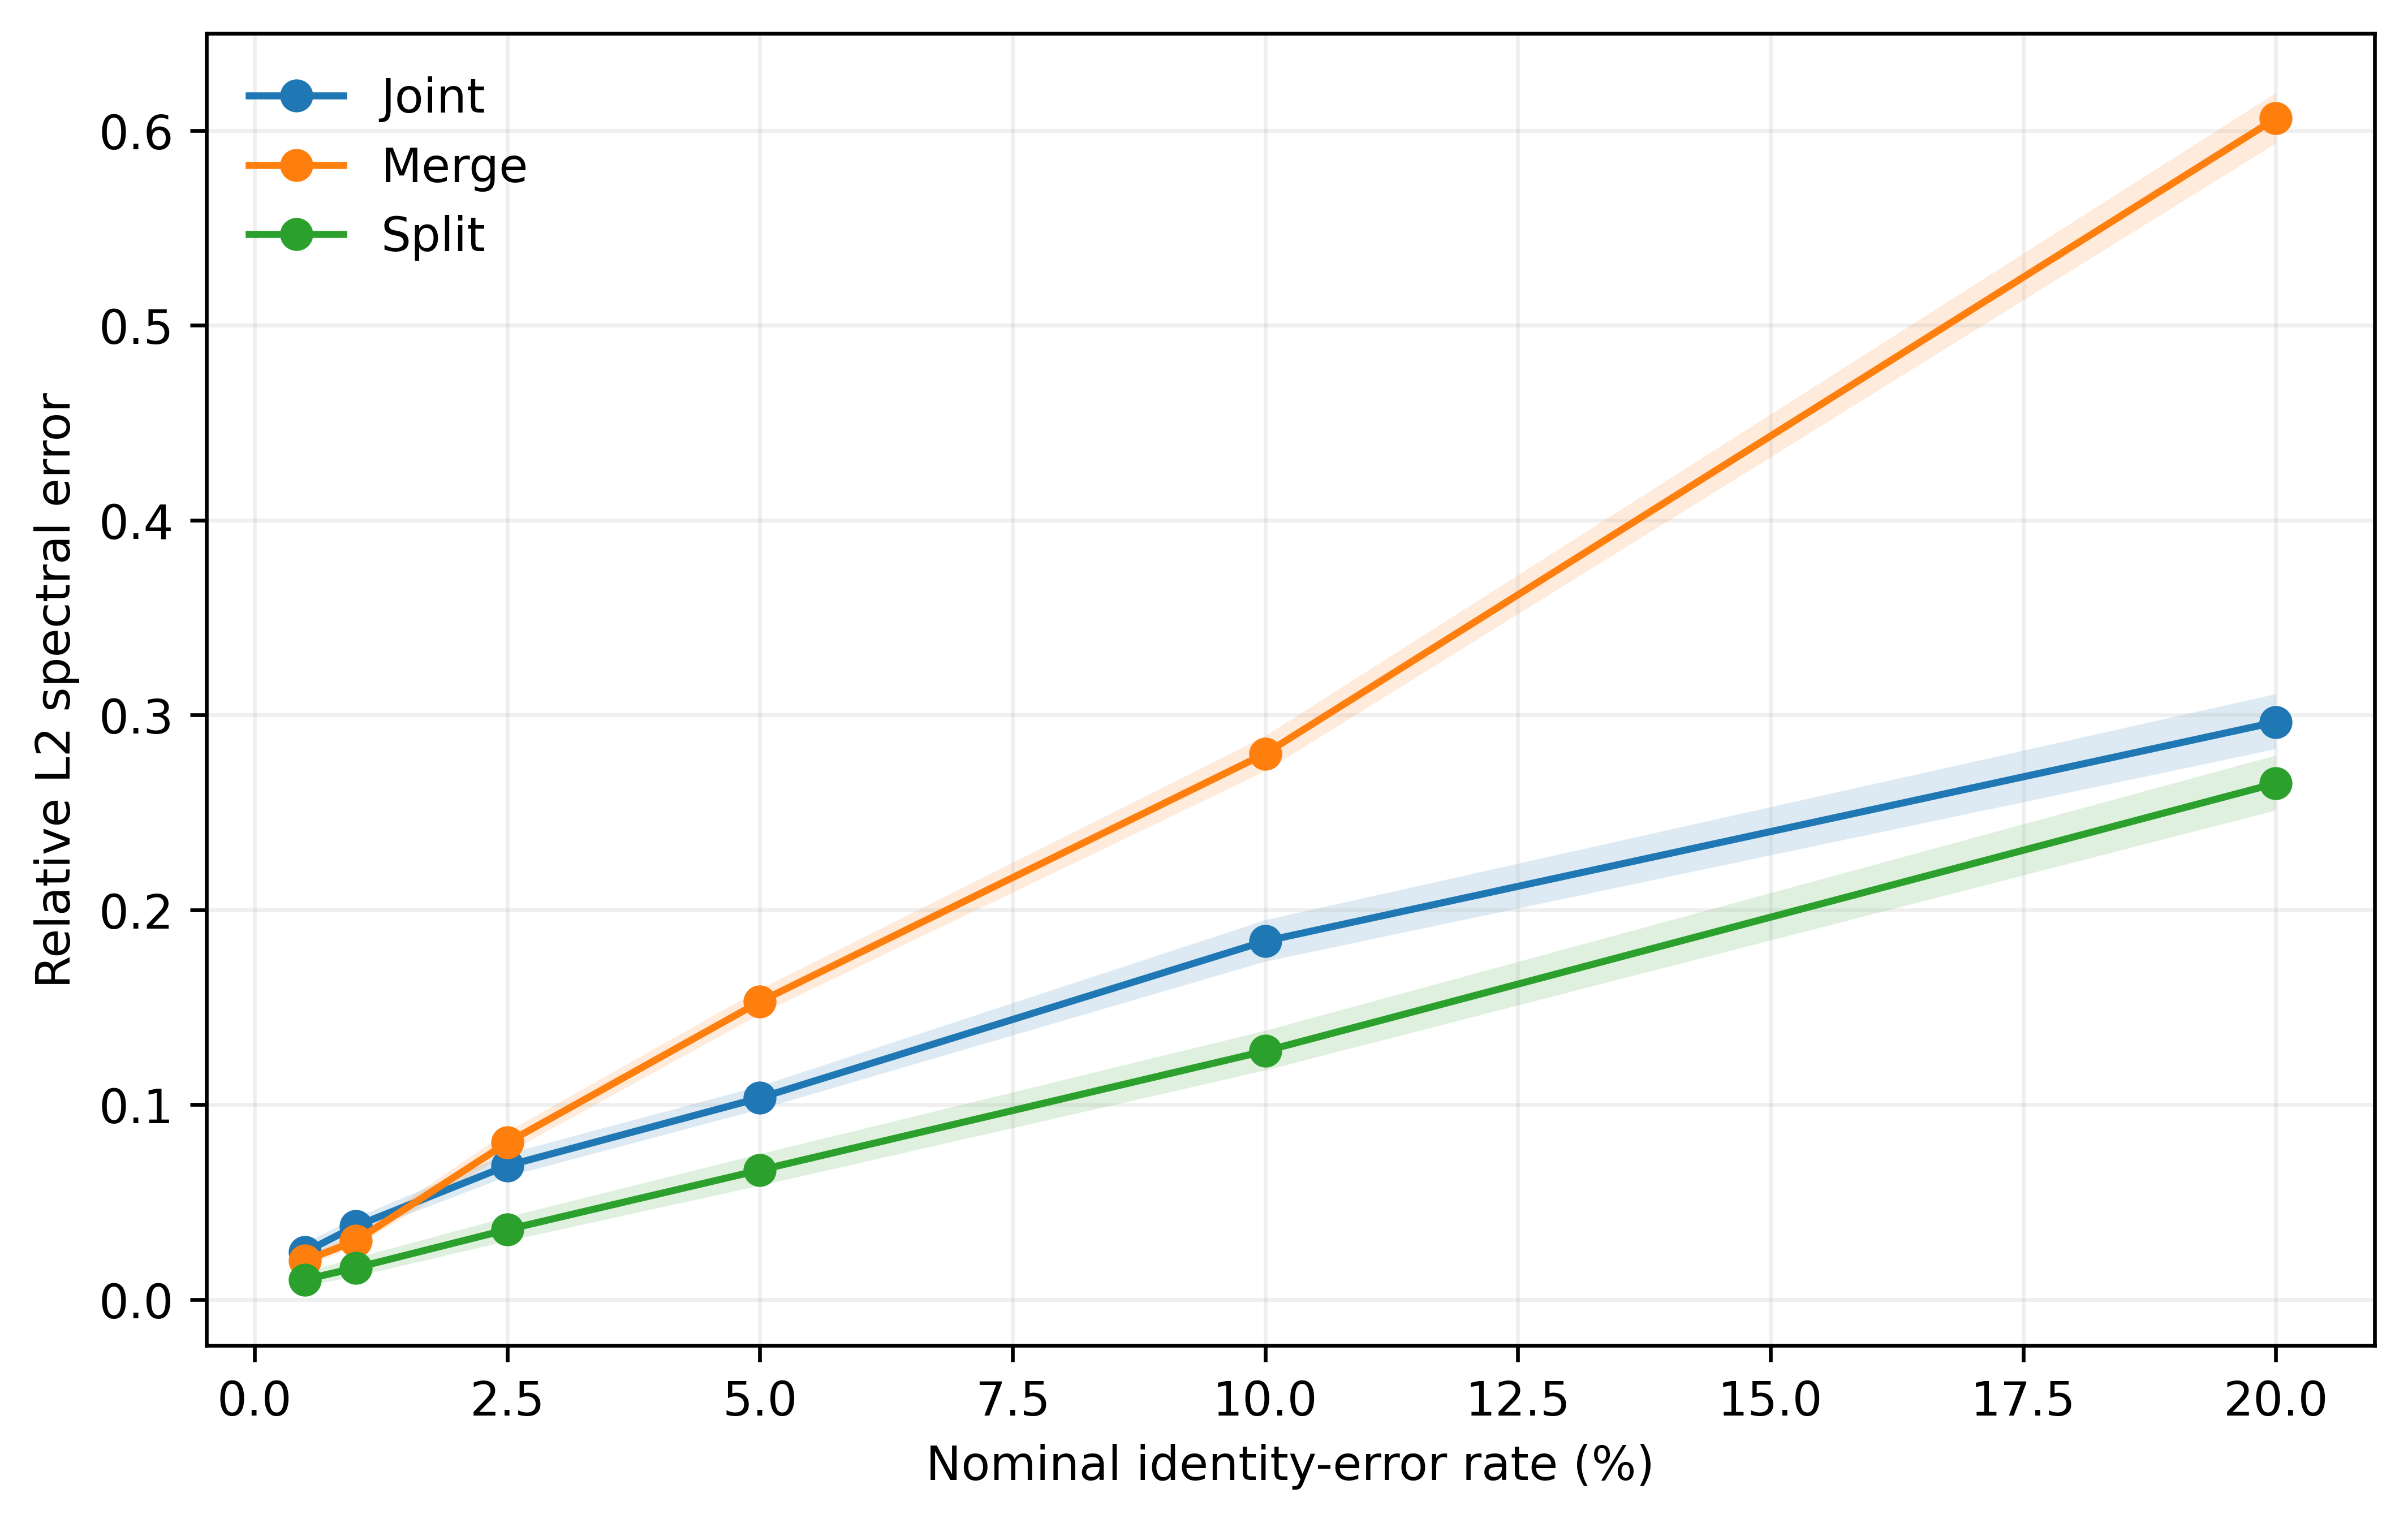

### Figure 2. Dose–response of community instability (ARI)
Loss of adjusted Rand index (ARI) across increasing nominal rates of identity-resolution error under random selection.

`Figure_08A_02a_dose_response_ARI.png`

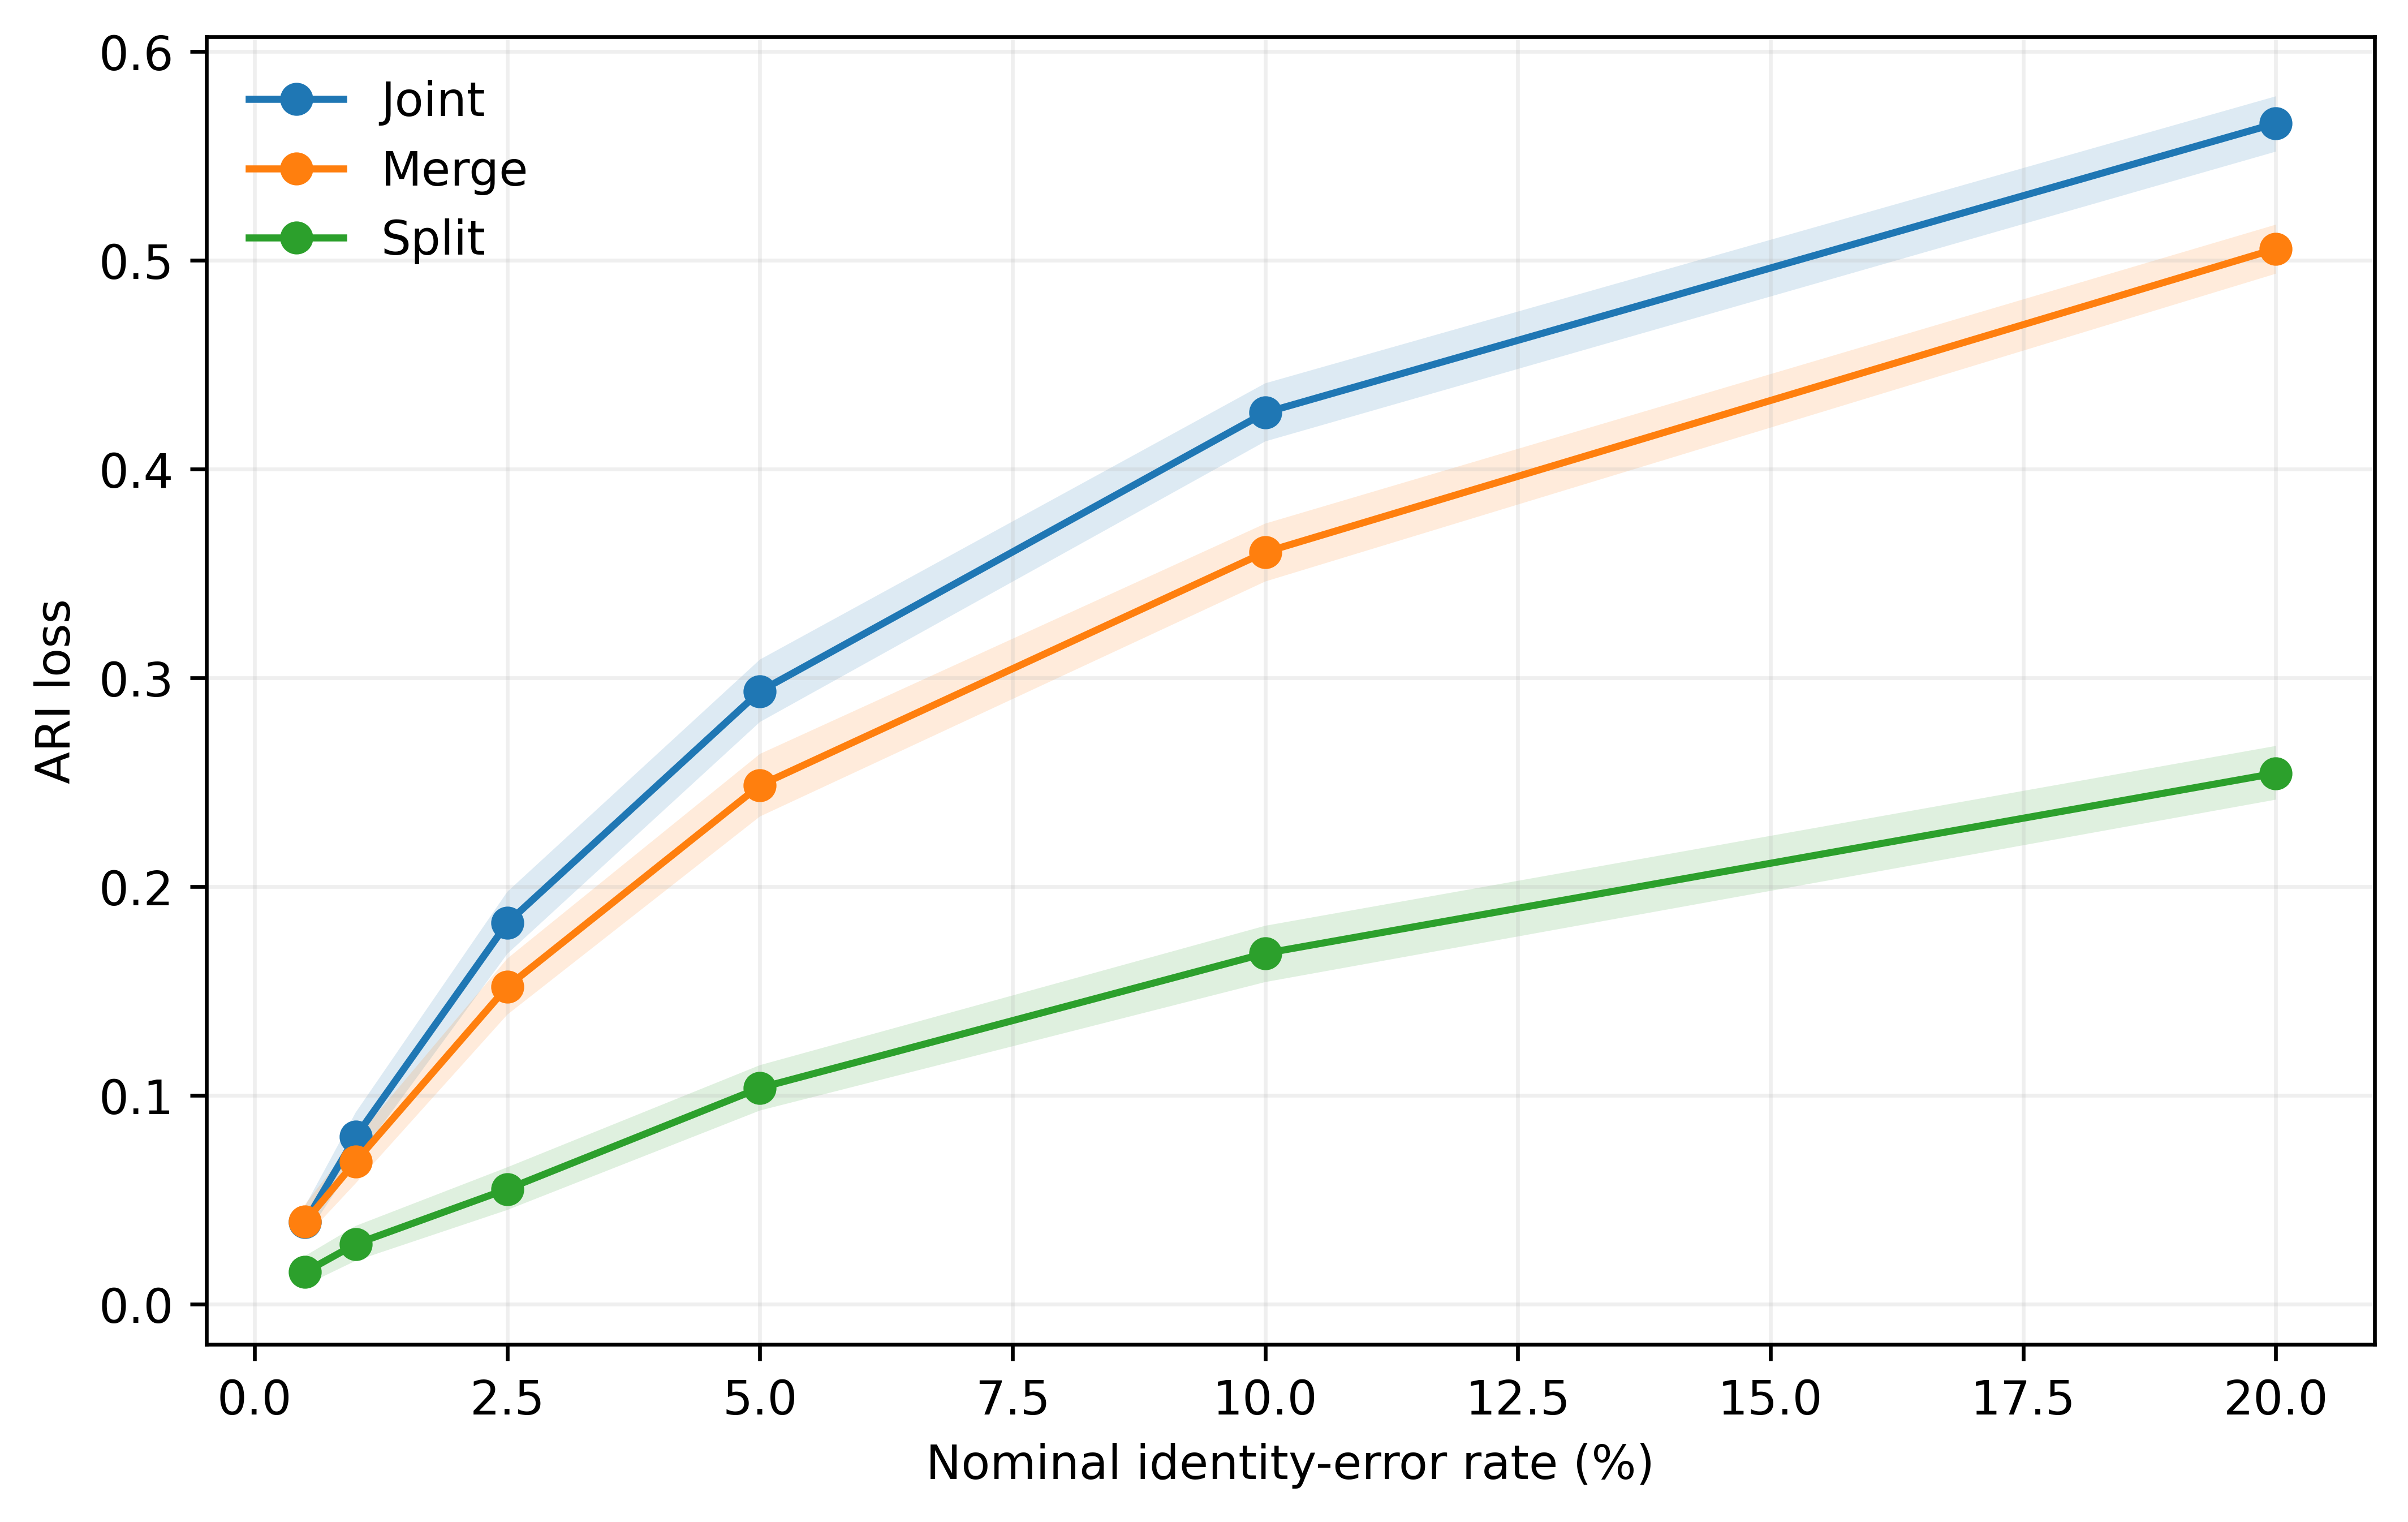

### Figure 3. Structural asymmetry between false merges and false splits
Ratio of false-merge to false-split distortion at matched nominal error rates. Values above 1 indicate greater structural damage from false merges.

`Figure_08A_03_merge_split_ratio.png`

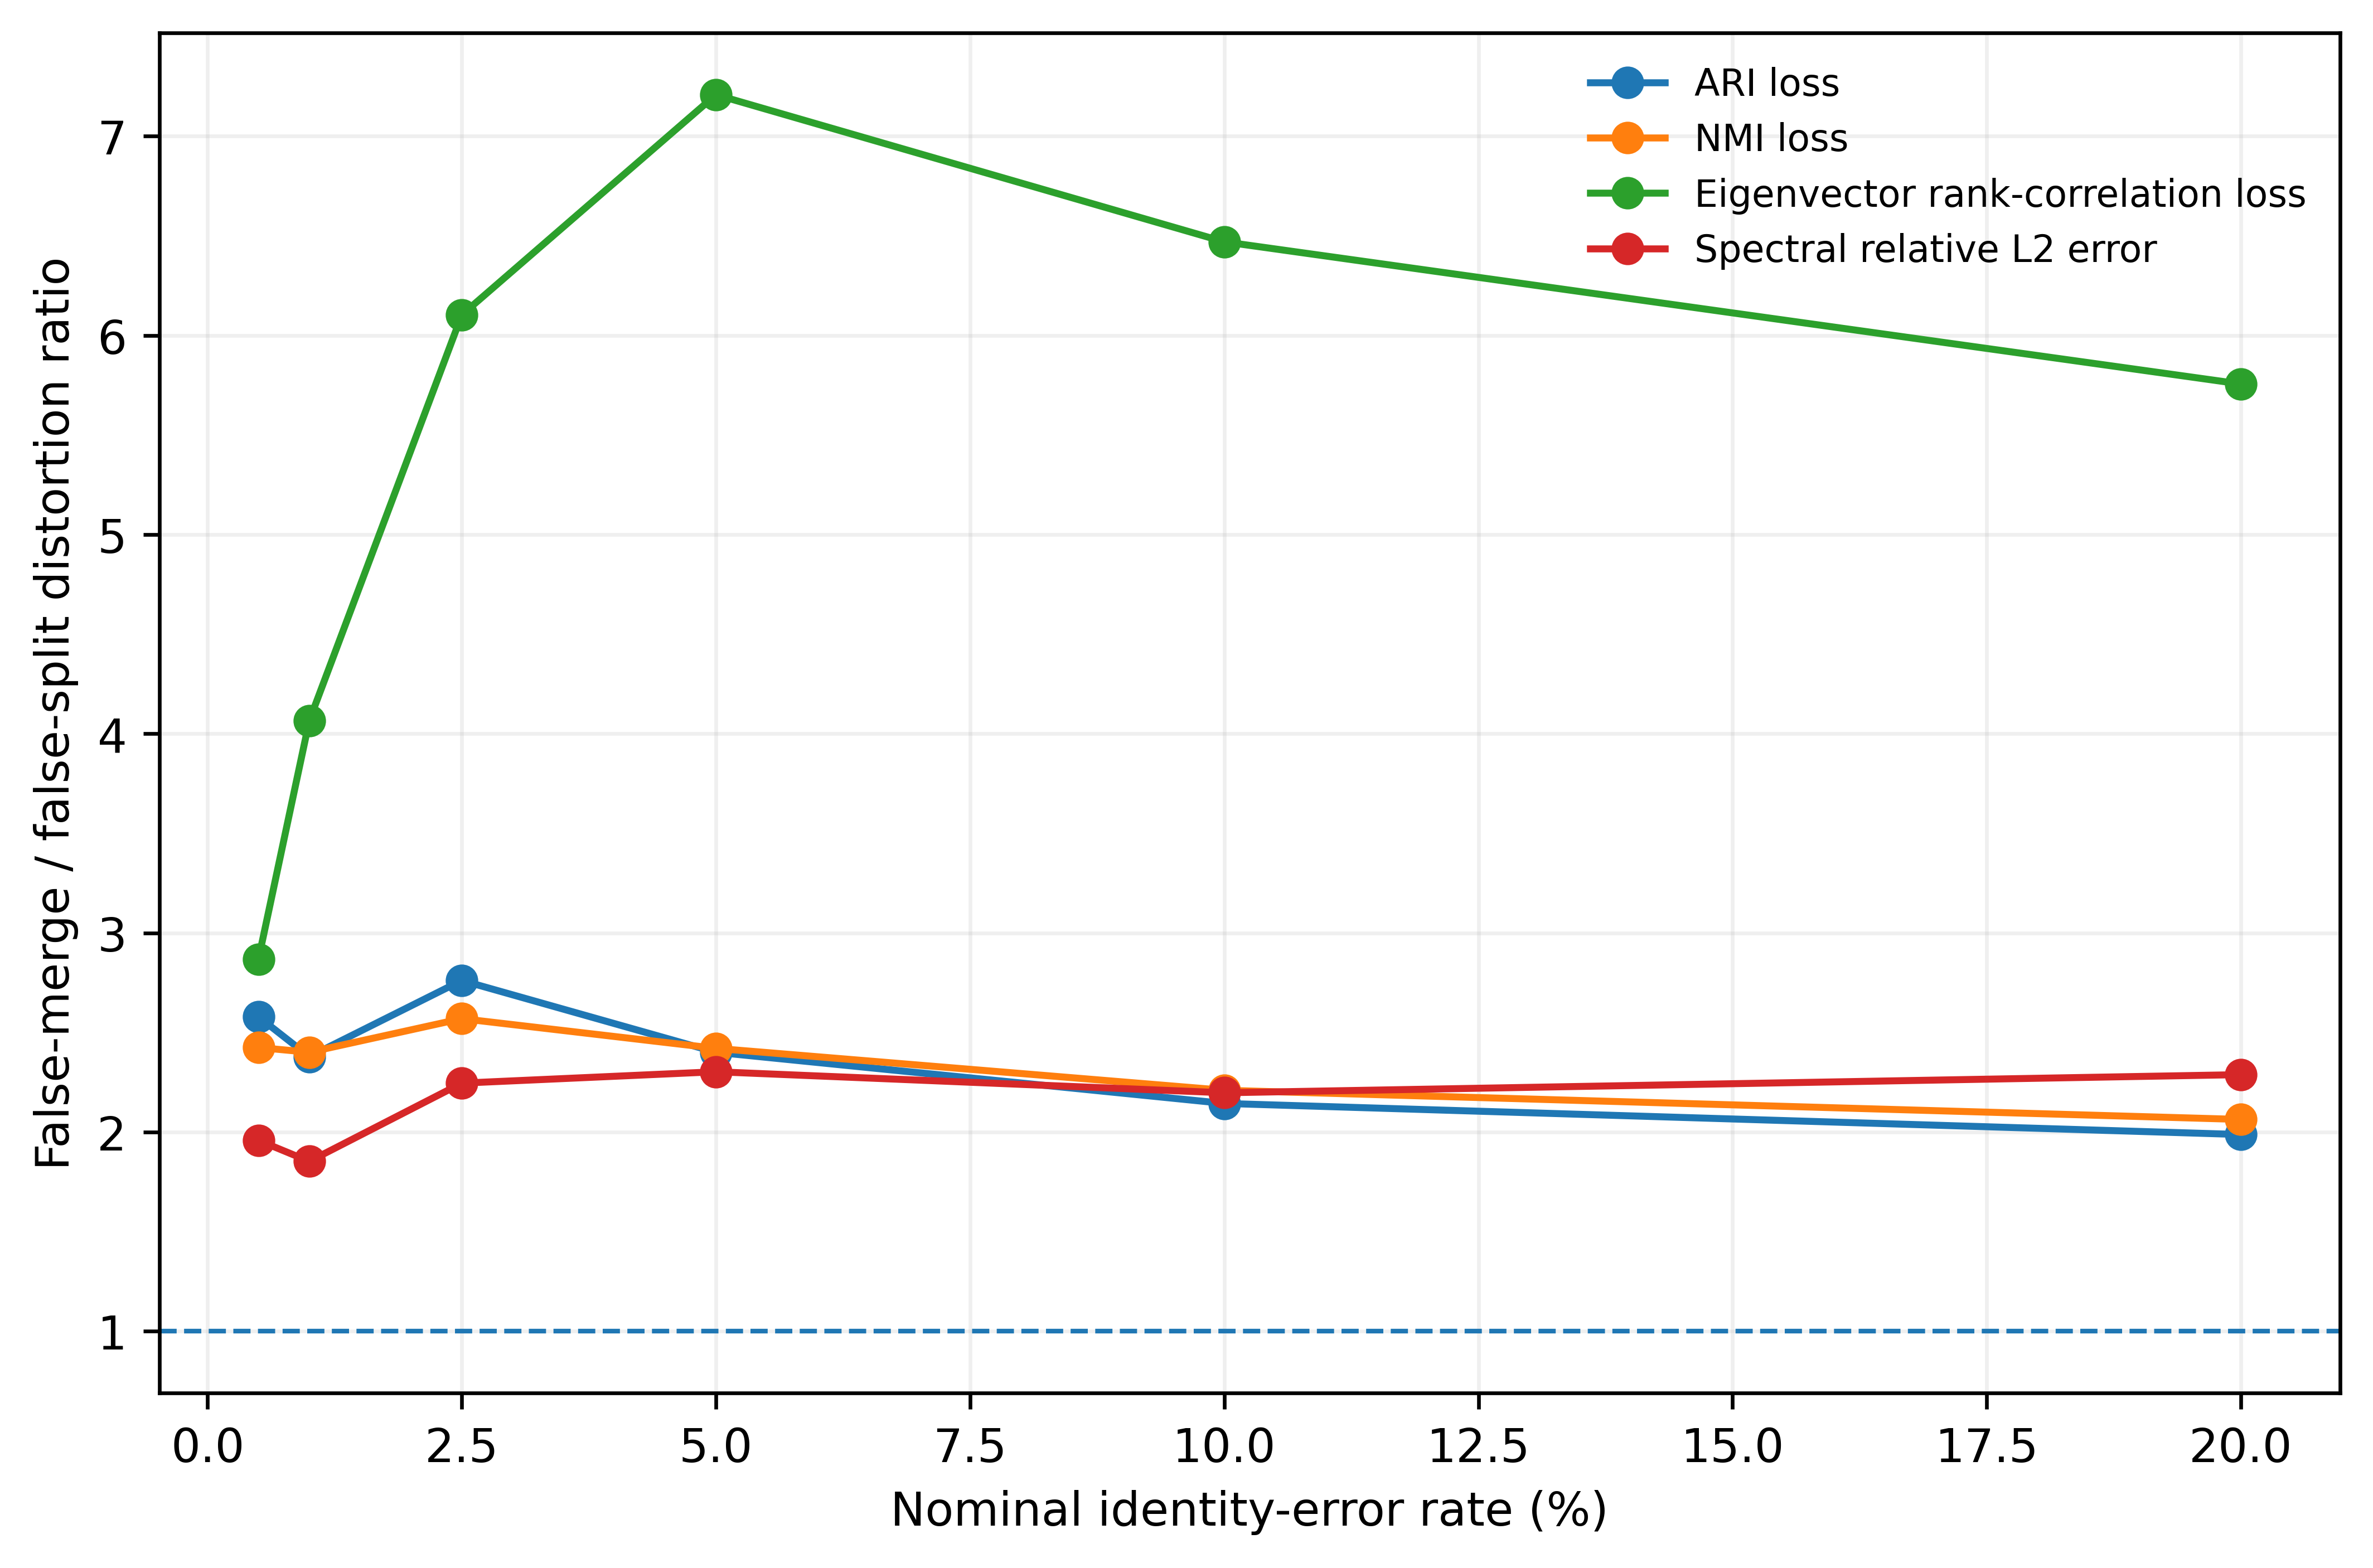

### Figure 4. Effect of targeting structurally important nodes
Mean distortion at 10% false-merge error under random, degree-weighted, and strength-weighted targeting.

`Figure_08A_04_merge_targeting_effect_10pct.png`

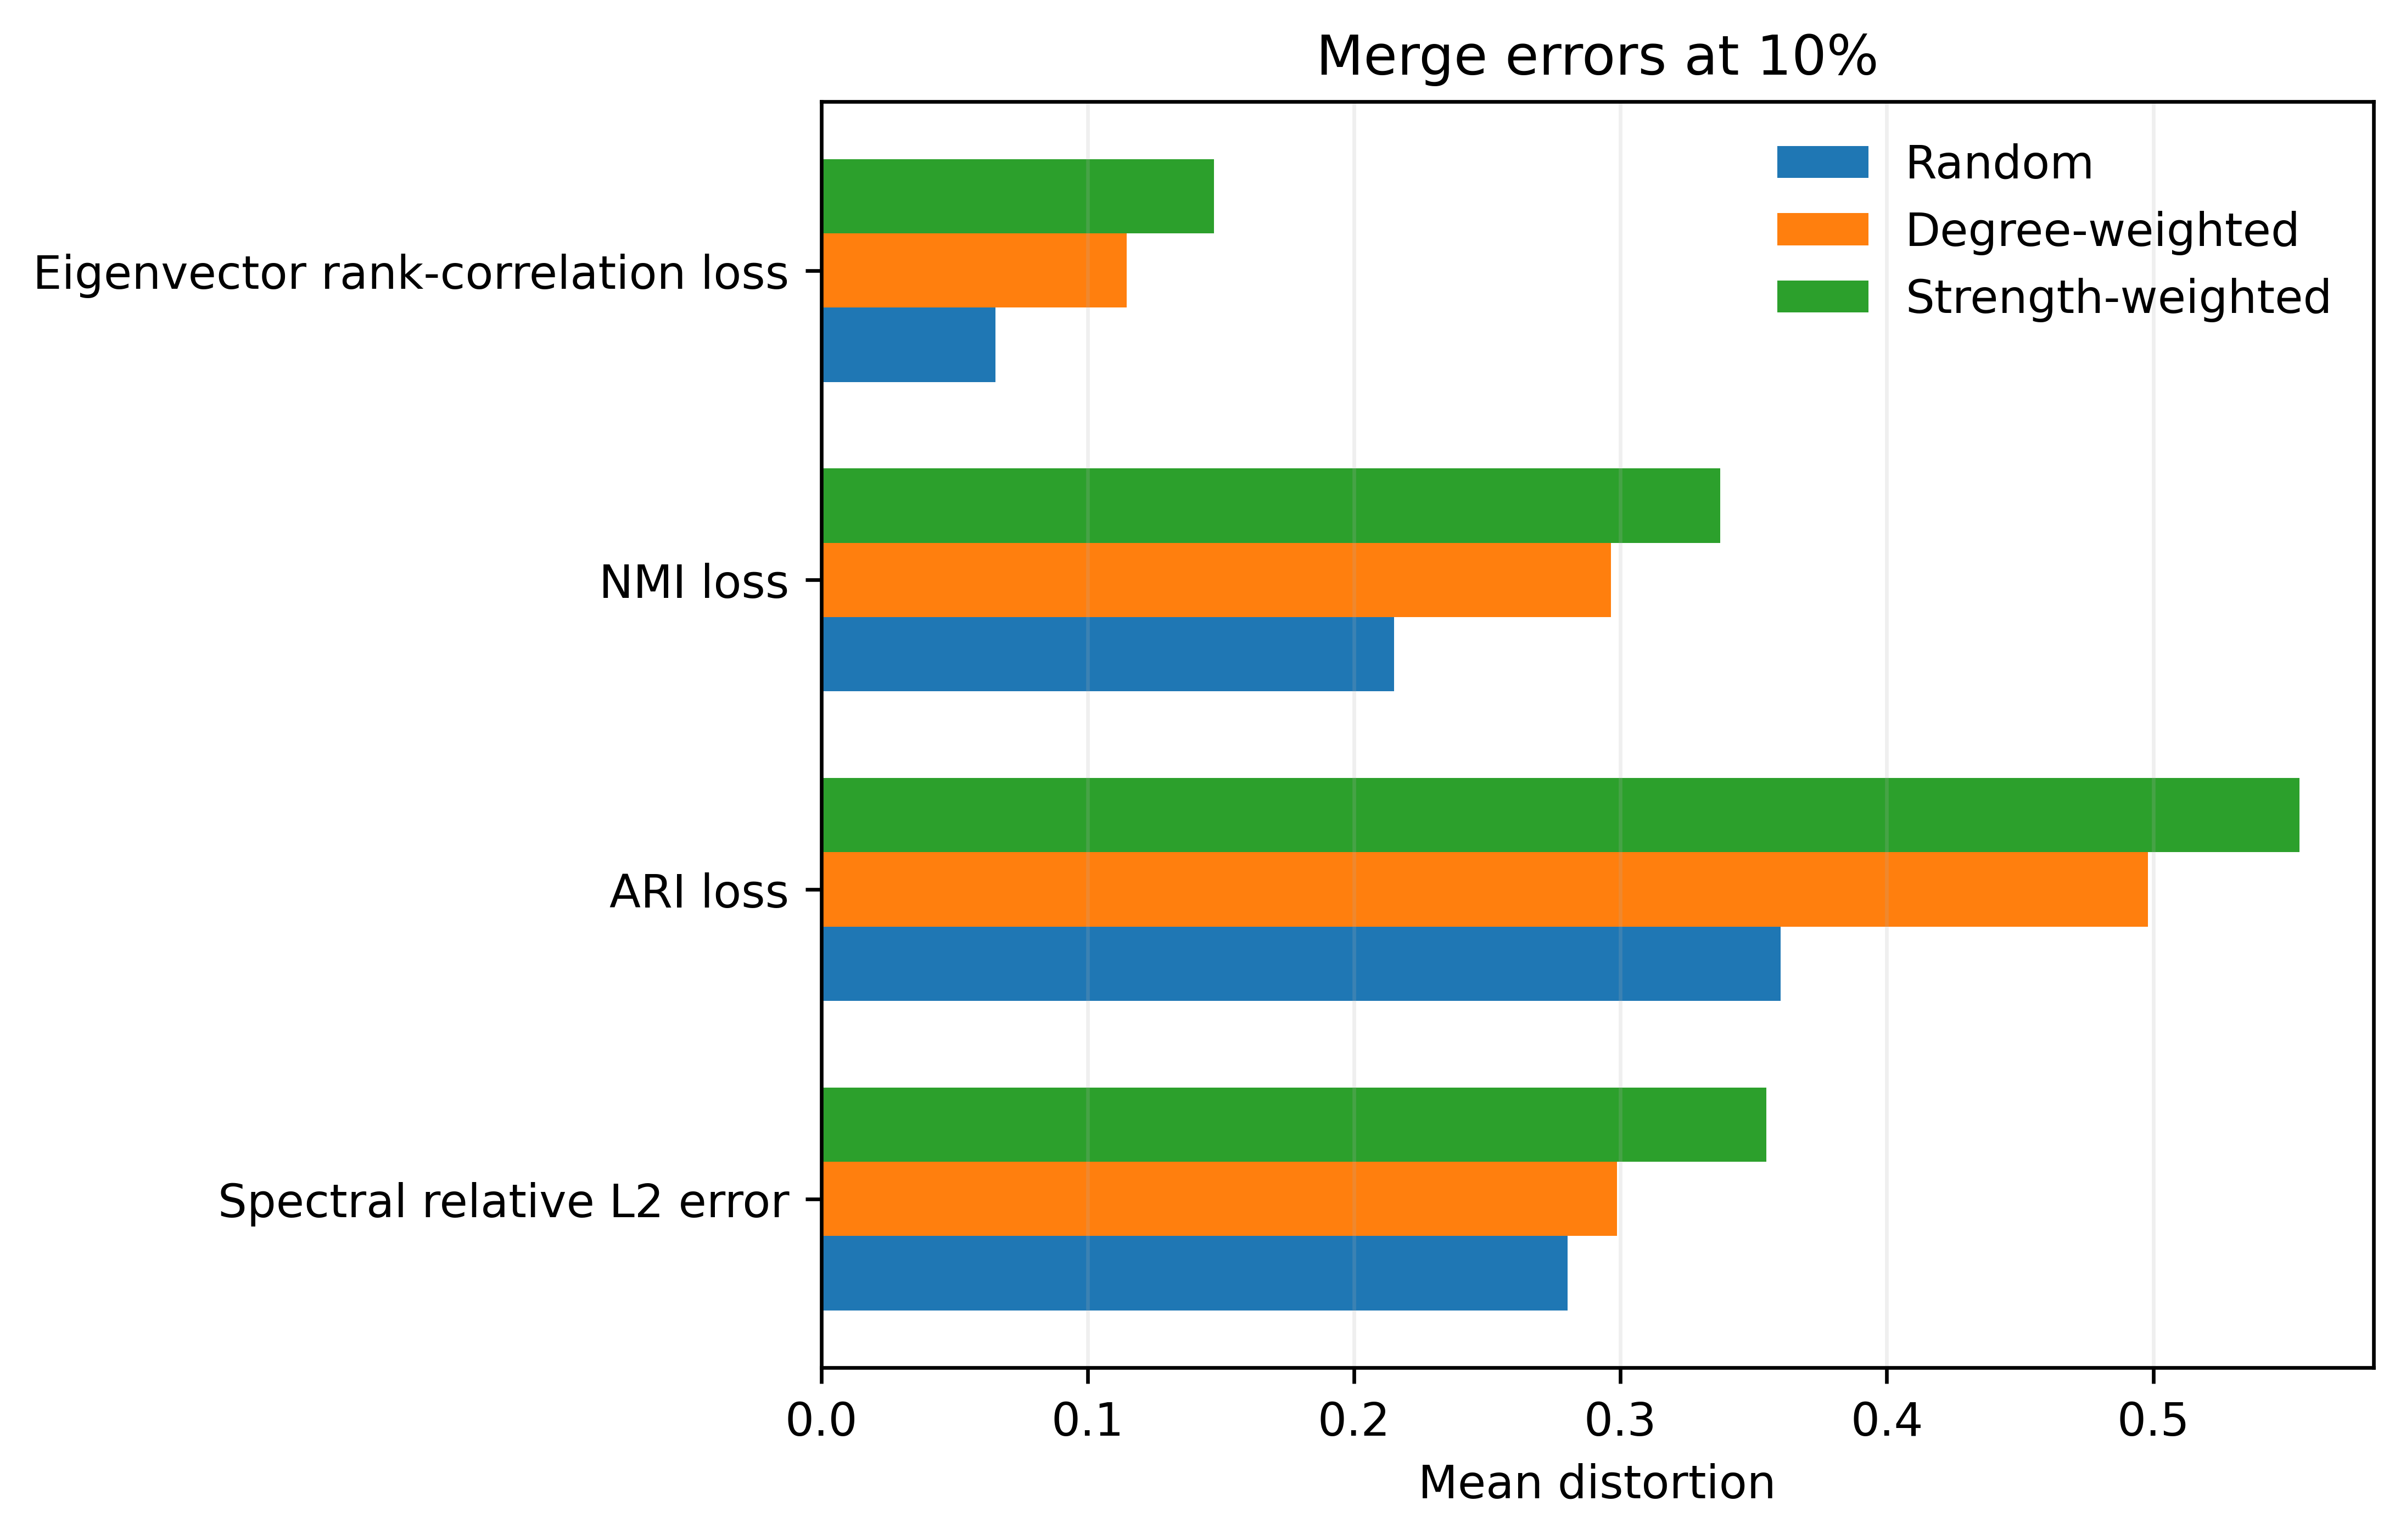

## Supplementary / optional figures

### Supplementary Figure S1. Dose–response of community instability (NMI)
Loss of normalized mutual information (NMI) across increasing nominal identity-resolution error rates.

`Figure_08A_02b_dose_response_NMI.png`

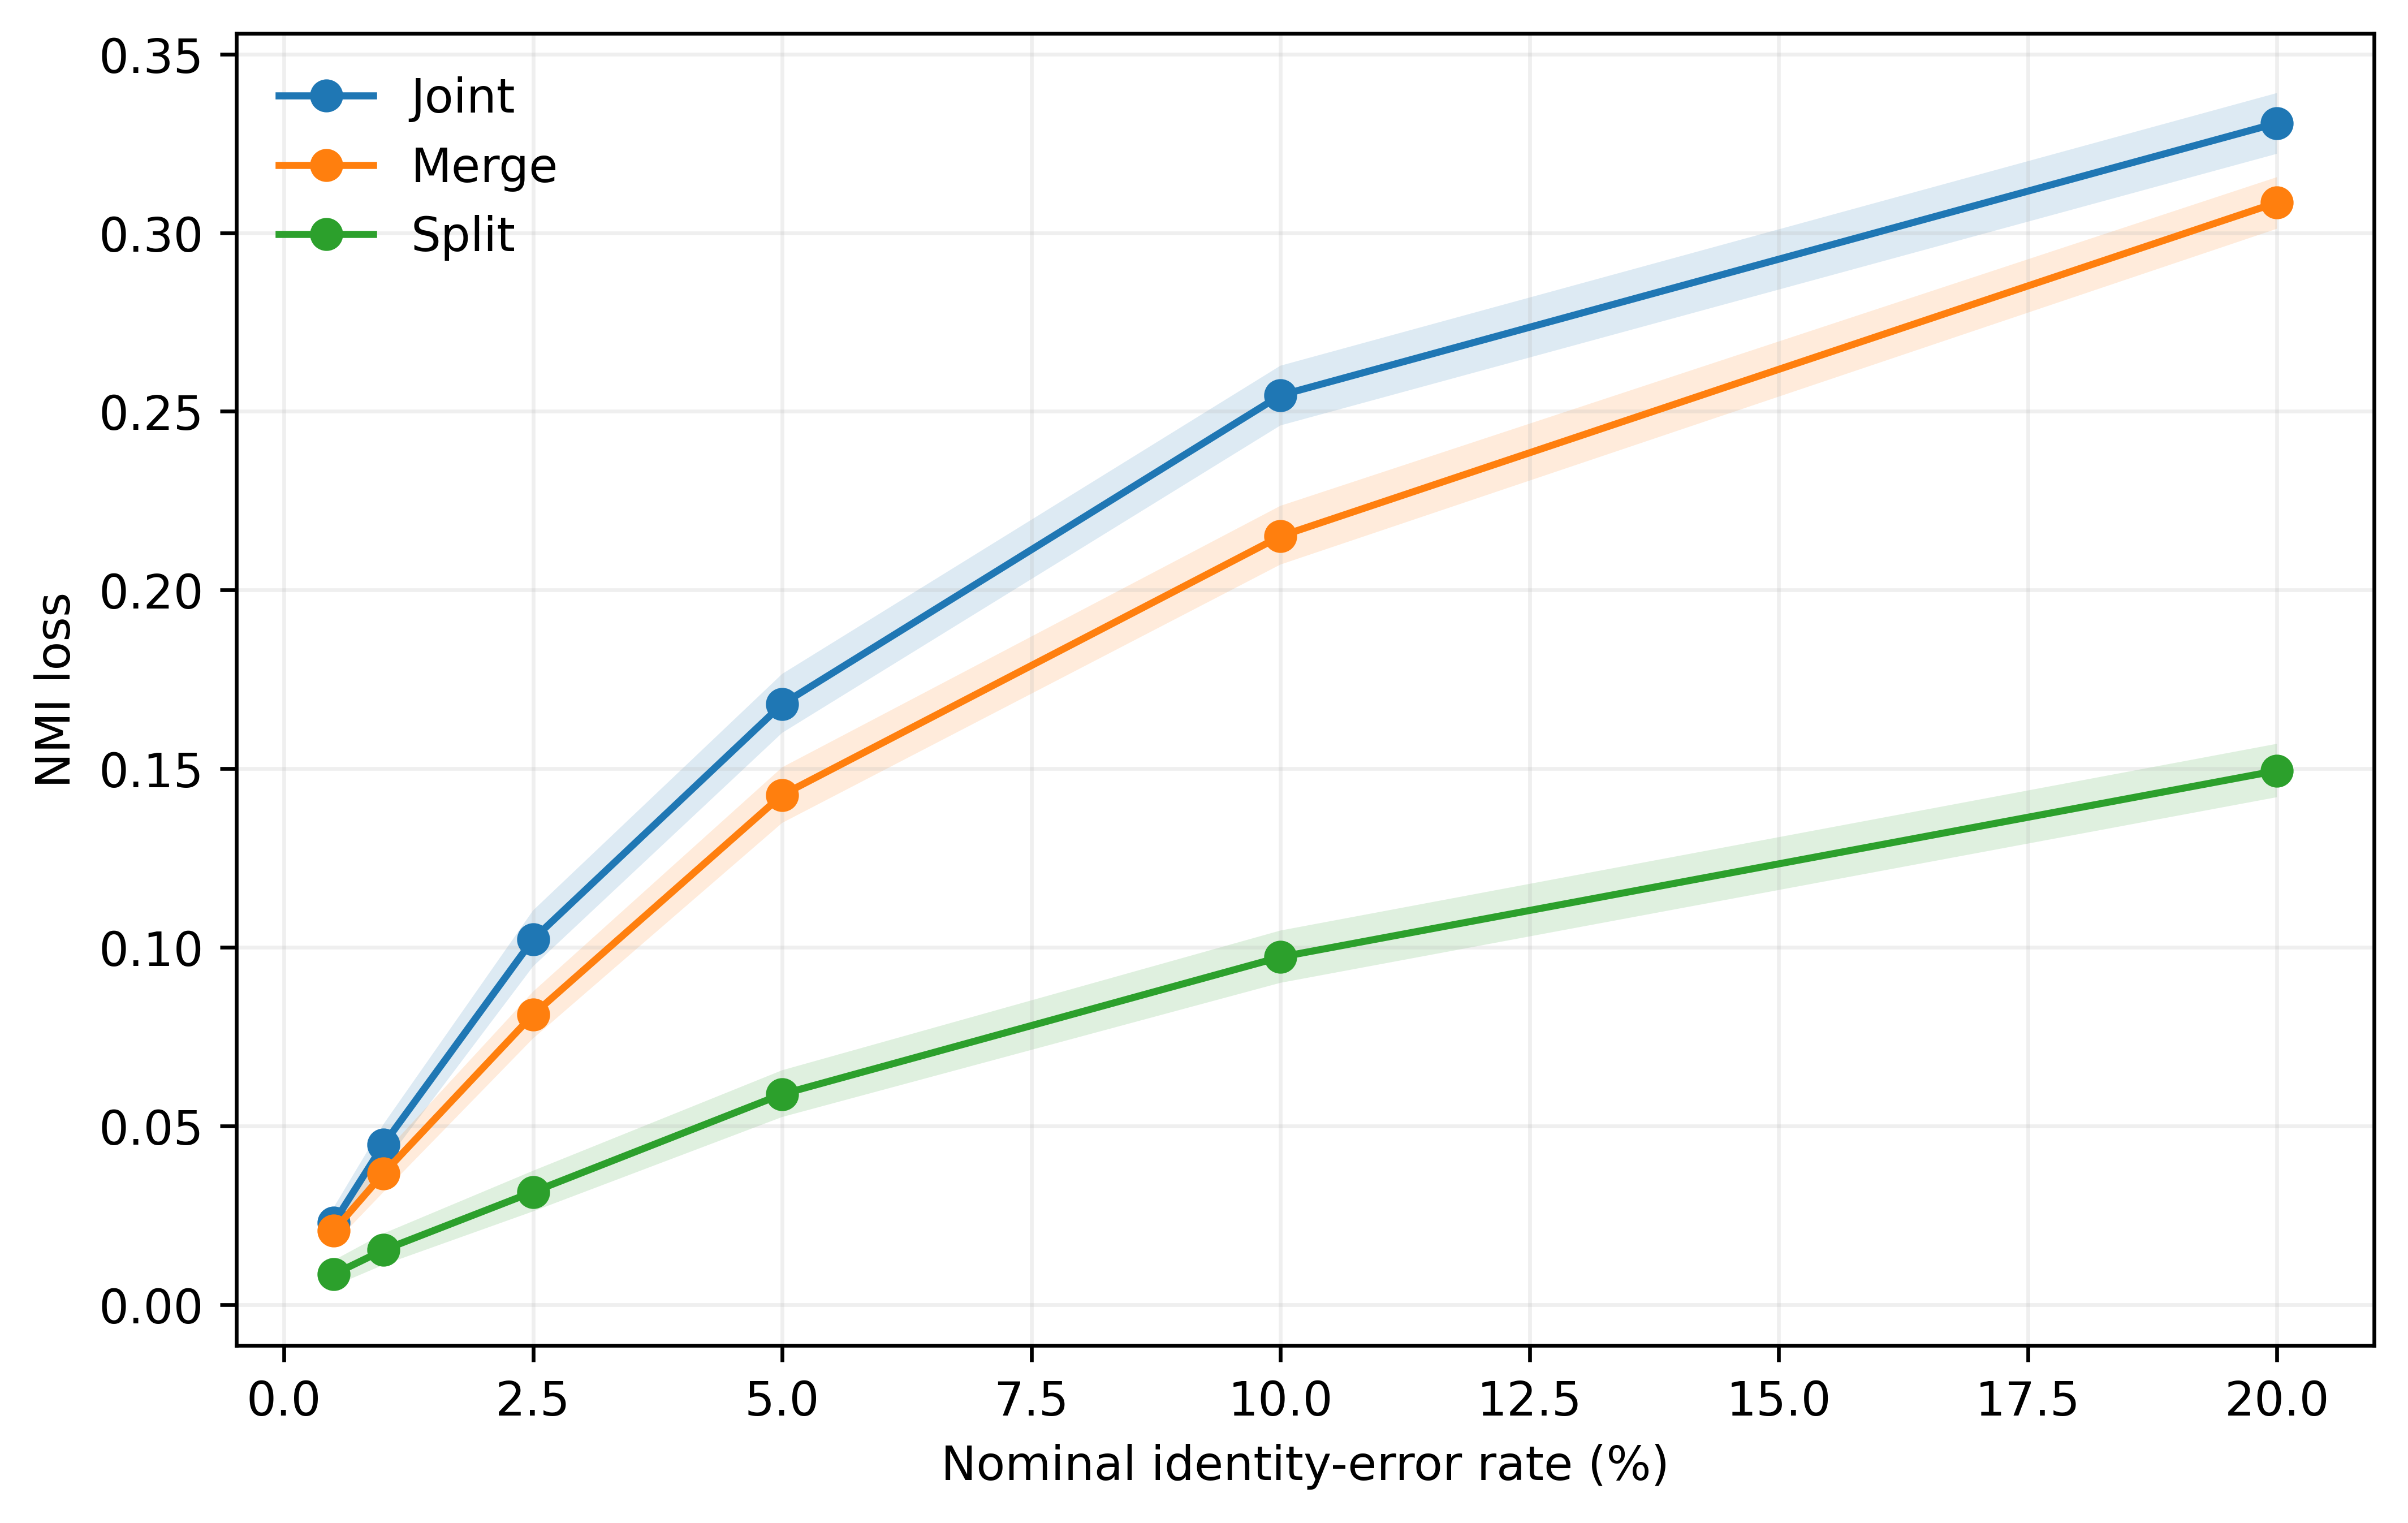

### Supplementary Figure S2. Targeting effect for false splits
Mean distortion at 10% false-split error under random, degree-weighted, and strength-weighted targeting.

`Figure_08A_04_split_targeting_effect_10pct.png`

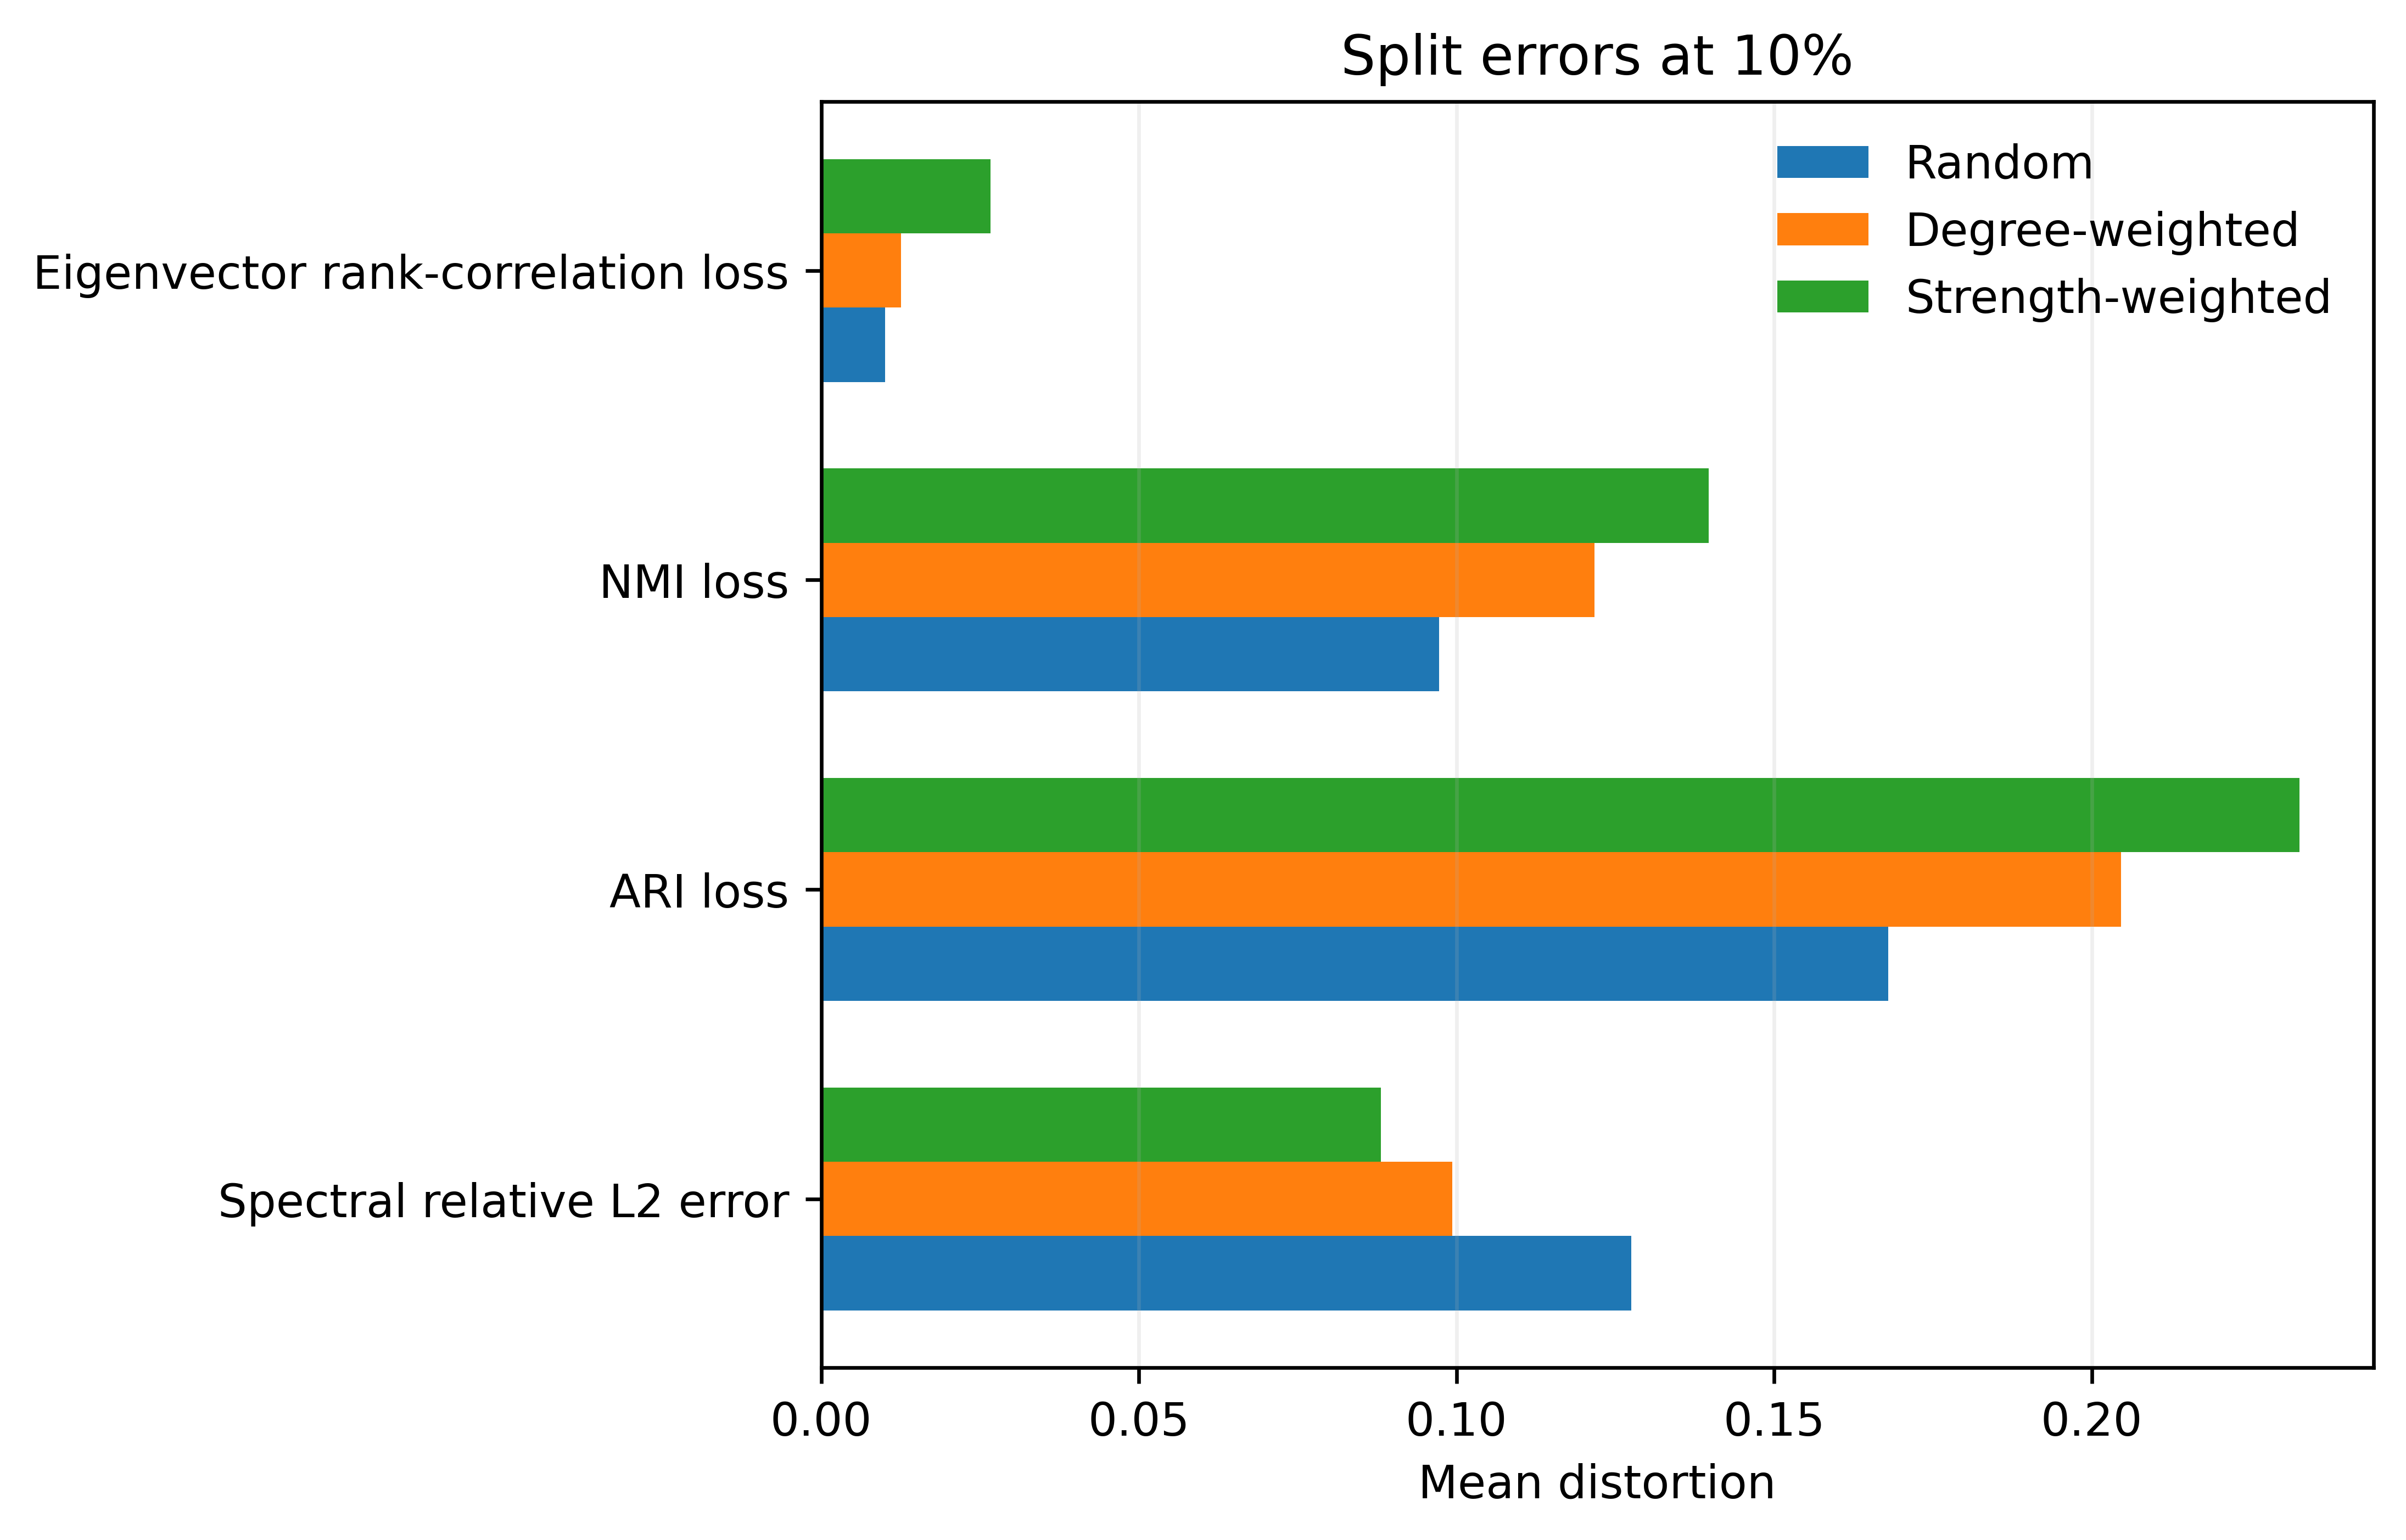

### Supplementary Figure S3. Targeting effect for joint errors
Mean distortion at 10% joint false-merge and false-split error under random, degree-weighted, and strength-weighted targeting.

`Figure_08A_04_joint_targeting_effect_10pct.png`

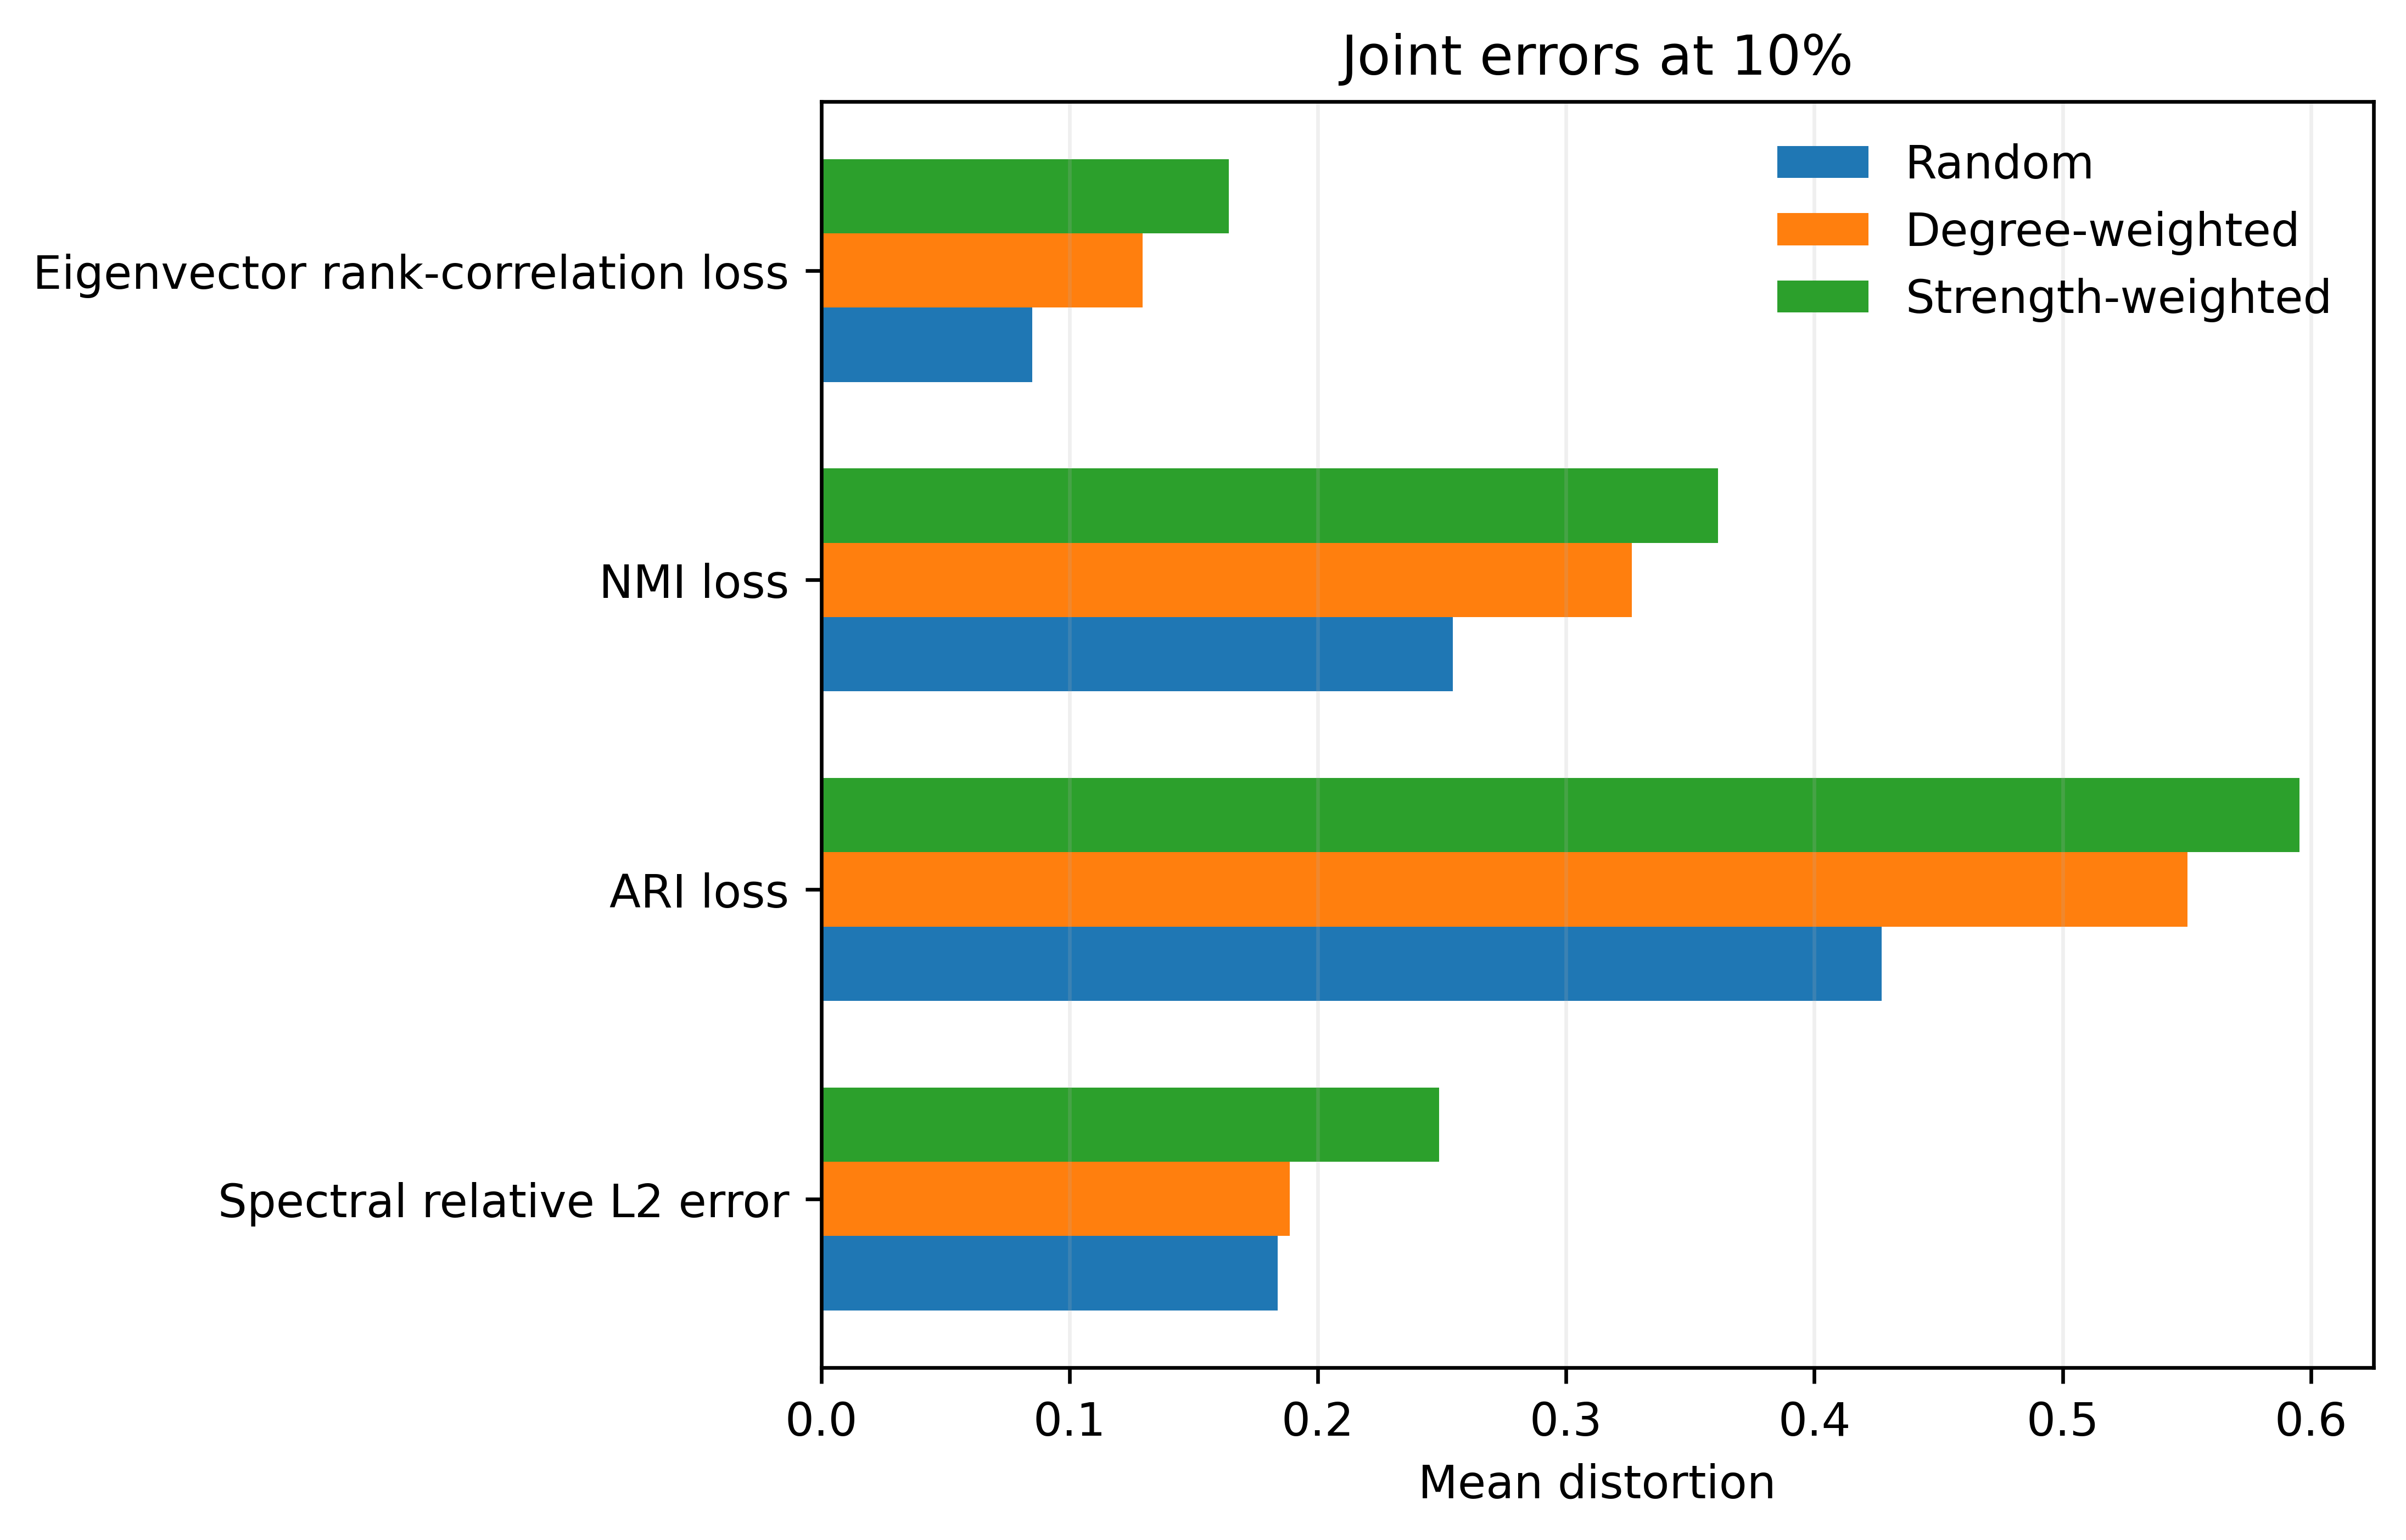

## Display summary
- Main-article figures displayed: **4/4**
- Optional/supplementary figures displayed: **3/3**
- Figure directory: `/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/08A_manuscript_ready_outputs/figures`

**Note:** PNG files are used only for notebook visualization. Use the corresponding PDF files for manuscript production whenever possible.


STATUS: PART_8B_COMPLETE


In [ ]:
# Parte_08B_Display_Manuscript_Figures_in_Colab.py
#
# Journal of Informetrics — display manuscript figures inline in Google Colab
#
# PURPOSE
# Show the figures generated in Part 8A directly in the notebook, with concise
# manuscript-oriented captions. No new analysis is performed.
#
# The script separates:
#   MAIN ARTICLE CANDIDATES
#   SUPPLEMENTARY / OPTIONAL FIGURES
#
# It uses the high-resolution PNG files for inline display. PDF files remain the
# preferred publication/export format.

from pathlib import Path

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

from IPython.display import display, Image, Markdown

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
FIG = ROOT / "08A_manuscript_ready_outputs" / "figures"

if not FIG.exists():
    raise FileNotFoundError(FIG)

# ======================================================================================
# 1. Figure registry
# ======================================================================================

MAIN_FIGURES = [
    {
        "file": "Figure_08A_01_dose_response_spectral.png",
        "title": "Figure 1. Dose–response of spectral distortion",
        "caption": (
            "Relative L2 spectral error across increasing nominal rates of false merges, "
            "false splits, and joint identity-resolution errors under random selection."
        ),
    },
    {
        "file": "Figure_08A_02a_dose_response_ARI.png",
        "title": "Figure 2. Dose–response of community instability (ARI)",
        "caption": (
            "Loss of adjusted Rand index (ARI) across increasing nominal rates of "
            "identity-resolution error under random selection."
        ),
    },
    {
        "file": "Figure_08A_03_merge_split_ratio.png",
        "title": "Figure 3. Structural asymmetry between false merges and false splits",
        "caption": (
            "Ratio of false-merge to false-split distortion at matched nominal error rates. "
            "Values above 1 indicate greater structural damage from false merges."
        ),
    },
    {
        "file": "Figure_08A_04_merge_targeting_effect_10pct.png",
        "title": "Figure 4. Effect of targeting structurally important nodes",
        "caption": (
            "Mean distortion at 10% false-merge error under random, degree-weighted, "
            "and strength-weighted targeting."
        ),
    },
]

OPTIONAL_FIGURES = [
    {
        "file": "Figure_08A_02b_dose_response_NMI.png",
        "title": "Supplementary Figure S1. Dose–response of community instability (NMI)",
        "caption": (
            "Loss of normalized mutual information (NMI) across increasing nominal "
            "identity-resolution error rates."
        ),
    },
    {
        "file": "Figure_08A_04_split_targeting_effect_10pct.png",
        "title": "Supplementary Figure S2. Targeting effect for false splits",
        "caption": (
            "Mean distortion at 10% false-split error under random, degree-weighted, "
            "and strength-weighted targeting."
        ),
    },
    {
        "file": "Figure_08A_04_joint_targeting_effect_10pct.png",
        "title": "Supplementary Figure S3. Targeting effect for joint errors",
        "caption": (
            "Mean distortion at 10% joint false-merge and false-split error under random, "
            "degree-weighted, and strength-weighted targeting."
        ),
    },
]

# ======================================================================================
# 2. Helpers
# ======================================================================================

def show_figure(entry, width=1100):
    path = FIG / entry["file"]

    if not path.exists():
        display(Markdown(
            f"### {entry['title']}\n"
            f"**File not found:** `{path}`"
        ))
        return False

    display(Markdown(
        f"### {entry['title']}\n"
        f"{entry['caption']}\n\n"
        f"`{entry['file']}`"
    ))
    display(Image(filename=str(path), width=width))
    return True

# ======================================================================================
# 3. Display
# ======================================================================================

display(Markdown(
    "# Manuscript figures — Journal of Informetrics\n"
    "The figures below are loaded directly from the frozen Part 8A outputs. "
    "No new calculations are performed."
))

display(Markdown("## Main-article candidates"))

main_ok = 0
for entry in MAIN_FIGURES:
    main_ok += int(show_figure(entry))

display(Markdown("## Supplementary / optional figures"))

optional_ok = 0
for entry in OPTIONAL_FIGURES:
    optional_ok += int(show_figure(entry))

display(Markdown(
    "## Display summary\n"
    f"- Main-article figures displayed: **{main_ok}/{len(MAIN_FIGURES)}**\n"
    f"- Optional/supplementary figures displayed: **{optional_ok}/{len(OPTIONAL_FIGURES)}**\n"
    f"- Figure directory: `{FIG}`\n\n"
    "**Note:** PNG files are used only for notebook visualization. "
    "Use the corresponding PDF files for manuscript production whenever possible."
))

print("\nSTATUS: PART_8B_COMPLETE")


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json, math
import numpy as np
import pandas as pd

try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
except Exception:
    pass

ROOT = Path('/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003')
REF_FILE = ROOT/'04C_target_specific_reference_audit/tables/Table_04C_04_candidate_reference_labels.csv'
SPLIT_FILE = ROOT/'05C_target_specific_reference_benchmark/tables/Table_05C_02_target_split.csv'
P6D = ROOT/'06D_incumbent_aware_multievidence/tables'
FEATURE_FILE = P6D/'Table_06D_01_feature_frame.csv'
GRID_FILE = P6D/'Table_06D_02_validation_rule_grid.csv'
SELECTED_FILE = P6D/'Table_06D_03_selected_configuration.csv'
TEST_FILE = P6D/'Table_06D_11_test_predictions.csv'
OUT = ROOT/'09A_v3_fast_reviewer_sensitivity'
TABLE = OUT/'tables'; ART = OUT/'artifacts'
TABLE.mkdir(parents=True, exist_ok=True); ART.mkdir(parents=True, exist_ok=True)
for p in [REF_FILE,SPLIT_FILE,FEATURE_FILE,GRID_FILE,SELECTED_FILE,TEST_FILE]:
    if not p.exists(): raise FileNotFoundError(p)

SEED=20261004
POWER_REPS=1000
PARAM_KEYS=[
    'rescue_min_coauthor_ids','rescue_min_coauthor_recall','rescue_exact_aff_min',
    'rescue_exact_strong_coauthors','rescue_variant_name_min','rescue_variant_aff_min',
    'use_veto','veto_incumbent_name_max','veto_incumbent_aff_max'
]

def robust_bool(x):
    if isinstance(x,(bool,np.bool_)): return bool(x)
    if pd.isna(x): return False
    return str(x).strip().lower() in {'1','true','t','yes','y'}

def safe_div(a,b): return a/b if b else np.nan

def metric_counts(tp,tn,fp,fn):
    p=safe_div(tp,tp+fp); r=safe_div(tp,tp+fn); sp=safe_div(tn,tn+fp)
    f1=safe_div(2*p*r,p+r) if pd.notna(p) and pd.notna(r) and (p+r)>0 else np.nan
    ba=np.nanmean([r,sp])
    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc=(tp*tn-fp*fn)/den if den else np.nan
    return dict(precision=p,recall=r,specificity=sp,F1=f1,balanced_accuracy=ba,MCC=mcc,
                FPR=safe_div(fp,fp+tn),FNR=safe_div(fn,fn+tp))

def metrics(y,p):
    y=np.asarray(y,int); p=np.asarray(p,int)
    tp=int(((y==1)&(p==1)).sum()); tn=int(((y==0)&(p==0)).sum())
    fp=int(((y==0)&(p==1)).sum()); fn=int(((y==1)&(p==0)).sum())
    return dict(TP=tp,TN=tn,FP=fp,FN=fn,**metric_counts(tp,tn,fp,fn))

def apply_rule(df,cfg):
    x=df.copy()
    structural=(x['f_coauthor_id_overlap']>=cfg['rescue_min_coauthor_ids']) | (x['f_coauthor_id_recall']>=cfg['rescue_min_coauthor_recall'])
    rescue_exact=(x['is_incumbent'].eq(0)&x['f_exact_any'].eq(1)&structural&(x['f_aff']>=cfg['rescue_exact_aff_min']) &
                  (x['is_unique_top_f_coauthor_id_overlap'].map(robust_bool) | (x['f_coauthor_id_overlap']>=cfg['rescue_exact_strong_coauthors'])))
    rescue_variant=(x['is_incumbent'].eq(0)&x['f_exact_any'].eq(0)&x['f_aini'].eq(1)&
                    (x['f_name_sim']>=cfg['rescue_variant_name_min'])&structural&(x['f_aff']>=cfg['rescue_variant_aff_min']))
    rescue=rescue_exact|rescue_variant
    rescued_target=rescue.astype(int).groupby(x['target_key']).transform('max').astype(bool)
    incumbent_weak=(x['is_incumbent'].eq(1)&(x['f_name_sim']<cfg['veto_incumbent_name_max'])&
                    (x['f_aff']<=cfg['veto_incumbent_aff_max'])&x['f_coauthor_id_overlap'].eq(0)&rescued_target)
    pred=x['is_incumbent'].eq(1)|rescue
    if int(cfg['use_veto'])==1: pred=pred&(~incumbent_weak)
    return pred.astype(int)

ref=pd.read_csv(REF_FILE); split=pd.read_csv(SPLIT_FILE); f=pd.read_csv(FEATURE_FILE); grid=pd.read_csv(GRID_FILE); selected=pd.read_csv(SELECTED_FILE).iloc[0]; test=pd.read_csv(TEST_FILE)
for df in [ref,split,f,test]: df['target_key']=df['target_key'].astype(str)
if 'is_incumbent' not in f.columns: f['is_incumbent']=f['is_incumbent_candidate'].map(robust_bool).astype(int)
if 'is_incumbent' not in test.columns: test['is_incumbent']=test['is_incumbent_candidate'].map(robust_bool).astype(int)
base_cfg={k:float(selected[k]) for k in PARAM_KEYS}

# 1) Abstention sensitivity
te_targets=set(split.loc[split['split'].eq('test'),'target_key'].astype(str))
r=ref[ref['target_key'].isin(te_targets)].copy()
r['lab']=r['target_specific_reference_label'].astype(str).str.upper()
r['y']=r['lab'].eq('POSITIVE').astype(int)
r['B7']=r['is_incumbent_candidate'].map(robust_bool).astype(int)
exact_lookup={(str(t),str(c)):int(e) for t,c,e in zip(f['target_key'],f['candidate_openalex_id'].astype(str),f['f_exact_any'])}
r['B1']=[exact_lookup.get((str(t),str(c)),0) for t,c in zip(r['target_key'],r['candidate_openalex_id'].astype(str))]
rows=[]
for nm,col in [('B1_ANY_NAME_EXACT','B1'),('B7_OPENALEX_INCUMBENT','B7')]:
    rows.append(dict(method=nm,pairs=len(r),positives=int(r['y'].sum()),negatives=int((1-r['y']).sum()),**metrics(r['y'],r[col])))
abst=pd.DataFrame(rows); abst.to_csv(TABLE/'Table_09A_v3_01_unresolved_as_negative.csv',index=False)

# 2) Incorporation ablations
abl=[]
def add_ab(name,df,pred): abl.append(dict(ablation=name,**metrics(df['y_ref'],pred)))
add_ab('P6D_FULL',test,apply_rule(test,base_cfg))
x=test.copy(); x['f_aff']=0.0; add_ab('P6D_NO_AFFILIATION',x,apply_rule(x,base_cfg))
x=test.copy()
for col in ['f_coauthor_id_overlap','f_coauthor_name_overlap','f_coauthor_id_recall','f_coauthor_name_recall']:
    if col in x.columns: x[col]=0.0
x['is_unique_top_f_coauthor_id_overlap']=False
add_ab('P6D_NO_COAUTHOR',x,apply_rule(x,base_cfg))
cfg_nv=dict(base_cfg); cfg_nv['use_veto']=0.0; add_ab('P6D_NO_VETO',test,apply_rule(test,cfg_nv))
add_ab('P6D_INCUMBENT_ONLY',test,test['is_incumbent'].astype(int))
abl=pd.DataFrame(abl); abl.to_csv(TABLE/'Table_09A_v3_02_incorporation_ablation.csv',index=False)

# 3) LOCAL hyperparameter sensitivity using the already-computed full validation grid.
# No rerunning 41k configurations; we reuse their saved validation metrics.
sel_grid=grid.iloc[(grid['MCC']-float(selected['MCC'])).abs().argsort()[:1]].iloc[0] if 'MCC' in grid.columns else None
# Identify selected configuration by exact parameter match.
mask=np.ones(len(grid),dtype=bool)
for k in PARAM_KEYS:
    mask &= np.isclose(pd.to_numeric(grid[k]),float(selected[k]))
selected_matches=grid[mask]
if len(selected_matches)==0:
    raise RuntimeError('Selected configuration not found exactly in validation grid.')
selrow=selected_matches.iloc[0]
local=[]
for k in PARAM_KEYS:
    other=[q for q in PARAM_KEYS if q!=k]
    m=np.ones(len(grid),dtype=bool)
    for q in other:
        m &= np.isclose(pd.to_numeric(grid[q]),float(selrow[q]))
    sub=grid[m].copy().sort_values(k)
    for _,rr in sub.iterrows():
        local.append({
            'varied_parameter':k,'parameter_value':rr[k],
            'is_selected_value':bool(np.isclose(float(rr[k]),float(selrow[k]))),
            'precision':rr['precision'],'recall':rr['recall'],'F1':rr['F1'],
            'balanced_accuracy':rr['balanced_accuracy'],'MCC':rr['MCC'],'FPR':rr['FPR'],'FNR':rr['FNR']
        })
local=pd.DataFrame(local); local.to_csv(TABLE/'Table_09A_v3_03_local_hyperparameter_sensitivity.csv',index=False)

# 4) Near-optimal validation plateau: how many full-grid configs are essentially tied?
best=float(grid['MCC'].max())
plateau=[]
for tol in [0.005,0.01,0.02,0.05]:
    z=grid[grid['MCC']>=best-tol]
    plateau.append(dict(MCC_tolerance=tol,n_configs=len(z),fraction_grid=len(z)/len(grid),
                        min_precision=z['precision'].min(),max_precision=z['precision'].max(),
                        min_recall=z['recall'].min(),max_recall=z['recall'].max()))
plateau=pd.DataFrame(plateau); plateau.to_csv(TABLE/'Table_09A_v3_04_validation_plateau.csv',index=False)

# 5) Fast empirical precision analysis for delta-MCC using per-target confusion counts.
methods=['B7_OPENALEX_INCUMBENT','P6D_PRED']
targets=[]
for tk,g in test.groupby('target_key'):
    rec={'target_key':tk}
    y=g['y_ref'].to_numpy(int)
    for meth in methods:
        p=g[meth].to_numpy(int)
        mm=metrics(y,p)
        for q in ['TP','TN','FP','FN']: rec[f'{meth}_{q}']=mm[q]
    targets.append(rec)
tc=pd.DataFrame(targets)
rng=np.random.default_rng(SEED)
rows=[]
for n_targets in [35,50,75,100,150,200,300]:
    deltas=[]
    for _ in range(POWER_REPS):
        idx=rng.integers(0,len(tc),size=n_targets)
        z=tc.iloc[idx]
        m=[]
        for meth in methods:
            sums={q:int(z[f'{meth}_{q}'].sum()) for q in ['TP','TN','FP','FN']}
            m.append(metric_counts(**{k.lower():v for k,v in sums.items()})['MCC'])
        deltas.append(m[1]-m[0])
    a=np.asarray([x for x in deltas if np.isfinite(x)])
    rows.append(dict(hypothetical_test_targets=n_targets,replicates=len(a),mean_delta_MCC=a.mean(),median_delta_MCC=np.median(a),
                     ci95_lower=np.quantile(a,.025),ci95_upper=np.quantile(a,.975),probability_delta_MCC_gt_0=np.mean(a>0)))
power=pd.DataFrame(rows); power.to_csv(TABLE/'Table_09A_v3_05_empirical_precision_curve.csv',index=False)

manifest=dict(part='09A v3 FAST reviewer sensitivity',created_utc=datetime.now(timezone.utc).isoformat(),new_api_requests=False,
              test_labels_changed=False,full_grid_recomputed=False,power_replicates=POWER_REPS,
              note='Reuses saved validation-grid metrics; local one-factor-at-a-time threshold sensitivity replaces exhaustive bootstrap retuning.')
with open(ART/'part09A_v3_manifest.json','w',encoding='utf-8') as fh: json.dump(manifest,fh,indent=2)

print('\n'+'='*120)
print('PART 09A v3 FAST — REVIEWER SENSITIVITY')
print('='*120)
print('\n1) UNRESOLVED-AS-NEGATIVE SENSITIVITY')
print(abst[['method','pairs','positives','negatives','precision','recall','F1','balanced_accuracy','MCC','FPR','FNR']].to_string(index=False))
print('\n2) INCORPORATION-BIAS ABLATIONS')
print(abl[['ablation','precision','recall','F1','balanced_accuracy','MCC','FPR','FNR']].to_string(index=False))
print('\n3) LOCAL HYPERPARAMETER SENSITIVITY')
print(local.to_string(index=False))
print('\n4) VALIDATION MCC PLATEAU')
print(plateau.to_string(index=False))
print('\n5) EMPIRICAL PRECISION CURVE')
print(power.to_string(index=False))
print('\nSTATUS: PART_09A_V3_FAST_COMPLETE')


Mounted at /content/drive

PART 09A v3 FAST — REVIEWER SENSITIVITY

1) UNRESOLVED-AS-NEGATIVE SENSITIVITY
               method  pairs  positives  negatives  precision   recall       F1  balanced_accuracy      MCC      FPR      FNR
    B1_ANY_NAME_EXACT    137         38         99   0.507042 0.947368 0.660550           0.796917 0.532075 0.353535 0.052632
B7_OPENALEX_INCUMBENT    137         38         99   0.885714 0.815789 0.849315           0.887693 0.795963 0.040404 0.184211

2) INCORPORATION-BIAS ABLATIONS
          ablation  precision   recall       F1  balanced_accuracy      MCC      FPR      FNR
          P6D_FULL   0.894737 0.894737 0.894737           0.926750 0.853500 0.041237 0.105263
P6D_NO_AFFILIATION   0.911765 0.815789 0.861111           0.892431 0.813150 0.030928 0.184211
   P6D_NO_COAUTHOR   0.911765 0.815789 0.861111           0.892431 0.813150 0.030928 0.184211
       P6D_NO_VETO   0.875000 0.921053 0.897436           0.934753 0.856364 0.051546 0.078947
P6D_INCUMBENT

In [ ]:
# Parte_09E_Reproducibility_Package_Builder.py
#
# Builds a reproducibility package for the Journal of Informetrics submission.
#
# Licensing policy used by this builder:
# - original analysis code: MIT License
# - author-created derived tables/manifests/documentation: CC BY 4.0
# - OpenAlex source metadata/caches: preserved as source material with provenance;
#   current OpenAlex documentation states the data are released under CC0.
# - ORCID public "Everyone" data, if present: preserve only public fields and note CC0.
#
# Privacy/secrets:
# - excludes obvious credential/config files
# - scans text-like files for likely API-key/token patterns
# - does not include private emails, passwords, .env files, notebook auth state,
#   or hidden key-entry logs
# - if a likely secret is detected, the package build stops and reports the file.
#
# The script creates both a full package and an inventory with SHA-256 hashes.

from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, os, re, shutil, zipfile

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
OUT = ROOT / "09E_reproducibility_release"
PKG = OUT / "JOI_reproducibility_package"
OUT.mkdir(parents=True,exist_ok=True)

if PKG.exists():
    shutil.rmtree(PKG)
PKG.mkdir(parents=True)

EXCLUDE_NAMES = {
    ".env","credentials.json","client_secret.json","token.json",
    "secrets.json","api_key.txt","openalex_api_key.txt"
}
TEXT_EXT = {".py",".json",".txt",".md",".csv",".yaml",".yml",".toml",".ini"}

secret_patterns = [
    re.compile(r"(?i)(api[_ -]?key|access[_ -]?token|client[_ -]?secret)\s*[:=]\s*[\"']?[A-Za-z0-9_\-]{12,}"),
    re.compile(r"(?i)bearer\s+[A-Za-z0-9_\-\.]{16,}"),
]

def sha256(path):
    h=hashlib.sha256()
    with open(path,"rb") as fh:
        for chunk in iter(lambda:fh.read(1024*1024),b""):
            h.update(chunk)
    return h.hexdigest()

def is_candidate(path):
    if not path.is_file():
        return False
    if path.name in EXCLUDE_NAMES:
        return False
    parts=set(path.parts)
    if "__pycache__" in parts or ".git" in parts:
        return False
    # Include reproducibility-relevant outputs.
    if path.suffix.lower() in {".py",".csv",".json",".md",".txt"}:
        return True
    # Include cached API responses explicitly.
    if "raw_api" in path.parts and path.suffix.lower()==".json":
        return True
    return False

files=[p for p in ROOT.rglob("*") if is_candidate(p)]

# Also look for analysis scripts in /content and /mnt/data, if available.
for base in [Path("/content"),Path("/mnt/data")]:
    if base.exists():
        for p in base.glob("Parte_*.py"):
            files.append(p)

# Deduplicate by resolved path.
uniq=[]
seen=set()
for p in files:
    key=str(p.resolve())
    if key not in seen:
        seen.add(key); uniq.append(p)
files=uniq

# Secret scan.
hits=[]
for p in files:
    if p.suffix.lower() not in TEXT_EXT:
        continue
    try:
        txt=p.read_text(encoding="utf-8",errors="ignore")
    except Exception:
        continue
    for pat in secret_patterns:
        if pat.search(txt):
            hits.append(str(p))
            break

if hits:
    report=OUT/"SECRET_SCAN_BLOCKED.txt"
    report.write_text(
        "Potential credentials/tokens detected. Review these files before release:\n"
        + "\n".join(hits),
        encoding="utf-8"
    )
    raise RuntimeError(
        f"Release blocked: potential secrets detected in {len(hits)} file(s). "
        f"See {report}"
    )

# Copy files.
inventory=[]
for p in files:
    try:
        if ROOT in p.parents:
            rel=p.relative_to(ROOT)
            dest=PKG/"project_outputs"/rel
        else:
            dest=PKG/"code"/p.name
        dest.parent.mkdir(parents=True,exist_ok=True)
        shutil.copy2(p,dest)
        inventory.append({
            "package_path":str(dest.relative_to(PKG)),
            "source_path":str(p),
            "bytes":dest.stat().st_size,
            "sha256":sha256(dest),
        })
    except Exception:
        pass

# Licenses / README.
mit = """MIT License

Copyright (c) 2026 Mardochée Ogécime

Permission is hereby granted, free of charge, to any person obtaining a copy
of the software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, subject to inclusion of this notice.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND.
"""
(PKG/"LICENSE_CODE_MIT.txt").write_text(mit,encoding="utf-8")

cc = """Derived research artifacts created by the author (tables, manifests,
documentation, and non-source-data summaries) are released under
Creative Commons Attribution 4.0 International (CC BY 4.0).

https://creativecommons.org/licenses/by/4.0/
"""
(PKG/"LICENSE_DERIVED_ARTIFACTS_CC_BY_4.0.txt").write_text(cc,encoding="utf-8")

notice = """SOURCE-DATA AND PRIVACY NOTICE

OpenAlex:
Cached OpenAlex API responses included in this package contain scholarly
metadata retrieved from OpenAlex. They remain subject to OpenAlex's applicable
data terms and source-data license. The OpenAlex Help Center currently states
that OpenAlex data are released under CC0.

ORCID:
If public ORCID fields are included, only publicly visible ("Everyone") data
used for validation should be retained. Do not include private or trusted data,
email addresses, OAuth tokens, or credentials.

Privacy:
This package is intended to contain only public scholarly metadata,
author-created derived artifacts, and reproducibility code. API keys,
credentials, .env files, authentication tokens, and private account data are
excluded. Public person identifiers are included only where necessary for
transparent scholarly-identity auditing.

Reproducibility:
SHA-256 hashes are provided for every packaged file. Frozen seeds and manifests
should be treated as the authoritative execution record.
"""
(PKG/"SOURCE_DATA_AND_PRIVACY_NOTICE.txt").write_text(notice,encoding="utf-8")

readme = f"""# Reproducibility package

Article: Auditing bibliographic author entity resolution:
reference-set benchmarking and downstream network distortion

Author: Mardochée Ogécime
Generated: {datetime.now(timezone.utc).isoformat()}

## Recommended execution order
Follow the numbered `Parte_*.py` scripts and the manifests saved with each stage.

## Contents
- analysis code when locally available
- frozen candidate/reference/evaluation tables
- manifests and seeds
- cached API responses when present
- reviewer-driven sensitivity analyses
- SHA-256 inventory

## License
- Code: MIT
- Author-created derived artifacts: CC BY 4.0
- Source metadata: retain source-specific licensing/provenance; see NOTICE.

## Privacy safeguards
No API keys, tokens, private emails, .env files, or private ORCID data are
intended to be included. The builder aborts on likely credential patterns.

## Citation
Please cite the final Journal of Informetrics article and the archived release DOI.
"""
(PKG/"README.md").write_text(readme,encoding="utf-8")

# Final inventory after adding metadata files.
for p in [PKG/"LICENSE_CODE_MIT.txt",PKG/"LICENSE_DERIVED_ARTIFACTS_CC_BY_4.0.txt",
          PKG/"SOURCE_DATA_AND_PRIVACY_NOTICE.txt",PKG/"README.md"]:
    inventory.append({
        "package_path":str(p.relative_to(PKG)),
        "source_path":"generated",
        "bytes":p.stat().st_size,
        "sha256":sha256(p),
    })

inv_path=PKG/"SHA256_INVENTORY.csv"
import pandas as pd
pd.DataFrame(inventory).sort_values("package_path").to_csv(inv_path,index=False)

manifest={
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "article_author":"Mardochée Ogécime",
    "code_license":"MIT",
    "derived_artifact_license":"CC BY 4.0",
    "source_data_notice":"see SOURCE_DATA_AND_PRIVACY_NOTICE.txt",
    "files_packaged":len(inventory),
    "secret_scan":"passed",
}
(PKG/"RELEASE_MANIFEST.json").write_text(json.dumps(manifest,indent=2),encoding="utf-8")

zip_path=OUT/"JOI_reproducibility_package.zip"
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path,"w",compression=zipfile.ZIP_DEFLATED) as z:
    for p in PKG.rglob("*"):
        if p.is_file():
            z.write(p,arcname=str(p.relative_to(PKG.parent)))

print("\n"+"="*120)
print("PART 09E — REPRODUCIBILITY PACKAGE")
print("="*120)
print(f"files packaged: {len(inventory)}")
print(f"package directory: {PKG}")
print(f"zip: {zip_path}")
print("secret scan: PASSED")
print("code license: MIT")
print("derived artifacts: CC BY 4.0")
print("\nSTATUS: PART_09E_COMPLETE")


Mounted at /content/drive

PART 09E — REPRODUCIBILITY PACKAGE
files packaged: 2102
package directory: /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/09E_reproducibility_release/JOI_reproducibility_package
zip: /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/09E_reproducibility_release/JOI_reproducibility_package.zip
secret scan: PASSED
code license: MIT
derived artifacts: CC BY 4.0

STATUS: PART_09E_COMPLETE


In [2]:
# Parte_09D_v2_Candidate_Coverage_and_Method_Provenance.py
#
# Corrected version:
# - selects the candidate-level CSV with the largest number of target-candidate rows,
#   rather than the widest CSV;
# - reconstructs the full target universe from the CSV with the largest number of
#   unique target_key values, so zero-candidate targets are retained;
# - prepares a stratified 30-target external-authority audit frame.

from pathlib import Path
from datetime import datetime, timezone
import json, re
import numpy as np
import pandas as pd

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT=Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
OUT=ROOT/"09D_v2_candidate_coverage_method_provenance"
TABLE=OUT/"tables"; ART=OUT/"artifacts"
for p in [TABLE,ART]: p.mkdir(parents=True,exist_ok=True)

# ----------------------------------------------------------------------
# 1. Discover candidate frame and full target universe
# ----------------------------------------------------------------------

candidate_files=[]
target_files=[]

for p in ROOT.rglob("*.csv"):
    try:
        df0=pd.read_csv(p,nrows=5)
        cols=set(df0.columns)
    except Exception:
        continue

    if {"target_key","candidate_openalex_id"}.issubset(cols):
        try:
            tmp=pd.read_csv(p,usecols=["target_key","candidate_openalex_id"])
            n_pairs=len(tmp.drop_duplicates(["target_key","candidate_openalex_id"]))
            n_targets=tmp["target_key"].astype(str).nunique()
            candidate_files.append((n_pairs,n_targets,p))
        except Exception:
            pass

    if "target_key" in cols:
        use=["target_key"] + (["target_name"] if "target_name" in cols else [])
        try:
            tmp=pd.read_csv(p,usecols=use)
            n_targets=tmp["target_key"].astype(str).nunique()
            target_files.append((n_targets,p,"target_name" in tmp.columns))
        except Exception:
            pass

if not candidate_files:
    raise RuntimeError("No candidate-level CSV found.")
if not target_files:
    raise RuntimeError("No target-universe CSV found.")

candidate_files.sort(reverse=True,key=lambda x:(x[0],x[1]))
cand_path=candidate_files[0][2]

target_files.sort(reverse=True,key=lambda x:x[0])
target_path=target_files[0][1]

cand=pd.read_csv(cand_path)
cand["target_key"]=cand["target_key"].astype(str)

target_cols=["target_key"] + (["target_name"] if "target_name" in pd.read_csv(target_path,nrows=2).columns else [])
targets=pd.read_csv(target_path,usecols=target_cols)
targets["target_key"]=targets["target_key"].astype(str)
targets=targets.drop_duplicates("target_key")

# If full universe lacks names, recover names from any file that has them.
if "target_name" not in targets.columns:
    for _,p,has_name in target_files:
        if has_name:
            nm=pd.read_csv(p,usecols=["target_key","target_name"])
            nm["target_key"]=nm["target_key"].astype(str)
            nm=nm.drop_duplicates("target_key")
            targets=targets.merge(nm,on="target_key",how="left")
            break

# ----------------------------------------------------------------------
# 2. Candidate-generation diagnostics
# ----------------------------------------------------------------------

cand["candidate_openalex_id"]=cand["candidate_openalex_id"].astype(str)

agg=cand.groupby("target_key").agg(
    n_candidates=("candidate_openalex_id","nunique")
).reset_index()

if "is_incumbent_candidate" in cand.columns:
    cand["_inc"]=cand["is_incumbent_candidate"].astype(str).str.lower().isin(["true","1","yes"])
    x=cand.groupby("target_key")["_inc"].max().rename("incumbent_in_candidates").reset_index()
    agg=agg.merge(x,on="target_key",how="left")

# exact name ambiguity
if "f_exact_any" in cand.columns:
    x=cand.groupby("target_key")["f_exact_any"].sum().rename("n_exact_name_candidates").reset_index()
    agg=agg.merge(x,on="target_key",how="left")
elif {"candidate_display_name","target_name"}.issubset(cand.columns):
    import unicodedata
    def norm(s):
        s="" if pd.isna(s) else str(s).lower()
        s="".join(c for c in unicodedata.normalize("NFD",s) if unicodedata.category(c)!="Mn")
        s=re.sub(r"[^a-z0-9 ]+"," ",s)
        return re.sub(r"\s+"," ",s).strip()
    cand["_exact"]=[int(norm(a)==norm(b) and norm(a)!="") for a,b in zip(cand["candidate_display_name"],cand["target_name"])]
    x=cand.groupby("target_key")["_exact"].sum().rename("n_exact_name_candidates").reset_index()
    agg=agg.merge(x,on="target_key",how="left")

# ORCID availability
orcid_cols=[c for c in cand.columns if "orcid" in c.lower()]
if orcid_cols:
    oc=orcid_cols[0]
    cand["_has_orcid"]=cand[oc].notna() & cand[oc].astype(str).str.strip().ne("")
    x=cand.groupby("target_key")["_has_orcid"].agg(["sum","max"]).reset_index()
    x=x.rename(columns={"sum":"n_candidates_with_orcid","max":"any_candidate_orcid"})
    agg=agg.merge(x,on="target_key",how="left")

t=targets.merge(agg,on="target_key",how="left")
for c in ["n_candidates","n_exact_name_candidates","n_candidates_with_orcid"]:
    if c not in t.columns:
        t[c]=0
    t[c]=pd.to_numeric(t[c],errors="coerce").fillna(0).astype(int)
if "incumbent_in_candidates" not in t.columns:
    t["incumbent_in_candidates"]=False
else:
    t["incumbent_in_candidates"]=t["incumbent_in_candidates"].fillna(False).astype(bool)
if "any_candidate_orcid" not in t.columns:
    t["any_candidate_orcid"]=False
else:
    t["any_candidate_orcid"]=t["any_candidate_orcid"].fillna(False).astype(bool)

p90=t.loc[t["n_candidates"]>0,"n_candidates"].quantile(.90) if (t["n_candidates"]>0).any() else 0

conditions=[
    t["n_candidates"].eq(0),
    t["n_exact_name_candidates"].ge(2),
    t["n_candidates"].ge(p90) & t["n_candidates"].gt(0),
]
choices=["ZERO_CANDIDATE","HIGH_EXACT_NAME_AMBIGUITY","HIGH_CANDIDATE_LOAD"]
t["audit_stratum"]=np.select(conditions,choices,default="OTHER")

# ----------------------------------------------------------------------
# 3. Stratified external-authority audit frame
# ----------------------------------------------------------------------

selected=[]
alloc={"ZERO_CANDIDATE":8,"HIGH_EXACT_NAME_AMBIGUITY":10,"HIGH_CANDIDATE_LOAD":6,"OTHER":6}
for s,n in alloc.items():
    sub=t[t["audit_stratum"].eq(s)]
    if len(sub):
        selected.append(sub.sample(n=min(n,len(sub)),random_state=20261005))

audit=pd.concat(selected,ignore_index=True) if selected else t.head(30).copy()

for c in [
    "external_authority_status",
    "external_orcid",
    "external_authority_name",
    "external_institution",
    "externally_confirmed_openalex_id",
    "correct_profile_in_candidate_set",
    "candidate_generation_recall_case",
    "notes"
]:
    audit[c]=""

audit.to_csv(TABLE/"Table_09D_v2_01_external_authority_candidate_recall_audit_frame.csv",index=False)
t.to_csv(TABLE/"Table_09D_v2_02_candidate_generation_target_diagnostics.csv",index=False)

# ----------------------------------------------------------------------
# 4. Source-code provenance extraction
# ----------------------------------------------------------------------

patterns=[
    "affiliation_token_overlap","coauthor_id_overlap","coauthor_id_recall",
    "normalized_laplacian","K_EIG","NAME_MATCH_SIM",
    "AFFILIATION_TOKEN_OVERLAP_MIN","token_overlap"
]
records=[]

for p in ROOT.rglob("*.py"):
    try:
        lines=p.read_text(encoding="utf-8",errors="ignore").splitlines()
    except Exception:
        continue
    for i,line in enumerate(lines):
        if any(pt.lower() in line.lower() for pt in patterns):
            lo=max(0,i-8); hi=min(len(lines),i+10)
            records.append({
                "file":str(p),
                "line_number":i+1,
                "matched_line":line.strip(),
                "context":"\n".join(f"{j+1}: {lines[j]}" for j in range(lo,hi))
            })

prov=pd.DataFrame(records)
prov.to_csv(TABLE/"Table_09D_v2_03_method_provenance_hits.csv",index=False)

summary=pd.DataFrame([
    ["full_target_universe",len(t)],
    ["targets_with_zero_candidates",int((t["n_candidates"]==0).sum())],
    ["targets_with_candidates",int((t["n_candidates"]>0).sum())],
    ["targets_with_2plus_exact_name_candidates",int((t["n_exact_name_candidates"]>=2).sum())],
    ["targets_with_any_candidate_orcid",int(t["any_candidate_orcid"].sum())],
    ["external_audit_targets",len(audit)],
],columns=["metric","value"])
summary.to_csv(TABLE/"Table_09D_v2_04_summary.csv",index=False)

with open(ART/"part09D_v2_manifest.json","w",encoding="utf-8") as fh:
    json.dump({
        "part":"09D v2 — candidate coverage and method provenance",
        "created_utc":datetime.now(timezone.utc).isoformat(),
        "candidate_file":str(cand_path),
        "target_universe_file":str(target_path),
        "candidate_pairs_in_selected_file":int(candidate_files[0][0]),
        "full_target_universe_n":len(t),
        "external_audit_target_n":len(audit),
    },fh,indent=2)

print("\n"+"="*130)
print("PART 09D v2 — CANDIDATE COVERAGE AND METHOD PROVENANCE")
print("="*130)
print(f"\nCandidate source: {cand_path}")
print(f"Target-universe source: {target_path}")
print("\nSUMMARY")
print(summary.to_string(index=False))
print("\nTARGET DIAGNOSTICS BY AUDIT STRATUM")
print(
    t.groupby("audit_stratum")
     .agg(
         targets=("target_key","count"),
         mean_candidates=("n_candidates","mean"),
         median_candidates=("n_candidates","median"),
         mean_exact_name_candidates=("n_exact_name_candidates","mean"),
         targets_with_any_orcid=("any_candidate_orcid","sum")
     ).to_string()
)
print("\nEXTERNAL-AUTHORITY AUDIT FRAME")
show=[c for c in [
    "target_key","target_name","audit_stratum","n_candidates",
    "n_exact_name_candidates","n_candidates_with_orcid",
    "incumbent_in_candidates"
] if c in audit.columns]
print(audit[show].to_string(index=False))
print("\nMETHOD-PROVENANCE HITS")
if len(prov):
    print(prov[["file","line_number","matched_line"]].head(60).to_string(index=False))
else:
    print("No .py source-code provenance hits found under ROOT.")
print("\nSTATUS: PART_09D_V2_COMPLETE")
print("\nSEND BACK:")
print("1) SUMMARY")
print("2) TARGET DIAGNOSTICS BY AUDIT STRATUM")
print("3) EXTERNAL-AUTHORITY AUDIT FRAME")
print("4) METHOD-PROVENANCE HITS")


/tmp/ipykernel_2555/1706141985.py:140: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t["any_candidate_orcid"]=t["any_candidate_orcid"].fillna(False).astype(bool)



PART 09D v2 — CANDIDATE COVERAGE AND METHOD PROVENANCE

Candidate source: /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/09E_reproducibility_release/JOI_reproducibility_package/project_outputs/02C_adaptive_candidate_recall/tables/Table_02C_04_augmented_candidate_records.csv
Target-universe source: /content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/09E_reproducibility_release/JOI_reproducibility_package/project_outputs/02_external_candidate_reconstruction/tables/Table_02_01_target_inventory.csv

SUMMARY
                                  metric  value
                    full_target_universe    510
            targets_with_zero_candidates      6
                 targets_with_candidates    504
targets_with_2plus_exact_name_candidates    268
        targets_with_any_candidate_orcid    483
                  external_audit_targets     28

TARGET DIAGNOSTICS BY AUDIT STRATUM
                           targets  mean_candidates  median_candidates

In [3]:
# Parte_09C_Split_and_Spectral_Sensitivity.py
from pathlib import Path
from datetime import datetime, timezone
import json, pickle, warnings
import numpy as np
import pandas as pd
import networkx as nx

try:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
except Exception:
    adjusted_rand_score=None
    normalized_mutual_info_score=None

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT=Path("/content/drive/MyDrive/tese_doutoral/runs")
JCN=ROOT/"jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl"
JOI=ROOT/"joi_entity_resolution_20261003"
OUT=JOI/"09C_split_spectral_sensitivity"
TABLE=OUT/"tables"; ART=OUT/"artifacts"
for p in [TABLE,ART]: p.mkdir(parents=True,exist_ok=True)

if not JCN.exists():
    raise FileNotFoundError(JCN)

SEED=20261005
RATES=[0.01,0.05,0.10,0.20]
REPS=50
KS=[10,20,50,100]

with open(JCN,"rb") as fh:
    G0=nx.Graph(pickle.load(fh))

def normalize_graph(G):
    H=nx.Graph()
    for n,d in G.nodes(data=True):
        H.add_node(str(n),**d)
    for u,v,d in G.edges(data=True):
        u=str(u); v=str(v); w=float(d.get("weight",1.0))
        if u==v: continue
        if H.has_edge(u,v): H[u][v]["weight"]+=w
        else: H.add_edge(u,v,weight=w)
    return H

G0=normalize_graph(G0)

def eigs(G,kmax=100):
    A=nx.to_numpy_array(G,weight="weight",dtype=float)
    deg=A.sum(axis=1)
    inv=np.zeros_like(deg)
    m=deg>0
    inv[m]=1/np.sqrt(deg[m])
    L=np.eye(len(A))-(inv[:,None]*A*inv[None,:])
    vals=np.linalg.eigvalsh(L)
    return np.sort(np.real(vals))[:min(kmax,len(vals))]

BASE_E=eigs(G0,max(KS))

def communities(G):
    cs=list(nx.community.greedy_modularity_communities(G,weight="weight"))
    lab={}
    for i,c in enumerate(cs):
        for n in c: lab[n]=i
    return lab

BASE_C=communities(G0)

def comm_metrics(G):
    lab=communities(G)
    common=sorted(set(BASE_C)&set(lab))
    if len(common)<2 or adjusted_rand_score is None:
        return np.nan,np.nan
    a=[BASE_C[n] for n in common]
    b=[lab[n] for n in common]
    return adjusted_rand_score(a,b), normalized_mutual_info_score(a,b)

def split_intact(G,u,idx,rng):
    if u not in G or G.degree(u)<2: return False
    edges=[(v,float(d.get("weight",1.0))) for v,d in G[u].items()]
    rng.shuffle(edges)
    cut=int(rng.integers(1,len(edges)))
    a=f"I{idx}A_{u}"; b=f"I{idx}B_{u}"
    attrs=dict(G.nodes[u])
    G.remove_node(u); G.add_node(a,**attrs); G.add_node(b,**attrs)
    for v,w in edges[:cut]:
        if v in G: G.add_edge(a,v,weight=w)
    for v,w in edges[cut:]:
        if v in G: G.add_edge(b,v,weight=w)
    return True

def split_proportional(G,u,idx,rng):
    if u not in G or G.degree(u)<1: return False
    edges=[(v,float(d.get("weight",1.0))) for v,d in G[u].items()]
    a=f"P{idx}A_{u}"; b=f"P{idx}B_{u}"
    attrs=dict(G.nodes[u])
    G.remove_node(u); G.add_node(a,**attrs); G.add_node(b,**attrs)
    for v,w in edges:
        if v not in G: continue
        p=float(rng.beta(2,2))
        wa=w*p; wb=w*(1-p)
        if wa>0: G.add_edge(a,v,weight=wa)
        if wb>0: G.add_edge(b,v,weight=wb)
    return True

def perturb(operator,rate,rng):
    G=G0.copy()
    original=[n for n in G0.nodes() if G0.degree(n)>=2]
    n=max(1,int(round(rate*G0.number_of_nodes())))
    chosen=list(rng.choice(np.array(original,dtype=object),size=min(n,len(original)),replace=False))
    applied=0
    for i,u in enumerate(chosen):
        ok=split_intact(G,u,i,rng) if operator=="INTACT_EDGE" else split_proportional(G,u,i,rng)
        applied+=int(ok)
    return G,applied

def spectral_dist(base,new,k):
    kk=min(k,len(base),len(new))
    a=base[:kk]; b=new[:kk]
    rel=np.linalg.norm(a-b)/np.linalg.norm(a) if np.linalg.norm(a)>0 else np.nan
    mae=float(np.mean(np.abs(a-b)))
    maxae=float(np.max(np.abs(a-b)))
    return rel,mae,maxae

rng=np.random.default_rng(SEED)
rows=[]

for operator in ["INTACT_EDGE","PROPORTIONAL_WEIGHT"]:
    for rate in RATES:
        print(f"{operator} rate={rate:.2f}")
        for rep in range(1,REPS+1):
            rr=np.random.default_rng(int(rng.integers(0,2**32-1)))
            G,applied=perturb(operator,rate,rr)
            e=eigs(G,max(KS))
            ari,nmi=comm_metrics(G)
            for k in KS:
                rel,mae,maxae=spectral_dist(BASE_E,e,k)
                rows.append({
                    "operator":operator,"rate":rate,"replicate":rep,
                    "splits_applied":applied,"K":k,
                    "spectral_relative_L2":rel,
                    "spectral_MAE":mae,
                    "spectral_max_abs_error":maxae,
                    "ARI":ari,"NMI":nmi,
                    "ARI_loss":1-ari if pd.notna(ari) else np.nan,
                    "NMI_loss":1-nmi if pd.notna(nmi) else np.nan,
                })

df=pd.DataFrame(rows)
df.to_csv(TABLE/"Table_09C_01_replicate_results.csv",index=False)

summary=(
    df.groupby(["operator","rate","K"])
      .agg(
          spectral_relative_L2_mean=("spectral_relative_L2","mean"),
          spectral_relative_L2_sd=("spectral_relative_L2","std"),
          spectral_MAE_mean=("spectral_MAE","mean"),
          spectral_max_abs_error_mean=("spectral_max_abs_error","mean"),
          ARI_loss_mean=("ARI_loss","mean"),
          NMI_loss_mean=("NMI_loss","mean"),
      ).reset_index()
)
summary.to_csv(TABLE/"Table_09C_02_summary.csv",index=False)

k20=summary[summary["K"].eq(20)].copy()
pivot=k20.pivot(index="rate",columns="operator",values=[
    "spectral_relative_L2_mean","ARI_loss_mean","NMI_loss_mean"
])
pivot.columns=["__".join(x) for x in pivot.columns]
pivot=pivot.reset_index()
pivot.to_csv(TABLE/"Table_09C_03_operator_contrast_K20.csv",index=False)

with open(ART/"part09C_manifest.json","w",encoding="utf-8") as fh:
    json.dump({
        "part":"09C — split-operator and spectral sensitivity",
        "created_utc":datetime.now(timezone.utc).isoformat(),
        "split_operators":["intact edge reassignment","proportional edge-weight partition"],
        "rates":RATES,"replicates":REPS,"K_values":KS,
        "targeting":"random only",
        "spectral_distances":["relative L2","MAE","max absolute eigenvalue error"],
    },fh,indent=2)

print("\n"+"="*130)
print("PART 09C — SPLIT-OPERATOR AND SPECTRAL SENSITIVITY")
print("="*130)
print("\nSUMMARY")
print(summary.to_string(index=False))
print("\nK=20 OPERATOR CONTRAST")
print(pivot.to_string(index=False))
print("\nSTATUS: PART_09C_COMPLETE")
print("\nSEND BACK:")
print("1) SUMMARY")
print("2) K=20 OPERATOR CONTRAST")


INTACT_EDGE rate=0.01
INTACT_EDGE rate=0.05
INTACT_EDGE rate=0.10
INTACT_EDGE rate=0.20
PROPORTIONAL_WEIGHT rate=0.01
PROPORTIONAL_WEIGHT rate=0.05
PROPORTIONAL_WEIGHT rate=0.10
PROPORTIONAL_WEIGHT rate=0.20

PART 09C — SPLIT-OPERATOR AND SPECTRAL SENSITIVITY

SUMMARY
           operator  rate   K  spectral_relative_L2_mean  spectral_relative_L2_sd  spectral_MAE_mean  spectral_max_abs_error_mean  ARI_loss_mean  NMI_loss_mean
        INTACT_EDGE  0.01  10                   0.025166                 0.051942           0.001637                     0.005750       0.026445       0.015045
        INTACT_EDGE  0.01  20                   0.016503                 0.026607           0.001512                     0.006987       0.026445       0.015045
        INTACT_EDGE  0.01  50                   0.014416                 0.011635           0.002593                     0.012164       0.026445       0.015045
        INTACT_EDGE  0.01 100                   0.013242                 0.005738          

In [4]:
# Parte_09B_Learned_Baseline_and_Heterogeneity.py
from pathlib import Path
from datetime import datetime, timezone
import json, warnings
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
P6D = ROOT / "06D_incumbent_aware_multievidence/tables"
FEATURE_FILE = P6D / "Table_06D_01_feature_frame.csv"
TEST_FILE = P6D / "Table_06D_11_test_predictions.csv"

OUT = ROOT / "09B_learned_baseline_heterogeneity"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [FEATURE_FILE, TEST_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261005

def robust_bool(x):
    if isinstance(x,(bool,np.bool_)):
        return bool(x)
    if pd.isna(x):
        return False
    return str(x).strip().lower() in {"1","true","t","yes","y"}

def safe_metrics(y,p):
    y=np.asarray(y,int); p=np.asarray(p,int)
    tp=((y==1)&(p==1)).sum()
    tn=((y==0)&(p==0)).sum()
    fp=((y==0)&(p==1)).sum()
    fn=((y==1)&(p==0)).sum()
    precision=tp/(tp+fp) if tp+fp else np.nan
    recall=tp/(tp+fn) if tp+fn else np.nan
    f1=2*precision*recall/(precision+recall) if pd.notna(precision) and pd.notna(recall) and precision+recall>0 else np.nan
    specificity=tn/(tn+fp) if tn+fp else np.nan
    ba=np.nanmean([recall,specificity])
    mcc=matthews_corrcoef(y,p) if len(np.unique(y))>1 and len(np.unique(p))>1 else np.nan
    return {
        "precision":precision,"recall":recall,"F1":f1,
        "balanced_accuracy":ba,"MCC":mcc,
        "FPR":fp/(fp+tn) if fp+tn else np.nan,
        "FNR":fn/(fn+tp) if fn+tp else np.nan,
    }

d=pd.read_csv(FEATURE_FILE)
test_pred=pd.read_csv(TEST_FILE)
for df in [d,test_pred]:
    df["target_key"]=df["target_key"].astype(str)

if "is_incumbent" not in d.columns:
    d["is_incumbent"]=d["is_incumbent_candidate"].map(robust_bool).astype(int)

feature_candidates=[
    "f_exact_any","f_aini","f_name_sim","f_aff","f_external_work_count",
    "f_coauthor_id_overlap","f_coauthor_name_overlap",
    "f_coauthor_id_recall","f_coauthor_name_recall",
    "is_incumbent","exact_name_count_target",
    "is_unique_top_f_coauthor_id_overlap",
    "is_unique_top_f_aff","is_unique_top_f_name_sim",
]
FEATURES=[c for c in feature_candidates if c in d.columns]

for c in FEATURES:
    if d[c].dtype==object:
        d[c]=d[c].map(robust_bool).astype(float)
    d[c]=pd.to_numeric(d[c],errors="coerce").fillna(0.0)

train=d[d["split"].eq("train")].copy()
val=d[d["split"].eq("validation")].copy()
test=d[d["split"].eq("test")].copy()

rng=np.random.default_rng(SEED)
pos=train[train["y_ref"].eq(1)]
neg=train[train["y_ref"].eq(0)]
if len(pos) and len(neg) and len(pos)<len(neg):
    pos_over=pos.iloc[rng.choice(np.arange(len(pos)),size=len(neg),replace=True)]
    fit_df=pd.concat([neg,pos_over],ignore_index=True).sample(frac=1,random_state=SEED)
else:
    fit_df=train.copy()

Xtr=fit_df[FEATURES].to_numpy(float); ytr=fit_df["y_ref"].to_numpy(int)
Xv=val[FEATURES].to_numpy(float); yv=val["y_ref"].to_numpy(int)
Xt=test[FEATURES].to_numpy(float); yt=test["y_ref"].to_numpy(int)

architectures=[(16,), (32,), (32,16)]
alphas=[1e-4,1e-3,1e-2]
thresholds=np.arange(0.10,0.91,0.02)

search_rows=[]
models={}
for h in architectures:
    for alpha in alphas:
        key=f"{h}_a{alpha}"
        pipe=Pipeline([
            ("scale",StandardScaler()),
            ("mlp",MLPClassifier(
                hidden_layer_sizes=h,activation="relu",solver="adam",
                alpha=alpha,max_iter=2000,random_state=SEED
            )),
        ])
        pipe.fit(Xtr,ytr)
        pv=pipe.predict_proba(Xv)[:,1]
        for thr in thresholds:
            m=safe_metrics(yv,(pv>=thr).astype(int))
            search_rows.append({"architecture":str(h),"alpha":alpha,"threshold":thr,**m})
        models[key]=pipe

search=pd.DataFrame(search_rows)
eligible=search[(search["precision"]>=0.90)&search["MCC"].notna()].copy()
if len(eligible):
    sel=eligible.sort_values(["MCC","recall","precision"],ascending=[False,False,False]).iloc[0]
    selection_rule="precision>=0.90; maximize validation MCC; tie-break recall, precision"
else:
    sel=search.sort_values(["MCC","precision","recall"],ascending=[False,False,False]).iloc[0]
    selection_rule="maximize validation MCC"

arch=eval(sel["architecture"]); alpha=float(sel["alpha"]); thr=float(sel["threshold"])
model=models[f"{arch}_a{alpha}"]
test["MLP_SCORE"]=model.predict_proba(Xt)[:,1]
test["MLP_PRED"]=(test["MLP_SCORE"]>=thr).astype(int)

cmp=test_pred[["target_key","candidate_openalex_id","B7_OPENALEX_INCUMBENT","P6D_PRED"]].copy()
cmp["candidate_openalex_id"]=cmp["candidate_openalex_id"].astype(str)
test["candidate_openalex_id"]=test["candidate_openalex_id"].astype(str)
test=test.merge(cmp,on=["target_key","candidate_openalex_id"],how="left",validate="one_to_one")

main=[]
for method,col in [
    ("B7_OPENALEX_INCUMBENT","B7_OPENALEX_INCUMBENT"),
    ("P6D_INCUMBENT_AWARE_MULTIEVIDENCE","P6D_PRED"),
    ("L1_LEARNED_MLP","MLP_PRED"),
]:
    main.append({"method":method,**safe_metrics(test["y_ref"],test[col])})
main=pd.DataFrame(main)
main.to_csv(TABLE/"Table_09B_01_learned_baseline_test.csv",index=False)
search.to_csv(TABLE/"Table_09B_02_validation_search.csv",index=False)

if "exact_name_count_target" in test.columns:
    ex=test["exact_name_count_target"]
else:
    ex=test.groupby("target_key")["f_exact_any"].transform("sum")
test["ambiguity_group"]=np.where(ex>=2,"EXACT_NAME_AMBIGUOUS","LOWER_EXACT_NAME_AMBIGUITY")

hetero=[]
for grp,g in test.groupby("ambiguity_group"):
    for method,col in [("B7","B7_OPENALEX_INCUMBENT"),("P6D","P6D_PRED"),("MLP","MLP_PRED")]:
        hetero.append({
            "stratum_type":"name_ambiguity","stratum":grp,"method":method,
            "pairs":len(g),"targets":g["target_key"].nunique(),"positives":int(g["y_ref"].sum()),
            **safe_metrics(g["y_ref"],g[col])
        })

orcid_source=None; orcid_col=None; candidate_id_col=None
for p in ROOT.rglob("*.csv"):
    try:
        cols=pd.read_csv(p,nrows=2).columns.tolist()
    except Exception:
        continue
    oc=[c for c in cols if "orcid" in c.lower()]
    cid=[c for c in cols if c in ["candidate_openalex_id","candidate_id","openalex_author_id"]]
    if oc and cid and "target_key" in cols:
        orcid_source=p; orcid_col=oc[0]; candidate_id_col=cid[0]; break

if orcid_source is not None:
    od=pd.read_csv(orcid_source)
    od["target_key"]=od["target_key"].astype(str)
    od[candidate_id_col]=od[candidate_id_col].astype(str)
    od["candidate_has_orcid"]=od[orcid_col].notna() & od[orcid_col].astype(str).str.strip().ne("")
    omap=od.set_index(["target_key",candidate_id_col])["candidate_has_orcid"].to_dict()
    test["candidate_has_orcid"]=[bool(omap.get((t,c),False)) for t,c in zip(test["target_key"],test["candidate_openalex_id"])]
    target_orcid=test.groupby("target_key")["candidate_has_orcid"].transform("max")
    test["orcid_group"]=np.where(target_orcid,"TARGET_HAS_ANY_CANDIDATE_ORCID","TARGET_HAS_NO_CANDIDATE_ORCID")
    for grp,g in test.groupby("orcid_group"):
        for method,col in [("B7","B7_OPENALEX_INCUMBENT"),("P6D","P6D_PRED"),("MLP","MLP_PRED")]:
            hetero.append({
                "stratum_type":"candidate_orcid_presence","stratum":grp,"method":method,
                "pairs":len(g),"targets":g["target_key"].nunique(),"positives":int(g["y_ref"].sum()),
                **safe_metrics(g["y_ref"],g[col])
            })

hetero=pd.DataFrame(hetero)
hetero.to_csv(TABLE/"Table_09B_03_heterogeneity.csv",index=False)

selected=pd.DataFrame([{
    "selection_rule":selection_rule,"architecture":str(arch),"alpha":alpha,"threshold":thr,
    "n_features":len(FEATURES),"features":"|".join(FEATURES),
    "train_targets":train["target_key"].nunique(),"validation_targets":val["target_key"].nunique(),
    "test_targets":test["target_key"].nunique(),
    "orcid_source":str(orcid_source) if orcid_source else "","orcid_column":orcid_col or "",
}])
selected.to_csv(TABLE/"Table_09B_04_selected_learned_model.csv",index=False)

with open(ART/"part09B_manifest.json","w",encoding="utf-8") as fh:
    json.dump({
        "part":"09B — learned baseline and heterogeneity",
        "created_utc":datetime.now(timezone.utc).isoformat(),
        "learned_baseline":"target-disjoint supervised MLP candidate verifier",
        "not_claimed_as":"BOND+/LAND/LEAD reproduction",
        "test_labels_frozen":True,"model_selection":"validation only","features":FEATURES,
    },fh,indent=2)

print("\n"+"="*130)
print("PART 09B — LEARNED BASELINE AND HETEROGENEITY")
print("="*130)
print("\nSELECTED LEARNED MODEL")
print(selected.to_string(index=False))
print("\nHELD-OUT TEST")
print(main.to_string(index=False))
print("\nHETEROGENEITY")
print(hetero.to_string(index=False))
print("\nSTATUS: PART_09B_COMPLETE")
print("\nSEND BACK:")
print("1) SELECTED LEARNED MODEL")
print("2) HELD-OUT TEST")
print("3) HETEROGENEITY")



PART 09B — LEARNED BASELINE AND HETEROGENEITY

SELECTED LEARNED MODEL
                                                       selection_rule architecture  alpha  threshold  n_features                                                                                                                                                                                                                                                                  features  train_targets  validation_targets  test_targets                                                                                                                                                                                                                          orcid_source    orcid_column
precision>=0.90; maximize validation MCC; tie-break recall, precision        (16,) 0.0001       0.54          14 f_exact_any|f_aini|f_name_sim|f_aff|f_external_work_count|f_coauthor_id_overlap|f_coauthor_name_overlap|f_coauthor_id_recall|f_coauthor_name_r

In [5]:
# Parte_09B_v2_Learned_Baseline_Inference_and_Corrected_ORCID.py
from pathlib import Path
from datetime import datetime, timezone
import json, warnings
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef
from scipy.stats import binomtest

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
P6D = ROOT / "06D_incumbent_aware_multievidence/tables"
FEATURE_FILE = P6D / "Table_06D_01_feature_frame.csv"
TEST_FILE = P6D / "Table_06D_11_test_predictions.csv"

FINAL_CANDIDATE_CANDIDATES = [
    ROOT / "02C_adaptive_candidate_recall/tables/Table_02C_04_augmented_candidate_records.csv",
    ROOT / "09E_reproducibility_release/JOI_reproducibility_package/project_outputs/02C_adaptive_candidate_recall/tables/Table_02C_04_augmented_candidate_records.csv",
]
CAND_FILE = next((p for p in FINAL_CANDIDATE_CANDIDATES if p.exists()), None)
if CAND_FILE is None:
    raise FileNotFoundError("Final Part 2C augmented candidate records not found.")

OUT = ROOT / "09B_v2_learned_inference_corrected_orcid"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE,ART]:
    p.mkdir(parents=True,exist_ok=True)

SEED = 20261005
BOOT_REPS = 5000

def robust_bool(x):
    if isinstance(x,(bool,np.bool_)): return bool(x)
    if pd.isna(x): return False
    return str(x).strip().lower() in {"1","1.0","true","t","yes","y"}

def metrics(y,p):
    y=np.asarray(y,int); p=np.asarray(p,int)
    tp=((y==1)&(p==1)).sum(); tn=((y==0)&(p==0)).sum()
    fp=((y==0)&(p==1)).sum(); fn=((y==1)&(p==0)).sum()
    precision=tp/(tp+fp) if tp+fp else np.nan
    recall=tp/(tp+fn) if tp+fn else np.nan
    f1=2*precision*recall/(precision+recall) if pd.notna(precision) and pd.notna(recall) and precision+recall>0 else np.nan
    specificity=tn/(tn+fp) if tn+fp else np.nan
    ba=np.nanmean([recall,specificity])
    mcc=matthews_corrcoef(y,p) if len(np.unique(y))>1 and len(np.unique(p))>1 else np.nan
    return {
        "precision":precision,"recall":recall,"F1":f1,
        "balanced_accuracy":ba,"MCC":mcc,
        "FPR":fp/(fp+tn) if fp+tn else np.nan,
        "FNR":fn/(fn+tp) if fn+tp else np.nan,
    }

print("[1/6] Loading frozen frames...", flush=True)
d=pd.read_csv(FEATURE_FILE)
cmp=pd.read_csv(TEST_FILE)
cand=pd.read_csv(CAND_FILE)

for df in [d,cmp,cand]:
    df["target_key"]=df["target_key"].astype(str)

if "is_incumbent" not in d.columns:
    d["is_incumbent"]=d["is_incumbent_candidate"].map(robust_bool).astype(int)

FEATURES=[c for c in [
    "f_exact_any","f_aini","f_name_sim","f_aff","f_external_work_count",
    "f_coauthor_id_overlap","f_coauthor_name_overlap",
    "f_coauthor_id_recall","f_coauthor_name_recall",
    "is_incumbent","exact_name_count_target",
    "is_unique_top_f_coauthor_id_overlap",
    "is_unique_top_f_aff","is_unique_top_f_name_sim",
] if c in d.columns]

for c in FEATURES:
    if d[c].dtype==object:
        d[c]=d[c].map(robust_bool).astype(float)
    d[c]=pd.to_numeric(d[c],errors="coerce").fillna(0.0)

train=d[d["split"].eq("train")].copy()
test=d[d["split"].eq("test")].copy()

print("[2/6] Re-fitting frozen MLP configuration...", flush=True)
rng=np.random.default_rng(SEED)
pos=train[train["y_ref"].eq(1)]
neg=train[train["y_ref"].eq(0)]
if len(pos)<len(neg):
    pos_over=pos.iloc[rng.choice(np.arange(len(pos)),size=len(neg),replace=True)]
    fit_df=pd.concat([neg,pos_over],ignore_index=True).sample(frac=1,random_state=SEED)
else:
    fit_df=train.copy()

model=Pipeline([
    ("scale",StandardScaler()),
    ("mlp",MLPClassifier(hidden_layer_sizes=(16,),activation="relu",solver="adam",
                         alpha=0.0001,max_iter=2000,random_state=SEED)),
])
model.fit(fit_df[FEATURES].to_numpy(float),fit_df["y_ref"].to_numpy(int))
test["MLP_SCORE"]=model.predict_proba(test[FEATURES].to_numpy(float))[:,1]
test["MLP_PRED"]=(test["MLP_SCORE"]>=0.54).astype(int)

cmp2=cmp[["target_key","candidate_openalex_id","B7_OPENALEX_INCUMBENT","P6D_PRED"]].copy()
cmp2["candidate_openalex_id"]=cmp2["candidate_openalex_id"].astype(str)
test["candidate_openalex_id"]=test["candidate_openalex_id"].astype(str)
test=test.merge(cmp2,on=["target_key","candidate_openalex_id"],how="left",validate="one_to_one")

print("[3/6] Correcting ORCID heterogeneity from final Part 2C candidates...", flush=True)
orcid_cols=[c for c in cand.columns if "orcid" in c.lower()]
if not orcid_cols:
    raise RuntimeError("No ORCID column found in final Part 2C candidate frame.")
oc=orcid_cols[0]

cand["candidate_openalex_id"]=cand["candidate_openalex_id"].astype(str)
cand["candidate_has_orcid"]=cand[oc].notna() & cand[oc].astype(str).str.strip().ne("")
omap=(cand.groupby(["target_key","candidate_openalex_id"])["candidate_has_orcid"].max().to_dict())
test["candidate_has_orcid"]=[bool(omap.get((t,c),False)) for t,c in zip(test["target_key"],test["candidate_openalex_id"])]
target_has_orcid=test.groupby("target_key")["candidate_has_orcid"].transform("max")
test["orcid_group"]=np.where(target_has_orcid,"TARGET_HAS_ANY_CANDIDATE_ORCID","TARGET_HAS_NO_CANDIDATE_ORCID")

if "exact_name_count_target" in test.columns:
    ex=test["exact_name_count_target"]
else:
    ex=test.groupby("target_key")["f_exact_any"].transform("sum")
test["ambiguity_group"]=np.where(ex>=2,"EXACT_NAME_AMBIGUOUS","LOWER_EXACT_NAME_AMBIGUITY")

hetero=[]
for stype,scol in [("name_ambiguity","ambiguity_group"),("candidate_orcid_presence","orcid_group")]:
    for grp,g in test.groupby(scol):
        for method,col in [("B7","B7_OPENALEX_INCUMBENT"),("P6D","P6D_PRED"),("MLP","MLP_PRED")]:
            hetero.append({
                "stratum_type":stype,"stratum":grp,"method":method,
                "pairs":len(g),"targets":g["target_key"].nunique(),"positives":int(g["y_ref"].sum()),
                **metrics(g["y_ref"],g[col])
            })
hetero=pd.DataFrame(hetero)
hetero.to_csv(TABLE/"Table_09B_v2_01_corrected_heterogeneity.csv",index=False)

print("[4/6] Target-cluster bootstrap inference...", flush=True)
methods={"B7":"B7_OPENALEX_INCUMBENT","P6D":"P6D_PRED","MLP":"MLP_PRED"}
blocks={k:g.copy() for k,g in test.groupby("target_key")}
keys=np.array(list(blocks),dtype=object)
boot_rows=[]

for b in range(BOOT_REPS):
    sampled=rng.choice(keys,size=len(keys),replace=True)
    bd=pd.concat([blocks[k] for k in sampled],ignore_index=True)
    for m,col in methods.items():
        mm=metrics(bd["y_ref"],bd[col])
        boot_rows.append({"replicate":b+1,"method":m,"MCC":mm["MCC"],"precision":mm["precision"],"recall":mm["recall"],"F1":mm["F1"]})
    if (b+1)%500==0:
        print(f"  bootstrap {b+1}/{BOOT_REPS}", flush=True)

boot=pd.DataFrame(boot_rows)
ci=[]
for m,col in methods.items():
    point=metrics(test["y_ref"],test[col])
    bm=boot[boot["method"].eq(m)]
    for metric in ["MCC","precision","recall","F1"]:
        x=bm[metric].dropna()
        ci.append({
            "method":m,"metric":metric,"estimate":point[metric],
            "ci95_lower":x.quantile(.025),"ci95_upper":x.quantile(.975),
            "bootstrap_unit":"target_identity","replicates":BOOT_REPS
        })
ci=pd.DataFrame(ci)
ci.to_csv(TABLE/"Table_09B_v2_02_bootstrap_CI.csv",index=False)

print("[5/6] Paired McNemar comparisons...", flush=True)
pair_rows=[]
for a,b in [("MLP","P6D"),("MLP","B7"),("P6D","B7")]:
    ca=(test[methods[a]].to_numpy(int)==test["y_ref"].to_numpy(int))
    cb=(test[methods[b]].to_numpy(int)==test["y_ref"].to_numpy(int))
    a_correct_b_wrong=int((ca & ~cb).sum())
    a_wrong_b_correct=int((~ca & cb).sum())
    ndisc=a_correct_b_wrong+a_wrong_b_correct
    p=binomtest(min(a_correct_b_wrong,a_wrong_b_correct),ndisc,0.5,alternative="two-sided").pvalue if ndisc else 1.0
    pair_rows.append({
        "comparison":f"{a}_vs_{b}",
        "a_correct_b_wrong":a_correct_b_wrong,
        "a_wrong_b_correct":a_wrong_b_correct,
        "discordant_total":ndisc,
        "mcnemar_exact_p":p
    })
pair=pd.DataFrame(pair_rows)
pair.to_csv(TABLE/"Table_09B_v2_03_mcnemar.csv",index=False)

print("[6/6] Target-level exact profile-set recovery...", flush=True)
target_rows=[]
for tk,g in test.groupby("target_key"):
    ref=set(g.loc[g["y_ref"].eq(1),"candidate_openalex_id"])
    row={"target_key":tk}
    for m,col in methods.items():
        pred=set(g.loc[g[col].eq(1),"candidate_openalex_id"])
        row[f"{m}_exact_set"]=int(pred==ref)
        row[f"{m}_false_accepts"]=len(pred-ref)
        row[f"{m}_missed_positives"]=len(ref-pred)
    target_rows.append(row)
tdf=pd.DataFrame(target_rows)
tdf.to_csv(TABLE/"Table_09B_v2_04_target_set_recovery.csv",index=False)

ts=[]
for m in methods:
    ts.append({
        "method":m,"test_targets":len(tdf),
        "exact_profile_set_accuracy":tdf[f"{m}_exact_set"].mean(),
        "targets_with_false_accept":int((tdf[f"{m}_false_accepts"]>0).sum()),
        "targets_with_missed_positive":int((tdf[f"{m}_missed_positives"]>0).sum())
    })
ts=pd.DataFrame(ts)
ts.to_csv(TABLE/"Table_09B_v2_05_target_set_summary.csv",index=False)

with open(ART/"part09B_v2_manifest.json","w",encoding="utf-8") as fh:
    json.dump({
        "part":"09B v2 — learned baseline inference and corrected ORCID heterogeneity",
        "created_utc":datetime.now(timezone.utc).isoformat(),
        "final_candidate_frame":str(CAND_FILE),"orcid_column":oc,
        "frozen_MLP":{"architecture":[16],"alpha":0.0001,"threshold":0.54},
        "bootstrap_replicates":BOOT_REPS,"model_selection_performed_here":False,
    },fh,indent=2)

print("\n"+"="*132)
print("PART 09B v2 — LEARNED BASELINE INFERENCE + CORRECTED ORCID")
print("="*132)
print("\nCORRECTED HETEROGENEITY")
print(hetero.to_string(index=False))
print("\nBOOTSTRAP 95% CI")
print(ci.to_string(index=False))
print("\nPAIRED McNEMAR")
print(pair.to_string(index=False))
print("\nTARGET-LEVEL PROFILE-SET SUMMARY")
print(ts.to_string(index=False))
print("\nSTATUS: PART_09B_V2_COMPLETE")
print("\nSEND BACK:")
print("1) CORRECTED HETEROGENEITY")
print("2) BOOTSTRAP 95% CI")
print("3) PAIRED McNEMAR")
print("4) TARGET-LEVEL PROFILE-SET SUMMARY")


[1/6] Loading frozen frames...
[2/6] Re-fitting frozen MLP configuration...
[3/6] Correcting ORCID heterogeneity from final Part 2C candidates...
[4/6] Target-cluster bootstrap inference...
  bootstrap 500/5000
  bootstrap 1000/5000
  bootstrap 1500/5000
  bootstrap 2000/5000
  bootstrap 2500/5000
  bootstrap 3000/5000
  bootstrap 3500/5000
  bootstrap 4000/5000
  bootstrap 4500/5000
  bootstrap 5000/5000
[5/6] Paired McNemar comparisons...
[6/6] Target-level exact profile-set recovery...

PART 09B v2 — LEARNED BASELINE INFERENCE + CORRECTED ORCID

CORRECTED HETEROGENEITY
            stratum_type                        stratum method  pairs  targets  positives  precision   recall       F1  balanced_accuracy      MCC      FPR      FNR
          name_ambiguity           EXACT_NAME_AMBIGUOUS     B7     96       20         23   0.900000 0.782609 0.837209           0.877606 0.793729 0.027397 0.217391
          name_ambiguity           EXACT_NAME_AMBIGUOUS    P6D     96       20         23  

In [6]:
# Parte_09F_Method_Definition_Recovery.py
#
# Purpose:
# Recover the exact implementation used for affiliation and coauthor evidence
# from the reproducibility package / project tree.
#
# It searches broadly for:
#   f_aff
#   affiliation / institution normalization
#   token overlap
#   coauthor overlap / recall
#   exclusion of source/reference works
#
# It prints progress and writes all matching code contexts to CSV/TXT.
# No API calls.

from pathlib import Path
from datetime import datetime
import re, zipfile, pandas as pd

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
OUT = ROOT / "09F_method_definition_recovery"
OUT.mkdir(parents=True, exist_ok=True)

PKG_DIR = ROOT / "09E_reproducibility_release/JOI_reproducibility_package"
PKG_ZIP = ROOT / "09E_reproducibility_release/JOI_reproducibility_package.zip"

SEARCH_TERMS = [
    "f_aff",
    "affiliation",
    "institution",
    "token_overlap",
    "normalize",
    "normaliz",
    "coauthor_id_overlap",
    "coauthor_name_overlap",
    "coauthor_id_recall",
    "coauthor_name_recall",
    "source_work",
    "reference_work",
    "exclude",
    "excluded",
]

def log(msg):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}", flush=True)

def contexts_from_lines(source_name, lines):
    hits=[]
    for i,line in enumerate(lines):
        low=line.lower()
        matched=[t for t in SEARCH_TERMS if t.lower() in low]
        if matched:
            lo=max(0,i-8); hi=min(len(lines),i+10)
            hits.append({
                "source":source_name,
                "line_number":i+1,
                "matched_terms":"|".join(matched),
                "matched_line":line.strip(),
                "context":"\n".join(f"{j+1}: {lines[j]}" for j in range(lo,hi))
            })
    return hits

records=[]

# 1) Search extracted package directory.
if PKG_DIR.exists():
    pyfiles=list(PKG_DIR.rglob("*.py"))
    log(f"Searching extracted package: {len(pyfiles)} Python files")
    for idx,p in enumerate(pyfiles,1):
        try:
            lines=p.read_text(encoding="utf-8",errors="ignore").splitlines()
            records.extend(contexts_from_lines(str(p),lines))
        except Exception:
            pass
        if idx % 25 == 0 or idx == len(pyfiles):
            log(f"  package files scanned: {idx}/{len(pyfiles)}")
else:
    log("Extracted package directory not found.")

# 2) Search ZIP directly if needed / additionally.
if PKG_ZIP.exists():
    log("Searching ZIP archive directly...")
    with zipfile.ZipFile(PKG_ZIP,"r") as z:
        names=[n for n in z.namelist() if n.lower().endswith(".py")]
        log(f"  Python files in ZIP: {len(names)}")
        for idx,name in enumerate(names,1):
            try:
                text=z.read(name).decode("utf-8",errors="ignore")
                records.extend(contexts_from_lines(f"ZIP::{name}",text.splitlines()))
            except Exception:
                pass
            if idx % 25 == 0 or idx == len(names):
                log(f"  ZIP files scanned: {idx}/{len(names)}")
else:
    log("Package ZIP not found.")

# 3) Search whole ROOT for Python files too.
root_py=list(ROOT.rglob("*.py"))
log(f"Searching ROOT: {len(root_py)} Python files")
for idx,p in enumerate(root_py,1):
    try:
        lines=p.read_text(encoding="utf-8",errors="ignore").splitlines()
        records.extend(contexts_from_lines(str(p),lines))
    except Exception:
        pass
    if idx % 25 == 0 or idx == len(root_py):
        log(f"  ROOT files scanned: {idx}/{len(root_py)}")

df=pd.DataFrame(records)

if len(df):
    # Deduplicate exact source/line contexts.
    df=df.drop_duplicates(["source","line_number","matched_line"]).reset_index(drop=True)
    df.to_csv(OUT/"Table_09F_01_method_definition_hits.csv",index=False)

    # Priority views.
    aff=df[df["matched_terms"].str.contains("f_aff|affiliation|institution|token_overlap",case=False,regex=True)]
    coa=df[df["matched_terms"].str.contains("coauthor",case=False,regex=True)]
    exc=df[df["matched_terms"].str.contains("source_work|reference_work|exclude",case=False,regex=True)]

    aff.to_csv(OUT/"Table_09F_02_affiliation_hits.csv",index=False)
    coa.to_csv(OUT/"Table_09F_03_coauthor_hits.csv",index=False)
    exc.to_csv(OUT/"Table_09F_04_exclusion_hits.csv",index=False)

    # Human-readable context file.
    with open(OUT/"method_definition_contexts.txt","w",encoding="utf-8") as fh:
        for _,r in df.iterrows():
            fh.write("="*100+"\n")
            fh.write(f"SOURCE: {r['source']}\n")
            fh.write(f"LINE: {r['line_number']}\n")
            fh.write(f"TERMS: {r['matched_terms']}\n")
            fh.write(r["context"]+"\n\n")
else:
    pd.DataFrame(columns=["source","line_number","matched_terms","matched_line","context"]).to_csv(
        OUT/"Table_09F_01_method_definition_hits.csv",index=False
    )

print("\n"+"="*128)
print("PART 09F — METHOD DEFINITION RECOVERY")
print("="*128)
print(f"total hits: {len(df)}")

if len(df):
    print("\nAFFILIATION / INSTITUTION — TOP 30")
    aff_cols=["source","line_number","matched_terms","matched_line"]
    print(
        df[df["matched_terms"].str.contains("f_aff|affiliation|institution|token_overlap",case=False,regex=True)]
        [aff_cols].head(30).to_string(index=False)
    )

    print("\nCOAUTHOR — TOP 30")
    print(
        df[df["matched_terms"].str.contains("coauthor",case=False,regex=True)]
        [aff_cols].head(30).to_string(index=False)
    )

    print("\nREFERENCE/SOURCE-WORK EXCLUSION — TOP 30")
    print(
        df[df["matched_terms"].str.contains("source_work|reference_work|exclude",case=False,regex=True)]
        [aff_cols].head(30).to_string(index=False)
    )

print("\nOUTPUT DIRECTORY:")
print(OUT)
print("\nSTATUS: PART_09F_COMPLETE")
print("\nSEND BACK:")
print("1) AFFILIATION / INSTITUTION — TOP 30")
print("2) COAUTHOR — TOP 30")
print("3) REFERENCE/SOURCE-WORK EXCLUSION — TOP 30")


[09:22:04] Searching extracted package: 0 Python files
[09:22:04] Searching ZIP archive directly...
[09:22:04]   Python files in ZIP: 0
[09:22:06] Searching ROOT: 0 Python files

PART 09F — METHOD DEFINITION RECOVERY
total hits: 0

OUTPUT DIRECTORY:
/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/09F_method_definition_recovery

STATUS: PART_09F_COMPLETE

SEND BACK:
1) AFFILIATION / INSTITUTION — TOP 30
2) COAUTHOR — TOP 30
3) REFERENCE/SOURCE-WORK EXCLUSION — TOP 30


In [7]:
# Parte_09G_External_Authority_Candidate_Recall_Audit_Export.py
#
# FINAL empirical step before manuscript revision.
#
# PURPOSE
# -------
# Enrich the 09D external-authority audit frame with ALL candidate profiles
# available for each sampled target:
#   - candidate OpenAlex ID
#   - display name
#   - ORCID
#   - institutions (when available)
#   - works count / search rank / name similarity (when available)
#
# The output is designed so the externally verified identity can be compared
# directly against the generated candidate set.
#
# No API calls. Progress is printed.
#
# OUTPUT:
#   09G_external_authority_candidate_recall/
#     Table_09G_01_audit_targets_with_candidate_lists.csv
#     Table_09G_02_candidate_long_form.csv
#     Table_09G_03_zero_candidate_targets.csv
#     part09G_manifest.json

from pathlib import Path
from datetime import datetime, timezone
import json
import pandas as pd

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
OUT = ROOT / "09G_external_authority_candidate_recall"
OUT.mkdir(parents=True, exist_ok=True)

AUDIT_CANDIDATES = [
    ROOT / "09D_v2_candidate_coverage_method_provenance/tables/Table_09D_v2_01_external_authority_candidate_recall_audit_frame.csv",
    ROOT / "09E_reproducibility_release/JOI_reproducibility_package/project_outputs/09D_v2_candidate_coverage_method_provenance/tables/Table_09D_v2_01_external_authority_candidate_recall_audit_frame.csv",
]

CAND_CANDIDATES = [
    ROOT / "02C_adaptive_candidate_recall/tables/Table_02C_04_augmented_candidate_records.csv",
    ROOT / "09E_reproducibility_release/JOI_reproducibility_package/project_outputs/02C_adaptive_candidate_recall/tables/Table_02C_04_augmented_candidate_records.csv",
]

AUDIT_FILE = next((p for p in AUDIT_CANDIDATES if p.exists()), None)
CAND_FILE = next((p for p in CAND_CANDIDATES if p.exists()), None)

if AUDIT_FILE is None:
    raise FileNotFoundError("09D v2 audit frame not found.")
if CAND_FILE is None:
    raise FileNotFoundError("Part 2C augmented candidate frame not found.")

print("[1/5] Loading audit frame...", flush=True)
audit = pd.read_csv(AUDIT_FILE)
audit["target_key"] = audit["target_key"].astype(str)

print(f"  audit targets: {len(audit)}", flush=True)

print("[2/5] Loading final augmented candidate frame...", flush=True)
cand = pd.read_csv(CAND_FILE)
cand["target_key"] = cand["target_key"].astype(str)
cand["candidate_openalex_id"] = cand["candidate_openalex_id"].astype(str)

audit_keys = set(audit["target_key"])
sub = cand[cand["target_key"].isin(audit_keys)].copy()

print(f"  candidate rows for audit targets: {len(sub)}", flush=True)

# Identify useful candidate metadata columns robustly.
preferred = [
    "target_key",
    "target_name",
    "candidate_openalex_id",
    "candidate_display_name",
    "display_name",
    "candidate_orcid",
    "orcid",
    "candidate_institutions",
    "institutions",
    "last_known_institutions",
    "works_count",
    "candidate_works_count",
    "search_rank",
    "candidate_search_rank",
    "sequence_similarity",
    "name_similarity",
    "token_jaccard",
    "candidate_sampling_stratum",
    "is_incumbent_candidate",
]

use_cols = [c for c in preferred if c in sub.columns]
# Ensure IDs and target fields.
for c in ["target_key", "candidate_openalex_id"]:
    if c not in use_cols and c in sub.columns:
        use_cols.append(c)

long = sub[use_cols].copy()

print("[3/5] Building one-row-per-target candidate lists...", flush=True)

def first_present(row, names):
    for n in names:
        if n in row.index and pd.notna(row[n]) and str(row[n]).strip() != "":
            return str(row[n])
    return ""

name_cols = [c for c in ["candidate_display_name","display_name"] if c in long.columns]
orcid_cols = [c for c in ["candidate_orcid","orcid"] if c in long.columns]
inst_cols = [c for c in ["candidate_institutions","institutions","last_known_institutions"] if c in long.columns]
rank_cols = [c for c in ["search_rank","candidate_search_rank"] if c in long.columns]
sim_cols = [c for c in ["sequence_similarity","name_similarity","token_jaccard"] if c in long.columns]

records = []

for i, r in audit.iterrows():
    tk = str(r["target_key"])
    g = long[long["target_key"].eq(tk)].copy()

    candidate_strings = []
    for _, cr in g.iterrows():
        parts = [
            f"id={cr.get('candidate_openalex_id','')}",
            f"name={first_present(cr, name_cols)}",
            f"orcid={first_present(cr, orcid_cols)}",
            f"inst={first_present(cr, inst_cols)}",
        ]
        if rank_cols:
            parts.append(f"rank={first_present(cr, rank_cols)}")
        if sim_cols:
            parts.append(f"sim={first_present(cr, sim_cols)}")
        candidate_strings.append(" | ".join(parts))

    rec = r.to_dict()
    rec["candidate_profile_count"] = len(g)
    rec["candidate_profiles"] = " || ".join(candidate_strings)
    records.append(rec)

    if (i + 1) % 5 == 0 or (i + 1) == len(audit):
        print(f"  enriched targets: {i+1}/{len(audit)}", flush=True)

wide = pd.DataFrame(records)

print("[4/5] Writing audit tables...", flush=True)
wide.to_csv(OUT / "Table_09G_01_audit_targets_with_candidate_lists.csv", index=False)
long.to_csv(OUT / "Table_09G_02_candidate_long_form.csv", index=False)

zero = wide[wide["candidate_profile_count"].eq(0)].copy()
zero.to_csv(OUT / "Table_09G_03_zero_candidate_targets.csv", index=False)

manifest = {
    "part": "09G — external-authority candidate recall audit export",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "audit_file": str(AUDIT_FILE),
    "candidate_file": str(CAND_FILE),
    "audit_targets": int(len(wide)),
    "targets_with_candidates": int((wide["candidate_profile_count"] > 0).sum()),
    "zero_candidate_targets": int((wide["candidate_profile_count"] == 0).sum()),
    "api_calls": False,
}
with open(OUT / "part09G_manifest.json", "w", encoding="utf-8") as fh:
    json.dump(manifest, fh, indent=2, ensure_ascii=False)

print("[5/5] Done.", flush=True)

print("\n" + "="*132)
print("PART 09G — EXTERNAL-AUTHORITY CANDIDATE RECALL AUDIT EXPORT")
print("="*132)

show_cols = [c for c in [
    "target_key","target_name","audit_stratum","candidate_profile_count","candidate_profiles"
] if c in wide.columns]

print("\nAUDIT TARGETS WITH CANDIDATES")
print(wide[show_cols].to_string(index=False))

print("\nZERO-CANDIDATE TARGETS")
if len(zero):
    zcols = [c for c in ["target_key","target_name","audit_stratum"] if c in zero.columns]
    print(zero[zcols].to_string(index=False))
else:
    print("None.")

print("\nSTATUS: PART_09G_COMPLETE")
print("\nSEND BACK ONLY:")
print("AUDIT TARGETS WITH CANDIDATES")
print("ZERO-CANDIDATE TARGETS")


[1/5] Loading audit frame...
  audit targets: 28
[2/5] Loading final augmented candidate frame...
  candidate rows for audit targets: 249
[3/5] Building one-row-per-target candidate lists...
  enriched targets: 5/28
  enriched targets: 10/28
  enriched targets: 15/28
  enriched targets: 20/28
  enriched targets: 25/28
  enriched targets: 28/28
[4/5] Writing audit tables...
[5/5] Done.

PART 09G — EXTERNAL-AUTHORITY CANDIDATE RECALL AUDIT EXPORT

AUDIT TARGETS WITH CANDIDATES
      target_key                             target_name             audit_stratum  candidate_profile_count                                                                                                                                                                                                                                                                                                                                                                                                                             

In [8]:
# Parte_09H_MinorRevision_FeatureImportance_ErrorLocation_Calibration.py
#
# FINAL compact empirical package for the minor-revision round.
#
# Addresses reviewer questions:
#   Q3. Where do realized incumbent/resolver errors occur structurally?
#   Q4. Which MLP features matter most in hard exact-name blocks?
#   Q7. How do empirical merge-/split-like error rates vary by block difficulty?
#
# No API calls. No test-set tuning. Frozen MLP configuration from Part 09B:
#   hidden_layer_sizes=(16,), alpha=0.0001, threshold=0.54
#
# Progress is printed throughout.
#
# Expected runtime: usually a few minutes on Colab CPU.

from pathlib import Path
from datetime import datetime, timezone
import json, math, pickle, warnings
import numpy as np
import pandas as pd
import networkx as nx

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")
JCN = Path("/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl")

P6D = ROOT / "06D_incumbent_aware_multievidence/tables"
FEATURE_FILE = P6D / "Table_06D_01_feature_frame.csv"
TEST_FILE = P6D / "Table_06D_11_test_predictions.csv"

OUT = ROOT / "09H_minor_revision_error_location_feature_importance"
TABLE = OUT / "tables"
ART = OUT / "artifacts"
for p in [TABLE, ART]:
    p.mkdir(parents=True, exist_ok=True)

for p in [FEATURE_FILE, TEST_FILE, JCN]:
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 20261005
PERM_REPEATS = 300

def log(msg):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}", flush=True)

def robust_bool(x):
    if isinstance(x,(bool,np.bool_)):
        return bool(x)
    if pd.isna(x):
        return False
    return str(x).strip().lower() in {"1","1.0","true","t","yes","y"}

def norm_id(x):
    s="" if pd.isna(x) else str(x).strip()
    if not s:
        return ""
    return s.rsplit("/",1)[-1]

def pair_metrics(y,p):
    y=np.asarray(y,int); p=np.asarray(p,int)
    tp=((y==1)&(p==1)).sum()
    tn=((y==0)&(p==0)).sum()
    fp=((y==0)&(p==1)).sum()
    fn=((y==1)&(p==0)).sum()
    return {
        "TP":int(tp),"TN":int(tn),"FP":int(fp),"FN":int(fn),
        "false_accept_per_predicted_positive": fp/(tp+fp) if tp+fp else np.nan,
        "miss_per_reference_positive": fn/(tp+fn) if tp+fn else np.nan,
        "FPR": fp/(fp+tn) if fp+tn else np.nan,
        "FNR": fn/(fn+tp) if fn+tp else np.nan,
    }

# =============================================================================
# 1. Load and reconstruct frozen learned baseline
# =============================================================================
log("1/6 Loading frozen feature/test frames...")
d = pd.read_csv(FEATURE_FILE)
cmp = pd.read_csv(TEST_FILE)

for df in [d,cmp]:
    df["target_key"] = df["target_key"].astype(str)

if "is_incumbent" not in d.columns:
    d["is_incumbent"] = d["is_incumbent_candidate"].map(robust_bool).astype(int)

FEATURES = [c for c in [
    "f_exact_any","f_aini","f_name_sim","f_aff","f_external_work_count",
    "f_coauthor_id_overlap","f_coauthor_name_overlap",
    "f_coauthor_id_recall","f_coauthor_name_recall",
    "is_incumbent","exact_name_count_target",
    "is_unique_top_f_coauthor_id_overlap",
    "is_unique_top_f_aff","is_unique_top_f_name_sim",
] if c in d.columns]

for c in FEATURES:
    if d[c].dtype == object:
        d[c] = d[c].map(robust_bool).astype(float)
    d[c] = pd.to_numeric(d[c], errors="coerce").fillna(0.0)

train = d[d["split"].eq("train")].copy()
test = d[d["split"].eq("test")].copy()

rng = np.random.default_rng(SEED)
pos = train[train["y_ref"].eq(1)]
neg = train[train["y_ref"].eq(0)]
if len(pos) < len(neg):
    pos_over = pos.iloc[rng.choice(np.arange(len(pos)), size=len(neg), replace=True)]
    fit_df = pd.concat([neg, pos_over], ignore_index=True).sample(frac=1, random_state=SEED)
else:
    fit_df = train.copy()

log("2/6 Fitting frozen MLP configuration (no model selection)...")
model = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        max_iter=2000,
        random_state=SEED
    )),
])
model.fit(fit_df[FEATURES].to_numpy(float), fit_df["y_ref"].to_numpy(int))
test["MLP_SCORE"] = model.predict_proba(test[FEATURES].to_numpy(float))[:,1]
test["MLP_PRED"] = (test["MLP_SCORE"] >= 0.54).astype(int)

cmp2 = cmp[[
    "target_key","candidate_openalex_id","B7_OPENALEX_INCUMBENT","P6D_PRED"
]].copy()
cmp2["candidate_openalex_id"] = cmp2["candidate_openalex_id"].astype(str)
test["candidate_openalex_id"] = test["candidate_openalex_id"].astype(str)
test = test.merge(cmp2, on=["target_key","candidate_openalex_id"], how="left", validate="one_to_one")

# =============================================================================
# 2. Hard exact-name permutation importance
# =============================================================================
log("3/6 Computing permutation importance on hard exact-name subset...")

if "exact_name_count_target" in test.columns:
    hard_mask = test["exact_name_count_target"] >= 2
else:
    hard_counts = test.groupby("target_key")["f_exact_any"].transform("sum")
    hard_mask = hard_counts >= 2

hard = test.loc[hard_mask].copy()

scorer = make_scorer(matthews_corrcoef)
perm = permutation_importance(
    model,
    hard[FEATURES].to_numpy(float),
    hard["y_ref"].to_numpy(int),
    scoring=scorer,
    n_repeats=PERM_REPEATS,
    random_state=SEED,
    n_jobs=-1,
)

imp = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean_delta_MCC": perm.importances_mean,
    "importance_sd": perm.importances_std,
})
imp["importance_rank"] = imp["importance_mean_delta_MCC"].rank(
    ascending=False, method="min"
).astype(int)
imp = imp.sort_values(["importance_rank","feature"])
imp.to_csv(TABLE/"Table_09H_01_MLP_permutation_importance_hard_exact.csv", index=False)

# =============================================================================
# 3. Difficulty-calibrated realized error rates
# =============================================================================
log("4/6 Calibrating realized error rates by block difficulty...")

if "exact_name_count_target" in test.columns:
    test["difficulty"] = np.where(
        test["exact_name_count_target"] >= 2,
        "EXACT_NAME_AMBIGUOUS",
        "LOWER_EXACT_NAME_AMBIGUITY"
    )
else:
    counts = test.groupby("target_key")["f_exact_any"].transform("sum")
    test["difficulty"] = np.where(counts >= 2, "EXACT_NAME_AMBIGUOUS", "LOWER_EXACT_NAME_AMBIGUITY")

cal_rows = []
for difficulty,g in test.groupby("difficulty"):
    for method,col in [
        ("B7","B7_OPENALEX_INCUMBENT"),
        ("P6D","P6D_PRED"),
        ("MLP","MLP_PRED"),
    ]:
        m = pair_metrics(g["y_ref"], g[col])
        cal_rows.append({
            "difficulty":difficulty,
            "method":method,
            "targets":g["target_key"].nunique(),
            "pairs":len(g),
            "reference_positives":int(g["y_ref"].sum()),
            **m
        })

cal = pd.DataFrame(cal_rows)
cal.to_csv(TABLE/"Table_09H_02_error_calibration_by_block_difficulty.csv", index=False)

# =============================================================================
# 4. Canonical graph structural metrics
# =============================================================================
log("5/6 Loading canonical graph and mapping realized errors to graph location...")

with open(JCN,"rb") as fh:
    Graw = pickle.load(fh)

G = nx.Graph(Graw)

# Normalize graph node lookup without mutating graph.
node_by_norm = {norm_id(n): n for n in G.nodes()}

degree = dict(G.degree())
strength = dict(G.degree(weight="weight"))

log("  computing betweenness centrality...")
bet = nx.betweenness_centrality(G, weight="weight", normalized=True)

log("  computing eigenvector centrality...")
try:
    eig = nx.eigenvector_centrality_numpy(G, weight="weight")
except Exception:
    eig = nx.eigenvector_centrality(G, weight="weight", max_iter=2000)

log("  computing greedy-modularity communities...")
communities = list(nx.community.greedy_modularity_communities(G, weight="weight"))
community = {}
for i,c in enumerate(communities):
    for n in c:
        community[n] = i

# Percentiles over all canonical nodes.
all_nodes = list(G.nodes())
def percentile_map(values):
    s = pd.Series({n: values.get(n, np.nan) for n in all_nodes}).dropna()
    ranks = s.rank(method="average", pct=True)
    return ranks.to_dict()

deg_pct = percentile_map(degree)
str_pct = percentile_map(strength)
bet_pct = percentile_map(bet)
eig_pct = percentile_map(eig)

error_rows = []

for method,col in [("B7","B7_OPENALEX_INCUMBENT"),("P6D","P6D_PRED"),("MLP","MLP_PRED")]:
    for _,r in test.iterrows():
        y = int(r["y_ref"])
        p = int(r[col])
        if y == p:
            continue

        error_type = "FALSE_ACCEPT_MERGE_LIKE" if (y==0 and p==1) else "MISSED_POSITIVE_SPLIT_LIKE"
        cid_norm = norm_id(r["candidate_openalex_id"])
        node = node_by_norm.get(cid_norm)

        error_rows.append({
            "method":method,
            "target_key":r["target_key"],
            "candidate_openalex_id":r["candidate_openalex_id"],
            "error_type":error_type,
            "difficulty":r["difficulty"],
            "mapped_to_canonical_graph":node is not None,
            "degree": degree.get(node, np.nan) if node is not None else np.nan,
            "strength": strength.get(node, np.nan) if node is not None else np.nan,
            "betweenness": bet.get(node, np.nan) if node is not None else np.nan,
            "eigenvector": eig.get(node, np.nan) if node is not None else np.nan,
            "degree_percentile": deg_pct.get(node, np.nan) if node is not None else np.nan,
            "strength_percentile": str_pct.get(node, np.nan) if node is not None else np.nan,
            "betweenness_percentile": bet_pct.get(node, np.nan) if node is not None else np.nan,
            "eigenvector_percentile": eig_pct.get(node, np.nan) if node is not None else np.nan,
            "community": community.get(node, np.nan) if node is not None else np.nan,
        })

errors = pd.DataFrame(error_rows)
errors.to_csv(TABLE/"Table_09H_03_realized_errors_structural_location.csv", index=False)

summary_rows = []
if len(errors):
    for (method,etype),g in errors.groupby(["method","error_type"]):
        mapped = g[g["mapped_to_canonical_graph"]].copy()
        summary_rows.append({
            "method":method,
            "error_type":etype,
            "error_pairs":len(g),
            "mapped_error_pairs":len(mapped),
            "mapping_fraction":len(mapped)/len(g) if len(g) else np.nan,
            "median_degree_percentile":mapped["degree_percentile"].median() if len(mapped) else np.nan,
            "median_strength_percentile":mapped["strength_percentile"].median() if len(mapped) else np.nan,
            "median_betweenness_percentile":mapped["betweenness_percentile"].median() if len(mapped) else np.nan,
            "median_eigenvector_percentile":mapped["eigenvector_percentile"].median() if len(mapped) else np.nan,
            "n_communities_touched":mapped["community"].nunique() if len(mapped) else 0,
        })

err_summary = pd.DataFrame(summary_rows)
err_summary.to_csv(TABLE/"Table_09H_04_realized_error_location_summary.csv", index=False)

# =============================================================================
# 5. Manifest + console
# =============================================================================
log("6/6 Writing manifest and summary...")

manifest = {
    "part":"09H — minor revision feature importance, error location, difficulty calibration",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "api_calls":False,
    "test_set_tuning":False,
    "frozen_MLP":{"hidden_layer_sizes":[16],"alpha":0.0001,"threshold":0.54},
    "permutation_repeats":PERM_REPEATS,
    "hard_exact_pairs":int(len(hard)),
    "hard_exact_targets":int(hard["target_key"].nunique()),
    "canonical_graph_nodes":int(G.number_of_nodes()),
    "canonical_graph_edges":int(G.number_of_edges()),
}
with open(ART/"part09H_manifest.json","w",encoding="utf-8") as fh:
    json.dump(manifest,fh,indent=2)

print("\n"+"="*136)
print("PART 09H — MINOR REVISION: FEATURE IMPORTANCE + REALIZED ERROR LOCATION + DIFFICULTY CALIBRATION")
print("="*136)

print("\n1) MLP PERMUTATION IMPORTANCE — HARD EXACT-NAME SUBSET")
print(imp.to_string(index=False))

print("\n2) REALIZED ERROR CALIBRATION BY BLOCK DIFFICULTY")
print(cal.to_string(index=False))

print("\n3) REALIZED ERROR STRUCTURAL-LOCATION SUMMARY")
if len(err_summary):
    print(err_summary.to_string(index=False))
else:
    print("No realized errors.")

print("\nSTATUS: PART_09H_COMPLETE")
print("\nSEND BACK ONLY:")
print("1) MLP PERMUTATION IMPORTANCE — HARD EXACT-NAME SUBSET")
print("2) REALIZED ERROR CALIBRATION BY BLOCK DIFFICULTY")
print("3) REALIZED ERROR STRUCTURAL-LOCATION SUMMARY")


[10:03:12] 1/6 Loading frozen feature/test frames...
[10:03:12] 2/6 Fitting frozen MLP configuration (no model selection)...
[10:03:15] 3/6 Computing permutation importance on hard exact-name subset...
[10:03:41] 4/6 Calibrating realized error rates by block difficulty...
[10:03:41] 5/6 Loading canonical graph and mapping realized errors to graph location...
[10:03:41]   computing betweenness centrality...
[10:03:44]   computing eigenvector centrality...
[10:03:44]   computing greedy-modularity communities...
[10:03:45] 6/6 Writing manifest and summary...

PART 09H — MINOR REVISION: FEATURE IMPORTANCE + REALIZED ERROR LOCATION + DIFFICULTY CALIBRATION

1) MLP PERMUTATION IMPORTANCE — HARD EXACT-NAME SUBSET
                            feature  importance_mean_delta_MCC  importance_sd  importance_rank
                       is_incumbent                   0.186162       0.042685                1
              f_external_work_count                   0.087398       0.043920                2